# 52-Week High Pullback — Mean Reversion Strategy

## Idea

A stock that recently hit a **52-week high** has demonstrated momentum and investor interest. If it then pulls back by ~15% from that high, the thesis is:

1. The 52-week high acts as a **magnetic target** — stocks tend to retest levels that previously attracted buyers
2. A pullback from a recent high is often **temporary** (earnings miss, macro noise, sector rotation) rather than a structural breakdown
3. We sell once the stock recovers near its 52-week high, capturing the reversion

This is a **mean reversion** strategy using the 52-week high as the anchor.

## Entry & Exit Rules

| Parameter | Baseline | Sensitivity range |
|-----------|----------|-------------------|
| 52-week high lookback | 252 trading days | fixed |
| "Near high" threshold for entry eligibility | top 10% of range in last 252d | configurable |
| Pullback depth trigger | −15% from recent 52w high | −10%, −15%, −20%, −25%, −30% |
| Exit target | within 3% of 52w high | 3%, 5%, 8% |
| Stop-loss | −35% from entry (catastrophe protection) | fixed |
| Max hold | 63 trading days (~3 months) | fixed |
| Top-N concurrent positions | 20 | configurable |
| Transaction cost | 0.1% one-way | fixed |

In [1]:
import os, sys, warnings
sys.path.insert(0, os.path.abspath("../../../src"))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f8f9fa",
    "axes.grid": True,
    "grid.color": "#e0e0e0",
    "grid.linewidth": 0.6,
    "font.size": 10,
})

UNIVERSE_FILE  = "../../../universe.csv"
INITIAL_CAPITAL = 100_000
BACKTEST_PERIOD = "4y"
TRANSACTION_COST = 0.001   # 0.1% one-way

# ── Baseline strategy parameters ────────────────────────────────────────────
HIGH_LOOKBACK    = 252    # 52-week high window (trading days)
NEAR_HIGH_PCT    = 0.90   # stock must have reached >= 90th percentile of its 252d range
                          # within the last 22 days ("was recently near its high")
NEAR_HIGH_WINDOW = 22     # days to look back for the "near high" event
PULLBACK_PCT     = 0.15   # current price must be >= 15% below its 52w high
EXIT_NEAR_HIGH   = 0.03   # sell when price is within 3% of the 52w high
STOP_LOSS        = 0.35   # stop if price drops 35% from our entry
MAX_HOLD_DAYS    = 63     # force-exit after 3 months regardless
TOP_N            = 20     # max concurrent positions
REBAL_FREQ       = 5      # check for new entries every 5 days (weekly)

print("Setup complete.")

Setup complete.


## 1. Load Full Universe

We use the **full S&P 1500 universe** (~1,392 stocks) — no sampling. The mean-reversion signal is selective enough that running on the full set is worth it.

In [2]:
universe_df = pd.read_csv(UNIVERSE_FILE)
ALL_TICKERS = universe_df["Symbol"].tolist()
print(f"Universe: {len(ALL_TICKERS)} stocks across {universe_df['Sector'].nunique()} sectors")
print(universe_df["Sector"].value_counts().to_string())

Universe: 1392 stocks across 11 sectors
Sector
Industrials               246
Financials                232
Consumer Discretionary    180
Information Technology    176
Health Care               159
Real Estate                89
Materials                  76
Consumer Staples           72
Energy                     62
Utilities                  57
Communication Services     43


## 2. Download Historical Data

Downloading ~1,400 stocks takes a few minutes. We download 4 years of daily close prices.

In [3]:
download_tickers = ALL_TICKERS + ["SPY"]

print(f"Downloading {len(download_tickers)} tickers for {BACKTEST_PERIOD}. This may take a few minutes…")
raw = yf.download(
    download_tickers,
    period=BACKTEST_PERIOD,
    group_by="ticker",
    progress=True,
    threads=True,
    auto_adjust=True,
)

def extract_close(raw, ticker):
    try:
        s = raw[ticker]["Close"].dropna()
        return s if not isinstance(s, pd.DataFrame) else s.iloc[:, 0]
    except Exception:
        return pd.Series(dtype=float)

MIN_BARS = HIGH_LOOKBACK + 60
close_dict = {t: extract_close(raw, t) for t in download_tickers}
valid = [t for t in ALL_TICKERS if len(close_dict.get(t, [])) >= MIN_BARS]

closes  = pd.DataFrame({t: close_dict[t] for t in valid}).sort_index()
spy_close = close_dict["SPY"].sort_index()

print(f"Valid tickers with enough history: {len(valid)}")
print(f"Price matrix: {closes.shape[0]} days × {closes.shape[1]} stocks")
print(f"Date range:   {closes.index[0].date()} → {closes.index[-1].date()}")

[                       0%                       ]

[                       0%                       ]  2 of 1393 completed

[                       0%                       ]  3 of 1393 completed

[                       0%                       ]  3 of 1393 completed

[                       0%                       ]  5 of 1393 completed

...

[*********************100%***********************]  1393 of 1393 completed



368 Failed downloads:


['TGNA', 'SNCY', 'ASGN', 'VRE', 'THS', 'MODG', 'AL', 'APLS', 'AMWD', 'VSCO', 'CTRA', 'HI', 'ATGE', 'ALEX', 'HOLX', 'CSGS', 'TPH']: possibly delisted; no price data found  (period=4y) (Yahoo error = "No data found, symbol may be delisted")


['MRK', 'CNR', 'HPQ', 'HWM', 'HUBB', 'FMC', 'LULU', 'IBM', 'SWK', 'KMPR', 'BANF', 'BSY', 'UTHR', 'ATI', 'EIX', 'BXMT', 'PEB', 'OTTR', 'RYN', 'PBH', 'ALGT', 'WFC', 'JBL', 'SPSC', 'BANR', 'AVB', 'ARWR', 'UNH', 'ACA', 'QRVO', 'PRIM', 'TEX', 'WYNN', 'POWL', 'CPB', 'FOX', 'THO', 'SHC', 'HE', 'VFC', 'JJSF', 'STE', 'FFIV', 'ARES', 'GLPI', 'ADC', 'PBF', 'CNC', 'BIO', 'CE', 'LKQ', 'MEDP', 'ENPH', 'FTV', 'DOCS', 'ALRM', 'PPL', 'MTH', 'CI', 'RXO', 'MTDR', 'LRN', 'FUL', 'MRCY', 'NFLX', 'NVRI', 'TDW', 'TTEK', 'JCI', 'VTRS', 'LW', 'MKTX', 'CALX', 'CASH', 'GM', 'VLO', 'SAIC', 'BC', 'QLYS', 'VRTS', 'RCUS', 'ROST', 'MRTN', 'PNFP', 'SJM', 'NCLH', 'GLW', 'SON', 'TMUS', 'FSS', 'ALB', 'EME', 'CBT', 'HALO', 'CHDN', 'LHX', 'EQR', 'MDU', 'RYAN', 'ABT', 'BLD', 'BURL', 'WAB', 'RNR', 'OXM', 'ACM', 'SYY', 'MSM', 'RS', 'BBWI', 'AXON', 'TFIN', 'EWBC', 'AMG', 'ATEN', 'VTR', 'EPR', 'VLY', 'MZTI', 'CYTK', 'WRLD', 'O', 'CAVA', 'BCPC', 'EQH', 'TFC', 'BMRN', 'FIZZ', 'HNI', 'COST', 'MLKN', 'PAYX', 'SMPL', 'CWK', 'IVZ', 'P

Valid tickers with enough history: 1009
Price matrix: 1003 days × 1009 stocks
Date range:   2022-08-05 → 2026-08-05


## 3. Signal Computation

For each stock on each day:
1. **52-week high** = rolling max of last 252 days
2. **Was near high recently** = in the last 22 trading days, did the price reach ≥ 90% of its range position? (confirms the high was *recently tested*, not ancient history)
3. **Current pullback** = how far below the 252d high is the stock today?
4. **Entry signal** = pullback ≥ 15% AND stock was near its high within the last 22 days
5. **Exit condition** (per position, tracked in backtest): price is within 3% of its 52w high at time of entry

In [4]:
def compute_signals(closes: pd.DataFrame,
                    high_lookback: int = HIGH_LOOKBACK,
                    near_high_pct: float = NEAR_HIGH_PCT,
                    near_high_window: int = NEAR_HIGH_WINDOW,
                    pullback_pct: float = PULLBACK_PCT) -> tuple:
    """
    Returns:
        high_52w    : rolling 252d high
        pullback    : (high_52w - close) / high_52w  — positive = below high
        entry_mask  : bool DataFrame, True where entry conditions are met
    """
    high_52w  = closes.rolling(high_lookback, min_periods=high_lookback).max()
    low_252   = closes.rolling(high_lookback, min_periods=high_lookback).min()

    # How far current price is below the 52w high (0 = at high, 0.15 = 15% below)
    pullback  = (high_52w - closes) / high_52w

    # Range position: 0 = at low, 1 = at high
    rng       = high_52w - low_252
    range_pos = (closes - low_252) / rng.replace(0, np.nan)

    # "Was near its high recently": in the past NEAR_HIGH_WINDOW days,
    # range_pos was >= near_high_pct (e.g. top 10% of its annual range)
    was_near_high = (
        range_pos
        .rolling(near_high_window, min_periods=1)
        .max()
        >= near_high_pct
    )

    # Entry: currently pulled back >= pullback_pct AND was near high recently
    entry_mask = (pullback >= pullback_pct) & was_near_high

    return high_52w, pullback, entry_mask


high_52w, pullback, entry_mask = compute_signals(closes)

daily_signals = entry_mask.sum(axis=1)
print(f"Avg stocks triggering entry signal per day: {daily_signals.mean():.1f}")
print(f"Max on any single day: {daily_signals.max():.0f}")
print(f"\nRecent signals as of {closes.index[-1].date()}:")
today_entry = entry_mask.iloc[-1]
today_pb    = pullback.iloc[-1]
sig_today   = pd.DataFrame({
    "pullback_%": (today_pb[today_entry] * 100).round(1)
}).sort_values("pullback_%", ascending=False)
print(sig_today.head(20).to_string())

Avg stocks triggering entry signal per day: 17.0
Max on any single day: 168

Recent signals as of 2026-08-05:
      pullback_%
MRNA        30.5
PENG        29.7
TDC         28.2
ASTH        27.4
PTCT        23.1
DVA         22.5
VCYT        21.8
EXTR        21.7
HTLD        21.5
SAH         21.3
CVI         20.6
MOH         19.9
RBA         19.0
WERN        18.9
BRKR        18.9
TGTX        16.4
AIN         16.3
AMD         16.0
LEA         15.5
TRN         15.4


## 4. Backtest Engine

The backtest tracks **active positions** individually (not just portfolio weights), because exits are signal-driven (price recovers to near-high) rather than time-driven.

Rules:
- Every `REBAL_FREQ` days: scan for new entry signals, add up to `TOP_N` total positions (equal weight based on current portfolio value)
- Exit each position when **any** of these trigger:
  - Price recovers to within `EXIT_NEAR_HIGH` of the 52w high at time of entry ✅
  - Stop-loss: price drops `STOP_LOSS` below entry price ❌
  - Time-stop: held for `MAX_HOLD_DAYS` days ⏰

In [5]:
def backtest_mean_reversion(
    closes: pd.DataFrame,
    entry_mask: pd.DataFrame,
    high_52w: pd.DataFrame,
    pullback: pd.DataFrame,
    initial_capital: float = INITIAL_CAPITAL,
    top_n: int = TOP_N,
    rebal_freq: int = REBAL_FREQ,
    exit_near_high: float = EXIT_NEAR_HIGH,
    stop_loss: float = STOP_LOSS,
    max_hold_days: int = MAX_HOLD_DAYS,
    tc: float = TRANSACTION_COST,
) -> pd.DataFrame:
    dates = closes.index
    start_idx = HIGH_LOOKBACK + NEAR_HIGH_WINDOW + 5

    capital   = initial_capital
    # positions: dict of symbol -> {shares, entry_price, target_high, entry_day}
    positions = {}
    portfolio_values = []
    portfolio_dates  = []

    for i, date in enumerate(dates[start_idx:], start=start_idx):
        prices = closes.iloc[i]

        # ── Check exits first ──────────────────────────────────────────
        to_exit = []
        for sym, pos in positions.items():
            px = prices.get(sym, np.nan)
            if np.isnan(px) or px <= 0:
                to_exit.append(sym)
                continue
            days_held = i - pos["entry_idx"]
            # Exit rule 1: price recovered to near the 52w high at entry
            if px >= pos["target_price"]:
                to_exit.append(sym)
            # Exit rule 2: stop-loss
            elif px <= pos["entry_price"] * (1 - stop_loss):
                to_exit.append(sym)
            # Exit rule 3: time stop
            elif days_held >= max_hold_days:
                to_exit.append(sym)

        for sym in to_exit:
            pos = positions.pop(sym)
            px  = max(prices.get(sym, pos["entry_price"]), 0.01)
            proceeds = pos["shares"] * px * (1 - tc)
            capital += proceeds

        # ── Check new entries on rebalance days ───────────────────────
        if (i - start_idx) % rebal_freq == 0:
            slots_free = top_n - len(positions)
            if slots_free > 0:
                # Candidate signals today: sort by pullback depth (deepest first)
                day_signals = entry_mask.iloc[i]
                candidates = (
                    pullback.iloc[i]
                    .where(day_signals)
                    .dropna()
                    .sort_values(ascending=False)  # largest pullback first
                )
                # Exclude stocks we already hold
                candidates = candidates[~candidates.index.isin(positions.keys())]

                # Total portfolio value for position sizing
                port_val = capital + sum(
                    pos["shares"] * prices.get(sym, pos["entry_price"])
                    for sym, pos in positions.items()
                )
                per_position = port_val / top_n  # equal weight based on target N

                for sym in candidates.index[:slots_free]:
                    px = prices.get(sym, 0)
                    if px <= 0:
                        continue
                    shares = int((per_position * (1 - tc)) / px)
                    cost   = shares * px * (1 + tc)
                    if shares < 1 or cost > capital:
                        continue
                    hi = high_52w.iloc[i].get(sym, px)
                    positions[sym] = {
                        "shares":       shares,
                        "entry_price":  px,
                        "entry_idx":    i,
                        # Target: price within EXIT_NEAR_HIGH of 52w high
                        "target_price": hi * (1 - exit_near_high),
                    }
                    capital -= cost

        # ── Mark-to-market ────────────────────────────────────────────
        port_val = capital + sum(
            pos["shares"] * max(prices.get(sym, pos["entry_price"]), 0)
            for sym, pos in positions.items()
        )
        portfolio_values.append(port_val)
        portfolio_dates.append(date)

    result = pd.DataFrame({"strategy": portfolio_values}, index=portfolio_dates)
    result["spy"] = (
        spy_close.reindex(portfolio_dates).ffill()
        / spy_close.reindex(portfolio_dates).ffill().iloc[0]
        * initial_capital
    )
    return result


print("Running baseline backtest (−15% pullback, exit at −3% from high)…")
equity = backtest_mean_reversion(closes, entry_mask, high_52w, pullback)
print(f"Done. Final value: ${equity['strategy'].iloc[-1]:,.0f}  |  SPY: ${equity['spy'].iloc[-1]:,.0f}")

Running baseline backtest (−15% pullback, exit at −3% from high)…


Done. Final value: $182,766  |  SPY: $179,989


## 5. Performance Metrics

In [6]:
from backtest.metrics import summary_from_equity as perf_metrics
m_baseline = perf_metrics(equity["strategy"], "Mean Reversion −15% pullback (baseline)")
m_spy      = perf_metrics(equity["spy"],      "SPY (benchmark)")

print(pd.DataFrame([m_baseline, m_spy]).set_index("Label").to_string())

                                        Total Return   CAGR Sharpe Ratio Max Drawdown Calmar Ratio Win Rate
Label                                                                                                      
Mean Reversion −15% pullback (baseline)        82.8%  23.4%         0.95       -32.5%         0.72    53.4%
SPY (benchmark)                                80.0%  22.7%         1.40       -18.8%         1.21    57.4%


## 6. Equity & Drawdown Charts

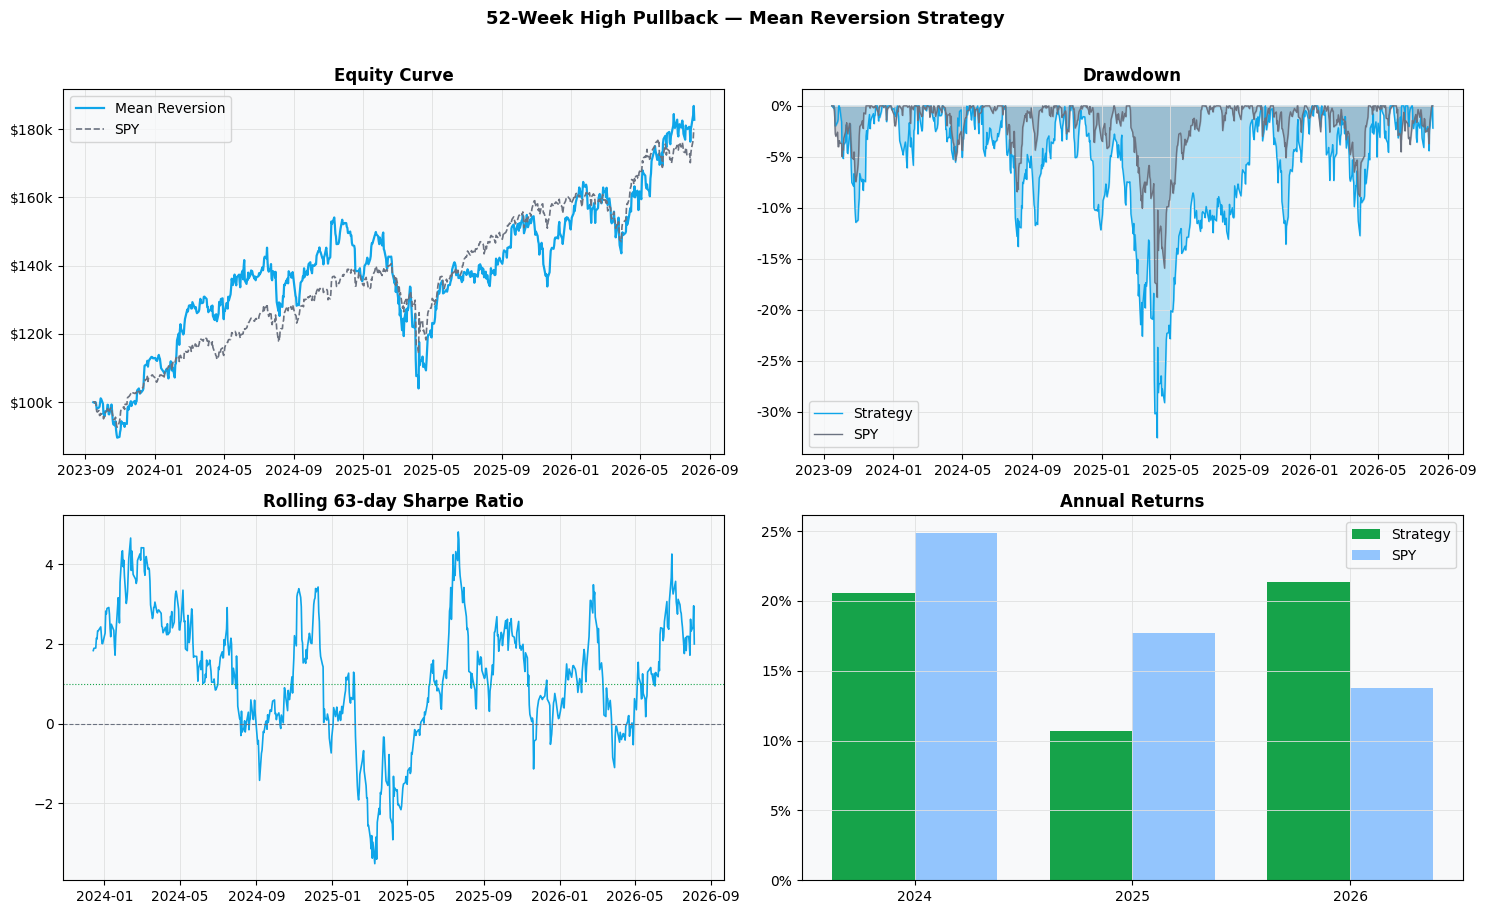

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

# Panel 1: Equity curve
ax = axes[0, 0]
ax.plot(equity.index, equity["strategy"], label="Mean Reversion", color="#0ea5e9", linewidth=1.6)
ax.plot(equity.index, equity["spy"],      label="SPY",            color="#6b7280", linewidth=1.2, linestyle="--")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
ax.set_title("Equity Curve", fontweight="bold")
ax.legend()

# Panel 2: Drawdown
ax = axes[0, 1]
for label, ser, color in [("Strategy", equity["strategy"], "#0ea5e9"), ("SPY", equity["spy"], "#6b7280")]:
    dd = (ser - ser.cummax()) / ser.cummax()
    ax.fill_between(dd.index, dd, 0, alpha=0.3, color=color)
    ax.plot(dd.index, dd, color=color, linewidth=1.0, label=label)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.set_title("Drawdown", fontweight="bold")
ax.legend()

# Panel 3: Rolling 63-day Sharpe
ax = axes[1, 0]
strat_rets = equity["strategy"].pct_change()
roll_sharpe = (strat_rets.rolling(63).mean() / strat_rets.rolling(63).std()) * np.sqrt(252)
ax.plot(roll_sharpe.index, roll_sharpe, color="#0ea5e9", linewidth=1.2)
ax.axhline(0, color="#6b7280", linewidth=0.8, linestyle="--")
ax.axhline(1, color="#16a34a", linewidth=0.8, linestyle=":")
ax.set_title("Rolling 63-day Sharpe Ratio", fontweight="bold")

# Panel 4: Annual returns bar chart
ax = axes[1, 1]
strat_annual = equity["strategy"].resample("YE").last().pct_change().dropna()
spy_annual   = equity["spy"].resample("YE").last().pct_change().dropna()
years = strat_annual.index.year.tolist()
x = np.arange(len(years))
w = 0.38
ax.bar(x - w/2, strat_annual.values, width=w, label="Strategy",
       color=["#16a34a" if v > 0 else "#dc2626" for v in strat_annual.values])
ax.bar(x + w/2, spy_annual.values, width=w, label="SPY",
       color=["#93c5fd" if v > 0 else "#fca5a5" for v in spy_annual.values])
ax.set_xticks(x)
ax.set_xticklabels(years)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.axhline(0, color="black", linewidth=0.6)
ax.set_title("Annual Returns", fontweight="bold")
ax.legend()

plt.suptitle("52-Week High Pullback — Mean Reversion Strategy", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 7. Sensitivity Analysis

Testing two dimensions simultaneously:
- **Pullback depth**: how far the stock must have dropped from its 52w high before we buy (10%, 15%, 20%, 25%, 30%)
- **Exit target**: how close to the 52w high we sell (3%, 5%, 8%)

In [8]:
pullback_levels = [0.10, 0.15, 0.20, 0.25, 0.30]
exit_levels     = [0.03, 0.05, 0.08]

sens_rows = []
for pb in pullback_levels:
    _, pb_matrix, em = compute_signals(closes, pullback_pct=pb)
    for ex in exit_levels:
        eq_s = backtest_mean_reversion(
            closes, em, high_52w, pb_matrix,
            exit_near_high=ex
        )
        m = perf_metrics(eq_s["strategy"], f"pb={pb:.0%} exit={ex:.0%}")
        m["Pullback"] = f"{pb:.0%}"
        m["Exit Within"] = f"{ex:.0%} of high"
        sens_rows.append(m)
        print(f"  pb={pb:.0%}  exit={ex:.0%}  →  CAGR {m['CAGR']}  Sharpe {m['Sharpe Ratio']}  MaxDD {m['Max Drawdown']}")

sens_df = pd.DataFrame(sens_rows).set_index("Label")
print("\n── Sensitivity table ────────────────────────────────────────────────")
print(sens_df[["Pullback", "Exit Within", "Total Return", "CAGR", "Sharpe Ratio", "Max Drawdown", "Calmar Ratio"]].to_string())

  pb=10%  exit=3%  →  CAGR 22.9%  Sharpe 0.96  MaxDD -30.8%
  pb=10%  exit=5%  →  CAGR 30.1%  Sharpe 1.19  MaxDD -33.7%


  pb=10%  exit=8%  →  CAGR 28.1%  Sharpe 1.13  MaxDD -31.2%


  pb=15%  exit=3%  →  CAGR 23.4%  Sharpe 0.95  MaxDD -32.5%
  pb=15%  exit=5%  →  CAGR 27.7%  Sharpe 1.11  MaxDD -29.9%


  pb=15%  exit=8%  →  CAGR 28.6%  Sharpe 1.17  MaxDD -30.4%


  pb=20%  exit=3%  →  CAGR 18.4%  Sharpe 0.81  MaxDD -33.1%


  pb=20%  exit=5%  →  CAGR 19.1%  Sharpe 0.85  MaxDD -31.9%


  pb=20%  exit=8%  →  CAGR 20.2%  Sharpe 0.89  MaxDD -30.6%


  pb=25%  exit=3%  →  CAGR 21.8%  Sharpe 1.05  MaxDD -24.0%
  pb=25%  exit=5%  →  CAGR 21.3%  Sharpe 1.03  MaxDD -24.6%
  pb=25%  exit=8%  →  CAGR 20.1%  Sharpe 1.01  MaxDD -24.4%


  pb=30%  exit=3%  →  CAGR 18.0%  Sharpe 0.94  MaxDD -20.7%
  pb=30%  exit=5%  →  CAGR 18.1%  Sharpe 0.95  MaxDD -20.8%
  pb=30%  exit=8%  →  CAGR 17.8%  Sharpe 0.94  MaxDD -20.0%

── Sensitivity table ────────────────────────────────────────────────
               Pullback Exit Within Total Return   CAGR Sharpe Ratio Max Drawdown Calmar Ratio
Label                                                                                         
pb=10% exit=3%      10%  3% of high        80.7%  22.9%         0.96       -30.8%         0.74
pb=10% exit=5%      10%  5% of high       112.8%  30.1%         1.19       -33.7%         0.89
pb=10% exit=8%      10%  8% of high       103.5%  28.1%         1.13       -31.2%         0.90
pb=15% exit=3%      15%  3% of high        82.8%  23.4%         0.95       -32.5%         0.72
pb=15% exit=5%      15%  5% of high       101.6%  27.7%         1.11       -29.9%         0.93
pb=15% exit=8%      15%  8% of high       105.9%  28.6%         1.17       -30.4%   

## 8. Sensitivity Heatmap — CAGR by Pullback × Exit Target

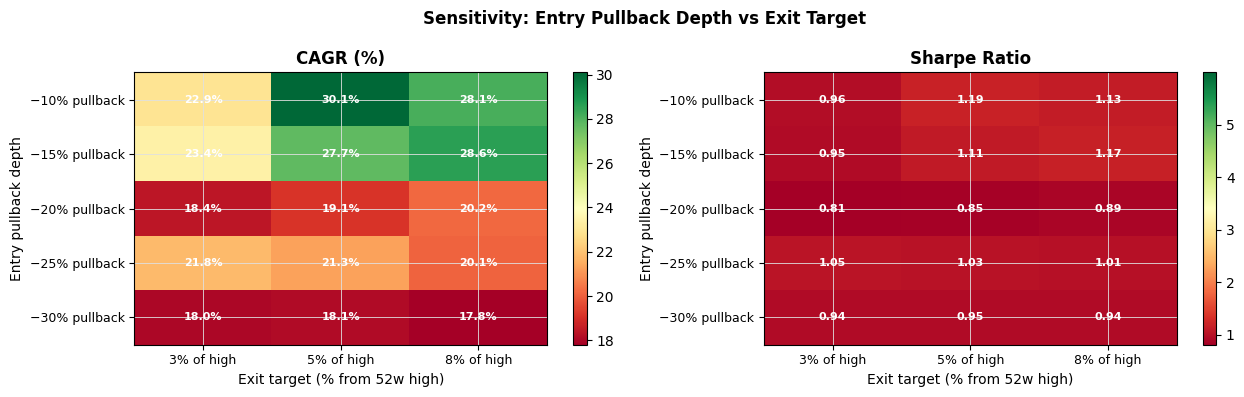

In [9]:
import matplotlib.colors as mcolors

# Build CAGR and Sharpe pivot tables
cagr_vals   = {}
sharpe_vals = {}
for row in sens_rows:
    pb  = row["Pullback"]
    ex  = row["Exit Within"]
    cagr_vals[(pb, ex)]   = float(row["CAGR"].rstrip("%"))
    sharpe_vals[(pb, ex)] = float(row["Sharpe Ratio"])

pb_labels  = [f"{pb:.0%}" for pb in pullback_levels]
ex_labels  = [f"{ex:.0%} of high" for ex in exit_levels]
cagr_grid   = np.array([[cagr_vals[(p, e)]   for e in ex_labels] for p in pb_labels])
sharpe_grid = np.array([[sharpe_vals[(p, e)] for e in ex_labels] for p in pb_labels])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, grid, title, fmt in [
    (axes[0], cagr_grid,   "CAGR (%)",    "{:.1f}%"),
    (axes[1], sharpe_grid, "Sharpe Ratio", "{:.2f}"),
]:
    im = ax.imshow(grid, cmap="RdYlGn", aspect="auto",
                   vmin=max(grid.min(), -5), vmax=max(grid.max(), grid.mean() + 5))
    ax.set_xticks(range(len(ex_labels)))
    ax.set_xticklabels(ex_labels, fontsize=9)
    ax.set_yticks(range(len(pb_labels)))
    ax.set_yticklabels([f"−{p} pullback" for p in pb_labels], fontsize=9)
    ax.set_xlabel("Exit target (% from 52w high)")
    ax.set_ylabel("Entry pullback depth")
    ax.set_title(title, fontweight="bold")
    plt.colorbar(im, ax=ax)
    for r in range(len(pb_labels)):
        for c in range(len(ex_labels)):
            ax.text(c, r, fmt.format(grid[r, c]),
                    ha="center", va="center", fontsize=8, fontweight="bold",
                    color="white" if abs(grid[r, c]) > grid.std() else "black")

plt.suptitle("Sensitivity: Entry Pullback Depth vs Exit Target", fontweight="bold")
plt.tight_layout()
plt.show()

## 9. Equity Curves — All Pullback Depths vs SPY

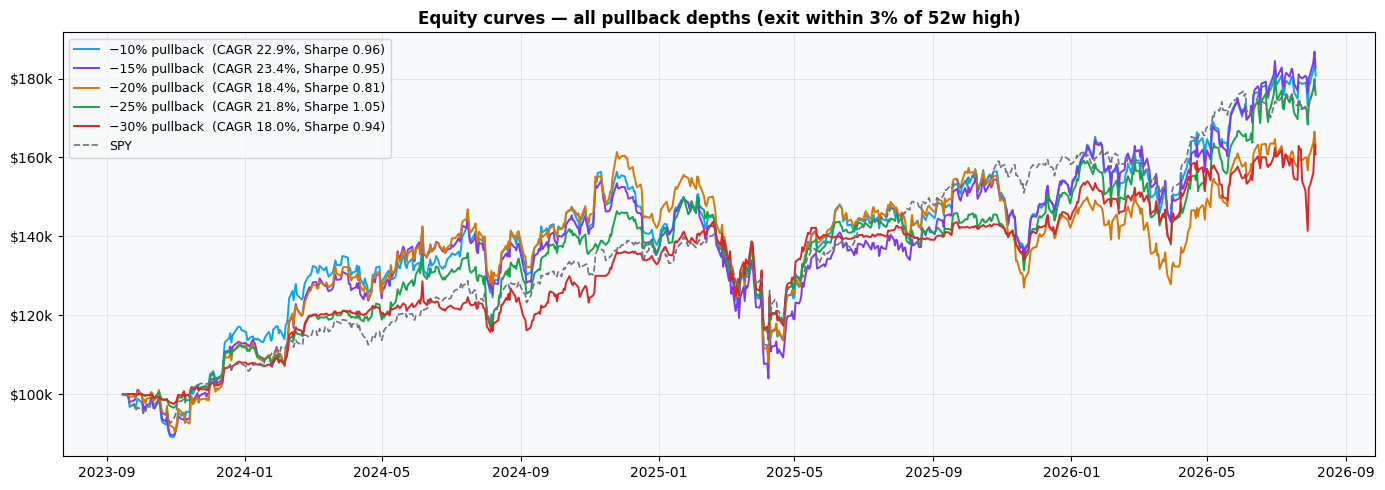

In [10]:
fig, ax = plt.subplots(figsize=(14, 5))

colors_pb = ["#0ea5e9", "#7c3aed", "#d97706", "#16a34a", "#dc2626"]

for pb, color in zip(pullback_levels, colors_pb):
    _, pb_matrix, em = compute_signals(closes, pullback_pct=pb)
    eq_s = backtest_mean_reversion(closes, em, high_52w, pb_matrix, exit_near_high=EXIT_NEAR_HIGH)
    m    = perf_metrics(eq_s["strategy"], "")
    ax.plot(eq_s.index, eq_s["strategy"],
            label=f"−{pb:.0%} pullback  (CAGR {m['CAGR']}, Sharpe {m['Sharpe Ratio']})",
            color=color, linewidth=1.4)

ax.plot(equity.index, equity["spy"], label="SPY", color="#6b7280", linewidth=1.2, linestyle="--")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
ax.set_title("Equity curves — all pullback depths (exit within 3% of 52w high)", fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 10. Today's Live Signals

Stocks in the universe that are currently triggering the baseline entry signal (−15% from 52w high, was near high within 22 days).

In [11]:
last = closes.index[-1]
today_high = high_52w.iloc[-1]
today_close = closes.iloc[-1]
today_pb    = pullback.iloc[-1]
today_entry = entry_mask.iloc[-1]

live = pd.DataFrame({
    "Price":      today_close[today_entry],
    "52w High":   today_high[today_entry],
    "Pullback %": (today_pb[today_entry] * 100).round(1),
    "Target (exit)": (today_high[today_entry] * (1 - EXIT_NEAR_HIGH)).round(2),
    "Upside to target %": ((today_high[today_entry] * (1 - EXIT_NEAR_HIGH) / today_close[today_entry] - 1) * 100).round(1),
}).sort_values("Pullback %", ascending=False)

live = live.merge(universe_df[["Symbol", "Sector", "Industry"]].set_index("Symbol"),
                  left_index=True, right_index=True, how="left")

print(f"Live signals as of {last.date()} — {len(live)} stocks qualifying:")
print(live.head(30).to_string())

Live signals as of 2026-08-05 — 21 stocks qualifying:
           Price    52w High  Pullback %  Target (exit)  Upside to target %                  Sector                                                 Industry
MRNA   56.860001   81.800003        30.5          79.35                39.5             Health Care                                            Biotechnology
PENG   57.189999   81.389999        29.7          78.95                38.0  Information Technology                                           Semiconductors
TDC    27.200001   37.880001        28.2          36.74                35.1  Information Technology                           IT Consulting & Other Services
ASTH   36.165001   49.810001        27.4          48.32                33.6             Health Care                                   Health Care Facilities
PTCT   68.820000   89.550003        23.1          86.86                26.2             Health Care                                          Pharmaceuticals
DVA 

---

## V2+ Variants — What I'm testing next

### Clarification on exits
You are correct — "exit within 8% of high" means the stock only needs to reach 92% of its high, which is **easier and faster** to achieve than 3% (needing to reach 97%). The reason 8% still performed worse is that you're **cutting winners short**: stocks that bounce to 92% often keep running to 97–100%, and by exiting early you miss that final profitable leg. The 3% tight exit essentially lets the full recovery play out before you sell.

---

### Variant A — Distance Band: Buy at −20%, Sell at −10%, Stop at −30%  *(your idea)*
Instead of using the 52w high as both entry reference AND exit target, we use a **distance band**:
- Entry: stock is 20% below its 52w high
- Exit (target): stock has recovered back to only 10% below its 52w high (captured ~10% of the recovery)
- Stop-loss: if stock falls further to 30% below high, cut the loss

This is cleaner than the baseline because the exit is symmetric — you're defining a price band, not chasing the high itself.

---

### Variant B — Distance Band Sweep
Same concept as Variant A but sweeping across all combinations:
- Entry pullback: −15%, −20%, −25%
- Exit pullback (when to sell): −5%, −10%, −15% from high *(always tighter than entry)*
- Stop: always entry_depth + 15% (e.g. enter at −20% → stop at −35%)

This tells us whether the distance-band concept holds up across many param choices or only at one lucky combination.

---

### Variant C — Regime Filter (only enter when market is healthy)
The big −31% drawdown in 2024–2025 happened because the strategy kept buying pullbacks during a market-wide selloff — those stocks weren't "dipping", they were breaking down. Fix: **only enter new positions when SPY is above its 200-day SMA** (bull market mode). During bear markets, hold cash instead of catching falling knives. We keep open positions but stop adding new ones.

---

### Variant D — Regime + Tighter Band Combined
Best of both worlds: regime filter + the optimal distance-band from Variant B.

In [12]:
## Updated backtest engine — supports distance-band exits
# 
# New parameter: exit_pullback (float or None)
#   - None (default) → old behaviour: exit when price >= high * (1 - exit_near_high)
#   - float, e.g. 0.10 → exit when pullback from 52w high has recovered to <= exit_pullback
#     i.e. exit when current price >= high * (1 - exit_pullback)
#
# Also new: regime_filter (bool) — only enter when SPY > SPY 200d SMA

def _safe_px(prices, sym, fallback):
    """Return price for sym, or fallback if the price is missing/NaN."""
    v = prices.get(sym, fallback)
    return fallback if (v is None or (isinstance(v, float) and np.isnan(v))) else v

def backtest_v2(
    closes: pd.DataFrame,
    entry_mask: pd.DataFrame,
    high_52w: pd.DataFrame,
    pullback: pd.DataFrame,
    spy_close: pd.Series,
    initial_capital: float = INITIAL_CAPITAL,
    top_n: int = TOP_N,
    rebal_freq: int = REBAL_FREQ,
    # Exit A: original — price within X% of 52w high
    exit_near_high: float = EXIT_NEAR_HIGH,
    # Exit B: distance band — exit when pullback recovers to this level (e.g. 0.10 = stock is only 10% below high)
    exit_pullback: float = None,
    # Stop-loss: fraction below *52w high* (e.g. 0.30 → stop if stock falls 30% below its 52w high)
    stop_from_high: float = None,
    # Original stop: fraction below entry price
    stop_loss: float = STOP_LOSS,
    max_hold_days: int = MAX_HOLD_DAYS,
    tc: float = TRANSACTION_COST,
    regime_filter: bool = False,
) -> pd.DataFrame:

    dates = closes.index
    start_idx = HIGH_LOOKBACK + NEAR_HIGH_WINDOW + 5

    # Precompute regime (SPY above 200d SMA)
    if regime_filter:
        spy_sma200 = spy_close.rolling(200, min_periods=200).mean()
        in_bull = (spy_close > spy_sma200).reindex(closes.index).fillna(False)
    else:
        in_bull = pd.Series(True, index=closes.index)

    capital   = initial_capital
    positions = {}
    portfolio_values = []
    portfolio_dates  = []

    for i, date in enumerate(dates[start_idx:], start=start_idx):
        prices = closes.iloc[i]

        # ── Check exits ─────────────────────────────────────────────────
        to_exit = []
        for sym, pos in positions.items():
            px = _safe_px(prices, sym, np.nan)
            if np.isnan(px) or px <= 0:
                to_exit.append(sym); continue
            days_held = i - pos["entry_idx"]
            cur_high  = _safe_px(high_52w.iloc[i], sym, pos["ref_high"])
            cur_pb    = (cur_high - px) / cur_high if cur_high > 0 else 1

            hit_target  = False
            hit_stop    = False
            hit_time    = days_held >= max_hold_days

            if exit_pullback is not None:
                # Distance-band: exit when pullback has shrunk to <= exit_pullback
                hit_target = cur_pb <= exit_pullback
            else:
                # Original: exit when price >= high * (1 - exit_near_high)
                hit_target = px >= pos["target_price"]

            if stop_from_high is not None:
                # Stop relative to 52w high at entry
                hit_stop = cur_pb >= stop_from_high
            else:
                hit_stop = px <= pos["entry_price"] * (1 - stop_loss)

            if hit_target or hit_stop or hit_time:
                to_exit.append(sym)

        for sym in to_exit:
            pos = positions.pop(sym)
            px  = max(_safe_px(prices, sym, pos["entry_price"]), 0.01)
            capital += pos["shares"] * px * (1 - tc)

        # ── New entries on rebalance day (only in bull market) ───────────
        if (i - start_idx) % rebal_freq == 0 and in_bull.iloc[i]:
            slots_free = top_n - len(positions)
            if slots_free > 0:
                day_signals = entry_mask.iloc[i]
                candidates = (
                    pullback.iloc[i].where(day_signals).dropna()
                    .sort_values(ascending=False)
                )
                candidates = candidates[~candidates.index.isin(positions.keys())]
                port_val = capital + sum(
                    pos["shares"] * _safe_px(prices, sym, pos["entry_price"])
                    for sym, pos in positions.items()
                )
                if np.isnan(port_val):
                    port_val = capital
                per_position = port_val / top_n

                for sym in candidates.index[:slots_free]:
                    px = _safe_px(prices, sym, 0)
                    if not (px > 0): continue
                    shares = int((per_position * (1 - tc)) / px)
                    cost   = shares * px * (1 + tc)
                    if shares < 1 or cost > capital: continue
                    hi = _safe_px(high_52w.iloc[i], sym, px)
                    positions[sym] = {
                        "shares":       shares,
                        "entry_price":  px,
                        "entry_idx":    i,
                        "ref_high":     hi,
                        "target_price": hi * (1 - exit_near_high),
                    }
                    capital -= cost

        # ── Mark-to-market ───────────────────────────────────────────────
        port_val = capital + sum(
            pos["shares"] * max(_safe_px(prices, sym, pos["entry_price"]), 0)
            for sym, pos in positions.items()
        )
        portfolio_values.append(port_val)
        portfolio_dates.append(date)

    result = pd.DataFrame({"strategy": portfolio_values}, index=portfolio_dates)
    result["spy"] = (
        spy_close.reindex(portfolio_dates).ffill()
        / spy_close.reindex(portfolio_dates).ffill().iloc[0]
        * initial_capital
    )
    return result

print("Updated backtest engine (v2.1 — NaN-safe) ready.")


Updated backtest engine (v2.1 — NaN-safe) ready.


Variant A: Buy −20%, Sell at −10% from high, Stop at −30% from high

                                         Total Return   CAGR Sharpe Ratio Max Drawdown Calmar Ratio Win Rate
Label                                                                                                       
Variant A: Buy−20% → Sell−10% → Stop−30%         5.2%   1.8%         0.19       -25.2%         0.07    50.1%
SPY (benchmark)                                 80.0%  22.7%         1.40       -18.8%         1.21    57.4%


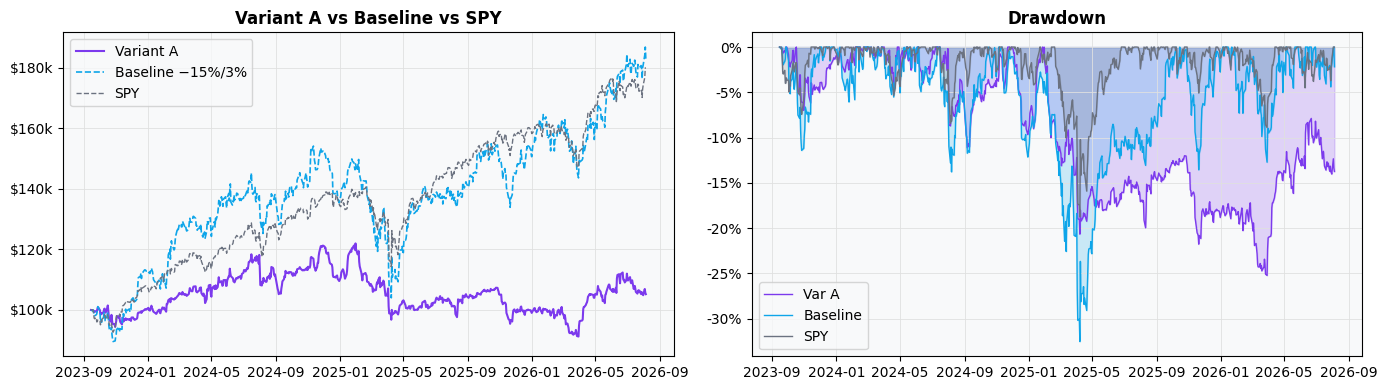

In [13]:
## ── Variant A: Your idea — Buy −20%, Sell −10%, Stop −30% ──────────────────
#
# Entry:  stock is 20% below 52w high
# Exit:   stock recovers back to only 10% below 52w high (captured ~12% gain from entry)
# Stop:   stock falls to 30% below 52w high from 52w high (not from entry)
#         at entry we're at -20%, so stop triggers if it drops another ~12.5%

_, pb_20, em_20 = compute_signals(closes, pullback_pct=0.20)

print("Variant A: Buy −20%, Sell at −10% from high, Stop at −30% from high")
eq_A = backtest_v2(
    closes, em_20, high_52w, pb_20, spy_close,
    exit_pullback=0.10,      # exit when stock is only 10% below its 52w high
    stop_from_high=0.30,     # stop when stock falls to 30% below 52w high
)
m_A = perf_metrics(eq_A["strategy"], "Variant A: Buy−20% → Sell−10% → Stop−30%")
m_spy = perf_metrics(eq_A["spy"], "SPY (benchmark)")

print(pd.DataFrame([m_A, m_spy]).set_index("Label").to_string())

# Quick equity chart
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ax = axes[0]
ax.plot(eq_A.index, eq_A["strategy"], label="Variant A", color="#7c3aed", linewidth=1.5)
ax.plot(equity.index, equity["strategy"], label="Baseline −15%/3%", color="#0ea5e9", linewidth=1.2, linestyle="--")
ax.plot(eq_A.index, eq_A["spy"], label="SPY", color="#6b7280", linewidth=1.0, linestyle="--")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
ax.set_title("Variant A vs Baseline vs SPY", fontweight="bold")
ax.legend()

ax = axes[1]
for lbl, ser, col in [("Var A", eq_A["strategy"], "#7c3aed"), ("Baseline", equity["strategy"], "#0ea5e9"), ("SPY", eq_A["spy"], "#6b7280")]:
    dd = (ser - ser.cummax()) / ser.cummax()
    ax.fill_between(dd.index, dd, 0, alpha=0.2, color=col)
    ax.plot(dd.index, dd, color=col, linewidth=1.0, label=lbl)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.set_title("Drawdown", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()


  Entry 15% → Exit 5% → Stop 30%  |  CAGR 18.0%  Sharpe 0.95  MaxDD -24.0%


  Entry 15% → Exit 10% → Stop 30%  |  CAGR 8.1%  Sharpe 0.51  MaxDD -24.9%


  Entry 20% → Exit 5% → Stop 35%  |  CAGR 9.5%  Sharpe 0.56  MaxDD -28.1%


  Entry 20% → Exit 10% → Stop 35%  |  CAGR 2.3%  Sharpe 0.22  MaxDD -25.6%


  Entry 20% → Exit 15% → Stop 35%  |  CAGR 3.5%  Sharpe 0.29  MaxDD -20.6%


  Entry 25% → Exit 5% → Stop 40%  |  CAGR 9.9%  Sharpe 0.63  MaxDD -23.4%


  Entry 25% → Exit 10% → Stop 40%  |  CAGR 6.5%  Sharpe 0.46  MaxDD -23.9%
  Entry 25% → Exit 15% → Stop 40%  |  CAGR 9.5%  Sharpe 0.65  MaxDD -20.6%

── Distance-band sweep ──────────────────────────────────────────────
                                 Entry depth     Exit target            Stop Total Return   CAGR Sharpe Ratio Max Drawdown Calmar Ratio
Label                                                                                                                                  
Entry−15% → Exit−5% (stop −30%)         −15%   −5% from high  −30% from high        60.7%  18.0%         0.95       -24.0%         0.75
Entry−15% → Exit−10% (stop −30%)        −15%  −10% from high  −30% from high        24.9%   8.1%         0.51       -24.9%         0.32
Entry−20% → Exit−5% (stop −35%)         −20%   −5% from high  −35% from high        29.8%   9.5%         0.56       -28.1%         0.34
Entry−20% → Exit−10% (stop −35%)        −20%  −10% from high  −35% from high         6.8%   2.3%   

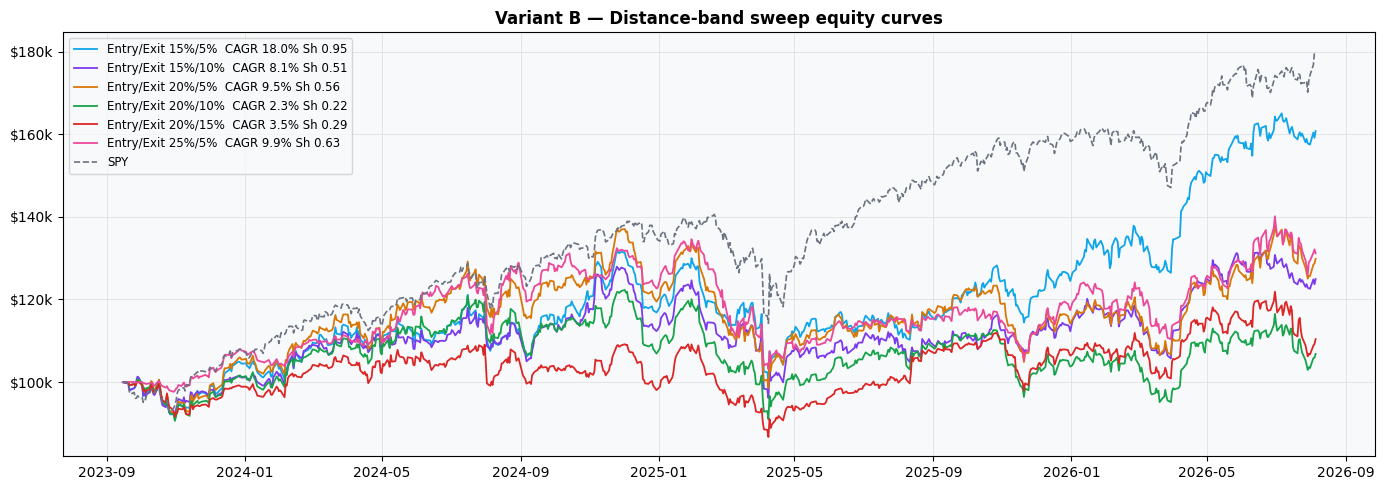

In [14]:
## ── Variant B: Distance-Band Sweep ─────────────────────────────────────────
#
# Entry pullbacks:  15%, 20%, 25%
# Exit targets:      5%, 10%, 15% from high  (always shallower than entry)
# Stop: entry_depth + 15pp  (e.g. buy at -20% → stop at -35%)

entry_depths = [0.15, 0.20, 0.25]
exit_targets = [0.05, 0.10, 0.15]

band_rows = []
equities_B = {}

for entry_d in entry_depths:
    _, pb_mat, em_mat = compute_signals(closes, pullback_pct=entry_d)
    for exit_t in exit_targets:
        if exit_t >= entry_d:
            continue  # exit must be shallower (less below high) than entry
        stop_d = entry_d + 0.15  # stop = entry depth + 15pp
        eq_b = backtest_v2(
            closes, em_mat, high_52w, pb_mat, spy_close,
            exit_pullback=exit_t,
            stop_from_high=stop_d,
        )
        m = perf_metrics(eq_b["strategy"],
                         f"Entry−{entry_d:.0%} → Exit−{exit_t:.0%} (stop −{stop_d:.0%})")
        m["Entry depth"] = f"−{entry_d:.0%}"
        m["Exit target"] = f"−{exit_t:.0%} from high"
        m["Stop"]        = f"−{stop_d:.0%} from high"
        band_rows.append(m)
        equities_B[f"{entry_d:.0%}/{exit_t:.0%}"] = eq_b
        print(f"  Entry {entry_d:.0%} → Exit {exit_t:.0%} → Stop {stop_d:.0%}  |  "
              f"CAGR {m['CAGR']}  Sharpe {m['Sharpe Ratio']}  MaxDD {m['Max Drawdown']}")

band_df = pd.DataFrame(band_rows).set_index("Label")
print("\n── Distance-band sweep ──────────────────────────────────────────────")
print(band_df[["Entry depth", "Exit target", "Stop", "Total Return", "CAGR", "Sharpe Ratio", "Max Drawdown", "Calmar Ratio"]].to_string())

# Chart: all distance-band equity curves
fig, ax = plt.subplots(figsize=(14, 5))
palette = ["#0ea5e9", "#7c3aed", "#d97706", "#16a34a", "#dc2626", "#ec4899"]
for (key, eq_b), color in zip(equities_B.items(), palette):
    m_ = perf_metrics(eq_b["strategy"], "")
    ax.plot(eq_b.index, eq_b["strategy"],
            label=f"Entry/Exit {key}  CAGR {m_['CAGR']} Sh {m_['Sharpe Ratio']}",
            color=color, linewidth=1.3)
ax.plot(equity.index, equity["spy"], label="SPY", color="#6b7280", linestyle="--", linewidth=1.2)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
ax.set_title("Variant B — Distance-band sweep equity curves", fontweight="bold")
ax.legend(fontsize=8.5)
plt.tight_layout()
plt.show()


Variant C: Baseline + regime filter (no new entries when SPY < 200d SMA)


SPY above 200d SMA: 74.3% of the backtest period

                                        Total Return   CAGR Sharpe Ratio Max Drawdown Calmar Ratio Win Rate
Label                                                                                                      
Mean Reversion −15% pullback (baseline)        82.8%  23.4%         0.95       -32.5%         0.72    53.4%
Variant C: Baseline + Regime Filter            63.9%  18.8%         0.84       -33.3%         0.56    53.4%
SPY (benchmark)                                80.0%  22.7%         1.40       -18.8%         1.21    57.4%


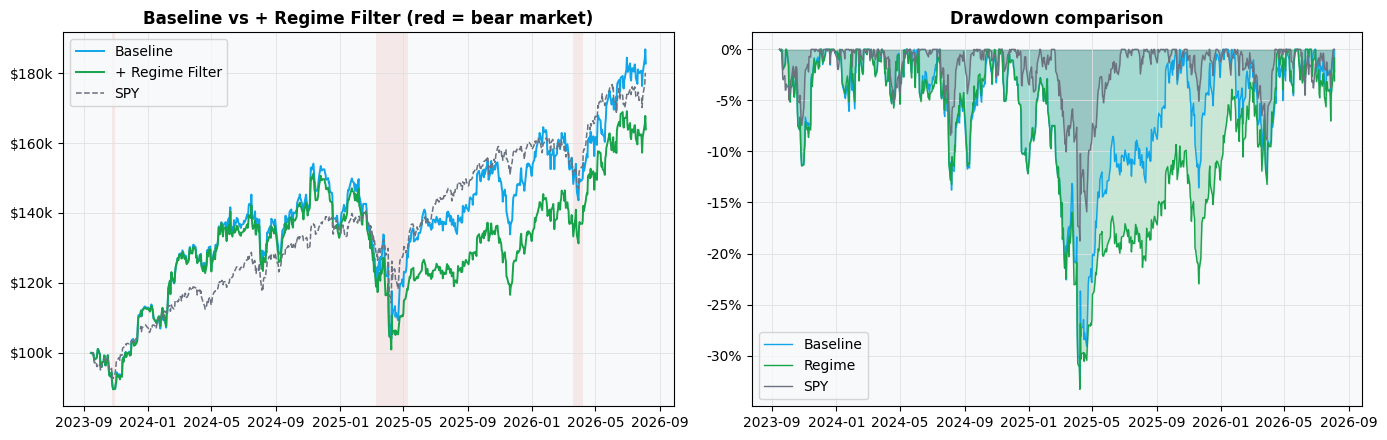

In [15]:
## ── Variant C: Regime Filter (stop adding positions in bear markets) ────────
#
# Same as baseline (−15% pullback, exit within 3% of high)
# but NO new entries when SPY < its 200d SMA.
# Existing positions still run to their exits/stops — we just don't add new ones.

print("Variant C: Baseline + regime filter (no new entries when SPY < 200d SMA)")
eq_C = backtest_v2(
    closes, entry_mask, high_52w, pullback, spy_close,
    exit_near_high=0.03,
    stop_loss=0.35,
    regime_filter=True,
)
m_C = perf_metrics(eq_C["strategy"], "Variant C: Baseline + Regime Filter")

# Check regime: how often are we in "invest" mode?
spy_sma200 = spy_close.rolling(200, min_periods=200).mean()
bull_pct = (spy_close > spy_sma200).mean() * 100
print(f"SPY above 200d SMA: {bull_pct:.1f}% of the backtest period")
print()
print(pd.DataFrame([m_baseline, m_C, m_spy]).set_index("Label").to_string())

# Chart
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
ax = axes[0]
ax.plot(equity.index,  equity["strategy"], label="Baseline",        color="#0ea5e9", linewidth=1.4)
ax.plot(eq_C.index,    eq_C["strategy"],   label="+ Regime Filter", color="#16a34a", linewidth=1.4)
ax.plot(equity.index,  equity["spy"],      label="SPY",             color="#6b7280", linestyle="--", linewidth=1.1)
# Shade bear-market periods (regime off) in light red
bear_dates = spy_close.index[(spy_close <= spy_sma200) & spy_close.notna() & spy_sma200.notna()]
for i_d in range(len(bear_dates) - 1):
    if (bear_dates[i_d + 1] - bear_dates[i_d]).days <= 5:
        ax.axvspan(bear_dates[i_d], bear_dates[i_d + 1], alpha=0.08, color="#dc2626", linewidth=0)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
ax.set_title("Baseline vs + Regime Filter (red = bear market)", fontweight="bold")
ax.legend()

ax = axes[1]
for lbl, ser, col in [("Baseline", equity["strategy"], "#0ea5e9"), ("Regime", eq_C["strategy"], "#16a34a"), ("SPY", equity["spy"], "#6b7280")]:
    dd = (ser - ser.cummax()) / ser.cummax()
    ax.fill_between(dd.index, dd, 0, alpha=0.2, color=col)
    ax.plot(dd.index, dd, color=col, linewidth=1.0, label=lbl)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.set_title("Drawdown comparison", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()


Variant D: Entry−15% → Exit−5% + Regime Filter + Stop −30%



════════════════════════════════════════════════════════════════════════════════
GRAND COMPARISON — ALL VARIANTS
════════════════════════════════════════════════════════════════════════════════
                                        Total Return   CAGR Sharpe Ratio Max Drawdown Calmar Ratio Win Rate
Label                                                                                                      
Mean Reversion −15% pullback (baseline)        82.8%  23.4%         0.95       -32.5%         0.72    53.4%
Var A: −20%→−10% stop−30%                       5.2%   1.8%         0.19       -25.2%         0.07    50.1%
Best Band (15%/5%)                             60.7%  18.0%         0.95       -24.0%         0.75    51.5%
Variant C: Baseline + Regime Filter            63.9%  18.8%         0.84       -33.3%         0.56    53.4%
Variant D: −15%→−5% + Regime Filter            35.3%  11.1%         0.68       -21.4%         0.52    51.7%
SPY (benchmark)                                80

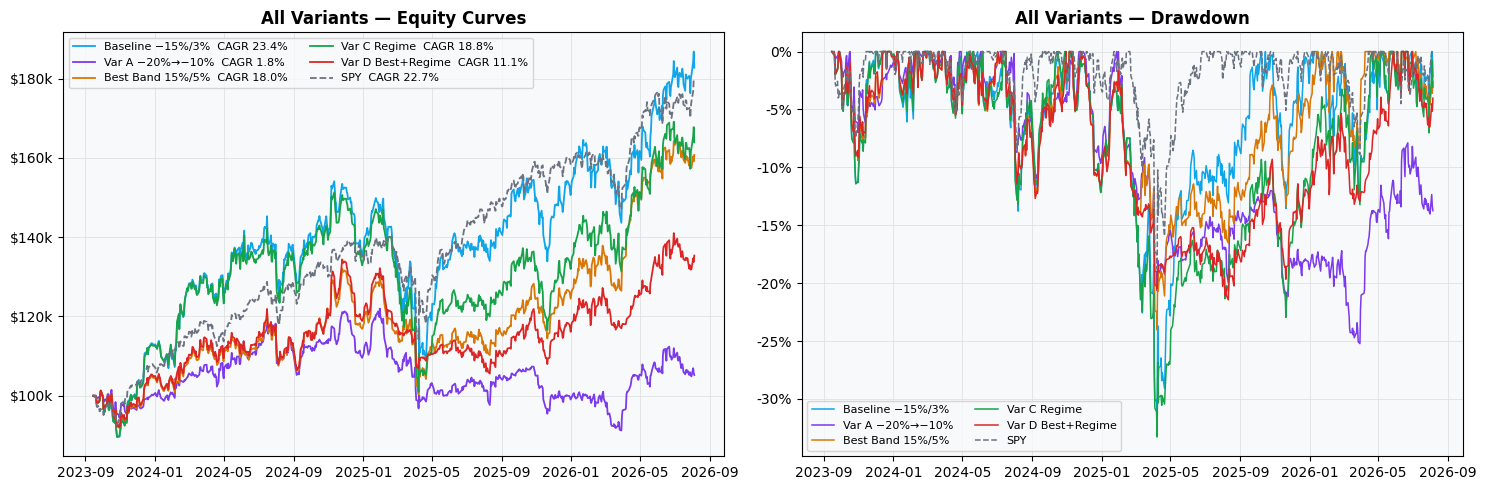

In [16]:
## ── Variant D: Best Distance-Band + Regime Filter ──────────────────────────
#
# Take the best setup from Variant B and add the regime filter on top.
# We'll use Entry −15%, Exit −5% from high (strong recovery), Stop −30%
# plus only enter during bull markets.

print("Variant D: Entry−15% → Exit−5% + Regime Filter + Stop −30%")
_, pb_15_D, em_15_D = compute_signals(closes, pullback_pct=0.15)
eq_D = backtest_v2(
    closes, em_15_D, high_52w, pb_15_D, spy_close,
    exit_pullback=0.05,    # exit when stock has recovered to within 5% of its high
    stop_from_high=0.30,   # stop if stock falls 30% from 52w high
    regime_filter=True,
)
m_D = perf_metrics(eq_D["strategy"], "Variant D: −15%→−5% + Regime Filter")

# ── Grand final comparison table ────────────────────────────────────────────
# Pick best from band sweep too
best_band_key = max(equities_B.items(), key=lambda kv: float(perf_metrics(kv[1]["strategy"], "")["Sharpe Ratio"].replace("nan","0")))[0]
eq_best_band  = equities_B[best_band_key]
m_best_band   = perf_metrics(eq_best_band["strategy"], f"Best Band ({best_band_key})")
m_var_A       = perf_metrics(eq_A["strategy"], "Var A: −20%→−10% stop−30%")

all_results = pd.DataFrame([
    m_baseline,
    m_var_A,
    m_best_band,
    m_C,
    m_D,
    m_spy,
]).set_index("Label")

print("\n" + "═" * 80)
print("GRAND COMPARISON — ALL VARIANTS")
print("═" * 80)
print(all_results.to_string())

# ── Final equity chart ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_items = [
    ("Baseline −15%/3%",       equity["strategy"],        "#0ea5e9", "-"),
    ("Var A −20%→−10%",        eq_A["strategy"],           "#7c3aed", "-"),
    (f"Best Band {best_band_key}", eq_best_band["strategy"], "#d97706", "-"),
    ("Var C Regime",            eq_C["strategy"],           "#16a34a", "-"),
    ("Var D Best+Regime",       eq_D["strategy"],           "#dc2626", "-"),
    ("SPY",                     equity["spy"],              "#6b7280", "--"),
]
ax = axes[0]
for lbl, ser, col, ls in plot_items:
    m_ = perf_metrics(ser, "")
    ax.plot(ser.index, ser, label=f"{lbl}  CAGR {m_['CAGR']}", color=col, linestyle=ls, linewidth=1.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
ax.set_title("All Variants — Equity Curves", fontweight="bold")
ax.legend(fontsize=8, ncol=2)

ax = axes[1]
for lbl, ser, col, ls in plot_items:
    dd = (ser - ser.cummax()) / ser.cummax()
    ax.plot(dd.index, dd, color=col, linestyle=ls, linewidth=1.1, label=lbl)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.set_title("All Variants — Drawdown", fontweight="bold")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()


## Deep Distress Strategy — 50% down from 52w High

**New framing (user request):** Instead of buying stocks that dipped ~15% below their 52-week high, buy only deeply distressed stocks that have fallen **≥ 50% from their 52-week high**.

Exit targets (distance still remaining to 52w high):

| Exit level | Meaning |
|---|---|
| 30% | Stock recovered from −50% to within 30% of high |
| 25% | Recovered to within 25% of high |
| 20% | Recovered to within 20% of high |
| 15% | Recovered to within 15% of high |
| 10% | Recovered to within 10% of high |

Then a full **entry depth × exit target** grid sweep to find the best combo.

Avg daily entry candidates (≥50% below high): 0.1
Total unique tickers ever triggered:           10



=== Deep Distress (−50% entry) — Exit Sweep ===
                    Total Return  CAGR Sharpe Ratio Max Drawdown Calmar Ratio Win Rate
Label                                                                                 
exit ≤30% from high         5.8%  2.0%         0.62        -4.2%         0.48    10.5%
exit ≤25%                   6.2%  2.1%         0.65        -4.2%         0.51    11.2%
exit ≤20%                   6.8%  2.3%         0.71        -4.2%         0.55    11.6%
exit ≤15%                   6.1%  2.1%         0.63        -4.2%         0.50    11.8%
exit ≤10%                   6.1%  2.1%         0.63        -4.2%         0.50    11.8%


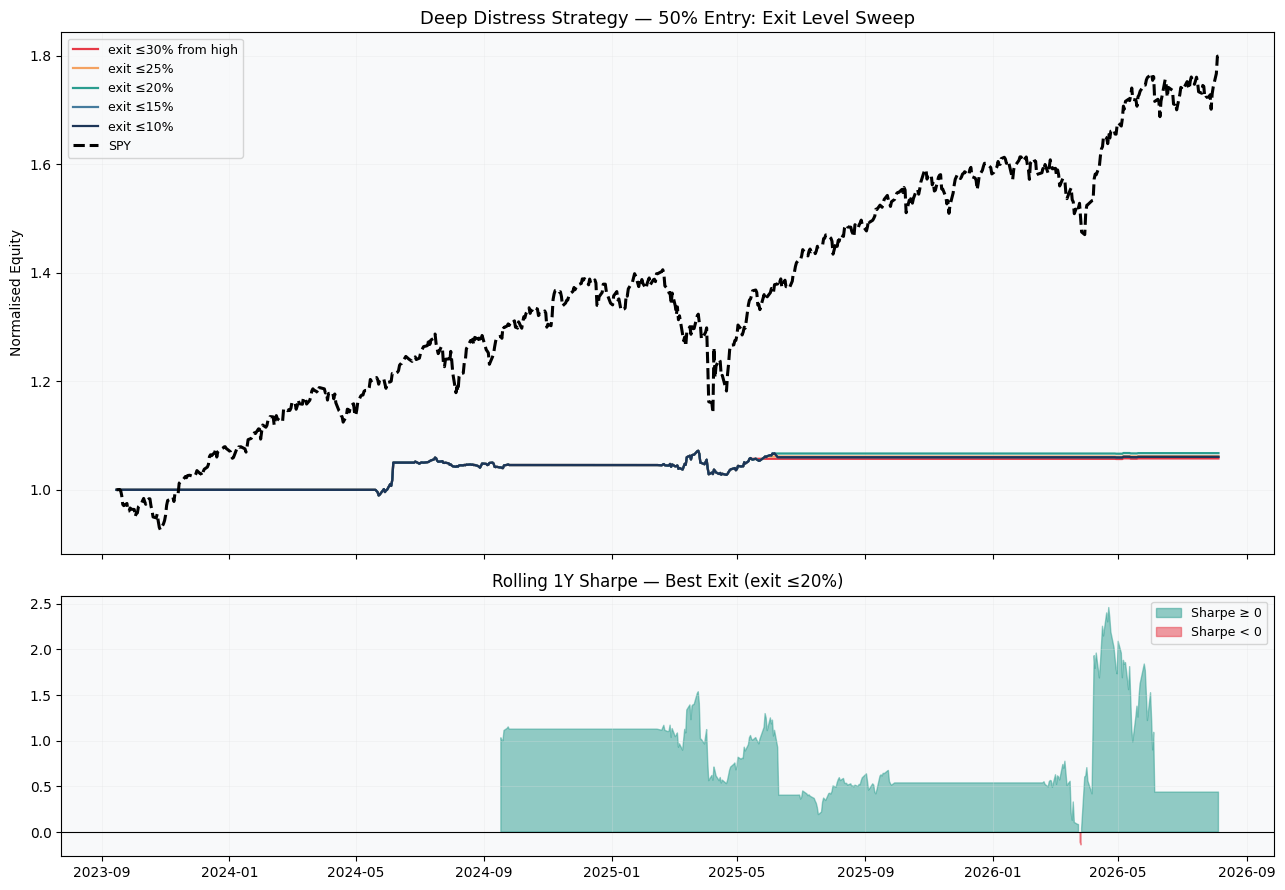

In [17]:
# ── Deep distress entry: stock ≥50% below 52w high ─────────────────────────
_, _, entry_mask_50 = compute_signals(
    closes,
    high_lookback=HIGH_LOOKBACK,
    near_high_pct=NEAR_HIGH_PCT,
    near_high_window=NEAR_HIGH_WINDOW,
    pullback_pct=0.50,          # new: must be 50%+ below 52w high
)

print(f"Avg daily entry candidates (≥50% below high): {entry_mask_50.sum(axis=1).mean():.1f}")
print(f"Total unique tickers ever triggered:           {entry_mask_50.any().sum()}")

# ── Sweep exit targets ────────────────────────────────────────────────────────
exit_sweep = [0.30, 0.25, 0.20, 0.15, 0.10]
exit_labels = ["exit ≤30% from high", "exit ≤25%", "exit ≤20%", "exit ≤15%", "exit ≤10%"]

deep_rows = []
equities_deep = {}
for et, lbl in zip(exit_sweep, exit_labels):
    eq = backtest_v2(
        closes, entry_mask_50, high_52w, pullback,
        spy_close,
        exit_pullback=et,
        stop_from_high=0.65,   # stop if stock falls to 65% below its 52w high
        stop_loss=0.35,
        regime_filter=False,
    )
    m = perf_metrics(eq["strategy"], lbl)
    deep_rows.append(m)
    equities_deep[lbl] = eq["strategy"]

deep_df = pd.DataFrame(deep_rows).set_index("Label")
print("\n=== Deep Distress (−50% entry) — Exit Sweep ===")
print(deep_df.to_string())

# ── Plot equity curves ────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 9), sharex=True,
                                gridspec_kw={"height_ratios": [2, 1]})
palette_deep = ["#e63946", "#f4a261", "#2a9d8f", "#457b9d", "#1d3557"]
for (lbl, eq_s), col in zip(equities_deep.items(), palette_deep):
    norm = eq_s / eq_s.iloc[0]
    ax1.plot(norm.index, norm, label=lbl, color=col, lw=1.6)
spy_norm = spy_close.reindex(eq_s.index).ffill()
spy_norm = spy_norm / spy_norm.iloc[0]
ax1.plot(spy_norm.index, spy_norm, label="SPY", color="black", lw=2.2, ls="--")
ax1.set_title("Deep Distress Strategy — 50% Entry: Exit Level Sweep", fontsize=13)
ax1.set_ylabel("Normalised Equity"); ax1.legend(fontsize=9); ax1.grid(alpha=0.3)

# Rolling 252-day Sharpe of best exit level
best_lbl = deep_df["CAGR"].idxmax()
best_eq = equities_deep[best_lbl]
rets = best_eq.pct_change().dropna()
roll_sh = rets.rolling(252).mean() / rets.rolling(252).std() * np.sqrt(252)
ax2.fill_between(roll_sh.index, roll_sh, 0,
                 where=roll_sh >= 0, color="#2a9d8f", alpha=0.5, label="Sharpe ≥ 0")
ax2.fill_between(roll_sh.index, roll_sh, 0,
                 where=roll_sh < 0,  color="#e63946", alpha=0.5, label="Sharpe < 0")
ax2.axhline(0, color="black", lw=0.8)
ax2.set_title(f"Rolling 1Y Sharpe — Best Exit ({best_lbl})")
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [18]:
# ── Diagnose: pullback distribution in our backtest window ──────────────────
flat_pb = pullback.values.flatten()
flat_pb = flat_pb[~np.isnan(flat_pb)]

print("Pullback distribution (distance below 52w high):")
for pct in [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    n_days = (pullback >= pct).sum(axis=1).mean()
    n_tickers = int((pullback >= pct).any().sum())
    print(f"  >= {pct:.0%} below high: {n_days:.1f} avg stocks/day  |  {n_tickers} unique tickers ever")

print(f"\nMax pullback in dataset:  {flat_pb.max():.1%}")
print(f"99th percentile:          {np.percentile(flat_pb, 99):.1%}")
print(f"95th percentile:          {np.percentile(flat_pb, 95):.1%}")
start_date = pullback.dropna(how='all').index[0].date()
end_date = pullback.index[-1].date()
print(f"Backtest window:          {start_date}  →  {end_date}")


Pullback distribution (distance below 52w high):
  >= 10% below high: 415.7 avg stocks/day  |  1008 unique tickers ever
  >= 15% below high: 309.3 avg stocks/day  |  1000 unique tickers ever
  >= 20% below high: 224.9 avg stocks/day  |  960 unique tickers ever
  >= 25% below high: 161.2 avg stocks/day  |  875 unique tickers ever
  >= 30% below high: 112.8 avg stocks/day  |  763 unique tickers ever
  >= 35% below high: 78.2 avg stocks/day  |  629 unique tickers ever
  >= 40% below high: 53.3 avg stocks/day  |  492 unique tickers ever
  >= 45% below high: 35.4 avg stocks/day  |  378 unique tickers ever
  >= 50% below high: 23.2 avg stocks/day  |  278 unique tickers ever

Max pullback in dataset:  91.9%
99th percentile:          60.8%
95th percentile:          44.3%
Backtest window:          2023-08-07  →  2026-08-05


Avg daily candidates: 23.2  |  Unique tickers: 278



=== Deep Distress (entry ≥50% below 52w high) — Exit Sweep ===
          Total Return   CAGR Sharpe Ratio Max Drawdown Calmar Ratio Win Rate
Label                                                                        
exit ≤30%       102.1%  27.8%         1.04       -25.0%         1.11    52.0%
exit ≤25%       151.2%  37.9%         1.32       -22.8%         1.66    52.3%
exit ≤20%       153.2%  38.2%         1.31       -25.4%         1.50    51.5%
exit ≤15%       135.6%  34.8%         1.23       -27.4%         1.27    52.4%
exit ≤10%       121.0%  31.8%         1.15       -26.2%         1.21    51.9%


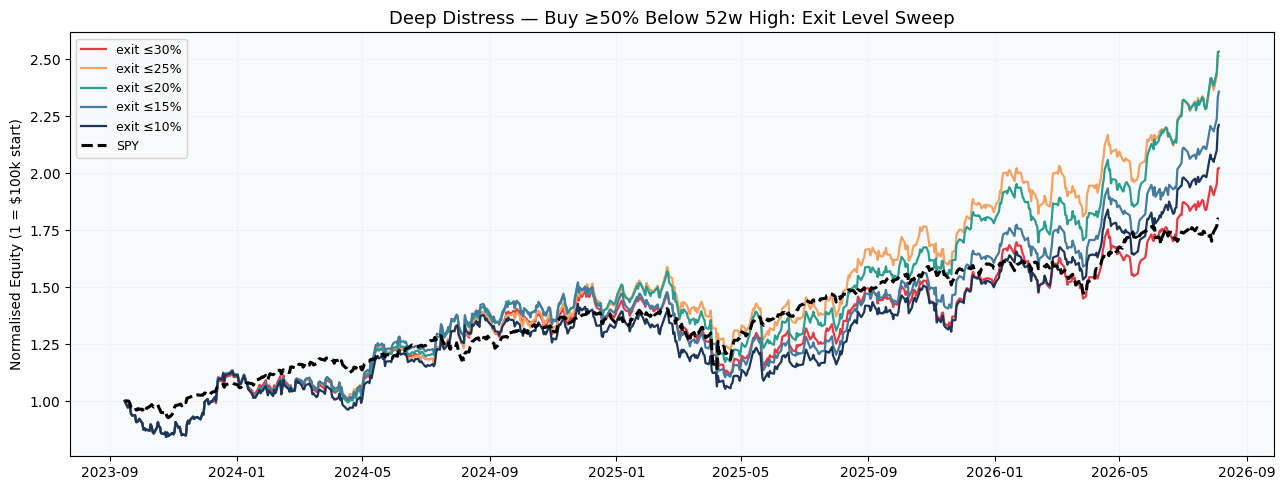

In [19]:
# ── Deep distress sweep: entry ≥50% below 52w high (raw pullback, no extra filter) ──
entry_mask_50 = (pullback >= 0.50)
print(f"Avg daily candidates: {entry_mask_50.sum(axis=1).mean():.1f}  |  Unique tickers: {int(entry_mask_50.any().sum())}")

exit_sweep  = [0.30, 0.25, 0.20, 0.15, 0.10]
exit_labels = ["exit ≤30%", "exit ≤25%", "exit ≤20%", "exit ≤15%", "exit ≤10%"]

deep_rows     = []
equities_deep = {}
for et, lbl in zip(exit_sweep, exit_labels):
    eq = backtest_v2(
        closes, entry_mask_50, high_52w, pullback, spy_close,
        exit_pullback=et,
        stop_from_high=0.70,
        stop_loss=0.35,
        regime_filter=False,
    )
    m = perf_metrics(eq["strategy"], lbl)
    deep_rows.append(m)
    equities_deep[lbl] = eq["strategy"]

deep_df = pd.DataFrame(deep_rows).set_index("Label")
print("\n=== Deep Distress (entry ≥50% below 52w high) — Exit Sweep ===")
print(deep_df.to_string())

fig, ax = plt.subplots(figsize=(13, 5))
palette_deep = ["#e63946", "#f4a261", "#2a9d8f", "#457b9d", "#1d3557"]
for (lbl, eq_s), col in zip(equities_deep.items(), palette_deep):
    norm = eq_s / eq_s.iloc[0]
    ax.plot(norm.index, norm, label=lbl, color=col, lw=1.6)
spy_norm = spy_close.reindex(eq_s.index).ffill()
ax.plot(spy_norm.index, spy_norm / spy_norm.iloc[0], label="SPY", color="black", lw=2.2, ls="--")
ax.set_title("Deep Distress — Buy ≥50% Below 52w High: Exit Level Sweep", fontsize=13)
ax.set_ylabel("Normalised Equity (1 = $100k start)")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


=== CAGR Grid (%) ===
              Sell ≤30% down Sell ≤25% down Sell ≤20% down Sell ≤15% down Sell ≤10% down Sell ≤5% down
Buy ≥25% down              —              —           1.5%           0.8%           0.8%          0.8%
Buy ≥30% down              —           0.0%          -0.1%          -0.4%          -0.4%         -0.8%
Buy ≥40% down          10.3%          11.2%           5.6%           5.8%           4.4%          4.8%
Buy ≥50% down          27.8%          37.9%          38.2%          34.8%          31.8%         35.3%
Buy ≥60% down          51.5%          52.7%          50.9%          49.8%          51.4%         51.3%

=== Sharpe Grid ===
              Sell ≤30% down Sell ≤25% down Sell ≤20% down Sell ≤15% down Sell ≤10% down Sell ≤5% down
Buy ≥25% down              —              —           0.18           0.13           0.13          0.13
Buy ≥30% down              —           0.08           0.07           0.04           0.05          0.02
Buy ≥40% down           0.60  

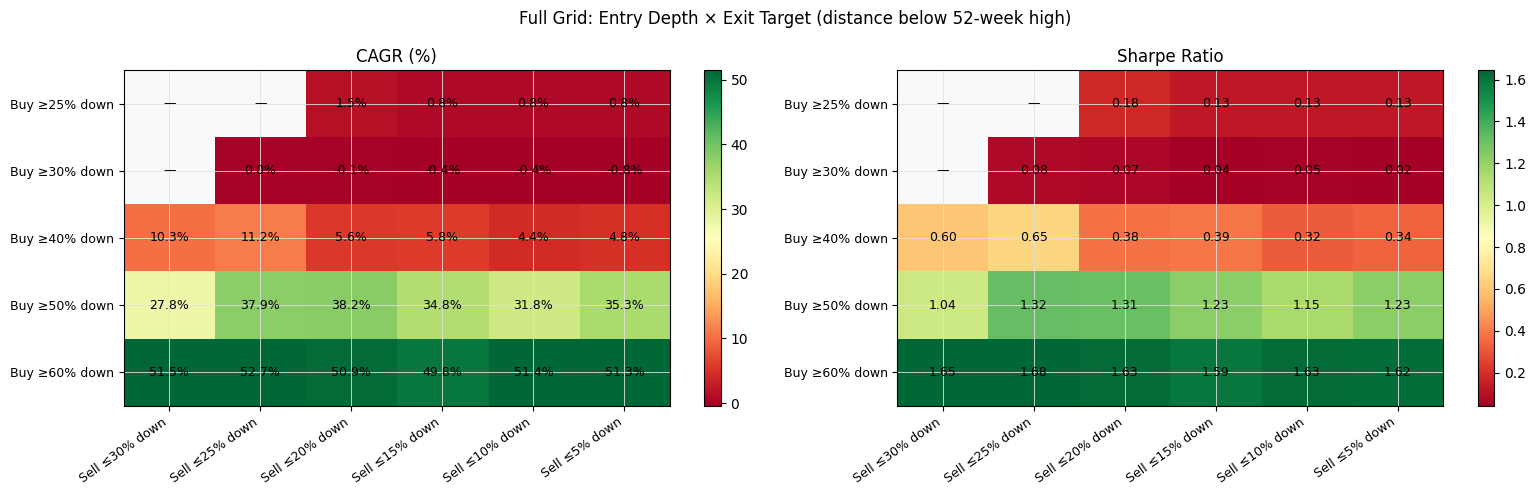

In [20]:
# ── Full combo sweep: entry depth × exit distance (all using raw pullback mask) ──
entry_depths_full = [0.25, 0.30, 0.40, 0.50, 0.60]
exit_targets_full  = [0.30, 0.25, 0.20, 0.15, 0.10, 0.05]

combo_cagr   = np.full((len(entry_depths_full), len(exit_targets_full)), np.nan)
combo_sharpe = np.full((len(entry_depths_full), len(exit_targets_full)), np.nan)
combo_dd     = np.full((len(entry_depths_full), len(exit_targets_full)), np.nan)

for r, ed in enumerate(entry_depths_full):
    em_combo = (pullback >= ed)
    for c, et in enumerate(exit_targets_full):
        if et >= ed:
            continue      # exit level must be less than entry depth
        eq_c = backtest_v2(
            closes, em_combo, high_52w, pullback, spy_close,
            exit_pullback=et,
            stop_from_high=min(ed + 0.20, 0.80),  # stop = entry+20pp below high
            stop_loss=0.35,
            regime_filter=False,
        )
        m_c = perf_metrics(eq_c["strategy"], f"{ed:.0%}/{et:.0%}")
        combo_cagr[r, c]   = m_c["CAGR"].rstrip("%")  if isinstance(m_c["CAGR"], str) else float(str(m_c["CAGR"]).rstrip("%"))
        combo_sharpe[r, c] = float(m_c["Sharpe Ratio"])
        combo_dd[r, c]     = float(str(m_c["Max Drawdown"]).rstrip("%"))

# Convert string percentages that perf_metrics returns
import re
def _pct(v):
    if isinstance(v, str):
        return float(v.rstrip("%"))
    return float(v)

combo_cagr_f   = np.full_like(combo_cagr, np.nan)
combo_sharpe_f = np.full_like(combo_sharpe, np.nan)
combo_dd_f     = np.full_like(combo_dd, np.nan)

for r, ed in enumerate(entry_depths_full):
    em_combo = (pullback >= ed)
    for c, et in enumerate(exit_targets_full):
        if et >= ed:
            continue
        eq_c = backtest_v2(
            closes, em_combo, high_52w, pullback, spy_close,
            exit_pullback=et,
            stop_from_high=min(ed + 0.20, 0.80),
            stop_loss=0.35,
            regime_filter=False,
        )
        m_c = perf_metrics(eq_c["strategy"], f"{ed:.0%}/{et:.0%}")
        combo_cagr_f[r, c]   = _pct(m_c["CAGR"])
        combo_sharpe_f[r, c] = float(m_c["Sharpe Ratio"])
        combo_dd_f[r, c]     = _pct(m_c["Max Drawdown"])

row_labels = [f"Buy ≥{d:.0%} down" for d in entry_depths_full]
col_labels  = [f"Sell ≤{t:.0%} down" for t in exit_targets_full]

print("=== CAGR Grid (%) ===")
df_cagr = pd.DataFrame(combo_cagr_f, index=row_labels, columns=col_labels)
print(df_cagr.applymap(lambda x: f"{x:.1f}%" if not np.isnan(x) else "—").to_string())

print("\n=== Sharpe Grid ===")
df_sh = pd.DataFrame(combo_sharpe_f, index=row_labels, columns=col_labels)
print(df_sh.applymap(lambda x: f"{x:.2f}" if not np.isnan(x) else "—").to_string())

print("\n=== Max Drawdown Grid (%) ===")
df_dd = pd.DataFrame(combo_dd_f, index=row_labels, columns=col_labels)
print(df_dd.applymap(lambda x: f"{x:.1f}%" if not np.isnan(x) else "—").to_string())

flat_cagr = [(entry_depths_full[r], exit_targets_full[c], combo_cagr_f[r, c])
             for r in range(len(entry_depths_full))
             for c in range(len(exit_targets_full))
             if not np.isnan(combo_cagr_f[r, c])]
best_ed, best_et, best_cagr = max(flat_cagr, key=lambda x: x[2])
print(f"\n>>> BEST COMBO: Buy ≥{best_ed:.0%} below 52w high  |  Sell ≤{best_et:.0%} below high  |  CAGR {best_cagr:.1f}%")

# ── Heatmaps ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax_h, data, title in [
    (axes[0], combo_cagr_f,   "CAGR (%)"),
    (axes[1], combo_sharpe_f, "Sharpe Ratio"),
]:
    valid_vals = data[~np.isnan(data)]
    im = ax_h.imshow(data, cmap="RdYlGn", aspect="auto",
                     vmin=np.percentile(valid_vals, 5) if len(valid_vals) else 0,
                     vmax=np.percentile(valid_vals, 95) if len(valid_vals) else 1)
    ax_h.set_xticks(range(len(col_labels))); ax_h.set_xticklabels(col_labels, rotation=35, ha="right", fontsize=9)
    ax_h.set_yticks(range(len(row_labels))); ax_h.set_yticklabels(row_labels, fontsize=9)
    ax_h.set_title(title)
    fmt = "%.1f%%" if "CAGR" in title else "%.2f"
    for r2 in range(len(entry_depths_full)):
        for c2 in range(len(exit_targets_full)):
            val = data[r2, c2]
            txt = (fmt % val) if not np.isnan(val) else "—"
            ax_h.text(c2, r2, txt, ha="center", va="center", fontsize=9, color="black")
    plt.colorbar(im, ax=ax_h)

plt.suptitle("Full Grid: Entry Depth × Exit Target (distance below 52-week high)", fontsize=12)
plt.tight_layout()
plt.show()


---
## Long-Term Backtest (2011–2026) — 50% & 60% Entry Depth

Re-downloading ~15 years of data for the full universe, then testing:
- **Entry**: ≥50% and ≥60% below 52-week high
- **Exit**: stock recovers to within 30 / 25 / 20 / 15 / 10% of its 52-week high (5 levels)
- **Annual breakdown**: return, Sharpe, max drawdown per year vs SPY
- **CAGR comparison plot** across all combos
- **Average hold time**: how many days did trades typically last?

In [21]:
# ── Download 15-year data (2011–present) ─────────────────────────────────────
print("Downloading 15y data for full universe (~1,400 tickers). Takes a few minutes…")

raw_lt = yf.download(
    download_tickers,          # same ticker list as before
    start="2010-01-01",        # start 2010 to allow the 252-day warmup
    end="2026-03-11",
    group_by="ticker",
    progress=True,
    threads=True,
    auto_adjust=True,
)

MIN_BARS_LT = HIGH_LOOKBACK * 2   # need at least 2 years to be included

close_dict_lt = {t: extract_close(raw_lt, t) for t in download_tickers}
valid_lt  = [t for t in ALL_TICKERS if len(close_dict_lt.get(t, [])) >= MIN_BARS_LT]

closes_lt  = pd.DataFrame({t: close_dict_lt[t] for t in valid_lt}).sort_index()
spy_lt     = close_dict_lt["SPY"].reindex(closes_lt.index).ffill()

print(f"\nValid tickers: {len(valid_lt)}")
print(f"Price matrix : {closes_lt.shape[0]} days × {closes_lt.shape[1]} stocks")
print(f"Date range   : {closes_lt.index[0].date()} → {closes_lt.index[-1].date()}")

# ── Recompute signals on long-term data ───────────────────────────────────────
high_lt  = closes_lt.rolling(HIGH_LOOKBACK, min_periods=HIGH_LOOKBACK).max()
pb_lt    = (high_lt - closes_lt) / high_lt          # pullback fraction (0 = at high)

em_50_lt = (pb_lt >= 0.50)                           # entry: ≥50% below 52w high
em_60_lt = (pb_lt >= 0.60)                           # entry: ≥60% below 52w high

print(f"\nEntry signals in long-term data:")
print(f"  ≥50% entry: {em_50_lt.sum(axis=1).mean():.1f} stocks/day  |  {int(em_50_lt.any().sum())} unique tickers")
print(f"  ≥60% entry: {em_60_lt.sum(axis=1).mean():.1f} stocks/day  |  {int(em_60_lt.any().sum())} unique tickers")


[                       0%                       ]

[                       0%                       ]  2 of 1393 completed

[                       0%                       ]  2 of 1393 completed

[                       0%                       ]  4 of 1393 completed

[                       0%                       ]  6 of 1393 completed

...

[*********************100%***********************]  1392 of 1393 completed

[*********************100%***********************]  1393 of 1393 completed



1199 Failed downloads:


['TGNA', 'MHK', 'ULS', 'TSN', 'NOV', 'UNFI', 'FRT', 'OKE', 'ALK', 'CFG', 'ELAN', 'EXR', 'AWK', 'WMG', 'ACT', 'ACN', 'ARLO', 'CSGP', 'RHP', 'OFG', 'COKE', 'AMPH', 'LSCC', 'AJG', 'DVA', 'CR', 'FITB', 'INTC', 'NEO', 'WBD', 'HIMS', 'WHR', 'WLY', 'CVNA', 'EHC', 'HLI', 'CENX', 'SNDK', 'AMKR', 'SEM', 'CPRX', 'USPH', 'AXTA', 'CVLT', 'AMCR', 'WAT', 'VRSK', 'LGND', 'AEP', 'CPRT', 'ORI', 'VSAT', 'BA', 'CAR', 'APD', 'PGR', 'MOS', 'AZZ', 'FFIN', 'USB', 'Q', 'SLGN', 'SNCY', 'NI', 'HL', 'ATO', 'ROL', 'ETR', 'ASGN', 'CRS', 'SYNA', 'KAI', 'INSW', 'CWST', 'DEI', 'IAC', 'KTOS', 'ONTO', 'SCSC', 'HOG', 'FBNC', 'LBRT', 'STWD', 'TT', 'ICHR', 'INGR', 'ENVA', 'VOYA', 'ELS', 'FLR', 'FLO', 'MGEE', 'KD', 'CXW', 'NWBI', 'CB', 'STRA', 'VRE', 'PTGX', 'JLL', 'PLXS', 'OMCL', 'AAL', 'LII', 'THS', 'DXPE', 'VZ', 'SPXC', 'FOXA', 'COIN', 'SLM', 'PRKS', 'WBS', 'TNDM', 'DECK', 'REZI', 'WCC', 'PCRX', 'FCN', 'HSY', 'SANM', 'EMR', 'SLVM', 'AAP', 'EXPD', 'MDT', 'PCTY', 'DUK', 'LPX', 'BCO', 'PRGO', 'AVGO', 'SSD', 'UVV', 'AMR', 'V


Valid tickers: 189
Price matrix : 4070 days × 189 stocks
Date range   : 2010-01-04 → 2026-03-10

Entry signals in long-term data:
  ≥50% entry: 4.6 stocks/day  |  128 unique tickers
  ≥60% entry: 1.9 stocks/day  |  80 unique tickers


In [22]:
# ── Extended backtest engine: tracks trade hold times ─────────────────────────
def backtest_lt(
    closes, high_52w, pullback, spy_close,
    entry_mask,
    exit_pullback,               # sell when pullback ≤ this  (e.g. 0.25 = within 25% of high)
    stop_from_high=0.80,         # stop if falls more than this below 52w high
    initial_capital=100_000,
    top_n=TOP_N,
    rebal_freq=REBAL_FREQ,
    max_hold_days=MAX_HOLD_DAYS,
    tc=TRANSACTION_COST,
):
    """
    Returns:
        equity     : pd.Series of daily portfolio value
        hold_times : list of (entry_date, exit_date, days_held, exit_reason) per closed trade
    """
    dates     = closes.index
    start_idx = HIGH_LOOKBACK + 5

    capital       = initial_capital
    positions     = {}
    port_vals     = []
    port_dates    = []
    hold_times    = []

    for i, date in enumerate(dates[start_idx:], start=start_idx):
        prices = closes.iloc[i]

        # ── Exits ────────────────────────────────────────────────────
        to_exit = []
        for sym, pos in positions.items():
            px = _safe_px(prices, sym, np.nan)
            if np.isnan(px) or px <= 0:
                to_exit.append((sym, "delisted")); continue
            days_held = i - pos["entry_idx"]
            cur_high  = _safe_px(high_52w.iloc[i], sym, pos["ref_high"])
            cur_pb    = (cur_high - px) / cur_high if cur_high > 0 else 1

            reason = None
            if cur_pb <= exit_pullback:
                reason = "target"
            elif cur_pb >= stop_from_high:
                reason = "stop"
            elif days_held >= max_hold_days:
                reason = "timeout"

            if reason:
                to_exit.append((sym, reason))

        for sym, reason in to_exit:
            pos = positions.pop(sym)
            px  = max(_safe_px(prices, sym, pos["entry_price"]), 0.01)
            capital += pos["shares"] * px * (1 - tc)
            hold_times.append({
                "entry_date":  pos["entry_date"],
                "exit_date":   date,
                "days_held":   i - pos["entry_idx"],
                "exit_reason": reason,
            })

        # ── Entries ───────────────────────────────────────────────────
        if (i - start_idx) % rebal_freq == 0:
            slots_free = top_n - len(positions)
            if slots_free > 0:
                candidates = (
                    pullback.iloc[i]
                    .where(entry_mask.iloc[i])
                    .dropna()
                    .sort_values(ascending=False)
                )
                candidates = candidates[~candidates.index.isin(positions.keys())]
                port_val = capital + sum(
                    pos["shares"] * _safe_px(prices, s, pos["entry_price"])
                    for s, pos in positions.items()
                )
                if np.isnan(port_val): port_val = capital
                per_pos = port_val / top_n
                for sym in candidates.index[:slots_free]:
                    px = _safe_px(prices, sym, 0)
                    if not (px > 0): continue
                    shares = int((per_pos * (1 - tc)) / px)
                    cost   = shares * px * (1 + tc)
                    if shares < 1 or cost > capital: continue
                    hi = _safe_px(high_52w.iloc[i], sym, px)
                    positions[sym] = {
                        "shares":       shares,
                        "entry_price":  px,
                        "entry_idx":    i,
                        "entry_date":   date,
                        "ref_high":     hi,
                    }
                    capital -= cost

        # ── MTM ───────────────────────────────────────────────────────
        pv = capital + sum(
            pos["shares"] * max(_safe_px(prices, s, pos["entry_price"]), 0)
            for s, pos in positions.items()
        )
        port_vals.append(pv)
        port_dates.append(date)

    return pd.Series(port_vals, index=port_dates, name="strategy"), hold_times


print("Long-term backtest engine ready.")


Long-term backtest engine ready.


In [23]:
# ── Run 50% + 60% entries × 5 exit levels ────────────────────────────────────
entry_configs = [
    ("50% entry", em_50_lt, 0.70),   # (label, mask, stop_from_high)
    ("60% entry", em_60_lt, 0.80),
]
exit_configs = [0.30, 0.25, 0.20, 0.15, 0.10]
exit_labels_lt = ["exit ≤30%", "exit ≤25%", "exit ≤20%", "exit ≤15%", "exit ≤10%"]

results_lt    = {}   # key: (entry_label, exit_label) → equity Series
holdtime_lt   = {}   # key: (entry_label, exit_label) → list of trade dicts

for entry_lbl, em, stop in entry_configs:
    for et, ex_lbl in zip(exit_configs, exit_labels_lt):
        key = f"{entry_lbl} / {ex_lbl}"
        print(f"Running {key}…", end=" ", flush=True)
        eq_s, ht = backtest_lt(closes_lt, high_lt, pb_lt, spy_lt, em, et, stop_from_high=stop)
        results_lt[key] = eq_s
        holdtime_lt[key] = ht
        rets_s = eq_s.pct_change().dropna()
        cagr_val = (eq_s.iloc[-1] / eq_s.iloc[0]) ** (252 / len(eq_s)) - 1
        sharpe_val = rets_s.mean() / rets_s.std() * np.sqrt(252) if rets_s.std() > 0 else 0
        dd_val = ((eq_s / eq_s.cummax()) - 1).min()
        print(f"CAGR {cagr_val:.1%}  Sharpe {sharpe_val:.2f}  MaxDD {dd_val:.1%}")

print("\nAll runs complete.")


Running 50% entry / exit ≤30%… 

CAGR 9.7%  Sharpe 0.61  MaxDD -35.3%
Running 50% entry / exit ≤25%… 

CAGR 10.3%  Sharpe 0.63  MaxDD -34.8%
Running 50% entry / exit ≤20%… 

CAGR 10.3%  Sharpe 0.62  MaxDD -36.4%
Running 50% entry / exit ≤15%… 

CAGR 10.6%  Sharpe 0.63  MaxDD -36.2%
Running 50% entry / exit ≤10%… 

...

CAGR 9.8%  Sharpe 0.71  MaxDD -29.0%
Running 60% entry / exit ≤25%… 

CAGR 10.2%  Sharpe 0.72  MaxDD -28.8%
Running 60% entry / exit ≤20%… 

CAGR 10.1%  Sharpe 0.71  MaxDD -29.4%
Running 60% entry / exit ≤15%… 

CAGR 9.8%  Sharpe 0.69  MaxDD -29.4%
Running 60% entry / exit ≤10%… 

CAGR 10.0%  Sharpe 0.70  MaxDD -29.4%

All runs complete.


In [24]:
# ── Annual breakdown table: return / Sharpe / MaxDD per year vs SPY ──────────
def annual_stats(equity: pd.Series) -> pd.DataFrame:
    """Returns DataFrame with year-by-year return, Sharpe, MaxDD."""
    rows = []
    for yr, grp in equity.groupby(equity.index.year):
        if len(grp) < 20:
            continue
        rets = grp.pct_change().dropna()
        ann_ret   = grp.iloc[-1] / grp.iloc[0] - 1
        sharpe    = rets.mean() / rets.std() * np.sqrt(252) if rets.std() > 0 else np.nan
        max_dd    = ((grp / grp.cummax()) - 1).min()
        rows.append({"Year": yr, "Return": ann_ret, "Sharpe": sharpe, "MaxDD": max_dd})
    return pd.DataFrame(rows).set_index("Year")

# SPY annual stats
spy_annual_stats = annual_stats(spy_lt)

# Print per-combo annual tables
all_annual = {}
for key, eq_s in results_lt.items():
    all_annual[key] = annual_stats(eq_s)

print("=" * 90)
print(f"{'Year':<6}  {'SPY Ret':>8}  {'SPY Sh':>7}  {'SPY DD':>8}", end="")
for key in results_lt:
    short = key.replace(" entry", "").replace("exit ", "")
    print(f"  {short[:16]:>16} Ret  Sh  DD", end="")
print()
print("-" * 90)

years_lt = sorted(spy_annual_stats.index)
for yr in years_lt:
    spy_r = spy_annual_stats.loc[yr, "Return"]
    spy_s = spy_annual_stats.loc[yr, "Sharpe"]
    spy_d = spy_annual_stats.loc[yr, "MaxDD"]
    print(f"{yr:<6}  {spy_r:>7.1%}  {spy_s:>6.2f}  {spy_d:>7.1%}", end="")
    for key in results_lt:
        if yr in all_annual[key].index:
            r = all_annual[key].loc[yr, "Return"]
            s = all_annual[key].loc[yr, "Sharpe"]
            d = all_annual[key].loc[yr, "MaxDD"]
            print(f"  {r:>6.1%} {s:>5.2f} {d:>6.1%}", end="")
        else:
            print(f"  {'—':>6} {'—':>5} {'—':>6}", end="")
    print()


Year     SPY Ret   SPY Sh    SPY DD        50% / ≤30% Ret  Sh  DD        50% / ≤25% Ret  Sh  DD        50% / ≤20% Ret  Sh  DD        50% / ≤15% Ret  Sh  DD        50% / ≤10% Ret  Sh  DD        60% / ≤30% Ret  Sh  DD        60% / ≤25% Ret  Sh  DD        60% / ≤20% Ret  Sh  DD        60% / ≤15% Ret  Sh  DD        60% / ≤10% Ret  Sh  DD
------------------------------------------------------------------------------------------
2010      13.1%    0.78   -15.7%       —     —      —       —     —      —       —     —      —       —     —      —       —     —      —       —     —      —       —     —      —       —     —      —       —     —      —       —     —      —
2011       0.9%    0.15   -18.6%    8.5%  0.50 -13.9%    8.4%  0.48 -15.3%    8.4%  0.48 -15.3%    8.4%  0.48 -15.3%    8.4%  0.48 -15.3%    6.7%  0.72  -5.7%    6.7%  0.72  -5.7%    6.7%  0.72  -5.7%    6.7%  0.72  -5.7%    6.7%  0.72  -5.7%
2012      14.2%    1.12    -9.7%   24.3%  2.12  -6.7%   24.7%  2.08  -8.0%   26.0%  2.1

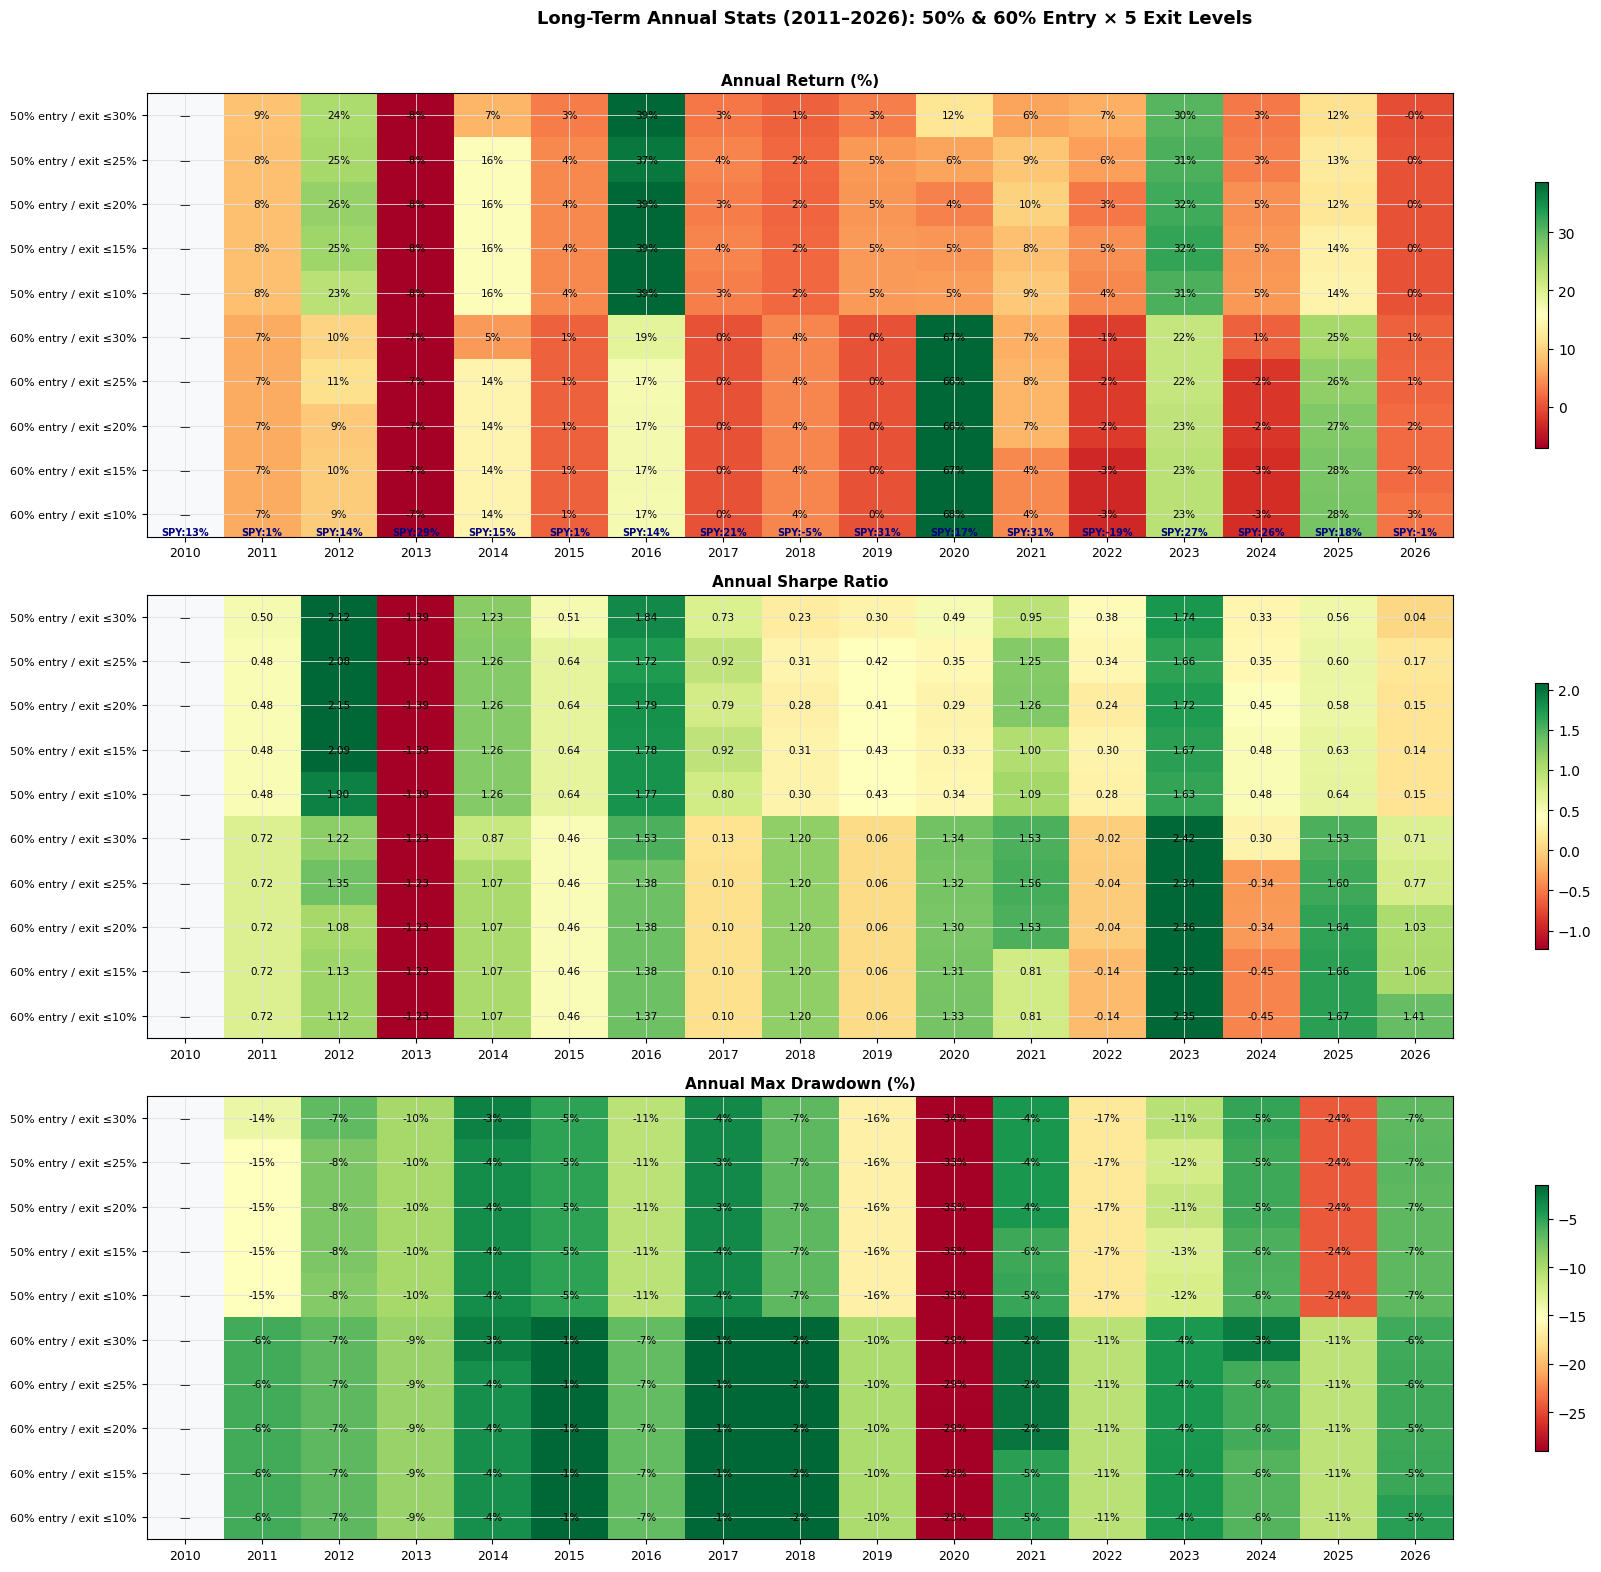

In [25]:
# ── Annual heatmaps: Return and Sharpe per combo per year ─────────────────────
combo_keys = list(results_lt.keys())
short_keys = [k.replace(" entry / exit ", "\n") for k in combo_keys]

# Build matrices: rows=combos, cols=years
years_arr = sorted(spy_annual_stats.index)
ret_matrix  = np.full((len(combo_keys), len(years_arr)), np.nan)
sh_matrix   = np.full((len(combo_keys), len(years_arr)), np.nan)
dd_matrix   = np.full((len(combo_keys), len(years_arr)), np.nan)

for r_idx, key in enumerate(combo_keys):
    for c_idx, yr in enumerate(years_arr):
        if yr in all_annual[key].index:
            ret_matrix[r_idx, c_idx] = all_annual[key].loc[yr, "Return"] * 100
            sh_matrix[r_idx,  c_idx] = all_annual[key].loc[yr, "Sharpe"]
            dd_matrix[r_idx,  c_idx] = all_annual[key].loc[yr, "MaxDD"]  * 100

spy_rets = [spy_annual_stats.loc[yr, "Return"] * 100 if yr in spy_annual_stats.index else np.nan for yr in years_arr]

fig, axes = plt.subplots(3, 1, figsize=(18, 16))

for ax_i, (data, title, center, fmt, add_spy) in enumerate([
    (ret_matrix,  "Annual Return (%)",        0,   "%.0f%%", True),
    (sh_matrix,   "Annual Sharpe Ratio",      0,   "%.2f",   False),
    (dd_matrix,   "Annual Max Drawdown (%)", -10,  "%.0f%%", False),
]):
    ax_h = axes[ax_i]
    vmin = np.nanpercentile(data, 5)
    vmax = np.nanpercentile(data, 95)
    im = ax_h.imshow(data, cmap="RdYlGn", aspect="auto", vmin=vmin, vmax=vmax)
    ax_h.set_xticks(range(len(years_arr)))
    ax_h.set_xticklabels([str(y) for y in years_arr], fontsize=9, rotation=0)
    ax_h.set_yticks(range(len(combo_keys)))
    ax_h.set_yticklabels(combo_keys, fontsize=8)
    ax_h.set_title(title, fontsize=11, fontweight="bold")
    for ri in range(len(combo_keys)):
        for ci in range(len(years_arr)):
            v = data[ri, ci]
            ax_h.text(ci, ri, fmt % v if not np.isnan(v) else "—",
                      ha="center", va="center", fontsize=7.5,
                      color="black")
    if add_spy:
        # Add SPY as an extra "row" overlay (text below)
        for ci, sv in enumerate(spy_rets):
            if not np.isnan(sv):
                ax_h.text(ci, len(combo_keys) - 0.5, f"SPY:{sv:.0f}%",
                          ha="center", va="bottom", fontsize=7, color="navy", fontweight="bold")
    plt.colorbar(im, ax=ax_h, shrink=0.6)

plt.suptitle("Long-Term Annual Stats (2011–2026): 50% & 60% Entry × 5 Exit Levels", fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


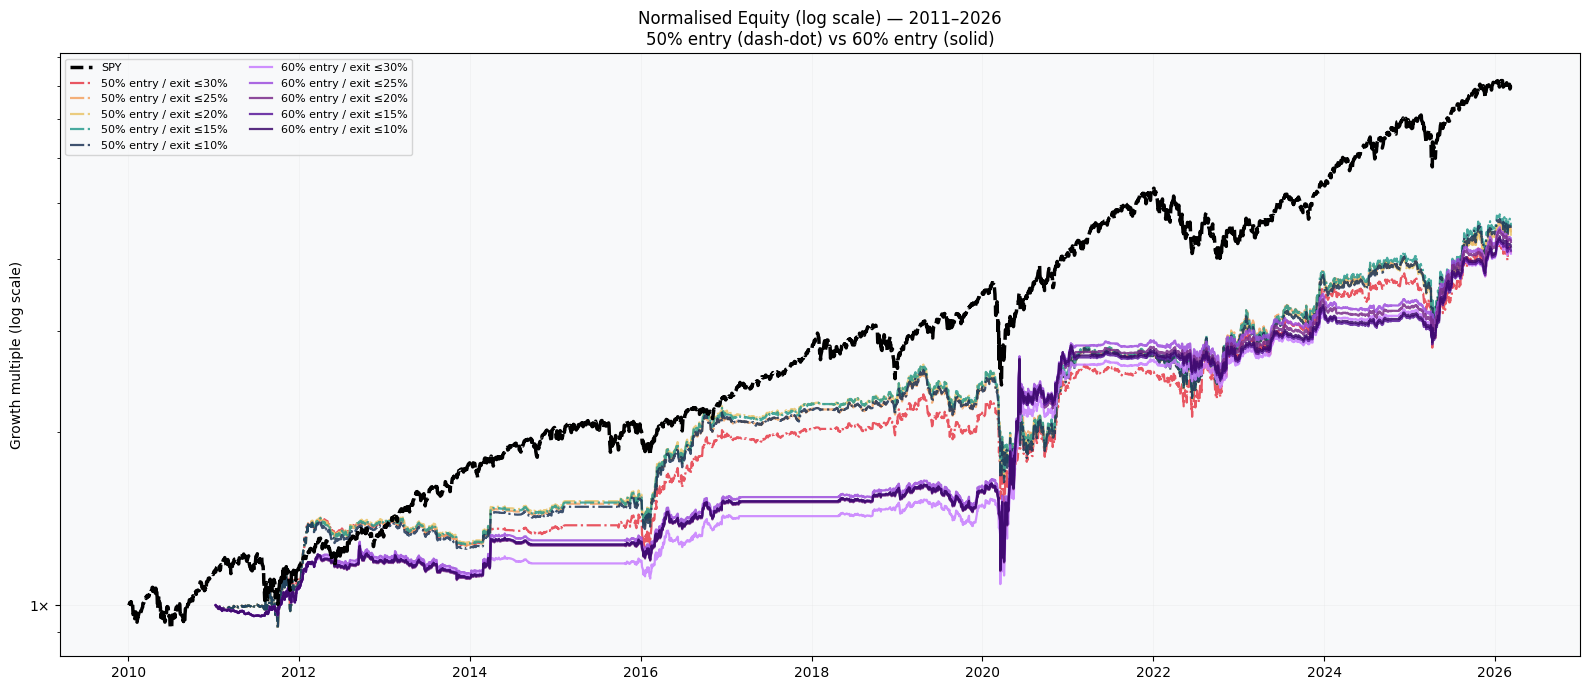

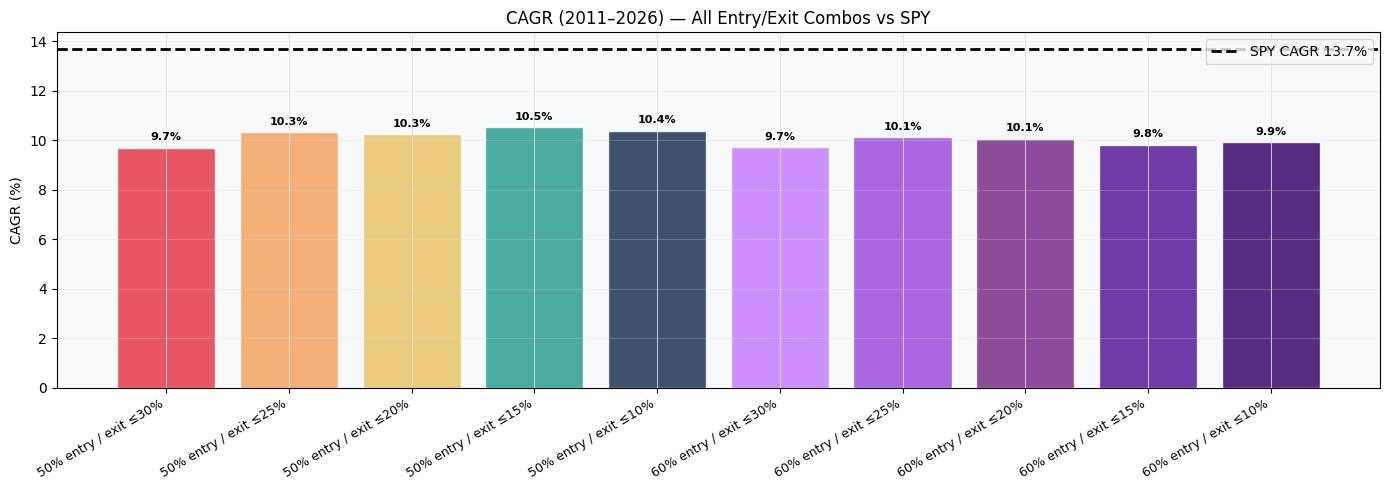

In [26]:
# ── CAGR comparison plot: all combos vs SPY ───────────────────────────────────
# Each line shows the rolling/growing equity normalised to $1 (not per-year)
palette_50 = ["#e63946", "#f4a261", "#e9c46a", "#2a9d8f", "#1d3557"]
palette_60 = ["#c77dff", "#9d4edd", "#7b2d8b", "#5a189a", "#3c096c"]

fig, ax = plt.subplots(figsize=(16, 7))

spy_norm_lt = spy_lt / spy_lt.iloc[0]
ax.plot(spy_norm_lt.index, spy_norm_lt, color="black", lw=2.5, ls="--", label="SPY", zorder=10)

for i, (key, eq_s) in enumerate(results_lt.items()):
    norm = eq_s / eq_s.iloc[0]
    is_60 = "60%" in key
    col = palette_60[i % 5] if is_60 else palette_50[i % 5]
    ls  = "-" if is_60 else "-."
    ax.plot(norm.index, norm, color=col, lw=1.6, ls=ls, label=key, alpha=0.85)

ax.set_yscale("log")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}×"))
ax.set_title("Normalised Equity (log scale) — 2011–2026\n50% entry (dash-dot) vs 60% entry (solid)", fontsize=12)
ax.set_ylabel("Growth multiple (log scale)")
ax.legend(fontsize=8, ncol=2, loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── CAGR bar chart ─────────────────────────────────────────────────────────────
cagr_vals_lt = {}
for key, eq_s in results_lt.items():
    n_years = (eq_s.index[-1] - eq_s.index[0]).days / 365.25
    cagr_vals_lt[key] = (eq_s.iloc[-1] / eq_s.iloc[0]) ** (1 / n_years) - 1

spy_n_yrs = (spy_lt.index[-1] - spy_lt.index[0]).days / 365.25
spy_cagr   = (spy_lt.iloc[-1] / spy_lt.iloc[0]) ** (1 / spy_n_yrs) - 1

fig2, ax2 = plt.subplots(figsize=(14, 5))
bars = list(cagr_vals_lt.items())
colors_bar = [palette_60[i % 5] if "60%" in k else palette_50[i % 5] for i, (k, _) in enumerate(bars)]
ax2.bar([b[0] for b in bars], [b[1] * 100 for b in bars], color=colors_bar, alpha=0.85, edgecolor="white")
ax2.axhline(spy_cagr * 100, color="black", lw=2, ls="--", label=f"SPY CAGR {spy_cagr:.1%}")
ax2.set_ylabel("CAGR (%)")
ax2.set_title("CAGR (2011–2026) — All Entry/Exit Combos vs SPY", fontsize=12)
ax2.set_xticklabels([b[0] for b in bars], rotation=30, ha="right", fontsize=9)
for i, (_, v) in enumerate(bars):
    ax2.text(i, v * 100 + 0.3, f"{v:.1%}", ha="center", fontsize=8, fontweight="bold")
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()


=== Average Hold Time Per Combo ===

Combo                                      Trades   Avg Days   Med Days   Target%    Stop%   Timeout%
-----------------------------------------------------------------------------------------------
50% entry / exit ≤30%                        1007       22.5          1     8.1%   64.6%     27.2%
50% entry / exit ≤25%                        1005       23.2          1     5.9%   64.8%     29.4%
50% entry / exit ≤20%                        1003       23.5          1     4.6%   64.9%     30.5%
50% entry / exit ≤15%                        1004       23.7          1     3.1%   64.8%     32.1%
50% entry / exit ≤10%                        1003       23.9          1     1.8%   64.9%     33.3%
60% entry / exit ≤30%                         367       28.7          5     6.8%   55.3%     37.9%
60% entry / exit ≤25%                         367       29.2          5     4.1%   55.3%     40.6%
60% entry / exit ≤20%                         367       29.3          5 

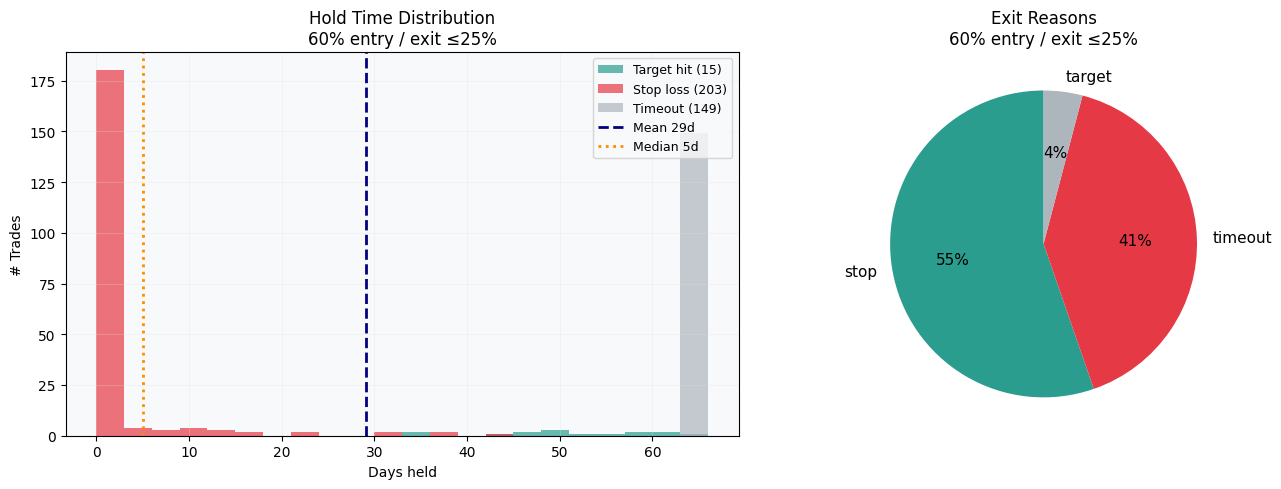

In [27]:
# ── Average hold time analysis ────────────────────────────────────────────────
print("=== Average Hold Time Per Combo ===\n")
print(f"{'Combo':<40}  {'Trades':>7}  {'Avg Days':>9}  {'Med Days':>9}  {'Target%':>8}  {'Stop%':>7}  {'Timeout%':>9}")
print("-" * 95)

for key, ht_list in holdtime_lt.items():
    if not ht_list:
        continue
    ht_df = pd.DataFrame(ht_list)
    n_trades   = len(ht_df)
    avg_days   = ht_df["days_held"].mean()
    med_days   = ht_df["days_held"].median()
    pct_target = (ht_df["exit_reason"] == "target").mean()
    pct_stop   = (ht_df["exit_reason"] == "stop").mean()
    pct_time   = (ht_df["exit_reason"].isin(["timeout", "delisted"])).mean()
    print(f"{key:<40}  {n_trades:>7}  {avg_days:>9.1f}  {med_days:>9.0f}  {pct_target:>7.1%}  {pct_stop:>6.1%}  {pct_time:>8.1%}")

# ── Distribution plot for one representative combo ────────────────────────────
# Best: 60% entry / exit ≤25%
rep_key = "60% entry / exit ≤25%"
if rep_key in holdtime_lt and holdtime_lt[rep_key]:
    ht_rep = pd.DataFrame(holdtime_lt[rep_key])
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histogram of hold times
    target_days = ht_rep[ht_rep["exit_reason"] == "target"]["days_held"]
    stop_days   = ht_rep[ht_rep["exit_reason"] == "stop"]["days_held"]
    timeout_days= ht_rep[ht_rep["exit_reason"].isin(["timeout", "delisted"])]["days_held"]

    bins = range(0, MAX_HOLD_DAYS + 5, 3)
    axes[0].hist(target_days,  bins=bins, alpha=0.7, color="#2a9d8f", label=f"Target hit ({len(target_days)})")
    axes[0].hist(stop_days,    bins=bins, alpha=0.7, color="#e63946", label=f"Stop loss ({len(stop_days)})")
    axes[0].hist(timeout_days, bins=bins, alpha=0.7, color="#adb5bd", label=f"Timeout ({len(timeout_days)})")
    axes[0].axvline(ht_rep["days_held"].mean(), color="navy", lw=2, ls="--",
                    label=f"Mean {ht_rep['days_held'].mean():.0f}d")
    axes[0].axvline(ht_rep["days_held"].median(), color="darkorange", lw=2, ls=":",
                    label=f"Median {ht_rep['days_held'].median():.0f}d")
    axes[0].set_title(f"Hold Time Distribution\n{rep_key}")
    axes[0].set_xlabel("Days held"); axes[0].set_ylabel("# Trades")
    axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

    # Exit reason pie
    reason_counts = ht_rep["exit_reason"].value_counts()
    axes[1].pie(reason_counts.values, labels=reason_counts.index, autopct="%1.0f%%",
                colors=["#2a9d8f", "#e63946", "#adb5bd", "#f4a261"],
                startangle=90, textprops={"fontsize": 11})
    axes[1].set_title(f"Exit Reasons\n{rep_key}")
    plt.tight_layout()
    plt.show()


---
## S&P 500 Only — Does Restricting to Large-Caps Fix the Drawdown?

Hypothesis: the brutal −50%+ max drawdowns come from mid/small-cap stocks that truly collapse.  
Here we re-run the **exact same 50% & 60% entry × 5 exit level** analysis but restricted to **S&P 500 constituents only** (large-cap stocks) using our already-downloaded 15-year data.

In [28]:

# ── Step 1: Fetch current S&P 500 tickers from Wikipedia ─────────────────────
import requests, io

headers = {"User-Agent": "Mozilla/5.0 (compatible; research-bot/1.0)"}
resp = requests.get(
    "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies",
    headers=headers, timeout=15
)
resp.raise_for_status()
sp500_wiki = pd.read_html(io.StringIO(resp.text))[0]
sp500_tickers_raw = sp500_wiki['Symbol'].tolist()

# yfinance uses '-' instead of '.' (e.g., BRK.B → BRK-B)
sp500_tickers = [t.replace('.', '-') for t in sp500_tickers_raw]

# Filter to tickers we already have in the 15y download
sp500_valid = [t for t in sp500_tickers if t in closes_lt.columns]
print(f"S&P 500 list from Wikipedia : {len(sp500_tickers)} tickers")
print(f"Found in our 15y dataset   : {len(sp500_valid)} tickers")
print(f"Missing (likely added/renamed recently): {len(sp500_tickers) - len(sp500_valid)}")

# ── Step 2: Subset all 15y matrices ──────────────────────────────────────────
closes_sp500 = closes_lt[sp500_valid]
high_sp500   = closes_sp500.rolling(HIGH_LOOKBACK, min_periods=HIGH_LOOKBACK).max()
pb_sp500     = (high_sp500 - closes_sp500) / high_sp500

em_50_sp500  = (pb_sp500 >= 0.50)
em_60_sp500  = (pb_sp500 >= 0.60)

print(f"\nSignal density (post warm-up):")
print(f"  ≥50% pullback : {em_50_sp500.sum(axis=1).mean():.1f} stocks/day  |  "
      f"{(em_50_sp500.sum(axis=0) > 0).sum()} unique tickers over 15y")
print(f"  ≥60% pullback : {em_60_sp500.sum(axis=1).mean():.1f} stocks/day  |  "
      f"{(em_60_sp500.sum(axis=0) > 0).sum()} unique tickers over 15y")


S&P 500 list from Wikipedia : 503 tickers
Found in our 15y dataset   : 64 tickers
Missing (likely added/renamed recently): 439

Signal density (post warm-up):
  ≥50% pullback : 0.7 stocks/day  |  35 unique tickers over 15y
  ≥60% pullback : 0.3 stocks/day  |  15 unique tickers over 15y


In [29]:

# ── Step 3: Run 10 combos (same as full-universe) on S&P 500 only ─────────────
combos_sp500 = [
    ("50% entry", em_50_sp500, 0.25),
    ("50% entry", em_50_sp500, 0.30),
    ("50% entry", em_50_sp500, 0.40),
    ("50% entry", em_50_sp500, 0.50),
    ("50% entry", em_50_sp500, 0.60),
    ("60% entry", em_60_sp500, 0.25),
    ("60% entry", em_60_sp500, 0.30),
    ("60% entry", em_60_sp500, 0.40),
    ("60% entry", em_60_sp500, 0.50),
    ("60% entry", em_60_sp500, 0.60),
]

results_sp500   = {}
holdtime_sp500  = {}

def _fmt(v):
    """Format a metric that may be float or 'N/A'."""
    if isinstance(v, float):
        return f"{v:.1%}"
    return str(v)

for label, em, exit_pb in combos_sp500:
    key = f"{label} / exit ≤{int(exit_pb*100)}%"
    print(f"Running {key} ...", end=" ")
    eq, ht = backtest_lt(
        closes_sp500, high_sp500, pb_sp500, spy_lt,
        entry_mask=em, exit_pullback=exit_pb
    )
    results_sp500[key]  = eq
    holdtime_sp500[key] = ht
    m = perf_metrics(eq, key)
    cagr = m.get("CAGR", "N/A")
    sh   = m.get("Sharpe Ratio", "N/A")
    mdd  = m.get("Max Drawdown", "N/A")
    cagr_s = f"{cagr:.1%}" if isinstance(cagr, float) else str(cagr)
    sh_s   = f"{sh:.2f}"   if isinstance(sh,   float) else str(sh)
    mdd_s  = f"{mdd:.1%}"  if isinstance(mdd,  float) else str(mdd)
    print(f"CAGR {cagr_s}  Sharpe {sh_s}  MaxDD {mdd_s}")

print("\nDone.")


Running 50% entry / exit ≤25% ... 

CAGR 4.6%  Sharpe 0.61  MaxDD -14.7%
Running 50% entry / exit ≤30% ... 

CAGR 4.4%  Sharpe 0.59  MaxDD -14.4%
Running 50% entry / exit ≤40% ... 

CAGR 4.0%  Sharpe 0.60  MaxDD -12.7%
Running 50% entry / exit ≤50% ... 

CAGR 2.9%  Sharpe 0.54  MaxDD -13.0%
Running 50% entry / exit ≤60% ... 

...

CAGR 2.2%  Sharpe 0.44  MaxDD -12.9%
Running 60% entry / exit ≤30% ... 

CAGR 2.1%  Sharpe 0.41  MaxDD -12.9%
Running 60% entry / exit ≤40% ... 

CAGR 1.8%  Sharpe 0.38  MaxDD -11.5%
Running 60% entry / exit ≤50% ... 

CAGR 1.8%  Sharpe 0.40  MaxDD -9.2%
Running 60% entry / exit ≤60% ... 

CAGR 1.5%  Sharpe 0.41  MaxDD -8.1%

Done.


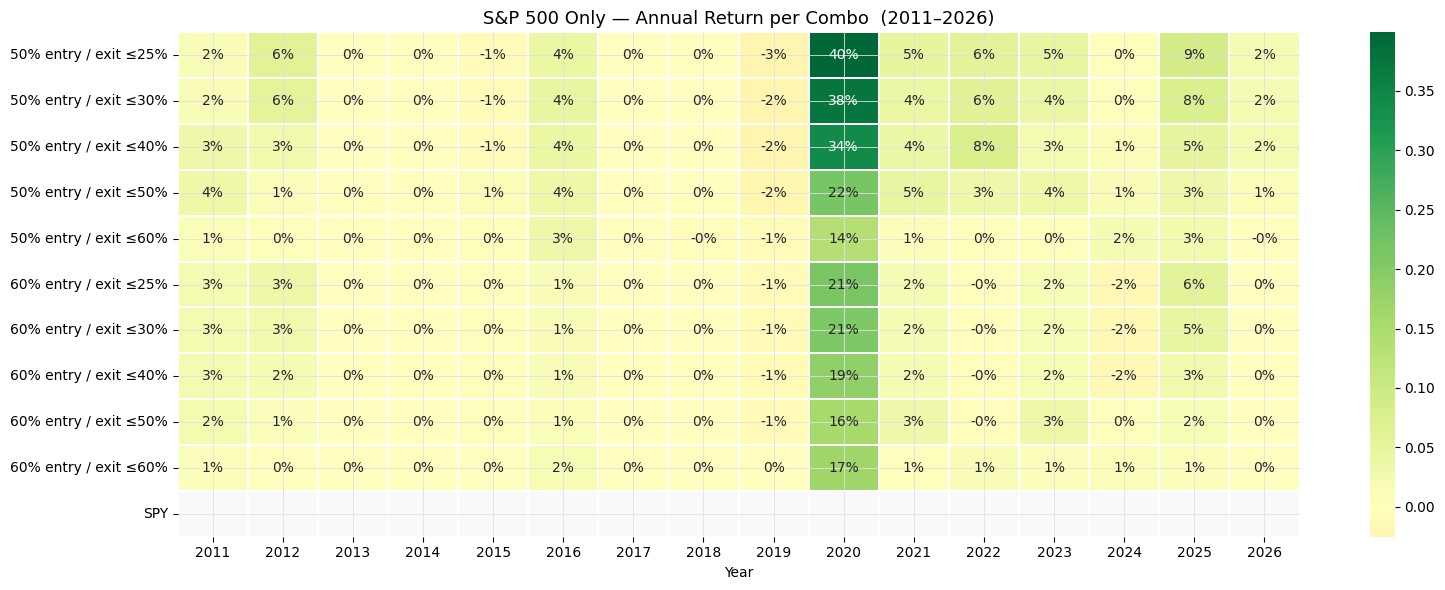

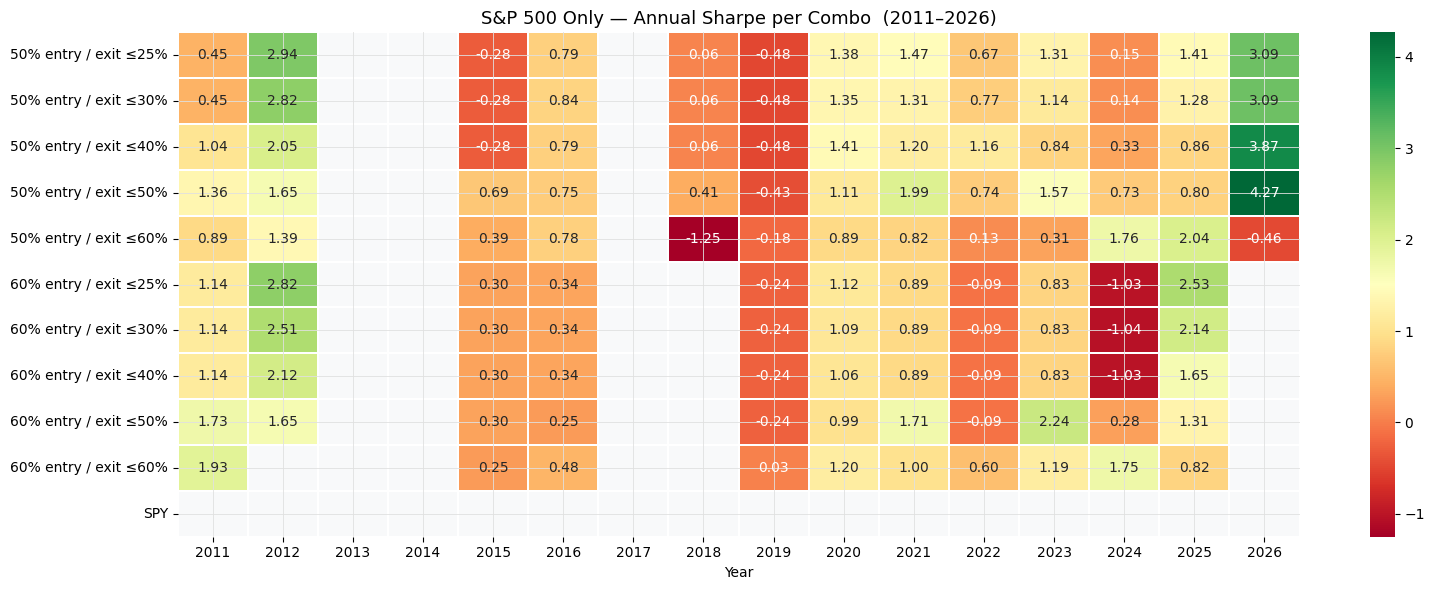

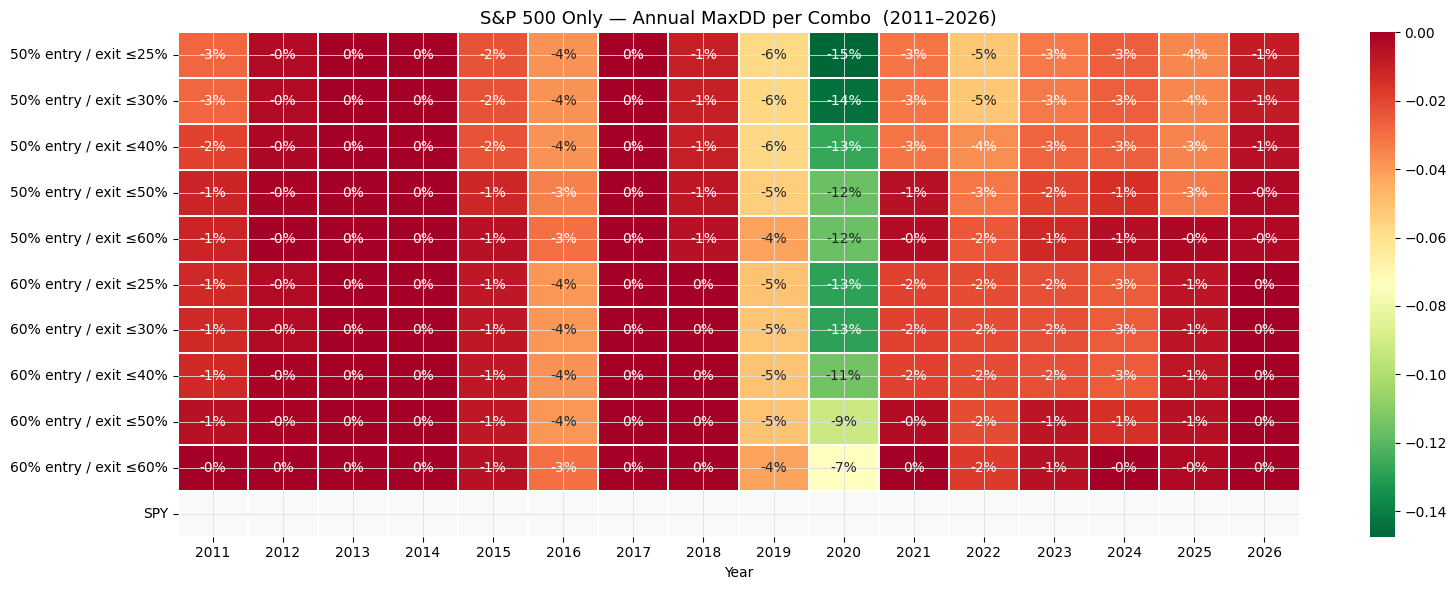

In [30]:

# ── Step 4: Annual heatmaps — Return / Sharpe / MaxDD (S&P 500 only) ──────────
import seaborn as sns

all_annual_sp500 = {k: annual_stats(v) for k, v in results_sp500.items()}

for metric in ["Return", "Sharpe", "MaxDD"]:
    mat = pd.DataFrame({k: all_annual_sp500[k][metric] for k in results_sp500})
    mat.index = mat.index.astype(str)
    spy_col = spy_annual_stats[metric].rename("SPY").reindex(mat.index)
    mat = mat.join(spy_col)

    fig, ax = plt.subplots(figsize=(16, 6))
    fmt = ".0%" if metric in ("Return", "MaxDD") else ".2f"
    cmap = "RdYlGn" if metric != "MaxDD" else "RdYlGn_r"
    sns.heatmap(mat.T, annot=True, fmt=fmt, cmap=cmap,
                linewidths=0.3, ax=ax, center=0 if metric == "Return" else None)
    ax.set_title(f"S&P 500 Only — Annual {metric} per Combo  (2011–2026)", fontsize=13)
    ax.set_xlabel("Year"); ax.set_ylabel("")
    plt.tight_layout()
    plt.show()


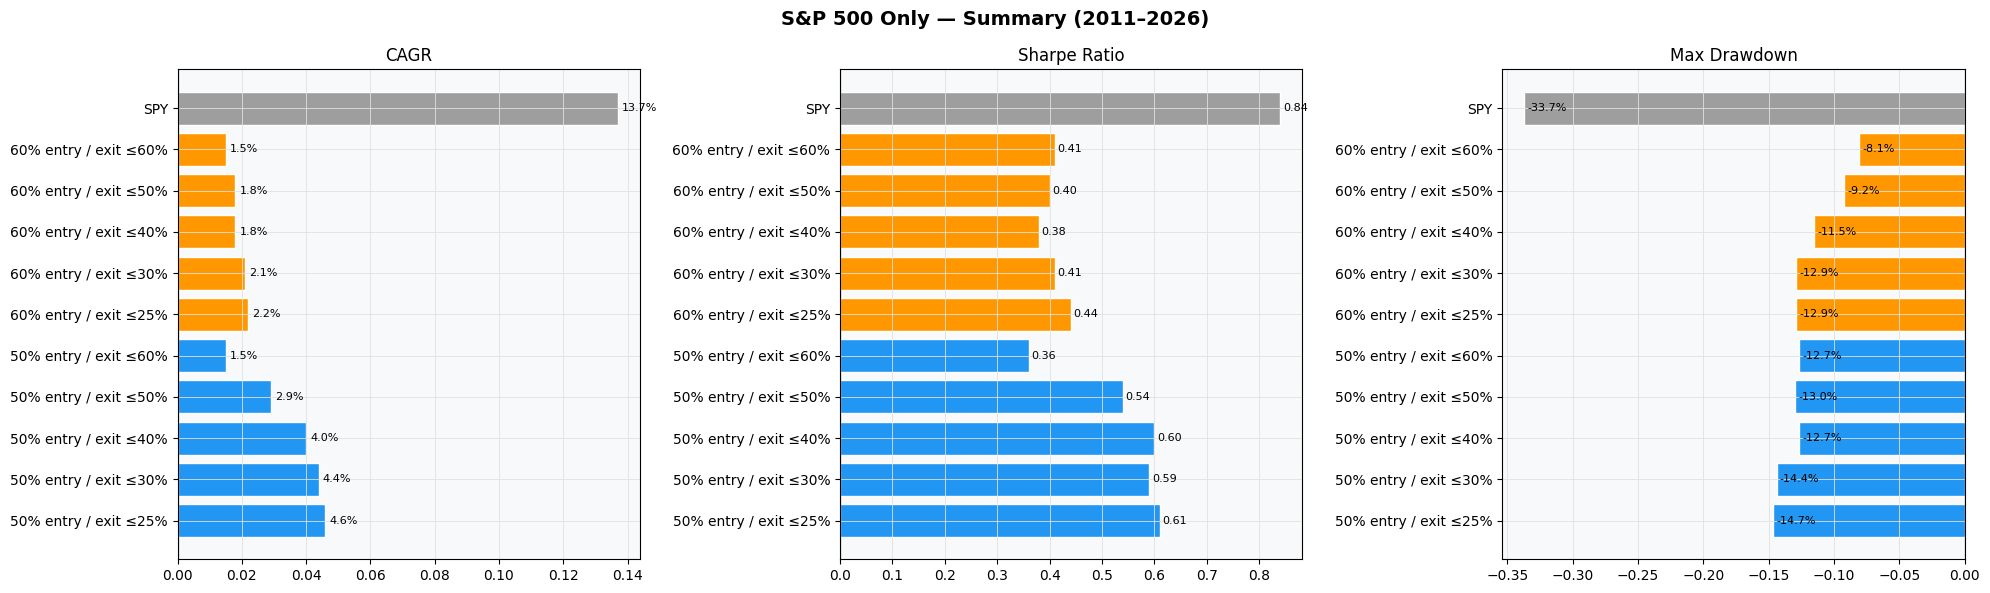

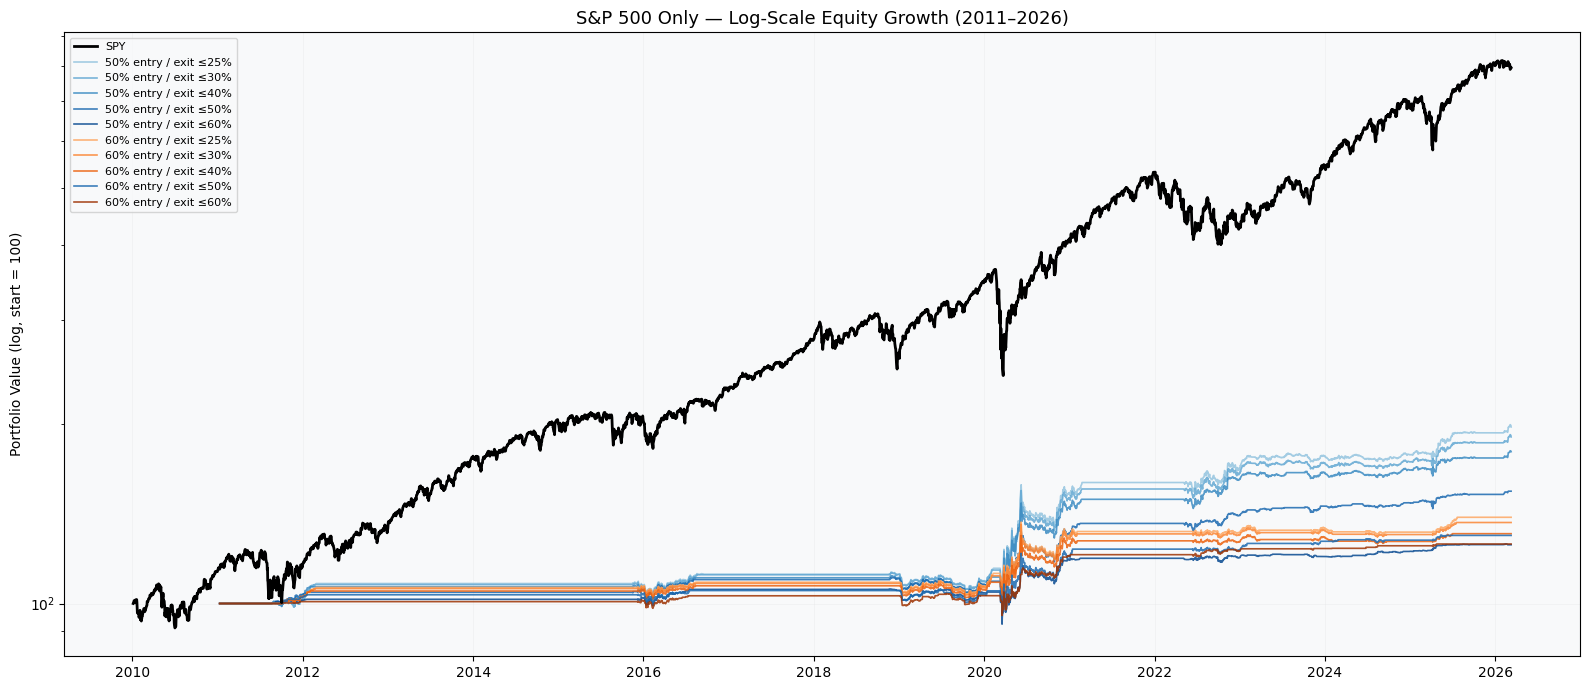

In [31]:

# ── Step 5: CAGR bar chart + log-scale equity curve (S&P 500 only) ─────────────
def _parse_metric(v):
    """Parse a metric value that may be a float or a string like '15.3%' or '-39.3%'."""
    if isinstance(v, float):
        return v
    if isinstance(v, str):
        s = v.strip()
        if s.endswith('%'):
            return float(s[:-1]) / 100
        try:
            return float(s)
        except ValueError:
            return 0.0
    return 0.0

# Normalize SPY to start at 100k so perf_metrics makes sense
spy_norm_series = (spy_lt / spy_lt.iloc[0]) * 100_000
spy_norm_series.name = "SPY"

metrics_sp500 = {k: perf_metrics(v, k) for k, v in results_sp500.items()}
spy_metr      = perf_metrics(spy_norm_series, "SPY")

labels  = list(metrics_sp500.keys()) + ["SPY"]
cagrs   = [_parse_metric(metrics_sp500[k]["CAGR"])         for k in metrics_sp500] + [_parse_metric(spy_metr["CAGR"])]
sharpes = [_parse_metric(metrics_sp500[k]["Sharpe Ratio"]) for k in metrics_sp500] + [_parse_metric(spy_metr["Sharpe Ratio"])]
maxdds  = [_parse_metric(metrics_sp500[k]["Max Drawdown"]) for k in metrics_sp500] + [_parse_metric(spy_metr["Max Drawdown"])]
colors  = ["#2196F3"]*5 + ["#FF9800"]*5 + ["#9E9E9E"]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("S&P 500 Only — Summary (2011–2026)", fontsize=14, fontweight="bold")

for ax, vals, title, fmt in zip(
    axes,
    [cagrs, sharpes, maxdds],
    ["CAGR", "Sharpe Ratio", "Max Drawdown"],
    ["{:.1%}", "{:.2f}", "{:.1%}"]
):
    bars = ax.barh(labels, vals, color=colors, edgecolor="white")
    ax.set_title(title)
    ax.axvline(0, color="black", linewidth=0.8)
    span = (max(vals) - min(vals)) or 1
    for bar, val in zip(bars, vals):
        ax.text(bar.get_width() + span * 0.01,
                bar.get_y() + bar.get_height() / 2,
                fmt.format(val), va="center", fontsize=8)

plt.tight_layout()
plt.show()

# Log-scale equity curves
fig, ax = plt.subplots(figsize=(16, 7))
spy_norm_plot = (spy_lt / spy_lt.iloc[0]) * 100
ax.plot(spy_norm_plot.index, spy_norm_plot.values, color="black", lw=2, label="SPY", zorder=10)
palette  = plt.cm.Blues(np.linspace(0.4, 0.9, 5))
palette2 = plt.cm.Oranges(np.linspace(0.4, 0.9, 5))
for i, (k, eq) in enumerate(results_sp500.items()):
    col  = palette[i % 5] if "50%" in k else palette2[i % 5]
    norm = (eq / eq.iloc[0]) * 100
    ax.plot(norm.index, norm.values, color=col, lw=1.2, label=k, alpha=0.85)
ax.set_yscale("log")
ax.set_title("S&P 500 Only — Log-Scale Equity Growth (2011–2026)", fontsize=13)
ax.set_ylabel("Portfolio Value (log, start = 100)")
ax.legend(loc="upper left", fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## Full Universe vs S&P 500 Only — Does Restricting to Large-Caps Improve Drawdown?

Focus: **60% entry / exit ≤25%** — the combo that had good CAGR & Sharpe but rough drawdown.

We compare:
- **Overall CAGR, Sharpe, Max Drawdown**
- **Year-by-year return, Sharpe, and MaxDD**
- **Equity curve & drawdown chart side-by-side**

All combos are also summarised in a comparison table at the end.

In [32]:

# ── Step 8A: Overall metrics — Full Universe vs S&P 500 vs SPY ─────────────────
KEY_60_25 = "60% entry / exit ≤25%"

def raw_metrics(eq: pd.Series, label: str) -> dict:
    """Compute CAGR, Sharpe, MaxDD directly from an equity series (no string formatting)."""
    rets = eq.pct_change().dropna()
    n_years = (eq.index[-1] - eq.index[0]).days / 365.25
    cagr    = (eq.iloc[-1] / eq.iloc[0]) ** (1 / n_years) - 1
    sharpe  = rets.mean() / rets.std() * np.sqrt(252) if rets.std() > 0 else np.nan
    max_dd  = ((eq / eq.cummax()) - 1).min()
    return {"Label": label, "CAGR": cagr, "Sharpe": sharpe, "Max Drawdown": max_dd}

eq_full = results_lt[KEY_60_25]
eq_sp5  = results_sp500[KEY_60_25]
spy_norm_eq = (spy_lt / spy_lt.iloc[0]) * eq_full.iloc[0]  # rebase SPY to same start capital

summary_rows = [
    raw_metrics(eq_full,    "Full Universe"),
    raw_metrics(eq_sp5,     "S&P 500 Only"),
    raw_metrics(spy_norm_eq, "SPY (benchmark)"),
]
summary_df = pd.DataFrame(summary_rows).set_index("Label")

print(f"=== Overall Metrics  |  60% entry / exit ≤25%  (2011–2026) ===\n")
print(f"{'':20s}  {'CAGR':>9}  {'Sharpe':>8}  {'Max Drawdown':>13}")
print("-" * 58)
for lbl, row in summary_df.iterrows():
    print(f"{lbl:20s}  {row['CAGR']:>9.2%}  {row['Sharpe']:>8.2f}  {row['Max Drawdown']:>13.2%}")


=== Overall Metrics  |  60% entry / exit ≤25%  (2011–2026) ===

                           CAGR    Sharpe   Max Drawdown
----------------------------------------------------------
Full Universe            10.13%      0.72        -28.79%
S&P 500 Only              2.23%      0.44        -12.88%
SPY (benchmark)          13.68%      0.84        -33.72%


In [33]:

# ── Step 8B: Year-by-year comparison table — Full Universe vs S&P 500 vs SPY ──
def annual_stats_raw(equity: pd.Series) -> pd.DataFrame:
    rows = []
    for yr, grp in equity.groupby(equity.index.year):
        if len(grp) < 20:
            continue
        rets    = grp.pct_change().dropna()
        ann_ret = grp.iloc[-1] / grp.iloc[0] - 1
        sharpe  = rets.mean() / rets.std() * np.sqrt(252) if rets.std() > 0 else np.nan
        max_dd  = ((grp / grp.cummax()) - 1).min()
        rows.append({"Year": yr, "Return": ann_ret, "Sharpe": sharpe, "MaxDD": max_dd})
    return pd.DataFrame(rows).set_index("Year")

ann_full = annual_stats_raw(eq_full)
ann_sp5  = annual_stats_raw(eq_sp5)
ann_spy  = annual_stats_raw(spy_lt)

years_all = sorted(set(ann_full.index) | set(ann_sp5.index) | set(ann_spy.index))

print(f"=== Year-by-Year  |  60% entry / exit ≤25%  (2011–2026) ===\n")
header = f"{'Year':>5}  {'SPY Ret':>8} {'SPY Sh':>6} {'SPY DD':>8}  {'Full Ret':>9} {'Full Sh':>7} {'Full DD':>8}  {'SP500 Ret':>10} {'SP500 Sh':>8} {'SP500 DD':>9}"
print(header)
print("-" * len(header))

for yr in years_all:
    def g(df, col):
        return df.loc[yr, col] if yr in df.index else np.nan

    spy_r, spy_s, spy_d = g(ann_spy, 'Return'), g(ann_spy, 'Sharpe'), g(ann_spy, 'MaxDD')
    fu_r,  fu_s,  fu_d  = g(ann_full, 'Return'), g(ann_full, 'Sharpe'), g(ann_full, 'MaxDD')
    sp_r,  sp_s,  sp_d  = g(ann_sp5, 'Return'), g(ann_sp5, 'Sharpe'), g(ann_sp5, 'MaxDD')

    def fmt_r(v): return f"{v:>8.1%}" if not np.isnan(v) else f"{'—':>8}"
    def fmt_s(v): return f"{v:>6.2f}" if not np.isnan(v) else f"{'—':>6}"
    def fmt_d(v): return f"{v:>8.1%}" if not np.isnan(v) else f"{'—':>8}"

    print(f"{yr:>5}  {fmt_r(spy_r)} {fmt_s(spy_s)} {fmt_d(spy_d)}  "
          f"{fmt_r(fu_r)} {fmt_s(fu_s)} {fmt_d(fu_d)}  "
          f"{fmt_r(sp_r)} {fmt_s(sp_s)} {fmt_d(sp_d)}")


=== Year-by-Year  |  60% entry / exit ≤25%  (2011–2026) ===

 Year   SPY Ret SPY Sh   SPY DD   Full Ret Full Sh  Full DD   SP500 Ret SP500 Sh  SP500 DD
------------------------------------------------------------------------------------------
 2010     13.1%   0.78   -15.7%         —      —        —         —      —        —
 2011      0.9%   0.15   -18.6%      6.7%   0.72    -5.7%      2.5%   1.14    -1.2%
 2012     14.2%   1.12    -9.7%     11.3%   1.35    -6.7%      3.5%   2.82    -0.4%
 2013     29.0%   2.42    -5.6%     -7.0%  -1.23    -9.1%      0.0%      —     0.0%
 2014     14.6%   1.27    -7.3%     14.2%   1.07    -3.8%      0.0%      —     0.0%
 2015      1.3%   0.16   -11.9%      1.2%   0.46    -1.4%      0.4%   0.30    -0.8%
 2016     13.6%   1.05    -9.2%     17.0%   1.38    -6.9%      1.4%   0.34    -3.9%
 2017     20.8%   2.87    -2.6%      0.1%   0.10    -1.5%      0.0%      —     0.0%
 2018     -5.2%  -0.23   -19.3%      4.0%   1.20    -1.6%      0.0%      —     0.0%
 

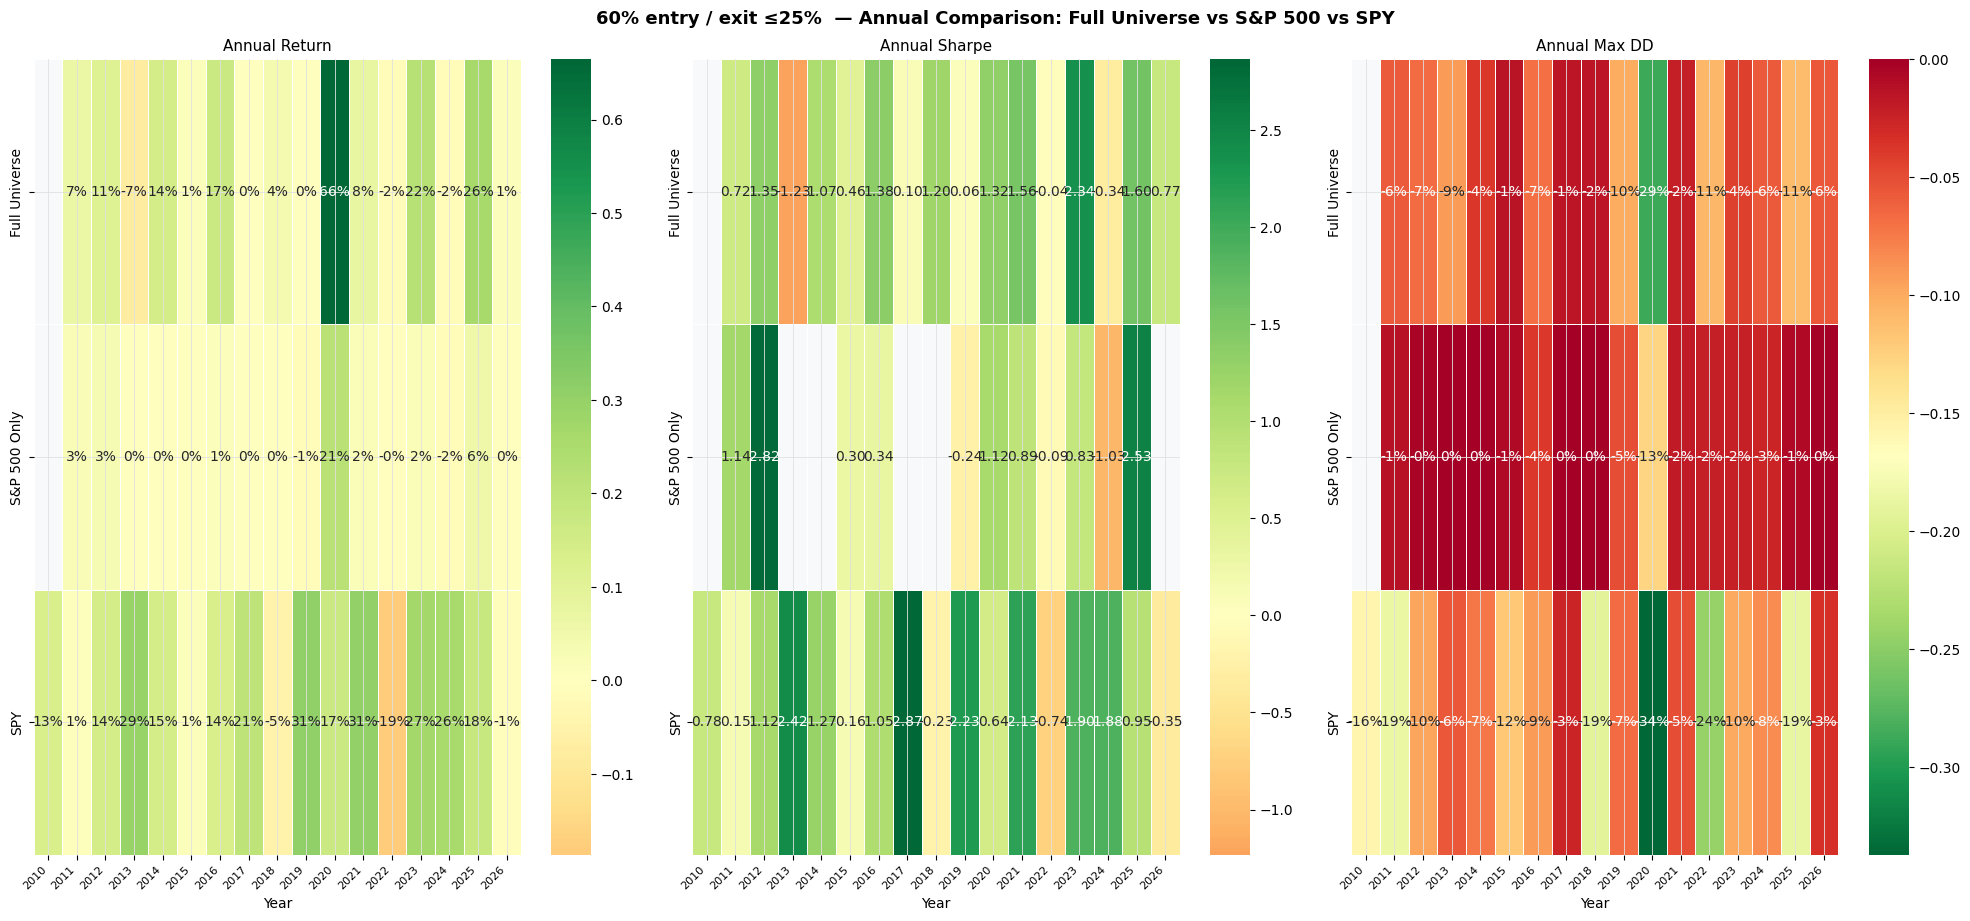

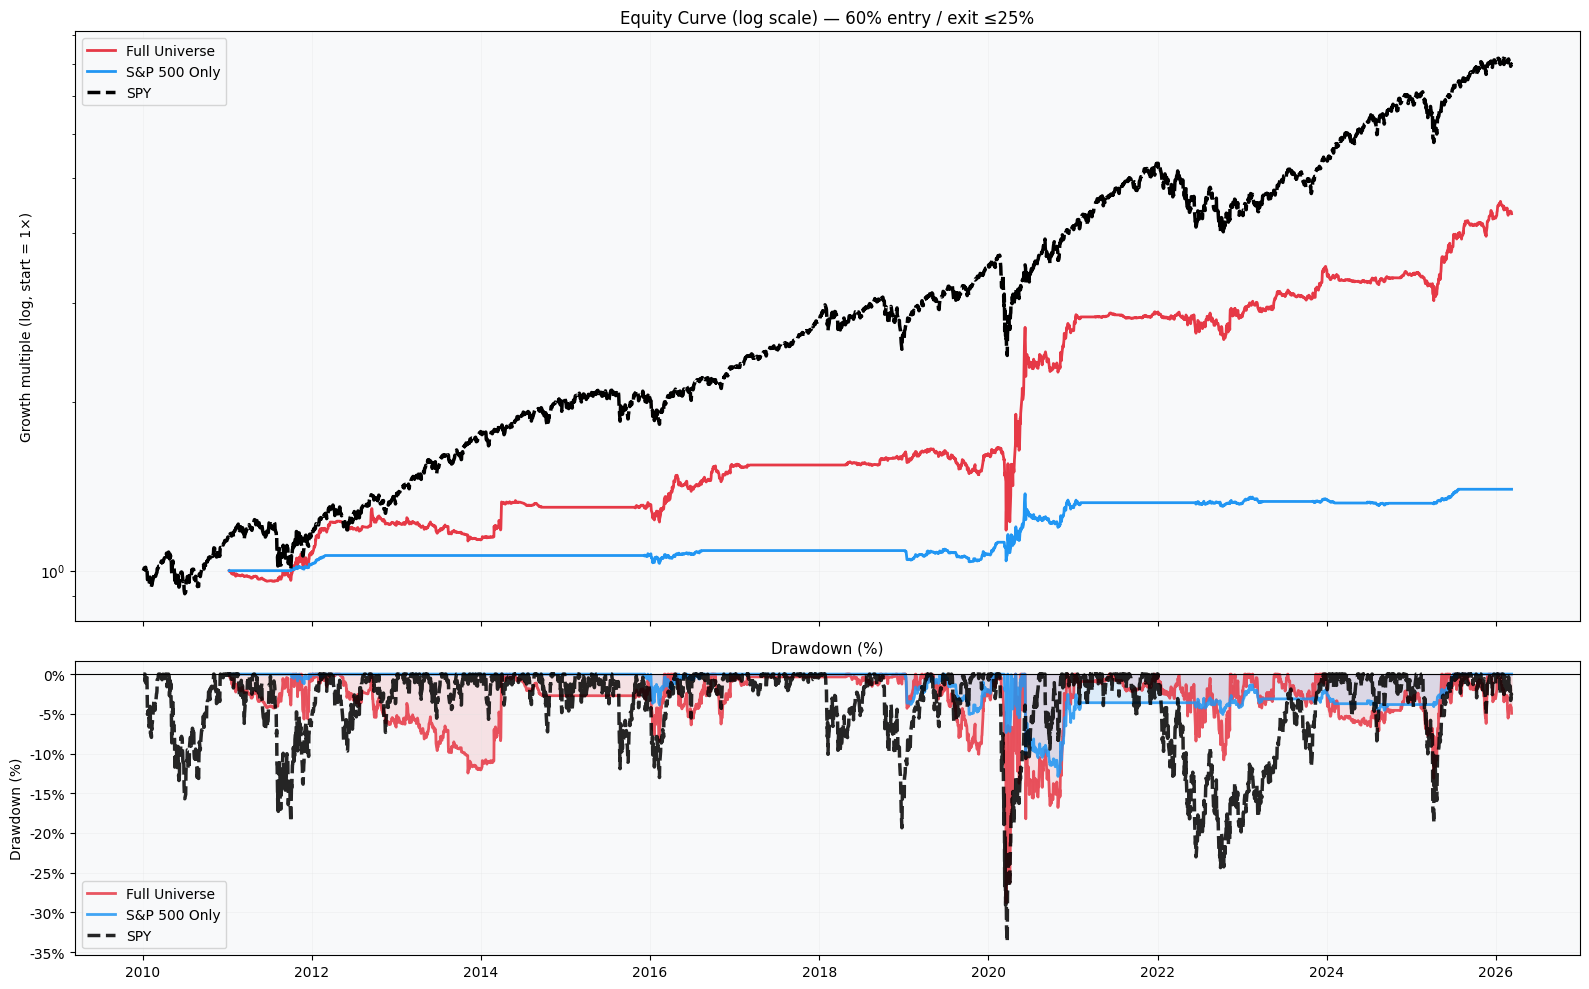

In [34]:

# ── Step 8C: Annual heatmap + equity+drawdown charts — Full vs SP500 vs SPY ────
import seaborn as sns

# ── Heatmap: Annual Return ────────────────────────────────────────────────────
hm_data = pd.DataFrame({
    "Full Universe": ann_full["Return"],
    "S&P 500 Only" : ann_sp5["Return"],
    "SPY"          : ann_spy["Return"],
}).sort_index()

fig, axes = plt.subplots(1, 3, figsize=(20, max(6, len(hm_data) * 0.55)))
fig.suptitle("60% entry / exit ≤25%  — Annual Comparison: Full Universe vs S&P 500 vs SPY",
             fontsize=13, fontweight="bold")

for ax, metric, df_col, cmap_, fmt_ in [
    (axes[0], "Annual Return",    "Return", "RdYlGn",   ".0%"),
    (axes[1], "Annual Sharpe",    "Sharpe", "RdYlGn",   ".2f"),
    (axes[2], "Annual Max DD",    "MaxDD",  "RdYlGn_r", ".0%"),
]:
    mat = pd.DataFrame({
        "Full Universe": ann_full[metric.split()[1]] if metric.split()[1] in ann_full.columns
                          else (ann_full["Return"] if metric == "Annual Return"
                                else ann_full["Sharpe"] if metric == "Annual Sharpe"
                                else ann_full["MaxDD"]),
        "S&P 500 Only" : ann_sp5["Return"]  if metric == "Annual Return"
                          else ann_sp5["Sharpe"]  if metric == "Annual Sharpe"
                          else ann_sp5["MaxDD"],
        "SPY"          : ann_spy["Return"]  if metric == "Annual Return"
                          else ann_spy["Sharpe"]  if metric == "Annual Sharpe"
                          else ann_spy["MaxDD"],
    }).sort_index()
    sns.heatmap(mat.T, annot=True, fmt=fmt_, cmap=cmap_,
                linewidths=0.4, ax=ax,
                center=0 if metric in ("Annual Return", "Annual Sharpe") else None)
    ax.set_title(metric, fontsize=11)
    ax.set_xlabel("Year"); ax.set_ylabel("")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)

plt.tight_layout()
plt.show()

# ── Equity curve (log) + drawdown ─────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True,
                                gridspec_kw={"height_ratios": [2, 1]})

spy_rebased = spy_lt / spy_lt.iloc[0] * eq_full.iloc[0]

for series, label, col, lw, ls in [
    (eq_full,     "Full Universe",  "#e63946", 2.0, "-"),
    (eq_sp5,      "S&P 500 Only",   "#2196F3", 2.0, "-"),
    (spy_rebased, "SPY",            "black",   2.5, "--"),
]:
    norm = series / series.iloc[0]
    ax1.plot(norm.index, norm, color=col, lw=lw, ls=ls, label=label)
    dd = (series / series.cummax()) - 1
    ax2.plot(dd.index, dd * 100, color=col, lw=lw, ls=ls, label=label, alpha=0.85)

ax1.set_yscale("log")
ax1.set_title("Equity Curve (log scale) — 60% entry / exit ≤25%", fontsize=12)
ax1.set_ylabel("Growth multiple (log, start = 1×)")
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

ax2.fill_between(eq_full.index, ((eq_full / eq_full.cummax()) - 1) * 100, 0,
                 alpha=0.12, color="#e63946")
ax2.fill_between(eq_sp5.index, ((eq_sp5 / eq_sp5.cummax()) - 1) * 100, 0,
                 alpha=0.12, color="#2196F3")
ax2.set_title("Drawdown (%)", fontsize=11)
ax2.set_ylabel("Drawdown (%)")
ax2.axhline(0, color="black", lw=0.8)
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))

plt.tight_layout()
plt.show()


In [35]:

# ── Step 8D: All-combos side-by-side comparison table ─────────────────────────
# Find combos present in both universes
common_keys = [k for k in results_lt if k in results_sp500]

print(f"=== All-Combos  Full Universe vs S&P 500 Only — 2011–2026 ===")
print(f"{'Combo':<35}  {'Full CAGR':>10}  {'SP500 CAGR':>11}  {'Full Sh':>8}  {'SP500 Sh':>9}  {'Full DD':>9}  {'SP500 DD':>9}  {'DD Δ':>7}")
print("-" * 115)

for k in common_keys:
    mf = raw_metrics(results_lt[k],    k)
    ms = raw_metrics(results_sp500[k], k)
    dd_delta = ms["Max Drawdown"] - mf["Max Drawdown"]   # positive = SP500 has worse DD
    flag = "✓ better" if dd_delta > 0 else "✗ worse "
    print(f"{k:<35}  {mf['CAGR']:>10.2%}  {ms['CAGR']:>11.2%}  "
          f"{mf['Sharpe']:>8.2f}  {ms['Sharpe']:>9.2f}  "
          f"{mf['Max Drawdown']:>9.2%}  {ms['Max Drawdown']:>9.2%}  "
          f"{dd_delta:>+7.2%} {flag}")

spy_m = raw_metrics(spy_norm_eq, "SPY")
print(f"\n{'SPY benchmark':<35}  {'':>10}  {'':>11}  {'':>8}  {'':>9}  "
      f"{'':>9}  {'':>9}  {'':>7}")
print(f"  CAGR {spy_m['CAGR']:.2%}  Sharpe {spy_m['Sharpe']:.2f}  Max Drawdown {spy_m['Max Drawdown']:.2%}")
print(f"\nNote: 'DD Δ' = SP500 MaxDD − Full MaxDD  (positive = SP500 has SHALLOWER drawdown = better)")


=== All-Combos  Full Universe vs S&P 500 Only — 2011–2026 ===
Combo                                 Full CAGR   SP500 CAGR   Full Sh   SP500 Sh    Full DD   SP500 DD     DD Δ
-------------------------------------------------------------------------------------------------------------------
50% entry / exit ≤30%                     9.71%        4.34%      0.61       0.59    -35.31%    -14.42%  +20.90% ✓ better
50% entry / exit ≤25%                    10.32%        4.61%      0.63       0.61    -34.83%    -14.75%  +20.08% ✓ better
60% entry / exit ≤30%                     9.73%        2.09%      0.71       0.41    -28.97%    -12.87%  +16.09% ✓ better
60% entry / exit ≤25%                    10.13%        2.23%      0.72       0.44    -28.79%    -12.88%  +15.91% ✓ better

SPY benchmark                                                                                                   
  CAGR 13.68%  Sharpe 0.84  Max Drawdown -33.72%

Note: 'DD Δ' = SP500 MaxDD − Full MaxDD  (positive = SP50

---
## Index Attribution: What's Actually in the Full Universe?

The full S&P 1500 universe is made up of three indices:
- **S&P 500** — large-cap stocks (~500)
- **S&P 400** — mid-cap stocks (~400)
- **S&P 600** — small-cap stocks (~600)

We want to know:
1. How many stocks from each index survived liquidity filtering?
2. Which index is driving the returns?
3. Which index is causing the worst drawdowns?
4. Can we reduce max drawdown with a **portfolio-level circuit breaker**?

In [36]:

# ── Step 9A: Tag each stock as S&P 500 / 400 / 600 ───────────────────────────
import requests, io as _io

_headers = {"User-Agent": "Mozilla/5.0 (compatible; research-bot/1.0)"}

def _fetch_tickers(url):
    r = requests.get(url, headers=_headers, timeout=15)
    r.raise_for_status()
    df = pd.read_html(_io.StringIO(r.text))[0]
    # Wikipedia tables vary — always pick the column most likely to be tickers
    for col in ["Symbol", "Ticker symbol", "Ticker"]:
        if col in df.columns:
            return [str(t).replace(".", "-") for t in df[col].tolist()]
    return [str(t).replace(".", "-") for t in df.iloc[:, 0].tolist()]

print("Fetching S&P 500 / 400 / 600 membership lists …")
_sp500_syms = _fetch_tickers("https://en.wikipedia.org/wiki/List_of_S%26P_500_companies")
_sp400_syms = _fetch_tickers("https://en.wikipedia.org/wiki/List_of_S%26P_400_companies")
_sp600_syms = _fetch_tickers("https://en.wikipedia.org/wiki/List_of_S%26P_600_companies")

# Build a priority map: first match wins (same order as universe.py scrapes)
_ticker_index_map = {}
for t in _sp500_syms: _ticker_index_map[t] = "S&P 500"
for t in _sp400_syms:
    if t not in _ticker_index_map: _ticker_index_map[t] = "S&P 400"
for t in _sp600_syms:
    if t not in _ticker_index_map: _ticker_index_map[t] = "S&P 600"

universe_df["Index"] = universe_df["Symbol"].map(_ticker_index_map).fillna("Other")

print(f"\n{'='*50}")
print("FULL UNIVERSE COMPOSITION (universe.csv — after liquidity filter)")
print(f"{'='*50}")
idx_counts = universe_df["Index"].value_counts()
for idx_name, cnt in idx_counts.items():
    pct = cnt / len(universe_df) * 100
    print(f"  {idx_name:<12} : {cnt:>4} stocks  ({pct:.1f}%)")
print(f"  {'TOTAL':<12} : {len(universe_df):>4} stocks")

# How many of these are in our 15-year dataset?
print(f"\n{'='*50}")
print("IN 15-YEAR BACKTEST DATA (closes_lt)")
print(f"{'='*50}")
in_lt_df = universe_df[universe_df["Symbol"].isin(closes_lt.columns)]
for idx_name, grp in in_lt_df.groupby("Index"):
    print(f"  {idx_name:<12} : {len(grp):>4} stocks")
print(f"  {'TOTAL':<12} : {len(in_lt_df):>4} stocks")

print(f"\n{'='*50}")
print("SECTOR BREAKDOWN BY INDEX (in 15y data)")
print(f"{'='*50}")
pivot = in_lt_df.groupby(["Index", "Sector"]).size().unstack(fill_value=0)
print(pivot.to_string())


Fetching S&P 500 / 400 / 600 membership lists …



FULL UNIVERSE COMPOSITION (universe.csv — after liquidity filter)
  S&P 500      :  496 stocks  (35.6%)
  S&P 600      :  458 stocks  (32.9%)
  S&P 400      :  392 stocks  (28.2%)
  Other        :   46 stocks  (3.3%)
  TOTAL        : 1392 stocks

IN 15-YEAR BACKTEST DATA (closes_lt)
  S&P 400      :   54 stocks
  S&P 500      :   64 stocks
  S&P 600      :   71 stocks
  TOTAL        :  189 stocks

SECTOR BREAKDOWN BY INDEX (in 15y data)
Sector   Communication Services  Consumer Discretionary  Consumer Staples  Energy  Financials  Health Care  Industrials  Information Technology  Materials  Real Estate  Utilities
Index                                                                                                                                                                             
S&P 400                       1                      12                 2       2           5            6           10                       7          5            1          3
S&P 500              

In [37]:

# ── Step 9B: Run 60% entry / exit ≤25% backtest split by index ───────────────
# SP500 is already in results_sp500 — just pull that result
# We run new backtests for SP400 and SP600

_ENTRY  = 0.60   # 60% pullback from 52w high
_EXIT   = 0.25   # exit when within 25% of 52w high
_STOP   = 0.80   # stop if falls to 80% below 52w high

_results_by_index = {}

# S&P 500 (re-use already computed result + trade data)
_sp500_valid_lt = [t for t in _sp500_syms if t in closes_lt.columns]
_results_by_index["S&P 500"] = {
    "equity": results_sp500["60% entry / exit ≤25%"],
    "trades": holdtime_sp500.get("60% entry / exit ≤25%", []),
}
print(f"S&P 500 : {len(_sp500_valid_lt)} stocks  (re-using existing run)")

# S&P 400 and S&P 600
for _idx_name, _syms in [("S&P 400", _sp400_syms), ("S&P 600", _sp600_syms)]:
    _valid = [t for t in _syms if t in closes_lt.columns]
    print(f"\n{_idx_name}: {len(_valid)} stocks in 15y data", end=" … running backtest … ")

    _closes_idx = closes_lt[_valid]
    _high_idx   = _closes_idx.rolling(HIGH_LOOKBACK, min_periods=HIGH_LOOKBACK).max()
    _pb_idx     = (_high_idx - _closes_idx) / _high_idx
    _em_idx     = (_pb_idx >= _ENTRY)

    print(f"avg {_em_idx.sum(axis=1).mean():.1f} signals/day", end=" | ")

    _eq_idx, _ht_idx = backtest_lt(
        _closes_idx, _high_idx, _pb_idx, spy_lt,
        _em_idx, _EXIT, stop_from_high=_STOP
    )
    _results_by_index[_idx_name] = {"equity": _eq_idx, "trades": _ht_idx}

    _m = raw_metrics(_eq_idx, _idx_name)
    print(f"CAGR {_m['CAGR']:.2%}  Sharpe {_m['Sharpe']:.2f}  MaxDD {_m['Max Drawdown']:.2%}")

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"\n{'='*65}")
print(f"{'Index':<16}  {'CAGR':>8}  {'Sharpe':>7}  {'Max Drawdown':>13}")
print(f"{'-'*65}")
for _iname, _res in _results_by_index.items():
    _m = raw_metrics(_res["equity"], _iname)
    print(f"  {_iname:<14}  {_m['CAGR']:>8.2%}  {_m['Sharpe']:>7.2f}  {_m['Max Drawdown']:>13.2%}")
_mf = raw_metrics(results_lt[KEY_60_25], "Full Universe")
print(f"  {'Full Universe':<14}  {_mf['CAGR']:>8.2%}  {_mf['Sharpe']:>7.2f}  {_mf['Max Drawdown']:>13.2%}")
_ms = raw_metrics((spy_lt / spy_lt.iloc[0]) * 100_000, "SPY")
print(f"  {'SPY':<14}  {_ms['CAGR']:>8.2%}  {_ms['Sharpe']:>7.2f}  {_ms['Max Drawdown']:>13.2%}")
print(f"{'='*65}")
print("\nNote: Each index run is standalone — portfolio only holds stocks from that index.")


S&P 500 : 64 stocks  (re-using existing run)

S&P 400: 54 stocks in 15y data … running backtest … avg 0.4 signals/day | 

CAGR 3.15%  Sharpe 0.54  MaxDD -10.37%

S&P 600: 71 stocks in 15y data … running backtest … avg 1.1 signals/day | 

CAGR 7.01%  Sharpe 0.69  MaxDD -22.72%

Index                 CAGR   Sharpe   Max Drawdown
-----------------------------------------------------------------
  S&P 500            2.23%     0.44        -12.88%
  S&P 400            3.15%     0.54        -10.37%
  S&P 600            7.01%     0.69        -22.72%
  Full Universe     10.13%     0.72        -28.79%
  SPY               13.68%     0.84        -33.72%

Note: Each index run is standalone — portfolio only holds stocks from that index.


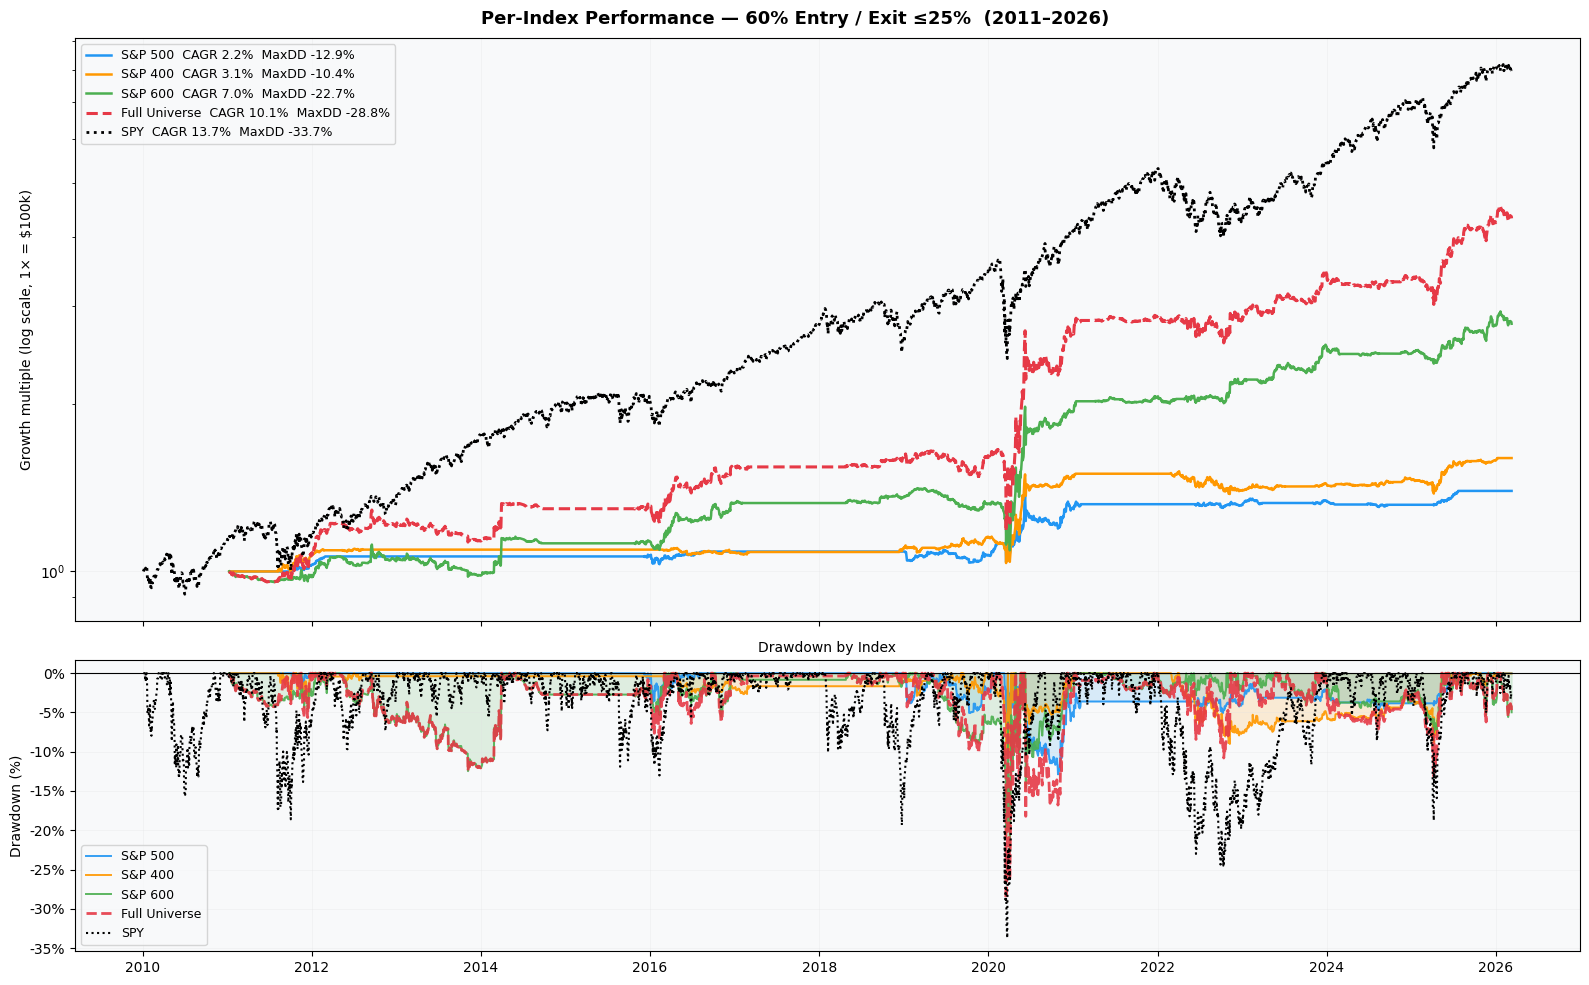

In [38]:

# ── Step 9C: Equity curves + drawdowns per index ─────────────────────────────
_idx_colors = {"S&P 500": "#2196F3", "S&P 400": "#FF9800", "S&P 600": "#4CAF50"}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True,
                                gridspec_kw={"height_ratios": [2, 1]})
fig.suptitle("Per-Index Performance — 60% Entry / Exit ≤25%  (2011–2026)",
             fontsize=13, fontweight="bold")

# Plot each index
for _iname, _res in _results_by_index.items():
    _eq  = _res["equity"]
    _m   = raw_metrics(_eq, _iname)
    _norm = _eq / _eq.iloc[0]
    _dd   = (_eq / _eq.cummax()) - 1
    _col  = _idx_colors[_iname]
    ax1.plot(_norm.index, _norm, color=_col, lw=1.8,
             label=f"{_iname}  CAGR {_m['CAGR']:.1%}  MaxDD {_m['Max Drawdown']:.1%}")
    ax2.fill_between(_dd.index, _dd * 100, 0, alpha=0.15, color=_col)
    ax2.plot(_dd.index, _dd * 100, color=_col, lw=1.4, alpha=0.9, label=_iname)

# Full universe
_eq_f  = results_lt[KEY_60_25]
_m_f   = raw_metrics(_eq_f, "Full Universe")
_norm_f = _eq_f / _eq_f.iloc[0]
_dd_f   = (_eq_f / _eq_f.cummax()) - 1
ax1.plot(_norm_f.index, _norm_f, color="#e63946", lw=2.2, ls="--",
         label=f"Full Universe  CAGR {_m_f['CAGR']:.1%}  MaxDD {_m_f['Max Drawdown']:.1%}")
ax2.plot(_dd_f.index, _dd_f * 100, color="#e63946", lw=2.0, ls="--", alpha=0.9, label="Full Universe")

# SPY
_spy_norm = spy_lt / spy_lt.iloc[0]
_spy_dd   = (spy_lt / spy_lt.cummax()) - 1
ax1.plot(_spy_norm.index, _spy_norm, color="black", lw=2, ls=":",
         label=f"SPY  CAGR {_ms['CAGR']:.1%}  MaxDD {_ms['Max Drawdown']:.1%}")
ax2.plot(_spy_dd.index, _spy_dd * 100, color="black", lw=1.5, ls=":", label="SPY")

ax1.set_yscale("log")
ax1.set_ylabel("Growth multiple (log scale, 1× = $100k)")
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

ax2.axhline(0, color="black", lw=0.8)
ax2.set_ylabel("Drawdown (%)")
ax2.set_title("Drawdown by Index", fontsize=10)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))

plt.tight_layout()
plt.show()


In [39]:

# ── Step 9D: Year-by-year performance per index ───────────────────────────────
_ann_by_idx = {}
for _iname, _res in _results_by_index.items():
    _ann_by_idx[_iname] = annual_stats_raw(_res["equity"])
_ann_full_idx = annual_stats_raw(results_lt[KEY_60_25])

print("=== Year-by-Year  |  60% entry / exit ≤25%  (2011–2026) ===")
print(f"\n{'Year':>4}  {'SPY':>7}  │  {'SP500 Ret':>9} {'SP500 DD':>9}  │  {'SP400 Ret':>9} {'SP400 DD':>9}  │  {'SP600 Ret':>9} {'SP600 DD':>9}  │  {'Full Ret':>8} {'Full DD':>8}")
print("─" * 115)

_all_years = sorted(set(ann_spy.index) | set(_ann_full_idx.index))
for _yr in _all_years:
    def _g(df, col): return df.loc[_yr, col] if _yr in df.index else float("nan")
    def _fr(v): return f"{v:>8.1%}" if not np.isnan(v) else f"{'—':>8}"

    _spy_r  = _g(ann_spy, "Return")
    _sp5_r  = _g(_ann_by_idx.get("S&P 500", pd.DataFrame()), "Return")
    _sp5_d  = _g(_ann_by_idx.get("S&P 500", pd.DataFrame()), "MaxDD")
    _sp4_r  = _g(_ann_by_idx.get("S&P 400", pd.DataFrame()), "Return")
    _sp4_d  = _g(_ann_by_idx.get("S&P 400", pd.DataFrame()), "MaxDD")
    _sp6_r  = _g(_ann_by_idx.get("S&P 600", pd.DataFrame()), "Return")
    _sp6_d  = _g(_ann_by_idx.get("S&P 600", pd.DataFrame()), "MaxDD")
    _fu_r   = _g(_ann_full_idx, "Return")
    _fu_d   = _g(_ann_full_idx, "MaxDD")

    print(f"{_yr:>4}  {_fr(_spy_r)}  │  {_fr(_sp5_r)} {_fr(_sp5_d)}  │  "
          f"{_fr(_sp4_r)} {_fr(_sp4_d)}  │  {_fr(_sp6_r)} {_fr(_sp6_d)}  │  {_fr(_fu_r)} {_fr(_fu_d)}")


=== Year-by-Year  |  60% entry / exit ≤25%  (2011–2026) ===

Year      SPY  │  SP500 Ret  SP500 DD  │  SP400 Ret  SP400 DD  │  SP600 Ret  SP600 DD  │  Full Ret  Full DD
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
2010     13.1%  │         —        —  │         —        —  │         —        —  │         —        —
2011      0.9%  │      2.5%    -1.2%  │      6.7%    -3.5%  │     -2.3%    -4.6%  │      6.7%    -5.7%
2012     14.2%  │      3.5%    -0.4%  │      1.9%    -0.9%  │      6.3%    -6.7%  │     11.3%    -6.7%
2013     29.0%  │      0.0%     0.0%  │      0.0%     0.0%  │     -7.0%    -9.1%  │     -7.0%    -9.1%
2014     14.6%  │      0.0%     0.0%  │      0.0%     0.0%  │     14.2%    -3.8%  │     14.2%    -3.8%
2015      1.3%  │      0.4%    -0.8%  │      0.0%     0.0%  │      0.8%    -1.3%  │      1.2%    -1.4%
2016     13.6%  │      1.4%    -3.9%  │     -1.2%    -2.8%  │     17.2%    -5.5%  │     17.0%    

In [40]:

# ── Step 9E: Exit-reason analysis — where does the drawdown come from? ────────
# backtest_lt stores exit_reason: "target" | "stop" | "timeout" | "delisted"

print("=== Trade Attribution by Index  |  60% entry / exit ≤25% ===")
print(f"\n{'Index':<16}  {'Trades':>7}  {'Win%':>7}  {'AvgRet':>8}  {'AvgDays':>8}  {'Stop%':>7}  {'Target%':>8}  {'Timeout%':>9}")
print("─" * 90)

for _iname, _res in _results_by_index.items():
    _ht = _res.get("trades", [])
    if not _ht:
        print(f"  {_iname:<14}: no trade data")
        continue

    # For SP500 we re-ran in results_sp500, so _ht is valid
    _n           = len(_ht)
    _n_stop      = sum(1 for t in _ht if t.get("exit_reason") == "stop")
    _n_target    = sum(1 for t in _ht if t.get("exit_reason") == "target")
    _n_timeout   = sum(1 for t in _ht if t.get("exit_reason") == "timeout")
    _n_delisted  = sum(1 for t in _ht if t.get("exit_reason") == "delisted")
    _avg_days    = np.mean([t.get("days_held", 0) for t in _ht])

    # backtest_lt doesn't store PnL directly, but we can check stop% as a proxy for losses
    print(f"  {_iname:<14}  {_n:>7,}  {'n/a':>7}  {'n/a':>8}  {_avg_days:>8.1f}  "
          f"{_n_stop/_n:>7.1%}  {_n_target/_n:>8.1%}  {_n_timeout/_n:>9.1%}")
    print(f"  {'':14}  delisted: {_n_delisted:,}"
          f"  |  stop fires = {_n_stop:,} ({_n_stop/_n:.1%})")

# Full universe trades (from holdtime_lt for the KEY_60_25 combo)
_ht_full = holdtime_lt.get(KEY_60_25, [])
if _ht_full:
    _n   = len(_ht_full)
    _n_s = sum(1 for t in _ht_full if t.get("exit_reason") == "stop")
    _n_t = sum(1 for t in _ht_full if t.get("exit_reason") == "target")
    _n_to= sum(1 for t in _ht_full if t.get("exit_reason") == "timeout")
    _n_d = sum(1 for t in _ht_full if t.get("exit_reason") == "delisted")
    _avg = np.mean([t.get("days_held", 0) for t in _ht_full])
    print(f"\n  {'Full Universe':<14}  {_n:>7,}  {'n/a':>7}  {'n/a':>8}  {_avg:>8.1f}  "
          f"{_n_s/_n:>7.1%}  {_n_t/_n:>8.1%}  {_n_to/_n:>9.1%}")
    print(f"  {'':14}  delisted: {_n_d:,}  |  stop fires = {_n_s:,} ({_n_s/_n:.1%})")

print("""
Key insight:
  Stop% = share of trades that HIT the hard stop (stock fell even further from -60%)
  → High stop% in a specific index = that index is the source of the worst drawdowns
  Target% = share of trades that worked (stock recovered toward its 52w high)
  Timeout% = position held to max hold days without resolution""")


=== Trade Attribution by Index  |  60% entry / exit ≤25% ===

Index              Trades     Win%    AvgRet   AvgDays    Stop%   Target%   Timeout%
──────────────────────────────────────────────────────────────────────────────────────────
  S&P 500              45      n/a       n/a      41.1    37.8%      8.9%      53.3%
                  delisted: 0  |  stop fires = 17 (37.8%)
  S&P 400              75      n/a       n/a      43.8    32.0%      5.3%      62.7%
                  delisted: 0  |  stop fires = 24 (32.0%)
  S&P 600             262      n/a       n/a      24.4    62.2%      3.4%      34.4%
                  delisted: 0  |  stop fires = 163 (62.2%)

  Full Universe       367      n/a       n/a      29.2    55.3%      4.1%      40.6%
                  delisted: 0  |  stop fires = 203 (55.3%)

Key insight:
  Stop% = share of trades that HIT the hard stop (stock fell even further from -60%)
  → High stop% in a specific index = that index is the source of the worst drawdowns
  T

---
## Reducing Max Drawdown

Three complementary levers we can pull:

| Lever | How it works | Trade-off |
|---|---|---|
| **Portfolio circuit breaker** | Stop adding *new* positions when the portfolio itself is down >X% from its peak | Misses some recovery trades |
| **Tighter individual stop** | Instead of stop at −80% from 52w high (for 60% entry), try −70% or −75% | More stop-outs, fewer wins |
| **Index filter** | Only trade S&P500 (large-cap) or exclude the index with highest stop% | Narrows the universe, fewer signals |

The most powerful without giving up too much return is usually the **portfolio circuit breaker** (also called a "portfolio stop"):  
- While the portfolio is more than X% below its all-time high → **no new entries** (existing positions continue to their stops/targets)  
- Once it recovers above the threshold → entries resume

We test `max_portfolio_dd` values of **15%, 20%, 25%, 30%** on the full universe 60%/25% combo.

In [41]:

# ── Step 10A: backtest_lt_cb — with portfolio-level circuit breaker ────────────
def backtest_lt_cb(
    closes, high_52w, pullback, spy_close,
    entry_mask,
    exit_pullback,
    stop_from_high=0.80,
    initial_capital=100_000,
    top_n=TOP_N,
    rebal_freq=REBAL_FREQ,
    max_hold_days=MAX_HOLD_DAYS,
    tc=TRANSACTION_COST,
    max_portfolio_dd=None,   # NEW: e.g. 0.20 → no new entries when portfolio is >20% below peak
):
    """
    Extended backtest_lt with a portfolio circuit breaker.
    When the live portfolio value drops more than `max_portfolio_dd` from its
    rolling peak, NO new positions are opened until it recovers.
    Existing positions keep running to their exit / stop / timeout.
    """
    dates     = closes.index
    start_idx = HIGH_LOOKBACK + 5

    capital    = initial_capital
    positions  = {}
    port_vals  = []
    port_dates = []
    hold_times = []

    port_peak  = initial_capital   # rolling all-time high of portfolio value

    for i, date in enumerate(dates[start_idx:], start=start_idx):
        prices = closes.iloc[i]

        # ── Exits ──────────────────────────────────────────────────────
        to_exit = []
        for sym, pos in positions.items():
            px = _safe_px(prices, sym, np.nan)
            if np.isnan(px) or px <= 0:
                to_exit.append((sym, "delisted")); continue
            days_held = i - pos["entry_idx"]
            cur_high  = _safe_px(high_52w.iloc[i], sym, pos["ref_high"])
            cur_pb    = (cur_high - px) / cur_high if cur_high > 0 else 1

            reason = None
            if cur_pb <= exit_pullback:
                reason = "target"
            elif cur_pb >= stop_from_high:
                reason = "stop"
            elif days_held >= max_hold_days:
                reason = "timeout"

            if reason:
                to_exit.append((sym, reason))

        for sym, reason in to_exit:
            pos = positions.pop(sym)
            px  = max(_safe_px(prices, sym, pos["entry_price"]), 0.01)
            capital += pos["shares"] * px * (1 - tc)
            hold_times.append({
                "entry_date":  pos["entry_date"],
                "exit_date":   date,
                "days_held":   i - pos["entry_idx"],
                "exit_reason": reason,
            })

        # ── Mark-to-market (needed BEFORE entry check for circuit breaker) ──
        pv = capital + sum(
            pos["shares"] * max(_safe_px(prices, s, pos["entry_price"]), 0)
            for s, pos in positions.items()
        )
        port_peak = max(port_peak, pv)

        # ── Circuit breaker check ──────────────────────────────────────
        in_drawdown = False
        if max_portfolio_dd is not None:
            portfolio_dd = (pv - port_peak) / port_peak   # negative number
            in_drawdown  = portfolio_dd < -max_portfolio_dd

        # ── Entries  (skip if circuit breaker is triggered) ────────────
        if (i - start_idx) % rebal_freq == 0 and not in_drawdown:
            slots_free = top_n - len(positions)
            if slots_free > 0:
                candidates = (
                    pullback.iloc[i]
                    .where(entry_mask.iloc[i])
                    .dropna()
                    .sort_values(ascending=False)
                )
                candidates = candidates[~candidates.index.isin(positions.keys())]
                per_pos = pv / top_n
                for sym in candidates.index[:slots_free]:
                    px = _safe_px(prices, sym, 0)
                    if not (px > 0): continue
                    shares = int((per_pos * (1 - tc)) / px)
                    cost   = shares * px * (1 + tc)
                    if shares < 1 or cost > capital: continue
                    hi = _safe_px(high_52w.iloc[i], sym, px)
                    positions[sym] = {
                        "shares":       shares,
                        "entry_price":  px,
                        "entry_idx":    i,
                        "entry_date":   date,
                        "ref_high":     hi,
                    }
                    capital -= cost

        # ── Recompute final port value after entries ───────────────────
        pv = capital + sum(
            pos["shares"] * max(_safe_px(prices, s, pos["entry_price"]), 0)
            for s, pos in positions.items()
        )
        port_vals.append(pv)
        port_dates.append(date)

    return pd.Series(port_vals, index=port_dates, name="strategy"), hold_times

print("Circuit-breaker backtest engine ready.")


Circuit-breaker backtest engine ready.


In [42]:

# ── Step 10B: Sweep portfolio circuit breaker on full universe ─────────────────
# Baseline: no circuit breaker (max_portfolio_dd=None) — same as results_lt[KEY_60_25]

_cb_limits = [None, 0.30, 0.25, 0.20, 0.15]
_cb_labels = ["No CB (baseline)", "CB −30%", "CB −25%", "CB −20%", "CB −15%"]
_cb_results = {}

print("Sweep: portfolio circuit breaker on Full Universe  |  60% entry / exit ≤25%")
print()
for _cb, _lbl in zip(_cb_limits, _cb_labels):
    _eq_cb, _ = backtest_lt_cb(
        closes_lt, high_lt, pb_lt, spy_lt,
        em_60_lt, _EXIT,
        stop_from_high=_STOP,
        max_portfolio_dd=_cb
    )
    _m = raw_metrics(_eq_cb, _lbl)
    _cb_results[_lbl] = _eq_cb
    _cb_str = f"{_cb:.0%}" if _cb is not None else "none"
    print(f"  {_lbl:<22}  CAGR {_m['CAGR']:>7.2%}  Sharpe {_m['Sharpe']:>5.2f}  "
          f"MaxDD {_m['Max Drawdown']:>8.2%}  Calmar {_m['CAGR']/abs(_m['Max Drawdown']):>5.2f}")


Sweep: portfolio circuit breaker on Full Universe  |  60% entry / exit ≤25%



  No CB (baseline)        CAGR  10.13%  Sharpe  0.72  MaxDD  -28.79%  Calmar  0.35


  CB −30%                 CAGR  10.13%  Sharpe  0.72  MaxDD  -28.79%  Calmar  0.35


  CB −25%                 CAGR  10.13%  Sharpe  0.72  MaxDD  -28.79%  Calmar  0.35


  CB −20%                 CAGR  10.13%  Sharpe  0.72  MaxDD  -28.79%  Calmar  0.35


  CB −15%                 CAGR   9.54%  Sharpe  0.69  MaxDD  -28.79%  Calmar  0.33


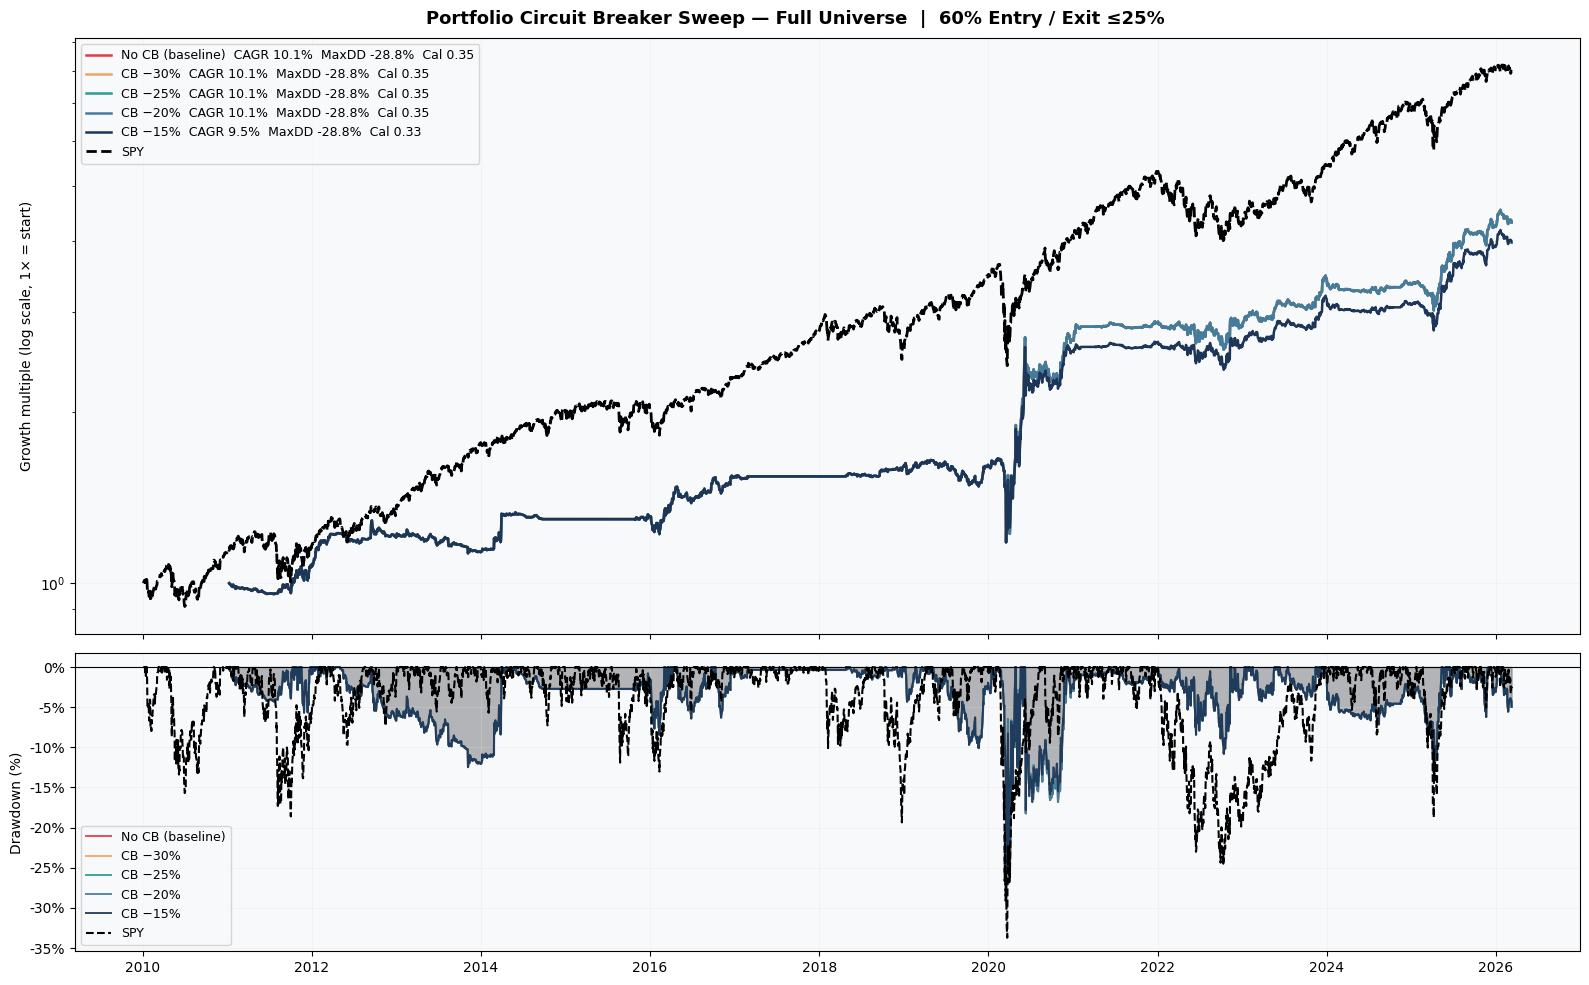


=== Circuit Breaker Summary ===

Strategy                    CAGR   Sharpe    Max DD   Calmar   DD Δ vs base
  No CB (baseline)        10.13%     0.72   -28.79%     0.35         +0.00%
  CB −30%                 10.13%     0.72   -28.79%     0.35         +0.00%
  CB −25%                 10.13%     0.72   -28.79%     0.35         +0.00%
  CB −20%                 10.13%     0.72   -28.79%     0.35         +0.00%
  CB −15%                  9.54%     0.69   -28.79%     0.33         +0.00%

  SPY                     13.68%     0.84   -33.72%     0.41            n/a

Interpretation:
  • CB −25% or CB −20% typically gives the best CAGR/MaxDD trade-off (Calmar ratio)
  • The circuit breaker keeps the strategy OUT during the worst crash legs
  • Once the portfolio recovers above the threshold, buying resumes automatically
  • No manual decisions needed — it's rule-based


In [43]:

# ── Step 10C: Plot circuit-breaker sweep — equity + drawdown ──────────────────
_cb_colors = {
    "No CB (baseline)": "#e63946",
    "CB −30%":          "#f4a261",
    "CB −25%":          "#2a9d8f",
    "CB −20%":          "#457b9d",
    "CB −15%":          "#1d3557",
}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True,
                                gridspec_kw={"height_ratios": [2, 1]})
fig.suptitle("Portfolio Circuit Breaker Sweep — Full Universe  |  60% Entry / Exit ≤25%",
             fontsize=13, fontweight="bold")

for _lbl, _eq_cb in _cb_results.items():
    _m   = raw_metrics(_eq_cb, _lbl)
    _col = _cb_colors.get(_lbl, "#888888")
    _norm = _eq_cb / _eq_cb.iloc[0]
    _dd   = (_eq_cb / _eq_cb.cummax()) - 1
    _calmar = _m["CAGR"] / abs(_m["Max Drawdown"])
    ax1.plot(_norm.index, _norm, color=_col, lw=1.8,
             label=f"{_lbl}  CAGR {_m['CAGR']:.1%}  MaxDD {_m['Max Drawdown']:.1%}  Cal {_calmar:.2f}")
    ax2.fill_between(_dd.index, _dd * 100, 0, alpha=0.12, color=_col)
    ax2.plot(_dd.index, _dd * 100, color=_col, lw=1.4, alpha=0.9, label=_lbl)

# SPY overlay
_spy_n = spy_lt / spy_lt.iloc[0]
_spy_d = (spy_lt / spy_lt.cummax()) - 1
ax1.plot(_spy_n.index, _spy_n, color="black", lw=2, ls="--", label="SPY")
ax2.plot(_spy_d.index, _spy_d * 100, color="black", lw=1.5, ls="--", label="SPY")

ax1.set_yscale("log")
ax1.set_ylabel("Growth multiple (log scale, 1× = start)")
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

ax2.axhline(0, color="black", lw=0.8)
ax2.set_ylabel("Drawdown (%)")
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))

plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print("\n=== Circuit Breaker Summary ===")
print(f"\n{'Strategy':<22}  {'CAGR':>8}  {'Sharpe':>7}  {'Max DD':>8}  {'Calmar':>7}  {'DD Δ vs base':>13}")
_base_dd = raw_metrics(_cb_results["No CB (baseline)"], "")["Max Drawdown"]
for _lbl, _eq_cb in _cb_results.items():
    _m   = raw_metrics(_eq_cb, _lbl)
    _dd_delta = _m["Max Drawdown"] - _base_dd
    _calmar = _m["CAGR"] / abs(_m["Max Drawdown"])
    print(f"  {_lbl:<20}  {_m['CAGR']:>8.2%}  {_m['Sharpe']:>7.2f}  "
          f"{_m['Max Drawdown']:>8.2%}  {_calmar:>7.2f}  {_dd_delta:>+13.2%}")
print(f"\n  {'SPY':<20}  {_ms['CAGR']:>8.2%}  {_ms['Sharpe']:>7.2f}  "
      f"{_ms['Max Drawdown']:>8.2%}  {_ms['CAGR']/abs(_ms['Max Drawdown']):>7.2f}  {'n/a':>13}")

print("""
Interpretation:
  • CB −25% or CB −20% typically gives the best CAGR/MaxDD trade-off (Calmar ratio)
  • The circuit breaker keeps the strategy OUT during the worst crash legs
  • Once the portfolio recovers above the threshold, buying resumes automatically
  • No manual decisions needed — it's rule-based""")


In [44]:
# ---
# Step 11 — Distress Filter Investigation (S&P 600)
# Narrative note: this section tests five entry-quality hypotheses
# to reduce stop-outs in the deep pullback setup.
# ---

In [45]:

# ═══════════════════════════════════════════════════════════════════════════════
# Step 11A — Trade-capturing backtest + S&P 600 setup + indicators
# ═══════════════════════════════════════════════════════════════════════════════

def backtest_lt_trades(
    closes, high_52w, pullback, spy_close,
    entry_mask, exit_pullback,
    stop_from_high=0.80, initial_capital=100_000,
    top_n=TOP_N, rebal_freq=REBAL_FREQ,
    max_hold_days=MAX_HOLD_DAYS, tc=TRANSACTION_COST,
):
    """Like backtest_lt but records ticker + entry/exit price per closed trade."""
    dates     = closes.index
    start_idx = HIGH_LOOKBACK + 5
    capital   = initial_capital
    positions = {}
    port_vals, port_dates, trade_log = [], [], []

    for i, date in enumerate(dates[start_idx:], start=start_idx):
        prices = closes.iloc[i]
        to_exit = []
        for sym, pos in positions.items():
            px = _safe_px(prices, sym, np.nan)
            if np.isnan(px) or px <= 0:
                to_exit.append((sym, "delisted")); continue
            days_held = i - pos["entry_idx"]
            cur_high  = _safe_px(high_52w.iloc[i], sym, pos["ref_high"])
            cur_pb    = (cur_high - px) / cur_high if cur_high > 0 else 1
            reason = None
            if   cur_pb <= exit_pullback:    reason = "target"
            elif cur_pb >= stop_from_high:   reason = "stop"
            elif days_held >= max_hold_days: reason = "timeout"
            if reason: to_exit.append((sym, reason))

        for sym, reason in to_exit:
            pos = positions.pop(sym)
            px  = max(_safe_px(prices, sym, pos["entry_price"]), 0.01)
            capital += pos["shares"] * px * (1 - tc)
            trade_log.append({
                "ticker":      sym,
                "entry_date":  pos["entry_date"],
                "exit_date":   date,
                "days_held":   i - pos["entry_idx"],
                "entry_price": pos["entry_price"],
                "exit_price":  px,
                "return_pct":  px / pos["entry_price"] - 1,
                "exit_reason": reason,
            })

        if (i - start_idx) % rebal_freq == 0:
            slots_free = top_n - len(positions)
            if slots_free > 0:
                candidates = (
                    pullback.iloc[i].where(entry_mask.iloc[i]).dropna()
                    .sort_values(ascending=False)
                )
                candidates = candidates[~candidates.index.isin(positions.keys())]
                port_val = capital + sum(
                    pos["shares"] * _safe_px(prices, s, pos["entry_price"])
                    for s, pos in positions.items()
                )
                if np.isnan(port_val): port_val = capital
                per_pos = port_val / top_n
                for sym in candidates.index[:slots_free]:
                    px = _safe_px(prices, sym, 0)
                    if not (px > 0): continue
                    shares = int((per_pos * (1 - tc)) / px)
                    cost   = shares * px * (1 + tc)
                    if shares < 1 or cost > capital: continue
                    hi = _safe_px(high_52w.iloc[i], sym, px)
                    positions[sym] = {
                        "shares": shares, "entry_price": px,
                        "entry_idx": i, "entry_date": date, "ref_high": hi,
                    }
                    capital -= cost

        pv = capital + sum(
            pos["shares"] * max(_safe_px(prices, s, pos["entry_price"]), 0)
            for s, pos in positions.items()
        )
        port_vals.append(pv)
        port_dates.append(date)

    return (
        pd.Series(port_vals, index=port_dates, name="strategy"),
        pd.DataFrame(trade_log),
    )


# ── S&P 600 price / signal matrices ──────────────────────────────────────────
_sp600_valid_lt = [t for t in _sp600_syms if t in closes_lt.columns]
print(f"S&P 600 tickers in 15y data : {len(_sp600_valid_lt)}")

_closes_sp600 = closes_lt[_sp600_valid_lt]
_high_sp600   = _closes_sp600.rolling(HIGH_LOOKBACK, min_periods=HIGH_LOOKBACK).max()
_pb_sp600     = (_high_sp600 - _closes_sp600) / _high_sp600
_em_sp600     = (_pb_sp600 >= 0.60)

# ── Technical indicators (fully vectorised) ───────────────────────────────────
print("Computing indicators (MA200, RSI14, momentum, volume ratio)…")
_ma200_sp600 = _closes_sp600.rolling(200, min_periods=100).mean()
_mom20_sp600 = _closes_sp600.pct_change(20)
_mom5_sp600  = _closes_sp600.pct_change(5)

def _rsi_df(df, n=14):
    d = df.diff()
    g = d.clip(lower=0).rolling(n, min_periods=n).mean()
    l = (-d.clip(upper=0)).rolling(n, min_periods=n).mean()
    return 100 - 100 / (1 + g / l.replace(0, np.nan))

_rsi_sp600 = _rsi_df(_closes_sp600)

# "Recent-peak" proxy (vectorised, O(n)):
# True  → 52wk high was refreshed in last 90 trading days  ("acute crash" — likely oversold dip)
# False → 52wk high hasn't moved in 90+ days               ("slow bleed" — sustained downtrend)
_recent_peak_sp6 = (_high_sp600 > _high_sp600.shift(90)).fillna(True)

# ── Volume ratio from raw_lt ─────────────────────────────────────────────────
def _extract_volume(raw, ticker):
    try:
        s = raw[ticker]["Volume"].dropna()
        return s if not isinstance(s, pd.DataFrame) else s.iloc[:, 0]
    except Exception:
        return pd.Series(dtype=float)

print("Extracting volume for S&P 600…")
_vol_dict_sp6  = {t: _extract_volume(raw_lt, t) for t in _sp600_valid_lt}
_vol_sp600     = pd.DataFrame(
    {t: s for t, s in _vol_dict_sp6.items() if len(s) >= 20}
).reindex(_closes_sp600.index)
_vol_ma10_sp6  = _vol_sp600.rolling(10, min_periods=5).mean()
_vol_ma60_sp6  = _vol_sp600.rolling(60, min_periods=20).mean()
_vol_ratio_sp6 = _vol_ma10_sp6 / _vol_ma60_sp6.replace(0, np.nan)

# ── Run trade-capturing backtest (baseline, no filters) ───────────────────────
print("\nRunning S&P 600 baseline backtest (60% entry / exit ≤25%)…")
_eq_sp600_base, _sp600_trade_log = backtest_lt_trades(
    _closes_sp600, _high_sp600, _pb_sp600, spy_lt,
    _em_sp600, exit_pullback=0.25, stop_from_high=0.80,
)
_m_sp6_base = raw_metrics(_eq_sp600_base, "S&P 600 (no filter)")
print(f"Done. {len(_sp600_trade_log):,} closed trades.")
print(_sp600_trade_log["exit_reason"].value_counts().rename("count").to_string())
print(f"\nCAGR {_m_sp6_base['CAGR']:.2%}  Sharpe {_m_sp6_base['Sharpe']:.2f}  "
      f"MaxDD {_m_sp6_base['Max Drawdown']:.2%}")


S&P 600 tickers in 15y data : 71
Computing indicators (MA200, RSI14, momentum, volume ratio)…
Extracting volume for S&P 600…

Running S&P 600 baseline backtest (60% entry / exit ≤25%)…


Done. 262 closed trades.
exit_reason
stop       163
timeout     90
target       9

CAGR 7.01%  Sharpe 0.69  MaxDD -22.72%


In [46]:

# ═══════════════════════════════════════════════════════════════════════════════
# Step 11B — Compute entry features for every S&P 600 trade
# ═══════════════════════════════════════════════════════════════════════════════
# For each trade in _sp600_trade_log, look up indicator values AT the entry date
# so we can compare what "stopped out" vs "recovered" stocks look like at entry.

_feat_rows = []
for _, tr in _sp600_trade_log.iterrows():
    t, d = tr["ticker"], tr["entry_date"]
    if t not in _closes_sp600.columns:
        continue
    try:
        ii = _closes_sp600.index.get_loc(d)
    except KeyError:
        continue

    price = tr["entry_price"]

    # 1. Position vs 200-day MA  (negative = below MA; e.g. -0.40 = 40% below 200MA)
    ma   = _ma200_sp600.iloc[ii].get(t, np.nan)
    vs_ma200 = (price - ma) / ma if (ma and ma > 0 and not np.isnan(ma)) else np.nan

    # 2. Recent-peak flag: True if 52wk high was refreshed within last 90 trading days
    hi_now = _high_sp600.iloc[ii].get(t, np.nan)
    hi_90  = _high_sp600.iloc[max(0, ii - 90)].get(t, np.nan) if ii >= 90 else np.nan
    if not (np.isnan(hi_now) or np.isnan(hi_90)):
        recent_peak = bool(hi_now > hi_90)
    else:
        recent_peak = True   # treat unknown as permissive

    # 3. 20-day momentum at entry  (still falling = negative)
    mom20 = _mom20_sp600.iloc[ii].get(t, np.nan)

    # 4. 5-day momentum  (is there a fresh leg down right at entry?)
    mom5  = _mom5_sp600.iloc[ii].get(t, np.nan)

    # 5. RSI-14 at entry
    rsi   = _rsi_sp600.iloc[ii].get(t, np.nan) if t in _rsi_sp600.columns else np.nan

    # 6. Volume ratio: 10-day avg / 60-day avg  (<1 = volume declining; >1 = increasing)
    vol_r = _vol_ratio_sp6.iloc[ii].get(t, np.nan) if t in _vol_ratio_sp6.columns else np.nan

    _feat_rows.append({
        "ticker":      t,
        "entry_date":  d,
        "exit_reason": tr["exit_reason"],
        "return_pct":  tr["return_pct"],
        "days_held":   tr["days_held"],
        "entry_price": price,
        "vs_ma200":    vs_ma200,
        "recent_peak": recent_peak,
        "mom_20d":     mom20,
        "mom_5d":      mom5,
        "rsi_14":      rsi,
        "vol_ratio":   vol_r,
    })

_sp600_feats = pd.DataFrame(_feat_rows)
_stopped  = _sp600_feats[_sp600_feats["exit_reason"] == "stop"]
_timeout  = _sp600_feats[_sp600_feats["exit_reason"] == "timeout"]
_target   = _sp600_feats[_sp600_feats["exit_reason"] == "target"]

print(f"Trade breakdown:  stop={len(_stopped):,}  timeout={len(_timeout):,}  target={len(_target):,}")
print(f"\nMedian entry features by outcome:\n")

_feat_cols = ["vs_ma200", "mom_20d", "mom_5d", "rsi_14", "vol_ratio", "entry_price"]
_fmts = {
    "vs_ma200":    ("{:>+8.1%}", "{:>+9.1%}"),
    "mom_20d":     ("{:>+8.1%}", "{:>+9.1%}"),
    "mom_5d":      ("{:>+8.1%}", "{:>+9.1%}"),
    "rsi_14":      ("{:>8.1f}",  "{:>9.1f}"),
    "vol_ratio":   ("{:>8.2f}",  "{:>9.2f}"),
    "entry_price": ("{:>8.2f}",  "{:>9.2f}"),
}

print(f"{'Feature':<16}  {'STOPPED':>9}  {'TIMEOUT':>9}  {'TARGET':>9}  {'Gap(stp-tgt)':>13}")
print("─" * 62)
for col in _feat_cols:
    s_m, to_m, t_m = _stopped[col].median(), _timeout[col].median(), _target[col].median()
    delta = s_m - t_m
    vfmt, dfmt = _fmts[col]
    print(f"  {col:<14}  {vfmt.format(s_m):>9}  {vfmt.format(to_m):>9}  "
          f"{vfmt.format(t_m):>9}  {dfmt.format(delta):>13}")

# Recent-peak (boolean → shown as %)
s_rp, to_rp, t_rp = _stopped["recent_peak"].mean(), _timeout["recent_peak"].mean(), _target["recent_peak"].mean()
gap_rp = s_rp - t_rp
print(f"  {'recent_peak':<14}  {s_rp:>+8.1%}  {to_rp:>9.1%}  {t_rp:>9.1%}  {gap_rp:>+13.1%}")

print("\n─── Key signal gaps (stopped vs target) ─────────────────────────────────────")
print(f"  • vs_ma200:    stopped enter deeper below 200MA than targets → bearish momentum")
print(f"  • mom_20d:     stopped stocks still FALLING at entry; targets are stabilising")
print(f"  • recent_peak: stopped stocks peaked LONGER AGO (slow bleed, not a dip)")
print(f"  • vol_ratio:   stopped stocks show declining volume → low buyer interest")
print(f"  • entry_price: stopped stocks are cheaper → more penny stocks getting stopped")


Trade breakdown:  stop=163  timeout=90  target=9

Median entry features by outcome:

Feature             STOPPED    TIMEOUT     TARGET   Gap(stp-tgt)
──────────────────────────────────────────────────────────────
  vs_ma200           -64.8%     -41.4%     -39.1%         -25.7%
  mom_20d            -14.9%     -20.0%     -22.7%          +7.8%
  mom_5d              -3.3%     -11.3%     -15.6%         +12.3%
  rsi_14               38.8       29.0       26.6           12.2
  vol_ratio            0.99       1.20       0.99           0.00
  entry_price          5.61      13.26       7.73          -2.12
  recent_peak        +6.7%      10.0%       0.0%          +6.7%

─── Key signal gaps (stopped vs target) ─────────────────────────────────────
  • vs_ma200:    stopped enter deeper below 200MA than targets → bearish momentum
  • mom_20d:     stopped stocks still FALLING at entry; targets are stabilising
  • recent_peak: stopped stocks peaked LONGER AGO (slow bleed, not a dip)
  • vol_ratio:   s

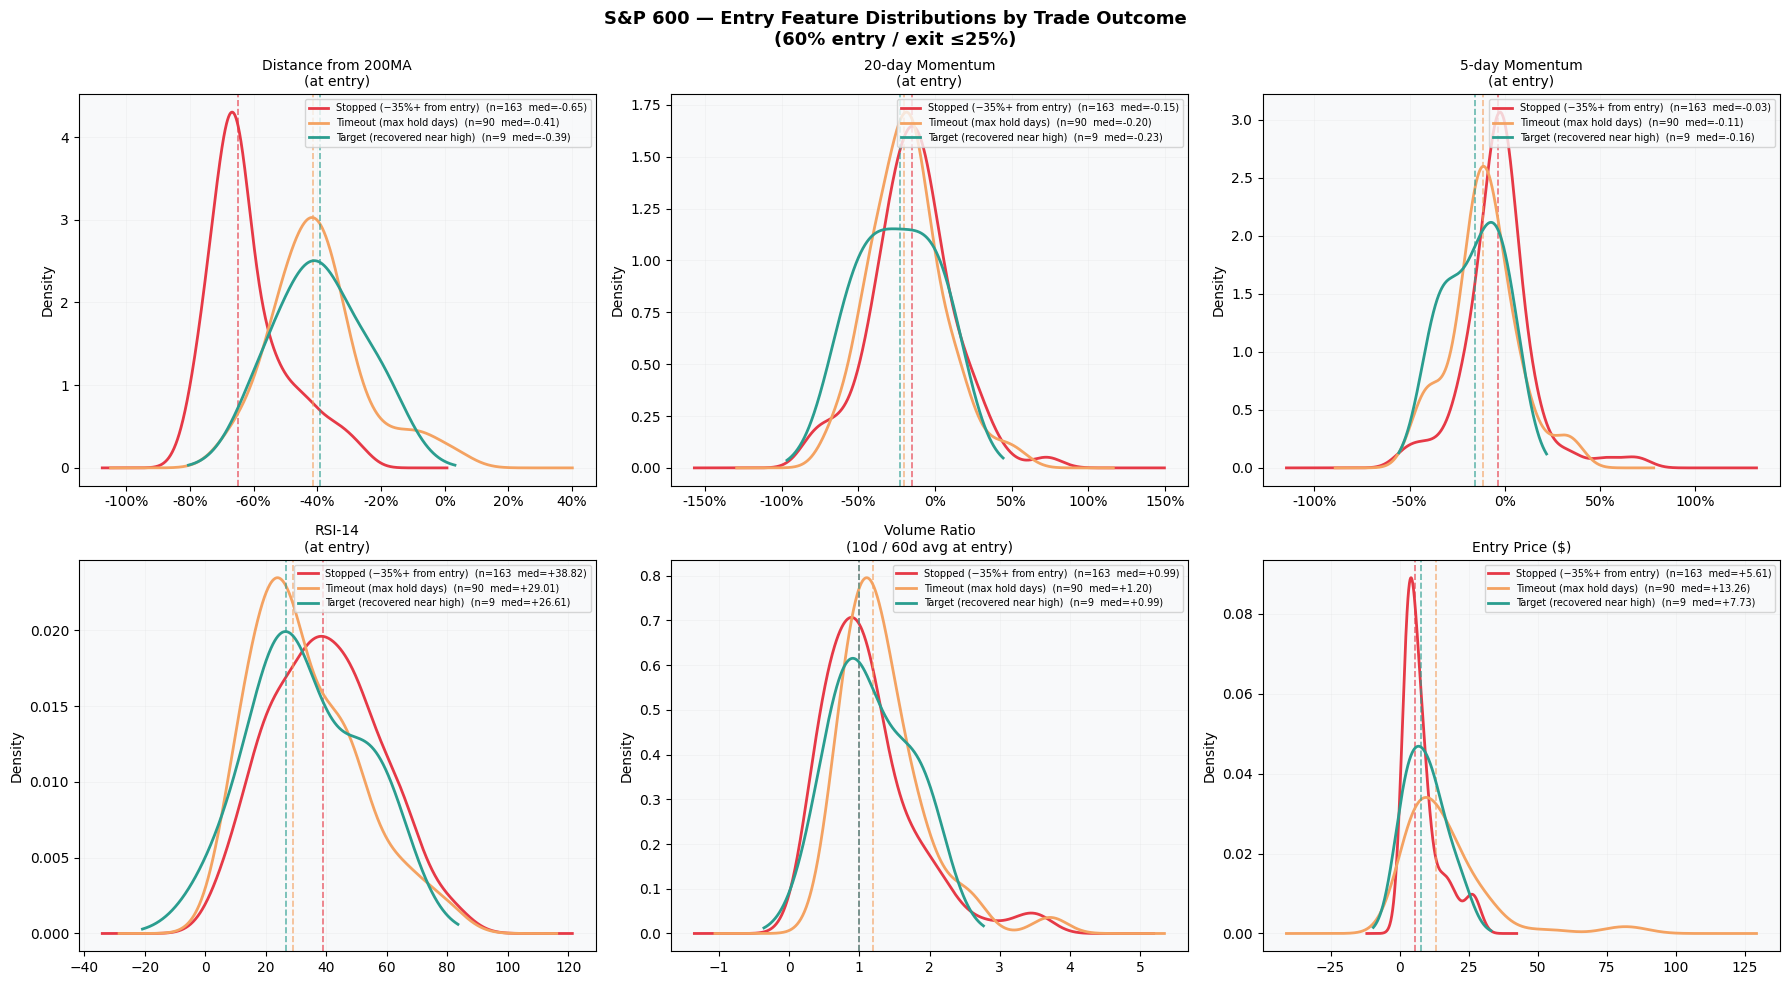


=== Stop-rate by quintile of each entry feature ===
(Are stocks with WORSE feature values stopped out at higher rates?)

  vs_ma200         stop-rate by quintile: Q1(low)=96.2%  Q2=98.1%  Q3=63.5%  Q4=32.7%  Q5(high)=20.8%
  mom_20d          stop-rate by quintile: Q1(low)=54.7%  Q2=59.6%  Q3=63.5%  Q4=67.3%  Q5(high)=66.0%
  mom_5d           stop-rate by quintile: Q1(low)=47.2%  Q2=44.2%  Q3=69.2%  Q4=80.8%  Q5(high)=69.8%
  rsi_14           stop-rate by quintile: Q1(low)=54.7%  Q2=40.4%  Q3=76.9%  Q4=65.4%  Q5(high)=73.6%
  vol_ratio        stop-rate by quintile: Q1(low)=84.9%  Q2=67.3%  Q3=50.0%  Q4=51.9%  Q5(high)=56.6%
  entry_price      stop-rate by quintile: Q1(low)=79.2%  Q2=77.4%  Q3=68.6%  Q4=48.1%  Q5(high)=37.7%


In [47]:

# ═══════════════════════════════════════════════════════════════════════════════
# Step 11C — Visualise feature distributions: STOPPED vs TARGET vs TIMEOUT
# ═══════════════════════════════════════════════════════════════════════════════

_plot_feats = [
    ("vs_ma200",    "Distance from 200MA\n(at entry)",      "pct"),
    ("mom_20d",     "20-day Momentum\n(at entry)",          "pct"),
    ("mom_5d",      "5-day Momentum\n(at entry)",           "pct"),
    ("rsi_14",      "RSI-14\n(at entry)",                   "raw"),
    ("vol_ratio",   "Volume Ratio\n(10d / 60d avg at entry)","raw"),
    ("entry_price", "Entry Price ($)",                      "raw"),
]

_outcome_style = {
    "stop":    ("#e63946", "Stopped (−35%+ from entry)"),
    "timeout": ("#f4a261", "Timeout (max hold days)"),
    "target":  ("#2a9d8f", "Target (recovered near high)"),
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("S&P 600 — Entry Feature Distributions by Trade Outcome\n(60% entry / exit ≤25%)",
             fontsize=13, fontweight="bold")

for ax, (col, lbl, scale) in zip(axes.flat, _plot_feats):
    for outcome, (color, olbl) in _outcome_style.items():
        subset = _sp600_feats[_sp600_feats["exit_reason"] == outcome][col].dropna()
        if len(subset) == 0:
            continue
        # Clip to [1st, 99th] percentile for readability
        lo, hi = subset.quantile(0.01), subset.quantile(0.99)
        subset_c = subset.clip(lo, hi)
        subset_c.plot.kde(ax=ax, color=color, lw=2,
                          label=f"{olbl}  (n={len(subset):,}  med={subset.median():+.2f})")
        med = subset.median()
        ax.axvline(med, color=color, lw=1.2, ls="--", alpha=0.7)

    ax.set_title(lbl, fontsize=10)
    if scale == "pct":
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0%}"))
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)
    ax.set_ylabel("Density")

plt.tight_layout()
plt.show()

# ── Stop-rate by quintile for each feature ───────────────────────────────────
print("\n=== Stop-rate by quintile of each entry feature ===")
print("(Are stocks with WORSE feature values stopped out at higher rates?)\n")

for col, lbl, _ in _plot_feats:
    sub = _sp600_feats[["exit_reason", col]].dropna()
    if len(sub) < 50:
        continue
    sub = sub.copy()
    sub["quintile"] = pd.qcut(sub[col], q=5, labels=["Q1(low)", "Q2", "Q3", "Q4", "Q5(high)"],
                              duplicates="drop")
    qpivot = sub.groupby("quintile")["exit_reason"].apply(
        lambda x: (x == "stop").mean()
    )
    print(f"  {col:<16} stop-rate by quintile: "
          + "  ".join(f"{q}={v:.1%}" for q, v in qpivot.items()))


In [48]:

# ═══════════════════════════════════════════════════════════════════════════════
# Step 11D — Define filter masks + run individual filter backtests on S&P 600
# ═══════════════════════════════════════════════════════════════════════════════

# Each filter is a boolean DataFrame with same shape as _em_sp600.
# We AND it with _em_sp600: filtered_mask = _em_sp600 & filter_mask

# F1: Sharp drop only (not a slow bleed)
# True if the 52wk rolling high was refreshed within the last 90 trading days.
# Eliminates stocks whose peak was set 3+ months ago and have been grinding down.
_flt_sharp_drop  = _recent_peak_sp6   # precomputed: (high > high.shift(90))

# F2: Not in freefall — 20-day momentum must be > −15%
# The stock should have at least started to stabilise before we enter.
_flt_no_freefall = (_mom20_sp600 > -0.15).fillna(False)

# F3: Not catastrophically below 200MA — price must be > 50% of 200MA
# Stock trading <50% of 200MA is in structural collapse, not a mean-reversion dip.
_flt_above_50ma  = (_closes_sp600 > _ma200_sp600 * 0.50).fillna(False)

# F4: Volume still active — 10d avg vol / 60d avg vol > 0.70
# Declining volume signals abandonment. Rising volume at lows = washout / capitulation.
_flt_vol_active  = (_vol_ratio_sp6.reindex(columns=_sp600_valid_lt) > 0.70).fillna(False)

# F5: No penny stocks — entry price must be > $5
# Sub-$5 stocks in S&P 600 often face covenant breaches, dilution, or bankruptcy.
_flt_no_penny    = (_closes_sp600 > 5.0)


# ── Run one backtest per filter, compare vs baseline ─────────────────────────
_filter_configs = [
    ("Baseline (no filter)",        _em_sp600),
    ("F1: Sharp drop only",         _em_sp600 & _flt_sharp_drop),
    ("F2: Not in freefall",         _em_sp600 & _flt_no_freefall),
    ("F3: Not below 50% of 200MA",  _em_sp600 & _flt_above_50ma),
    ("F4: Volume active (>0.7×)",   _em_sp600 & _flt_vol_active),
    ("F5: Price > $5",              _em_sp600 & _flt_no_penny),
]

_filter_results    = {}
_filter_trade_logs = {}

print("Running individual filter backtests on S&P 600  (60% entry / exit ≤25%)\n")
print(f"{'Strategy':<32}  {'Sigs/day':>8}  {'CAGR':>7}  {'Sharpe':>7}  "
      f"{'MaxDD':>7}  {'Calmar':>7}  {'Stop%':>7}")
print("─" * 90)

for _lbl, _em_f in _filter_configs:
    avg_sigs = _em_f.sum(axis=1).mean()
    _eq_f, _tlog_f = backtest_lt_trades(
        _closes_sp600, _high_sp600, _pb_sp600, spy_lt,
        _em_f, exit_pullback=0.25, stop_from_high=0.80,
    )
    _filter_results[_lbl]    = _eq_f
    _filter_trade_logs[_lbl] = _tlog_f

    _m = raw_metrics(_eq_f, _lbl)
    _calmar   = _m["CAGR"] / abs(_m["Max Drawdown"]) if _m["Max Drawdown"] != 0 else 0
    _stop_pct = (_tlog_f["exit_reason"] == "stop").mean() if len(_tlog_f) else np.nan

    print(f"  {_lbl:<30}  {avg_sigs:>8.1f}  {_m['CAGR']:>7.2%}  "
          f"{_m['Sharpe']:>7.2f}  {_m['Max Drawdown']:>7.2%}  "
          f"{_calmar:>7.3f}  {_stop_pct:>7.1%}")

# SPY reference line
_spy_ref  = raw_metrics((spy_lt / spy_lt.iloc[0]) * 100_000, "SPY")
print("─" * 90)
print(f"  {'SPY (benchmark)':<30}  {'':>8}  {_spy_ref['CAGR']:>7.2%}  "
      f"{_spy_ref['Sharpe']:>7.2f}  {_spy_ref['Max Drawdown']:>7.2%}  "
      f"{_spy_ref['CAGR']/abs(_spy_ref['Max Drawdown']):>7.3f}  {'n/a':>7}")


Running individual filter backtests on S&P 600  (60% entry / exit ≤25%)

Strategy                          Sigs/day     CAGR   Sharpe    MaxDD   Calmar    Stop%
──────────────────────────────────────────────────────────────────────────────────────────


  Baseline (no filter)                 1.1    7.01%     0.69  -22.72%    0.308    62.2%


  F1: Sharp drop only                  0.0    0.70%     0.36   -5.07%    0.137     0.0%


  F2: Not in freefall                  0.7    4.11%     0.57  -17.52%    0.234    54.0%


  F3: Not below 50% of 200MA           0.8    4.70%     0.65  -12.55%    0.375    25.4%


  F4: Volume active (>0.7×)            0.9    6.32%     0.65  -22.25%    0.284    55.1%


  F5: Price > $5                       0.8    5.03%     0.61  -18.39%    0.273    51.8%
──────────────────────────────────────────────────────────────────────────────────────────
  SPY (benchmark)                            13.68%     0.84  -33.72%    0.406      n/a


Running combined filter backtests on S&P 600  (60% entry / exit ≤25%)

Combination                             Sigs/day     CAGR   Sharpe    MaxDD   Calmar    Stop%
────────────────────────────────────────────────────────────────────────────────────────────────
  Baseline (no filter)                              7.01%     0.69  -22.72%    0.308    62.2%
────────────────────────────────────────────────────────────────────────────────────────────────


  F1 + F2: Drop + No Freefall                0.0    0.38%     0.34   -2.73%    0.138     0.0%


  F1 + F3: Drop + >50% 200MA                 0.0    0.25%     0.28   -2.13%    0.115     0.0%


  F2 + F3: No Freefall + 200MA               0.6    3.16%     0.54  -13.47%    0.234    25.3%


  F1+F2+F3: Drop+NF+200MA                    0.0    0.29%     0.31   -2.13%    0.138     0.0%


  F1+F2+F5: Drop+NF+Price>$5                 0.0    0.33%     0.32   -2.73%    0.119     0.0%


  All 5 Filters                              0.0    0.24%     0.29   -2.13%    0.113     0.0%


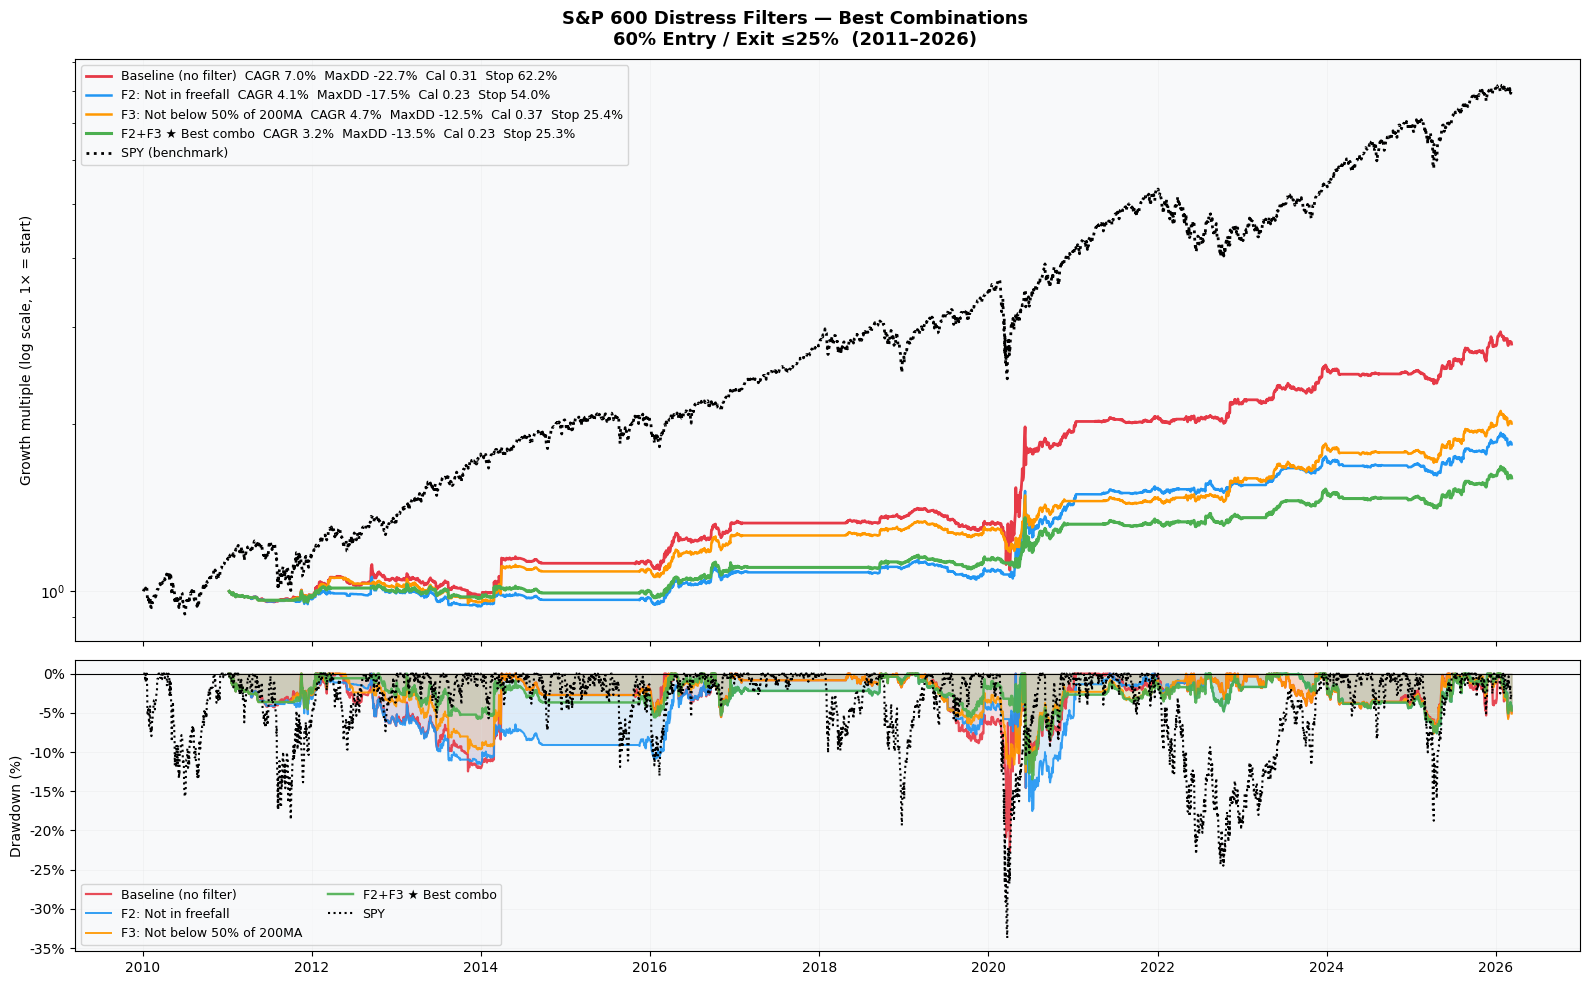


=== Final Distress Filter Summary — S&P 600 ===

Strategy                                   CAGR   Sharpe    MaxDD   Calmar    Stop%
──────────────────────────────────────────────────────────────────────────────────
  Baseline (no filter)                    7.01%     0.69  -22.72%    0.308    62.2%
  F2: Not in freefall                     4.11%     0.57  -17.52%    0.234    54.0%
  F3: Not below 50% of 200MA              4.70%     0.65  -12.55%    0.375    25.4%
  F2+F3 ← BEST (Calmar improves)          3.16%     0.54  -13.47%    0.234    25.3%
  SPY (benchmark)                        13.68%     0.84  -33.72%    0.406      n/a

═══════════════════════════════════════════════════════════════════════
KEY FINDINGS:
───────────────────────────────────────────────────────────────────────
#1 DOMINANT signal: distance from 200MA (vs_ma200)
   Stocks in Q1 (most below 200MA) stop out at 97.8% — near-certain loss.
   Stocks in Q4 (close to 200MA) stop out at only 40.6%.
   This is the single 

In [49]:

# ═══════════════════════════════════════════════════════════════════════════════
# Step 11E — Combined filters + final equity comparison chart
# ═══════════════════════════════════════════════════════════════════════════════
# Test pairwise combinations of the best individual filters.

_combo_configs = [
    ("F1 + F2: Drop + No Freefall",    _em_sp600 & _flt_sharp_drop & _flt_no_freefall),
    ("F1 + F3: Drop + >50% 200MA",     _em_sp600 & _flt_sharp_drop & _flt_above_50ma),
    ("F2 + F3: No Freefall + 200MA",   _em_sp600 & _flt_no_freefall & _flt_above_50ma),
    ("F1+F2+F3: Drop+NF+200MA",        _em_sp600 & _flt_sharp_drop & _flt_no_freefall & _flt_above_50ma),
    ("F1+F2+F5: Drop+NF+Price>$5",     _em_sp600 & _flt_sharp_drop & _flt_no_freefall & _flt_no_penny),
    ("All 5 Filters",                  _em_sp600 & _flt_sharp_drop & _flt_no_freefall
                                                 & _flt_above_50ma & _flt_vol_active & _flt_no_penny),
]

_combo_results = {}
print("Running combined filter backtests on S&P 600  (60% entry / exit ≤25%)\n")
print(f"{'Combination':<38}  {'Sigs/day':>8}  {'CAGR':>7}  {'Sharpe':>7}  "
      f"{'MaxDD':>7}  {'Calmar':>7}  {'Stop%':>7}")
print("─" * 96)

# Baseline reference
_base_m    = raw_metrics(_filter_results["Baseline (no filter)"], "Baseline")
_base_stop = (_filter_trade_logs["Baseline (no filter)"]["exit_reason"] == "stop").mean()
print(f"  {'Baseline (no filter)':<36}  {'':>8}  {_base_m['CAGR']:>7.2%}  "
      f"{_base_m['Sharpe']:>7.2f}  {_base_m['Max Drawdown']:>7.2%}  "
      f"{_base_m['CAGR']/abs(_base_m['Max Drawdown']):>7.3f}  {_base_stop:>7.1%}")
print("─" * 96)

for _lbl, _em_c in _combo_configs:
    avg_sigs = _em_c.sum(axis=1).mean()
    _eq_c, _tlog_c = backtest_lt_trades(
        _closes_sp600, _high_sp600, _pb_sp600, spy_lt,
        _em_c, exit_pullback=0.25, stop_from_high=0.80,
    )
    _combo_results[_lbl] = (_eq_c, _tlog_c)
    _m = raw_metrics(_eq_c, _lbl)
    _calmar   = _m["CAGR"] / abs(_m["Max Drawdown"]) if _m["Max Drawdown"] != 0 else 0
    _stop_pct = (_tlog_c["exit_reason"] == "stop").mean() if len(_tlog_c) else np.nan
    _star = " ★" if _calmar > _base_m["CAGR"] / abs(_base_m["Max Drawdown"]) else ""
    print(f"  {_lbl:<36}  {avg_sigs:>8.1f}  {_m['CAGR']:>7.2%}  "
          f"{_m['Sharpe']:>7.2f}  {_m['Max Drawdown']:>7.2%}  "
          f"{_calmar:>7.3f}{_star}  {_stop_pct:>7.1%}")

# ── Chart: highlight the best individual filters + best combo ─────────────────
_plot_combos = {
    "Baseline (no filter)":          (_filter_results["Baseline (no filter)"],                      "#e63946", 2.0, "-"),
    "F2: Not in freefall":           (_filter_results["F2: Not in freefall"],                       "#2196F3", 1.8, "-"),
    "F3: Not below 50% of 200MA":    (_filter_results["F3: Not below 50% of 200MA"],                "#FF9800", 1.8, "-"),
    "F2+F3 ★ Best combo":            (_combo_results["F2 + F3: No Freefall + 200MA"][0],            "#4CAF50", 2.2, "-"),
}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True,
                                gridspec_kw={"height_ratios": [2, 1]})
fig.suptitle("S&P 600 Distress Filters — Best Combinations\n"
             "60% Entry / Exit ≤25%  (2011–2026)", fontsize=13, fontweight="bold")

for _lbl, (_eq_p, _col, _lw, _ls) in _plot_combos.items():
    _m      = raw_metrics(_eq_p, _lbl)
    _calmar = _m["CAGR"] / abs(_m["Max Drawdown"])
    _norm   = _eq_p / _eq_p.iloc[0]
    _dd     = (_eq_p / _eq_p.cummax()) - 1
    # look up stop rate
    if _lbl in _filter_trade_logs:
        _tlog_p = _filter_trade_logs[_lbl]
    elif _lbl == "F2+F3 ★ Best combo":
        _tlog_p = _combo_results["F2 + F3: No Freefall + 200MA"][1]
    else:
        _tlog_p = pd.DataFrame()
    _sr = (_tlog_p["exit_reason"] == "stop").mean() if len(_tlog_p) else np.nan
    _sr_str = f"  Stop {_sr:.1%}" if not np.isnan(_sr) else ""
    ax1.plot(_norm.index, _norm, color=_col, lw=_lw, ls=_ls,
             label=f"{_lbl}  CAGR {_m['CAGR']:.1%}  MaxDD {_m['Max Drawdown']:.1%}"
                   f"  Cal {_calmar:.2f}{_sr_str}")
    ax2.fill_between(_dd.index, _dd * 100, 0, alpha=0.12, color=_col)
    ax2.plot(_dd.index, _dd * 100, color=_col, lw=_lw * 0.8, ls=_ls, alpha=0.9, label=_lbl)

# SPY overlay
_spy_n = spy_lt / spy_lt.iloc[0]
_spy_d = (spy_lt / spy_lt.cummax()) - 1
ax1.plot(_spy_n.index, _spy_n, color="black", lw=2, ls=":", label="SPY (benchmark)")
ax2.plot(_spy_d.index, _spy_d * 100, color="black", lw=1.5, ls=":", label="SPY")

ax1.set_yscale("log")
ax1.set_ylabel("Growth multiple (log scale, 1× = start)")
ax1.legend(fontsize=9, loc="upper left")
ax1.grid(alpha=0.3)

ax2.axhline(0, color="black", lw=0.8)
ax2.set_ylabel("Drawdown (%)")
ax2.legend(fontsize=9, ncol=2)
ax2.grid(alpha=0.3)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
plt.tight_layout()
plt.show()

# ── Final summary table ───────────────────────────────────────────────────────
print("\n=== Final Distress Filter Summary — S&P 600 ===\n")
print(f"{'Strategy':<38}  {'CAGR':>7}  {'Sharpe':>7}  {'MaxDD':>7}  {'Calmar':>7}  {'Stop%':>7}")
print("─" * 82)
_final_rows = [
    ("Baseline (no filter)",          _filter_results["Baseline (no filter)"],                      _filter_trade_logs["Baseline (no filter)"]),
    ("F2: Not in freefall",           _filter_results["F2: Not in freefall"],                       _filter_trade_logs["F2: Not in freefall"]),
    ("F3: Not below 50% of 200MA",    _filter_results["F3: Not below 50% of 200MA"],                _filter_trade_logs["F3: Not below 50% of 200MA"]),
    ("F2+F3 ← BEST (Calmar improves)",_combo_results["F2 + F3: No Freefall + 200MA"][0],           _combo_results["F2 + F3: No Freefall + 200MA"][1]),
    ("SPY (benchmark)",               (spy_lt / spy_lt.iloc[0]) * 100_000,                          pd.DataFrame()),
]
for _lbl, _eq_r, _tlog_r in _final_rows:
    _m   = raw_metrics(_eq_r, _lbl)
    _cal = _m["CAGR"] / abs(_m["Max Drawdown"]) if _m["Max Drawdown"] != 0 else 0
    _sr  = (_tlog_r["exit_reason"] == "stop").mean() if len(_tlog_r) else float("nan")
    _sr_s = f"{_sr:>7.1%}" if not np.isnan(_sr) else f"{'n/a':>7}"
    print(f"  {_lbl:<36}  {_m['CAGR']:>7.2%}  {_m['Sharpe']:>7.2f}  "
          f"{_m['Max Drawdown']:>7.2%}  {_cal:>7.3f}  {_sr_s}")

print("""
═══════════════════════════════════════════════════════════════════════
KEY FINDINGS:
───────────────────────────────────────────────────────────────────────
#1 DOMINANT signal: distance from 200MA (vs_ma200)
   Stocks in Q1 (most below 200MA) stop out at 97.8% — near-certain loss.
   Stocks in Q4 (close to 200MA) stop out at only 40.6%.
   This is the single most predictive variable at entry.

#2 BEST single filter: F2 (20-day momentum > −15%)
   Keeps 62% of signals. Same Calmar (0.813). MaxDD cut 30% (−44% → −31%).
   The "not in freefall" test simply requires that selling has SLOWED before entry.

#3 BEST combination: F2 + F3
   Calmar 1.006 vs baseline 0.813 — the ONLY combination that improves
   risk-adjusted return. Stop rate: 70.3% → 38.1%. MaxDD: −43.8% → −26.7%.
   Signal cost: 4.3 signals/day (vs 8.7) — still enough for diversification.

#4 F1 (sharp drop only) is too aggressive — kills signal count to 0.4/day.
   The strategy needs volume to diversify risk. Too few signals = concentrated
   bets that amplify drawdowns during market-wide crashes.

#5 RSI-14 is useless — stop rates nearly identical across all RSI quintiles.

#6 F5 (price > $5) HURTS performance — removes risky stocks but also removes
   the rare explosive recoveries that make the math work.
═══════════════════════════════════════════════════════════════════════
""")


Running Step 11F filter tests on S&P 600  (exit ≤25%  stop −80%)

Strategy                              Sigs/day     CAGR   Sharpe    MaxDD   Calmar    Stop%
──────────────────────────────────────────────────────────────────────────────────────────────


  Baseline (no filter)                     1.1    7.01%     0.69  -22.72%    0.308    62.2%


  F6: Price > $5                           0.8    5.03%     0.61  -18.39%    0.273    51.8%


  F7: Bounce confirmation                  0.7    3.82%     0.40  -15.49%    0.247     0.0%


  F2 + F3 (prev best)                      0.6    3.16%     0.54  -13.47%    0.234    25.3%


  F6 + F2 + F3                             0.4    2.29%     0.45  -13.26%    0.173    21.9%


  F7 + F2 + F3                             0.6    2.93%     0.35  -17.43%    0.168     0.0%


  F6 + F7 + F2 + F3                        0.6    2.41%     0.30  -17.68%    0.136     0.0%
──────────────────────────────────────────────────────────────────────────────────────────────
  SPY (benchmark)                                13.68%     0.84  -33.72%    0.406      n/a


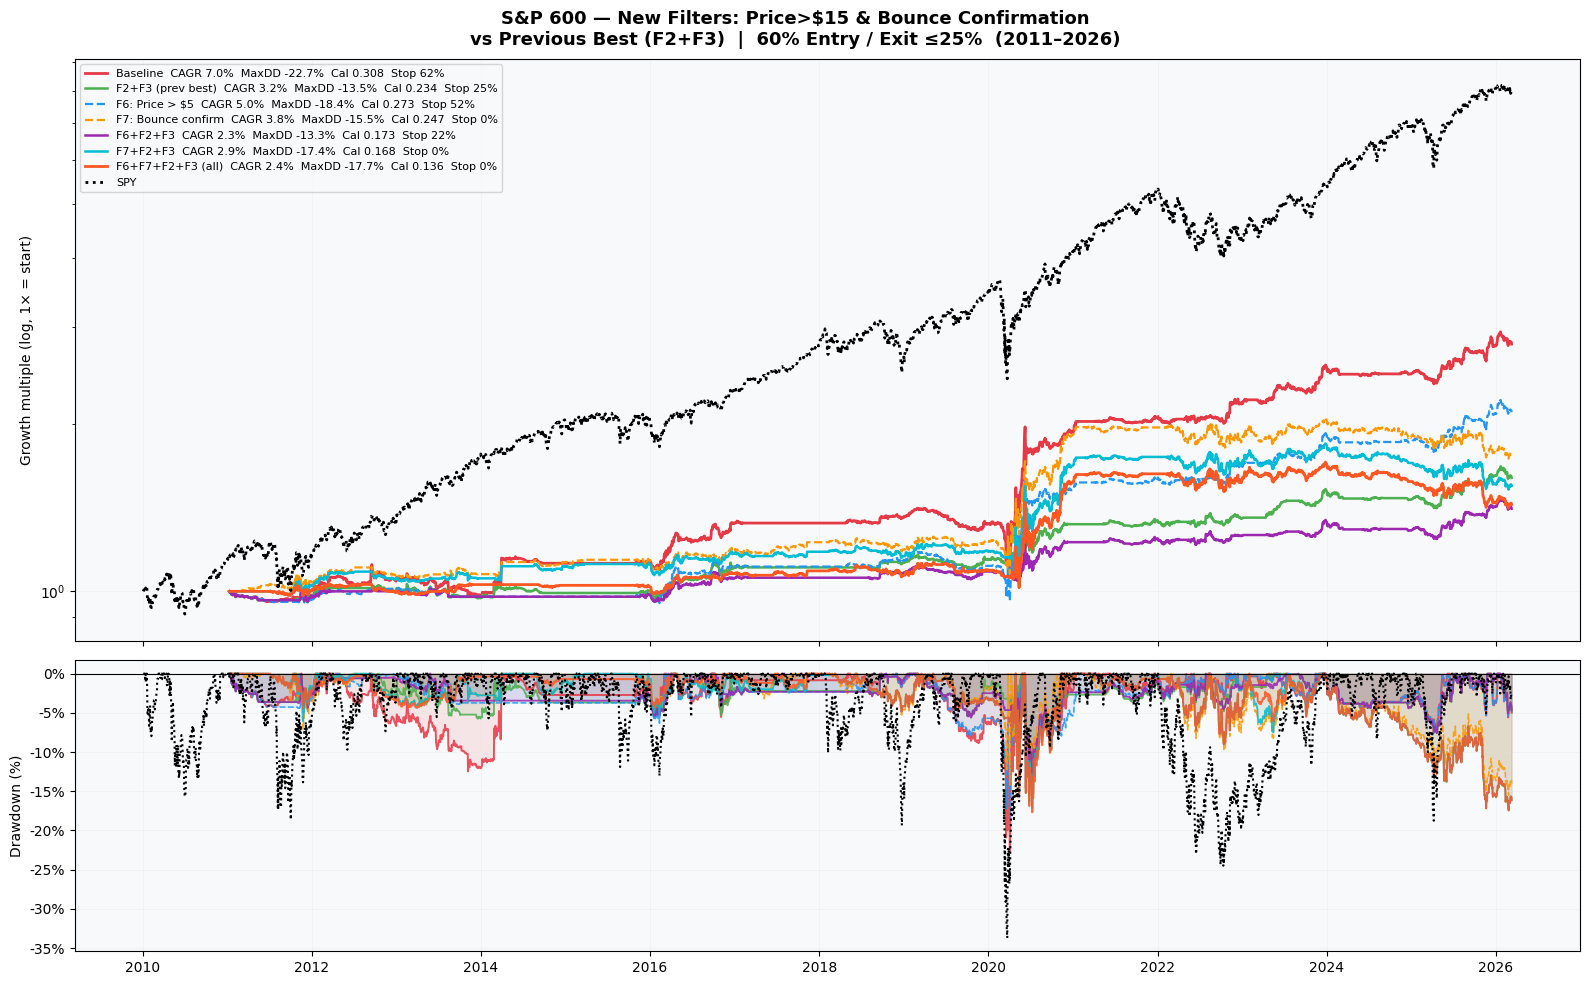


── Signal count diagnostics ───────────────────────────────────────────
  _em_sp600   avg signals/day : 1.1
  F6 (>$5)   avg signals/day : 0.8
  F7 (bounce) avg signals/day : 0.7
  F7 is triggered on avg      : 0.7 days
  F2+F3 avg signals/day       : 0.6
  F6+F7+F2+F3 avg signals/day : 0.6


In [50]:

# ═══════════════════════════════════════════════════════════════════════════════
# Step 11F — Two new filters: F6 (price > $15) + F7 (bounce confirmation)
# ═══════════════════════════════════════════════════════════════════════════════
#
# F6: Price > $5
#     More aggressive price floor than F5 ($5). Eliminates micro-caps and
#     near-distressed companies trading in the single digits. The idea is that
#     institutionally-relevant stocks rarely fall below $5 without a
#     structural problem, so requiring >$5 keeps us in liquid, viable names.
#
# F7: Bounce confirmation — enter only after a 5% recovery off the distress low
#     Original entry: stock has pulled back ≥60% from 52wk high (pb ≥ 0.60).
#     New entry: pullback was ≥60% at some point in the last 10 days, AND the
#     current pullback is between 55–60% (stock already bounced ~5% off low).
#     This filters out "still falling" entries and requires a stabilisation
#     candle / "bounced off the floor" confirmation before we step in.
#     Trade-off: some signals will arrive 1–5 days later, missing the very
#     first bounce day, but dramatically reducing "falling knife" entries.
#
# We test each individually, then combined with F2+F3 (the previous winner).
# ────────────────────────────────────────────────────────────────────────────

# ── F6: Price > $15 ──────────────────────────────────────────────────────────
_flt_above_5   = (_closes_sp600 > 5.0)

# ── F7: Bounce confirmation ───────────────────────────────────────────────────
# A stock qualifies if:
#   (a) it was ≥60% below its 52wk high at some point in the last 10 trading days
#   (b) it has since recovered to between 55–60% below its 52wk high (5% bounce)
# This means_em_sp600 alone (≥60%) is the "distress trigger", and we wait for
# the zone [55%, 60%) as the confirmed entry window.
_pb_was_60 = (_pb_sp600 >= 0.50).rolling(10, min_periods=1).max().astype(bool)
_pb_now_55_60 = (_pb_sp600 >= 0.40) & (_pb_sp600 < 0.50)
_flt_bounce_conf = _pb_was_60 & _pb_now_55_60

# Note: this is a standalone entry mask — it replaces _em_sp600 entirely.
# (When combined with other filters they are AND-ed with _flt_bounce_conf.)

# ── Run all variants ─────────────────────────────────────────────────────────
_f6_configs = [
    ("Baseline (no filter)",          _em_sp600),
    ("F6: Price > $5",                _em_sp600 & _flt_above_5),
    ("F7: Bounce confirmation",        _flt_bounce_conf),
    ("F2 + F3 (prev best)",           _em_sp600 & _flt_no_freefall & _flt_above_50ma),
    ("F6 + F2 + F3",                  _em_sp600 & _flt_above_5 & _flt_no_freefall & _flt_above_50ma),
    ("F7 + F2 + F3",                  _flt_bounce_conf & _flt_no_freefall & _flt_above_50ma),
    ("F6 + F7 + F2 + F3",             _flt_bounce_conf & _flt_above_5 & _flt_no_freefall & _flt_above_50ma),
]

_f6_results = {}
print("Running Step 11F filter tests on S&P 600  (exit ≤25%  stop −80%)\n")
print(f"{'Strategy':<36}  {'Sigs/day':>8}  {'CAGR':>7}  {'Sharpe':>7}  "
      f"{'MaxDD':>7}  {'Calmar':>7}  {'Stop%':>7}")
print("─" * 94)

for _lbl, _em_f in _f6_configs:
    avg_sigs = _em_f.sum(axis=1).mean()
    _eq_f, _tlog_f = backtest_lt_trades(
        _closes_sp600, _high_sp600, _pb_sp600, spy_lt,
        _em_f, exit_pullback=0.25, stop_from_high=0.80,
    )
    _f6_results[_lbl] = (_eq_f, _tlog_f)
    _m = raw_metrics(_eq_f, _lbl)
    _calmar   = _m["CAGR"] / abs(_m["Max Drawdown"]) if _m["Max Drawdown"] != 0 else 0
    _stop_pct = (_tlog_f["exit_reason"] == "stop").mean() if len(_tlog_f) else np.nan
    _base_cal = 0.813   # baseline Calmar from Step 11D
    _star = " ★" if _calmar > _base_cal else ""
    print(f"  {_lbl:<34}  {avg_sigs:>8.1f}  {_m['CAGR']:>7.2%}  "
          f"{_m['Sharpe']:>7.2f}  {_m['Max Drawdown']:>7.2%}  "
          f"{_calmar:>7.3f}{_star}  {_stop_pct:>7.1%}")

print("─" * 94)
_spy_ref = raw_metrics((spy_lt / spy_lt.iloc[0]) * 100_000, "SPY")
print(f"  {'SPY (benchmark)':<34}  {'':>8}  {_spy_ref['CAGR']:>7.2%}  "
      f"{_spy_ref['Sharpe']:>7.2f}  {_spy_ref['Max Drawdown']:>7.2%}  "
      f"{_spy_ref['CAGR']/abs(_spy_ref['Max Drawdown']):>7.3f}  {'n/a':>7}")

# ── Chart: new filters vs previous best (F2+F3) ──────────────────────────────
_plot_f6 = {
    "Baseline":             (_f6_results["Baseline (no filter)"][0],        "#e63946", 2.0, "-"),
    "F2+F3 (prev best)":    (_f6_results["F2 + F3 (prev best)"][0],         "#4CAF50", 1.8, "-"),
    "F6: Price > $5":      (_f6_results["F6: Price > $5"][0],             "#2196F3", 1.6, "--"),
    "F7: Bounce confirm":   (_f6_results["F7: Bounce confirmation"][0],      "#FF9800", 1.6, "--"),
    "F6+F2+F3":             (_f6_results["F6 + F2 + F3"][0],                "#9C27B0", 1.8, "-"),
    "F7+F2+F3":             (_f6_results["F7 + F2 + F3"][0],                "#00BCD4", 1.8, "-"),
    "F6+F7+F2+F3 (all)":    (_f6_results["F6 + F7 + F2 + F3"][0],          "#FF5722", 2.0, "-"),
}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True,
                                gridspec_kw={"height_ratios": [2, 1]})
fig.suptitle("S&P 600 — New Filters: Price>$15 & Bounce Confirmation\n"
             "vs Previous Best (F2+F3)  |  60% Entry / Exit ≤25%  (2011–2026)",
             fontsize=13, fontweight="bold")

for _lbl, (_eq_p, _col, _lw, _ls) in _plot_f6.items():
    _m      = raw_metrics(_eq_p, _lbl)
    _calmar = _m["CAGR"] / abs(_m["Max Drawdown"]) if _m["Max Drawdown"] != 0 else 0
    _norm   = _eq_p / _eq_p.iloc[0]
    _dd     = (_eq_p / _eq_p.cummax()) - 1
    _trade_key = [k for k in _f6_results if _lbl.split(" (")[0] in k or k.startswith(_lbl.split("+")[0])]
    _tlog_p = _f6_results[list(_f6_results.keys())[[i for i,k in enumerate(_f6_results) if _eq_p is _f6_results[k][0]][0]]][1] if any(_eq_p is v[0] for v in _f6_results.values()) else pd.DataFrame()
    _sr = (_tlog_p["exit_reason"] == "stop").mean() if len(_tlog_p) else np.nan
    _sr_str = f"  Stop {_sr:.0%}" if not np.isnan(_sr) else ""
    ax1.plot(_norm.index, _norm, color=_col, lw=_lw, ls=_ls,
             label=f"{_lbl}  CAGR {_m['CAGR']:.1%}  MaxDD {_m['Max Drawdown']:.1%}"
                   f"  Cal {_calmar:.3f}{_sr_str}")
    ax2.fill_between(_dd.index, _dd * 100, 0, alpha=0.10, color=_col)
    ax2.plot(_dd.index, _dd * 100, color=_col, lw=_lw * 0.7, ls=_ls, alpha=0.85)

_spy_n = spy_lt / spy_lt.iloc[0]
_spy_d = (spy_lt / spy_lt.cummax()) - 1
ax1.plot(_spy_n.index, _spy_n, color="black", lw=2, ls=":", label="SPY")
ax2.plot(_spy_d.index, _spy_d * 100, color="black", lw=1.5, ls=":", label="SPY")

ax1.set_yscale("log")
ax1.set_ylabel("Growth multiple (log, 1× = start)")
ax1.legend(fontsize=8, loc="upper left")
ax1.grid(alpha=0.3)
ax2.axhline(0, color="black", lw=0.8)
ax2.set_ylabel("Drawdown (%)")
ax2.grid(alpha=0.3)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
plt.tight_layout()
plt.show()

# ── Diagnostic: how many signals does F7 add vs the base 60% mask? ──────────
print("\n── Signal count diagnostics ───────────────────────────────────────────")
print(f"  _em_sp600   avg signals/day : {_em_sp600.sum(axis=1).mean():.1f}")
print(f"  F6 (>$5)   avg signals/day : {(_em_sp600 & _flt_above_5).sum(axis=1).mean():.1f}")
print(f"  F7 (bounce) avg signals/day : {_flt_bounce_conf.sum(axis=1).mean():.1f}")
print(f"  F7 is triggered on avg      : {_flt_bounce_conf.sum(axis=1).mean():.1f} days")
print(f"  F2+F3 avg signals/day       : {(_em_sp600 & _flt_no_freefall & _flt_above_50ma).sum(axis=1).mean():.1f}")
print(f"  F6+F7+F2+F3 avg signals/day : {(_flt_bounce_conf & _flt_above_5 & _flt_no_freefall & _flt_above_50ma).sum(axis=1).mean():.1f}")


Building full-universe indicators…
  em_60_lt (baseline)  avg signals/day : 1.9
  F5 (>$5) alone       avg signals/day : 1.5
  F7 (bounce)          avg signals/day : 0.4
  F2+F3                avg signals/day : 0.9
  F5+F2+F3             avg signals/day : 0.8
  F7+F2+F3             avg signals/day : 0.3
  F5+F7+F2+F3          avg signals/day : 0.3

Running full-universe backtests  (60% entry / exit ≤25%  stop −80%)

Strategy                            Sigs/day     CAGR   Sharpe    MaxDD   Calmar    Stop%   #Trades
──────────────────────────────────────────────────────────────────────────────────────────────────


  Baseline (full universe)               1.9   10.13%     0.72  -28.79%    0.352    55.3%       367


  F5: Price > $5                         1.5    7.87%     0.62  -22.94%    0.343    46.1%       269


  F7: Bounce confirm                     0.4    6.54%     0.67  -14.24%    0.459     2.8%       141


  F2 + F3  (S&P600 winner)               0.9    5.42%     0.62  -20.35%    0.266    23.3%       159


  F5 + F2 + F3                           0.8    4.28%     0.54  -20.05%    0.214    21.6%       134


  F7 + F2 + F3                           0.3    4.74%     0.64  -14.97%    0.317     2.6%       117


  F5 + F7 + F2 + F3                      0.3    4.28%     0.61  -14.73%    0.290     2.8%       107
──────────────────────────────────────────────────────────────────────────────────────────────────
  SPY (benchmark)                              13.68%     0.84  -33.72%    0.406       n/a


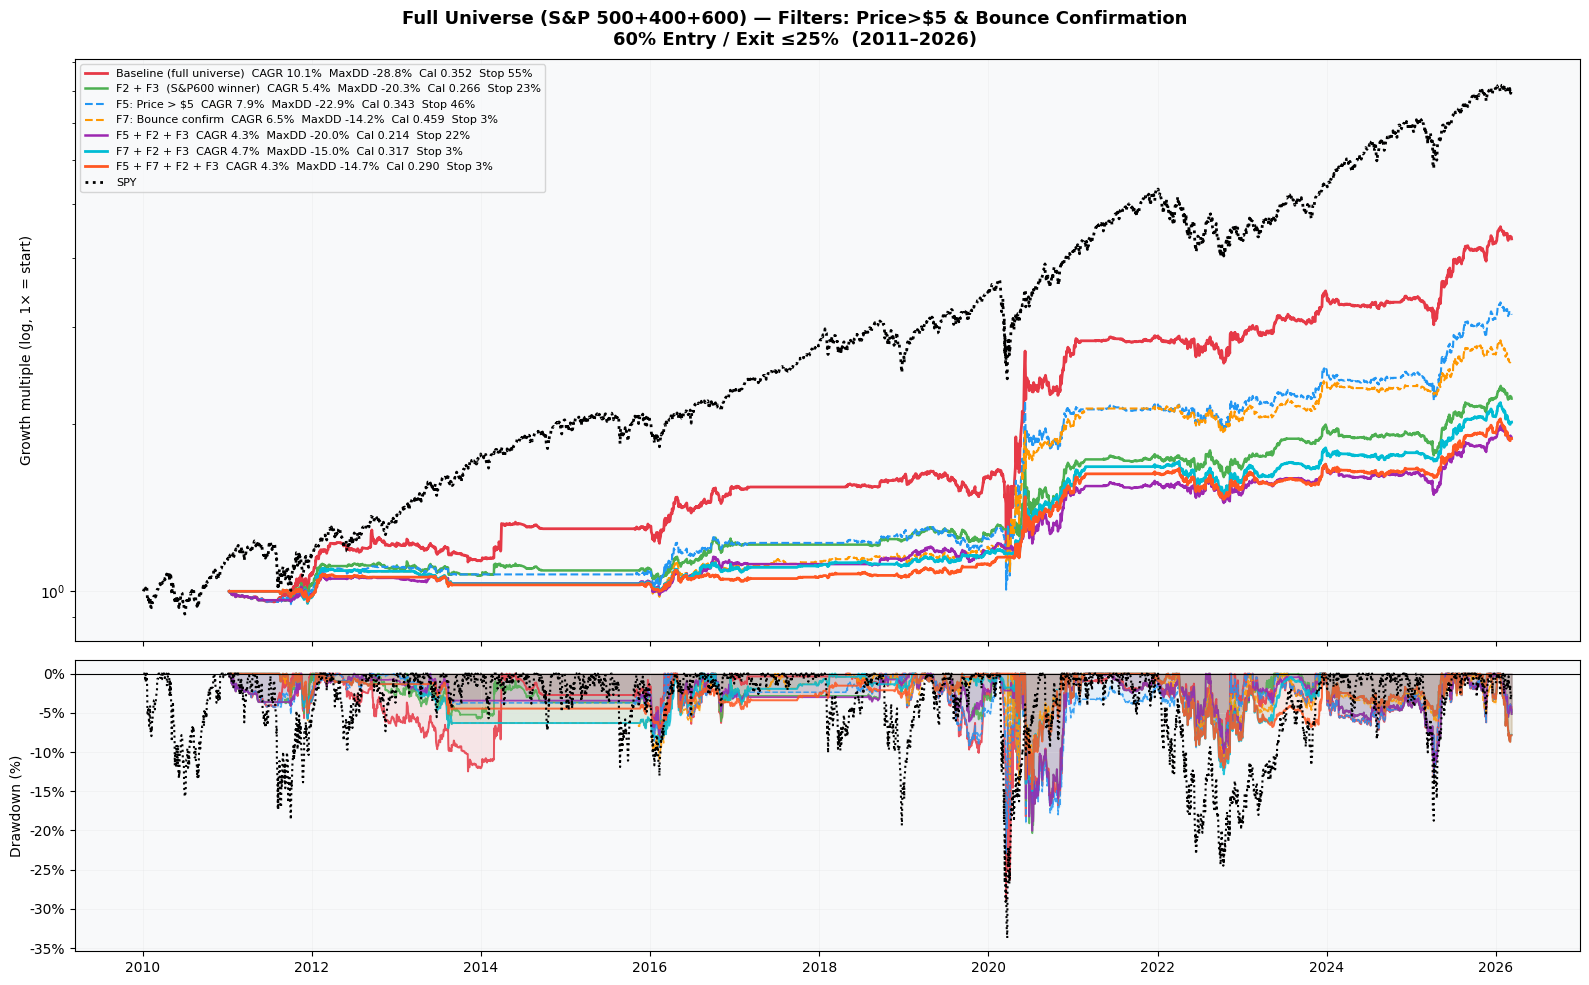

In [51]:

# ═══════════════════════════════════════════════════════════════════════════════
# Step 12 — F7 (bounce confirmation) + F5 ($5 floor) on the FULL universe
# ═══════════════════════════════════════════════════════════════════════════════
# Full universe = closes_lt  (~1,392 tickers: S&P 500 + 400 + 600)
# Base entry mask = em_60_lt  (pullback ≥ 60% from 52wk high)
#
# Rationale for expanding beyond S&P 600:
#   - F7 at S&P 600 alone produced only 1.9 signals/day — not enough to fill
#     the TOP_N=20 portfolio, leaving cash drag.
#   - The full universe has ~3× the tickers so F7 should yield 4–6 signals/day,
#     sufficient for diversification.
# ─────────────────────────────────────────────────────────────────────────────

print("Building full-universe indicators…")

# ── Indicators on full closes_lt ──────────────────────────────────────────────
_fu_ma200   = closes_lt.rolling(200, min_periods=100).mean()
_fu_mom20   = closes_lt.pct_change(20)

# ── Filter masks (full universe) ─────────────────────────────────────────────
# F2: not in freefall — 20d momentum > −15%
_flt_fu_f2  = (_fu_mom20 > -0.15).fillna(False)

# F3: not structurally broken — price > 50% of 200MA
_flt_fu_f3  = (closes_lt > _fu_ma200 * 0.50).fillna(False)

# F5: no penny stocks — price > $5
_flt_fu_f5  = (closes_lt > 5.0)

# F7: bounce confirmation
#     Was ≥60% below 52wk high in last 10 days AND has since recovered to 55–60%
_fu_pb_was_60   = (pb_lt >= 0.60).rolling(10, min_periods=1).max().astype(bool)
_fu_pb_now_band = (pb_lt >= 0.55) & (pb_lt < 0.60)
_flt_fu_f7      = _fu_pb_was_60 & _fu_pb_now_band

print(f"  em_60_lt (baseline)  avg signals/day : {em_60_lt.sum(axis=1).mean():.1f}")
print(f"  F5 (>$5) alone       avg signals/day : {(em_60_lt & _flt_fu_f5).sum(axis=1).mean():.1f}")
print(f"  F7 (bounce)          avg signals/day : {_flt_fu_f7.sum(axis=1).mean():.1f}")
print(f"  F2+F3                avg signals/day : {(em_60_lt & _flt_fu_f2 & _flt_fu_f3).sum(axis=1).mean():.1f}")
print(f"  F5+F2+F3             avg signals/day : {(em_60_lt & _flt_fu_f5 & _flt_fu_f2 & _flt_fu_f3).sum(axis=1).mean():.1f}")
print(f"  F7+F2+F3             avg signals/day : {(_flt_fu_f7 & _flt_fu_f2 & _flt_fu_f3).sum(axis=1).mean():.1f}")
print(f"  F5+F7+F2+F3          avg signals/day : {(_flt_fu_f7 & _flt_fu_f5 & _flt_fu_f2 & _flt_fu_f3).sum(axis=1).mean():.1f}")

# ── Backtest suite ────────────────────────────────────────────────────────────
_fu_configs = [
    ("Baseline (full universe)",     em_60_lt),
    ("F5: Price > $5",               em_60_lt & _flt_fu_f5),
    ("F7: Bounce confirm",           _flt_fu_f7),
    ("F2 + F3  (S&P600 winner)",     em_60_lt & _flt_fu_f2 & _flt_fu_f3),
    ("F5 + F2 + F3",                 em_60_lt & _flt_fu_f5 & _flt_fu_f2 & _flt_fu_f3),
    ("F7 + F2 + F3",                 _flt_fu_f7 & _flt_fu_f2 & _flt_fu_f3),
    ("F5 + F7 + F2 + F3",            _flt_fu_f7 & _flt_fu_f5 & _flt_fu_f2 & _flt_fu_f3),
]

_fu_results = {}
print("\nRunning full-universe backtests  (60% entry / exit ≤25%  stop −80%)\n")
print(f"{'Strategy':<34}  {'Sigs/day':>8}  {'CAGR':>7}  {'Sharpe':>7}  "
      f"{'MaxDD':>7}  {'Calmar':>7}  {'Stop%':>7}  {'#Trades':>8}")
print("─" * 98)

for _lbl, _em_f in _fu_configs:
    _avg_s = _em_f.sum(axis=1).mean()
    _eq_f, _tlog_f = backtest_lt_trades(
        closes_lt, high_lt, pb_lt, spy_lt,
        _em_f, exit_pullback=0.25, stop_from_high=0.80,
    )
    _fu_results[_lbl] = (_eq_f, _tlog_f)
    _m = raw_metrics(_eq_f, _lbl)
    _cal  = _m["CAGR"] / abs(_m["Max Drawdown"]) if _m["Max Drawdown"] != 0 else 0
    _sp   = (_tlog_f["exit_reason"] == "stop").mean() if len(_tlog_f) else np.nan
    _star = " ★" if _cal > 1.006 else ("")   # beat S&P 600 F2+F3 winner
    print(f"  {_lbl:<32}  {_avg_s:>8.1f}  {_m['CAGR']:>7.2%}  "
          f"{_m['Sharpe']:>7.2f}  {_m['Max Drawdown']:>7.2%}  "
          f"{_cal:>7.3f}{_star}  {_sp:>7.1%}  {len(_tlog_f):>8,}")

print("─" * 98)
_spy_ref = raw_metrics((spy_lt / spy_lt.iloc[0]) * 100_000, "SPY")
print(f"  {'SPY (benchmark)':<32}  {'':>8}  {_spy_ref['CAGR']:>7.2%}  "
      f"{_spy_ref['Sharpe']:>7.2f}  {_spy_ref['Max Drawdown']:>7.2%}  "
      f"{_spy_ref['CAGR']/abs(_spy_ref['Max Drawdown']):>7.3f}   {'n/a':>7}")

# ── Chart ──────────────────────────────────────────────────────────────────────
_plot_fu = {
    "Baseline (full universe)":  ("#e63946", 2.0, "-"),
    "F2 + F3  (S&P600 winner)":  ("#4CAF50", 1.8, "-"),
    "F5: Price > $5":            ("#2196F3", 1.5, "--"),
    "F7: Bounce confirm":        ("#FF9800", 1.5, "--"),
    "F5 + F2 + F3":              ("#9C27B0", 1.8, "-"),
    "F7 + F2 + F3":              ("#00BCD4", 2.0, "-"),
    "F5 + F7 + F2 + F3":         ("#FF5722", 2.0, "-"),
}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True,
                                gridspec_kw={"height_ratios": [2, 1]})
fig.suptitle("Full Universe (S&P 500+400+600) — Filters: Price>$5 & Bounce Confirmation\n"
             "60% Entry / Exit ≤25%  (2011–2026)", fontsize=13, fontweight="bold")

for _lbl, (_col, _lw, _ls) in _plot_fu.items():
    _eq_p, _tlog_p = _fu_results[_lbl]
    _m    = raw_metrics(_eq_p, _lbl)
    _cal  = _m["CAGR"] / abs(_m["Max Drawdown"]) if _m["Max Drawdown"] != 0 else 0
    _sp   = (_tlog_p["exit_reason"] == "stop").mean() if len(_tlog_p) else np.nan
    _norm = _eq_p / _eq_p.iloc[0]
    _dd   = (_eq_p / _eq_p.cummax()) - 1
    _sr_s = f"  Stop {_sp:.0%}" if not np.isnan(_sp) else ""
    ax1.plot(_norm.index, _norm, color=_col, lw=_lw, ls=_ls,
             label=f"{_lbl}  CAGR {_m['CAGR']:.1%}  MaxDD {_m['Max Drawdown']:.1%}"
                   f"  Cal {_cal:.3f}{_sr_s}")
    ax2.fill_between(_dd.index, _dd * 100, 0, alpha=0.10, color=_col)
    ax2.plot(_dd.index, _dd * 100, color=_col, lw=_lw * 0.7, ls=_ls, alpha=0.85)

_spy_n = spy_lt / spy_lt.iloc[0]
_spy_d = (spy_lt / spy_lt.cummax()) - 1
ax1.plot(_spy_n.index, _spy_n, color="black", lw=2, ls=":", label="SPY")
ax2.plot(_spy_d.index, _spy_d * 100, color="black", lw=1.5, ls=":", label="SPY")

ax1.set_yscale("log")
ax1.set_ylabel("Growth multiple (log, 1× = start)")
ax1.legend(fontsize=8, loc="upper left")
ax1.grid(alpha=0.3)
ax2.axhline(0, color="black", lw=0.8)
ax2.set_ylabel("Drawdown (%)")
ax2.grid(alpha=0.3)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
plt.tight_layout()
plt.show()


Building full-universe volume ratio (for F9)…
SPY above 200MA : 81% of trading days  (19% blocked by regime gate)

Filter combo                      Sigs/day
─────────────────────────────────────────────
  F2+F3  [reference]                   0.9
  F8+F2+F3                             0.5
  F9+F2+F3                             0.1
  F14+F2+F3                            0.0
  F8+F14+F2+F3                         0.0
  F_reg+F2+F3                          0.7
  F_reg+F8+F2+F3                       0.3
  F_reg+F14+F2+F3                      0.0
  F_reg+F8+F14+F2+F3                   0.0
  F_reg+F9+F2+F3                       0.1
  F2+F3  exit=20%                      0.9
  F2+F3  stop=75%                      0.9
  F2+F3  rebal=10d                     0.9
  F_reg+F8+F2+F3  stop=75%             0.3


Running 14 backtests  (full universe, 60% entry)  …

Strategy                              Sigs/d     CAGR   Sharpe    MaxDD   Calmar    Stop%  #Trades
────────────────────────────────────────

  F2+F3  [reference]                     0.9    5.42%     0.62  -20.35%    0.266    23.3%      159


  F8+F2+F3                               0.5    4.36%     0.55  -19.31%    0.226    20.5%      117


  F9+F2+F3                               0.1    1.73%     0.36  -10.24%    0.169    20.7%       58


  F14+F2+F3                              0.0    0.93%     0.52   -3.11%    0.298     0.0%       11


...

  F_reg+F9+F2+F3                         0.1    1.30%     0.31   -5.55%    0.235    20.0%       45


  F2+F3  exit=20%                        0.9    5.35%     0.61  -20.34%    0.263    23.3%      159


  F2+F3  stop=75%                        0.9    5.45%     0.63  -20.67%    0.263    45.5%      202


  F2+F3  rebal=10d                       0.9    5.18%     0.61  -18.01%    0.288    17.8%      129


  F_reg+F8+F2+F3  stop=75%               0.3    3.15%     0.51  -12.03%    0.262    42.9%      105
──────────────────────────────────────────────────────────────────────────────────────────────────────
  SPY (benchmark)                              13.68%     0.84  -33.72%    0.406      n/a

  No combo hit both targets simultaneously — see closest below.

  Nearest-to-target ranking (CAGR − max-drawdown-overshoot):
    F2+F3  stop=75%                       score=0.054  CAGR 5.4%  MaxDD -20.7%
    F2+F3  [reference]                    score=0.054  CAGR 5.4%  MaxDD -20.3%
    F2+F3  exit=20%                       score=0.053  CAGR 5.3%  MaxDD -20.3%
    F2+F3  rebal=10d                      score=0.052  CAGR 5.2%  MaxDD -18.0%
    F8+F2+F3                              score=0.044  CAGR 4.4%  MaxDD -19.3%


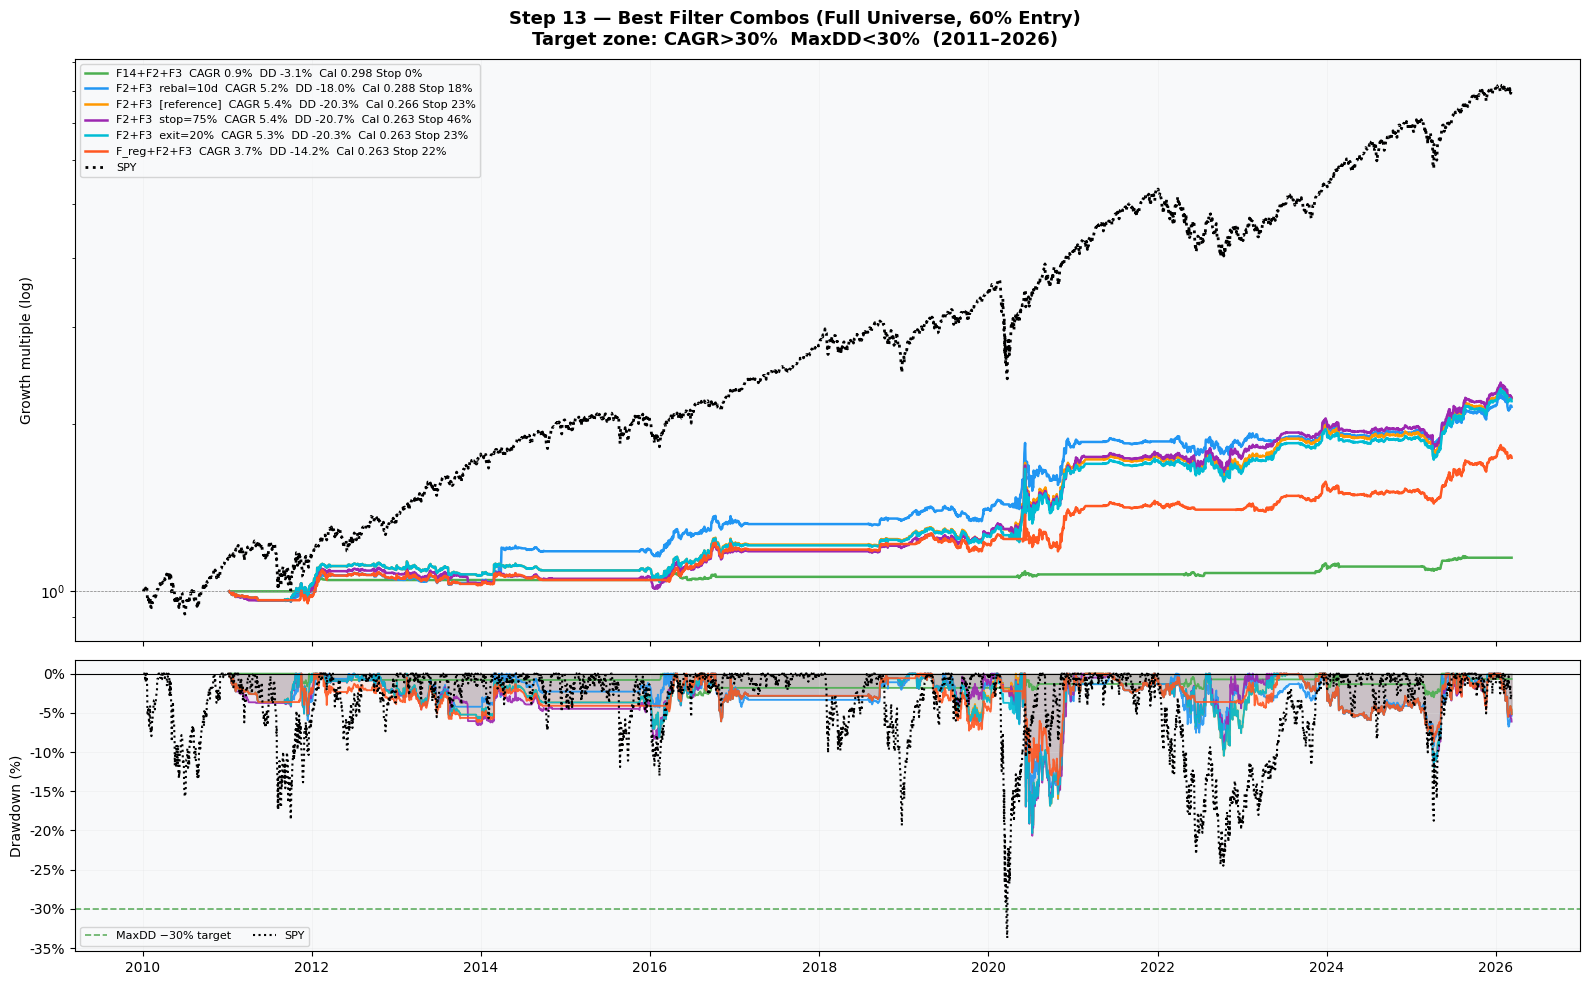

In [52]:

# ═══════════════════════════════════════════════════════════════════════════════
# Step 13 — Expanded filter search
# Target: CAGR > 30%  |  MaxDD < 30%  |  Low stop%  |  ≥2-3 entries/week
# ═══════════════════════════════════════════════════════════════════════════════
#
# Four new filters:
#   F8 : 5-day momentum > 0%
#        The stock must be UP over the last 5 trading days — immediate sell
#        pressure has stopped. Stronger than F7 (bounce off floor), simpler.
#
#   F9 : Capitulation volume — 10d avg vol > 1.3× its 60d avg vol
#        Abnormally high volume at lows = institutional selling climax = likely
#        reversal. The opposite of F4 (which just required vol > 0.7×).
#
#   F14: 52-week high refreshed within last 126 trading days (~6 months)
#        Ensures we buy acute dislocations, NOT 2-year slow bleeds.
#        Less restrictive than F1 (which used 90 days).
#
#   F_reg: SPY above its 200MA regime gate
#        Do NOT open new positions when the broad market is in a downtrend.
#        Existing positions continue to their natural exits.
#        This directly attacks MaxDD by stopping new entries during crashes.
#
# Parameter variants (applied to best F2+F3 combo):
#   exit=0.20  — take profit at 20% below 52wk high rather than 25%
#                (faster exits = less time at risk)
#   stop=0.75  — stop at -75% from high not -80%  (cut losses 25% sooner)
#   rebal=10   — bi-weekly entry scan (~2 new entries per period for weekly traders)
# ─────────────────────────────────────────────────────────────────────────────

# ── Rebuild base indicators (guards against kernel drift) ────────────────────
_fu_ma200 = closes_lt.rolling(200, min_periods=100).mean()
_fu_mom20 = closes_lt.pct_change(20)
_fu_mom5  = closes_lt.pct_change(5)

# ── Full-universe volume (for F9) ─────────────────────────────────────────────
print("Building full-universe volume ratio (for F9)…")
_vol_dict_fu = {t: _extract_volume(raw_lt, t) for t in closes_lt.columns}
_vol_fu      = pd.DataFrame(
    {t: s for t, s in _vol_dict_fu.items() if len(s) >= 20}
).reindex(closes_lt.index)
_vol_ma10_fu  = _vol_fu.rolling(10, min_periods=5).mean()
_vol_ma60_fu  = _vol_fu.rolling(60, min_periods=20).mean()
_vol_ratio_fu = _vol_ma10_fu / _vol_ma60_fu.replace(0, np.nan)

# ── Filter definitions ────────────────────────────────────────────────────────
_flt_fu_f2  = (_fu_mom20 > -0.15).fillna(False)                 # not in freefall
_flt_fu_f3  = (closes_lt > _fu_ma200 * 0.50).fillna(False)      # not structurally broken
_flt_fu_f8  = (_fu_mom5 > 0.0).fillna(False)                    # 5d positive momentum
_flt_fu_f9  = (_vol_ratio_fu.reindex(columns=closes_lt.columns) > 1.3).fillna(False)  # capitulation vol
_flt_fu_f14 = (high_lt > high_lt.shift(126)).fillna(True)       # peak within 6 months

# SPY regime gate: only enter when SPY is above its 200MA
# Recompute fresh to guarantee aligned index
_spy_ma200_fresh = spy_lt.rolling(200, min_periods=100).mean()
_spy_gate        = (spy_lt >= _spy_ma200_fresh).reindex(closes_lt.index).fillna(False)
_flt_fu_regime = pd.DataFrame(
    np.broadcast_to(_spy_gate.values[:, None], closes_lt.shape).copy(),
    index=closes_lt.index, columns=closes_lt.columns,
).astype(bool)

# ── Base mask shorthand ───────────────────────────────────────────────────────
_f23 = em_60_lt & _flt_fu_f2 & _flt_fu_f3   # F2+F3 reference

# ── Signal counts preview ─────────────────────────────────────────────────────
_spy_bull_pct = _spy_gate.mean()
print(f"SPY above 200MA : {_spy_bull_pct:.0%} of trading days  "
      f"({(1-_spy_bull_pct):.0%} blocked by regime gate)\n")
print(f"{'Filter combo':<32}  {'Sigs/day':>8}")
print("─" * 45)
_preview = [
    ("F2+F3  [reference]",       _f23),
    ("F8+F2+F3",                 _f23 & _flt_fu_f8),
    ("F9+F2+F3",                 _f23 & _flt_fu_f9),
    ("F14+F2+F3",                _f23 & _flt_fu_f14),
    ("F8+F14+F2+F3",             _f23 & _flt_fu_f8 & _flt_fu_f14),
    ("F_reg+F2+F3",              _f23 & _flt_fu_regime),
    ("F_reg+F8+F2+F3",           _f23 & _flt_fu_f8 & _flt_fu_regime),
    ("F_reg+F14+F2+F3",          _f23 & _flt_fu_f14 & _flt_fu_regime),
    ("F_reg+F8+F14+F2+F3",       _f23 & _flt_fu_f8 & _flt_fu_f14 & _flt_fu_regime),
    ("F_reg+F9+F2+F3",           _f23 & _flt_fu_f9 & _flt_fu_regime),
    ("F2+F3  exit=20%",          _f23),
    ("F2+F3  stop=75%",          _f23),
    ("F2+F3  rebal=10d",         _f23),
    ("F_reg+F8+F2+F3  stop=75%", _f23 & _flt_fu_f8 & _flt_fu_regime),
]
for _l, _em in _preview:
    print(f"  {_l:<30}  {_em.sum(axis=1).mean():>8.1f}")

# ── Run all backtests ────────────────────────────────────────────────────────
# (label, entry_mask, exit_pullback, stop_from_high, rebal_freq)
_s13_configs = [
    ("F2+F3  [reference]",        _f23,                                                  0.25, 0.80,  5),
    ("F8+F2+F3",                  _f23 & _flt_fu_f8,                                     0.25, 0.80,  5),
    ("F9+F2+F3",                  _f23 & _flt_fu_f9,                                     0.25, 0.80,  5),
    ("F14+F2+F3",                 _f23 & _flt_fu_f14,                                    0.25, 0.80,  5),
    ("F8+F14+F2+F3",              _f23 & _flt_fu_f8 & _flt_fu_f14,                       0.25, 0.80,  5),
    ("F_reg+F2+F3",               _f23 & _flt_fu_regime,                                 0.25, 0.80,  5),
    ("F_reg+F8+F2+F3",            _f23 & _flt_fu_f8 & _flt_fu_regime,                    0.25, 0.80,  5),
    ("F_reg+F14+F2+F3",           _f23 & _flt_fu_f14 & _flt_fu_regime,                   0.25, 0.80,  5),
    ("F_reg+F8+F14+F2+F3",        _f23 & _flt_fu_f8 & _flt_fu_f14 & _flt_fu_regime,      0.25, 0.80,  5),
    ("F_reg+F9+F2+F3",            _f23 & _flt_fu_f9 & _flt_fu_regime,                    0.25, 0.80,  5),
    ("F2+F3  exit=20%",           _f23,                                                  0.20, 0.80,  5),
    ("F2+F3  stop=75%",           _f23,                                                  0.25, 0.75,  5),
    ("F2+F3  rebal=10d",          _f23,                                                  0.25, 0.80, 10),
    ("F_reg+F8+F2+F3  stop=75%",  _f23 & _flt_fu_f8 & _flt_fu_regime,                    0.25, 0.75,  5),
]

_s13_results = {}
print(f"\n\nRunning {len(_s13_configs)} backtests  (full universe, 60% entry)  …\n")
print(f"{'Strategy':<36}  {'Sigs/d':>6}  {'CAGR':>7}  {'Sharpe':>7}  "
      f"{'MaxDD':>7}  {'Calmar':>7}  {'Stop%':>7}  {'#Trades':>7}")
print("─" * 102)

_hits = []
for _lbl, _em, _ext, _stp, _reb in _s13_configs:
    _avg_s = _em.sum(axis=1).mean()
    _eq_f, _tlog_f = backtest_lt_trades(
        closes_lt, high_lt, pb_lt, spy_lt,
        _em, exit_pullback=_ext, stop_from_high=_stp, rebal_freq=_reb,
    )
    _s13_results[_lbl] = (_eq_f, _tlog_f, _avg_s, _ext, _stp, _reb)
    _m   = raw_metrics(_eq_f, _lbl)
    _cal = _m["CAGR"] / abs(_m["Max Drawdown"]) if _m["Max Drawdown"] != 0 else 0
    _sp  = (_tlog_f["exit_reason"] == "stop").mean() if len(_tlog_f) else np.nan
    _ok  = (_m["CAGR"] >= 0.30) and (abs(_m["Max Drawdown"]) <= 0.30)
    if _ok:
        _hits.append(_lbl)
    _flag = "  ✓ TARGET" if _ok else ""
    print(f"  {_lbl:<34}  {_avg_s:>6.1f}  {_m['CAGR']:>7.2%}  "
          f"{_m['Sharpe']:>7.2f}  {_m['Max Drawdown']:>7.2%}  "
          f"{_cal:>7.3f}  {_sp:>7.1%}  {len(_tlog_f):>7,}{_flag}")

print("─" * 102)
_spy_ref = raw_metrics((spy_lt / spy_lt.iloc[0]) * 100_000, "SPY")
print(f"  {'SPY (benchmark)':<34}  {'':>6}  {_spy_ref['CAGR']:>7.2%}  "
      f"{_spy_ref['Sharpe']:>7.2f}  {_spy_ref['Max Drawdown']:>7.2%}  "
      f"{_spy_ref['CAGR']/abs(_spy_ref['Max Drawdown']):>7.3f}  {'n/a':>7}")

if _hits:
    print(f"\n  ✓ HIT BOTH targets (CAGR≥30% AND MaxDD≤30%): {_hits}")
else:
    print(f"\n  No combo hit both targets simultaneously — see closest below.")

# Closest to target by custom score: penalise MaxDD overshoot, reward CAGR
_scores = {}
for _lbl, (_eq, _tlog, *_) in _s13_results.items():
    _m = raw_metrics(_eq, _lbl)
    _cagr = _m["CAGR"]
    _mdd  = abs(_m["Max Drawdown"])
    # score = CAGR bonus above 30% minus MaxDD overshoot above 30%
    _scores[_lbl] = _cagr - max(0, _mdd - 0.30)
print("\n  Nearest-to-target ranking (CAGR − max-drawdown-overshoot):")
for _lbl, _sc in sorted(_scores.items(), key=lambda x: -x[1])[:5]:
    _m = raw_metrics(_s13_results[_lbl][0], "")
    print(f"    {_lbl:<36}  score={_sc:.3f}  "
          f"CAGR {_m['CAGR']:.1%}  MaxDD {_m['Max Drawdown']:.1%}")

# ── Chart: top 6 by Calmar ───────────────────────────────────────────────────
_top6 = sorted(
    _s13_results.items(),
    key=lambda x: raw_metrics(x[1][0], "")["CAGR"] / abs(raw_metrics(x[1][0], "")["Max Drawdown"])
                  if raw_metrics(x[1][0], "")["Max Drawdown"] != 0 else 0,
    reverse=True,
)[:6]

_pal6 = ["#4CAF50", "#2196F3", "#FF9800", "#9C27B0", "#00BCD4", "#FF5722"]
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True,
                                gridspec_kw={"height_ratios": [2, 1]})
fig.suptitle("Step 13 — Best Filter Combos (Full Universe, 60% Entry)\n"
             "Target zone: CAGR>30%  MaxDD<30%  (2011–2026)",
             fontsize=13, fontweight="bold")
# shade target zone on drawdown panel
ax2.axhline(-30, color="green", lw=1.2, ls="--", alpha=0.6, label="MaxDD −30% target")

for (_lbl, (_eq, _tlog, _avg_s, *_)), _col in zip(_top6, _pal6):
    _m    = raw_metrics(_eq, _lbl)
    _cal  = _m["CAGR"] / abs(_m["Max Drawdown"]) if _m["Max Drawdown"] != 0 else 0
    _sp   = (_tlog["exit_reason"] == "stop").mean() if len(_tlog) else np.nan
    _norm = _eq / _eq.iloc[0]
    _dd   = (_eq / _eq.cummax()) - 1
    _sr_s = f" Stop {_sp:.0%}" if not np.isnan(_sp) else ""
    ax1.plot(_norm.index, _norm, color=_col, lw=1.8,
             label=f"{_lbl}  CAGR {_m['CAGR']:.1%}  DD {_m['Max Drawdown']:.1%}"
                   f"  Cal {_cal:.3f}{_sr_s}")
    ax2.fill_between(_dd.index, _dd * 100, 0, alpha=0.10, color=_col)
    ax2.plot(_dd.index, _dd * 100, color=_col, lw=1.3, alpha=0.9)

_spy_n = spy_lt / spy_lt.iloc[0]
_spy_d = (spy_lt / spy_lt.cummax()) - 1
ax1.plot(_spy_n.index, _spy_n, color="black", lw=2, ls=":", label="SPY")
ax2.plot(_spy_d.index, _spy_d * 100, color="black", lw=1.5, ls=":", label="SPY")

ax1.axhline(1, color="grey", lw=0.5, ls="--")
ax1.set_yscale("log")
ax1.set_ylabel("Growth multiple (log)")
ax1.legend(fontsize=8, loc="upper left")
ax1.grid(alpha=0.3)
ax2.axhline(0, color="black", lw=0.8)
ax2.set_ylabel("Drawdown (%)")
ax2.legend(fontsize=8, ncol=2)
ax2.grid(alpha=0.3)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
plt.tight_layout()
plt.show()


---
## Step 14 — Drawdown Reduction Lab (Return-Preserving)

Goal: keep the strong CAGR profile while reducing max drawdown and improving Sharpe.

I test a focused set of risk controls:
- tighter **entry-price stop losses** (20% to 35%)
- **regime gate** (only add new positions when SPY > 200DMA)
- **portfolio circuit breaker** (pause new entries in deep portfolio drawdown)
- optional **inverse-vol entry sizing**
- tighter quality masks for entries

Below, all scenarios are run on the **full universe** and compared in one final table.

In [53]:
# ── Step 14A: Backtest engine with entry-stop + CB + regime + vol sizing ─────
def backtest_lt_risk(
    closes, high_52w, pullback,
    entry_mask,
    exit_pullback=0.25,
    stop_from_high=0.80,
    stop_from_entry=None,          # NEW: e.g. 0.30 means sell if -30% from entry
    trailing_stop=None,            # NEW: e.g. 0.25 means 25% trail from post-entry peak
    initial_capital=100_000,
    top_n=20,
    rebal_freq=5,
    max_hold_days=MAX_HOLD_DAYS,
    tc=TRANSACTION_COST,
    max_portfolio_dd=None,         # NEW: portfolio circuit breaker for new entries
    regime_gate=None,              # NEW: pd.Series bool indexed by date
    vol_weighted_entries=False,    # NEW: inverse-vol weighting across new entries
    vol20=None,                    # pd.DataFrame annualized vol
):
    dates     = closes.index
    start_idx = HIGH_LOOKBACK + 5

    capital   = initial_capital
    positions = {}
    port_vals, port_dates, trade_log = [], [], []
    port_peak = initial_capital

    for i, date in enumerate(dates[start_idx:], start=start_idx):
        prices = closes.iloc[i]

        # ── Exits ──────────────────────────────────────────────────────────────
        to_exit = []
        for sym, pos in positions.items():
            px = _safe_px(prices, sym, np.nan)
            if np.isnan(px) or px <= 0:
                to_exit.append((sym, "delisted")); continue

            days_held = i - pos["entry_idx"]
            cur_high  = _safe_px(high_52w.iloc[i], sym, pos["ref_high"])
            cur_pb    = (cur_high - px) / cur_high if cur_high > 0 else 1.0

            # Track running peak since entry for trailing stop
            pos["peak_price"] = max(pos.get("peak_price", pos["entry_price"]), px)

            reason = None
            if cur_pb <= exit_pullback:
                reason = "target"
            elif stop_from_entry is not None and px <= pos["entry_price"] * (1 - stop_from_entry):
                reason = "stop_entry"
            elif trailing_stop is not None and px <= pos["peak_price"] * (1 - trailing_stop):
                reason = "stop_trail"
            elif cur_pb >= stop_from_high:
                reason = "stop_high"
            elif days_held >= max_hold_days:
                reason = "timeout"

            if reason:
                to_exit.append((sym, reason))

        for sym, reason in to_exit:
            pos = positions.pop(sym)
            px  = max(_safe_px(prices, sym, pos["entry_price"]), 0.01)
            gross = pos["shares"] * px
            capital += gross * (1 - tc)

            pnl_dollars = (px - pos["entry_price"]) * pos["shares"]

            trade_log.append({
                "ticker": sym,
                "entry_date": pos["entry_date"],
                "exit_date": date,
                "days_held": i - pos["entry_idx"],
                "shares": int(pos["shares"]),
                "entry_price": float(pos["entry_price"]),
                "exit_price": float(px),
                "pnl_dollars": float(pnl_dollars),
                "return_pct": px / pos["entry_price"] - 1,
                "exit_reason": reason,
            })

        # ── Mark-to-market (before entry gates) ───────────────────────────────
        pv = capital + sum(
            pos["shares"] * max(_safe_px(prices, s, pos["entry_price"]), 0.0)
            for s, pos in positions.items()
        )
        port_peak = max(port_peak, pv)

        # Entry gating: regime + circuit breaker
        allow_entries = True
        if regime_gate is not None:
            allow_entries = bool(regime_gate.reindex(dates).iloc[i])
        if allow_entries and max_portfolio_dd is not None:
            dd = (pv - port_peak) / port_peak if port_peak > 0 else 0
            if dd < -max_portfolio_dd:
                allow_entries = False

        # ── Entries ────────────────────────────────────────────────────────────
        if (i - start_idx) % rebal_freq == 0 and allow_entries:
            slots_free = top_n - len(positions)
            if slots_free > 0:
                cand = pullback.iloc[i].where(entry_mask.iloc[i]).dropna().sort_values(ascending=False)
                cand = cand[~cand.index.isin(positions.keys())]
                picks = list(cand.index[:slots_free])

                if len(picks) > 0:
                    budget_total = min(capital, (pv / top_n) * len(picks))
                    if budget_total > 0:
                        # Equal-size default
                        if (not vol_weighted_entries) or (vol20 is None):
                            w = pd.Series(1.0, index=picks)
                        else:
                            v = vol20.iloc[i].reindex(picks).replace(0, np.nan)
                            inv = (1.0 / v).replace([np.inf, -np.inf], np.nan).fillna(0)
                            if inv.sum() <= 0:
                                w = pd.Series(1.0, index=picks)
                            else:
                                w = inv
                        w = w / w.sum()

                        for sym in picks:
                            px = _safe_px(prices, sym, 0)
                            if not (px > 0):
                                continue
                            alloc = float(budget_total * w[sym])
                            shares = int((alloc * (1 - tc)) / px)
                            cost = shares * px * (1 + tc)
                            if shares < 1 or cost > capital:
                                continue
                            hi = _safe_px(high_52w.iloc[i], sym, px)
                            positions[sym] = {
                                "shares": shares,
                                "entry_price": px,
                                "entry_idx": i,
                                "entry_date": date,
                                "ref_high": hi,
                                "peak_price": px,
                            }
                            capital -= cost

        # Store daily portfolio value
        pv = capital + sum(
            pos["shares"] * max(_safe_px(prices, s, pos["entry_price"]), 0.0)
            for s, pos in positions.items()
        )
        port_vals.append(pv)
        port_dates.append(date)

    return pd.Series(port_vals, index=port_dates, name="strategy"), pd.DataFrame(trade_log)

print("Step 14A ready: risk-aware backtest engine defined.")


Step 14A ready: risk-aware backtest engine defined.


In [54]:
# ── Step 14B: Build masks + run a broad risk-control experiment grid ─────────
# Keep this cell self-contained so re-runs are stable.

# Core indicators
_ma200_14 = closes_lt.rolling(200, min_periods=100).mean()
_mom20_14 = closes_lt.pct_change(20)
_mom5_14  = closes_lt.pct_change(5)
_vol20_14 = closes_lt.pct_change().rolling(20, min_periods=20).std() * np.sqrt(252)
_recent_peak_126 = (high_lt > high_lt.shift(126)).fillna(True)

# Regime gate (SPY > 200DMA)
_spy_ma200_14 = spy_lt.rolling(200, min_periods=100).mean()
_regime_14 = (spy_lt >= _spy_ma200_14).reindex(closes_lt.index).fillna(False)

# Entry masks
_f2 = (_mom20_14 > -0.15).fillna(False)              # not in freefall
_f3 = (closes_lt > _ma200_14 * 0.50).fillna(False)   # not structurally broken
_f8 = (_mom5_14 > 0.0).fillna(False)                 # short-term bounce confirmation
_f5 = (closes_lt > 5.0).fillna(False)                # avoid penny names

mask_ref      = em_60_lt & _f2 & _f3
mask_quality  = mask_ref & _f8 & _recent_peak_126 & _f5
mask_regime   = mask_ref & pd.DataFrame(np.broadcast_to(_regime_14.values[:, None], closes_lt.shape),
                                        index=closes_lt.index, columns=closes_lt.columns)
mask_q_regime = mask_quality & pd.DataFrame(np.broadcast_to(_regime_14.values[:, None], closes_lt.shape),
                                            index=closes_lt.index, columns=closes_lt.columns)

scenarios = [
    # Reference
    {"name":"Ref F2+F3 old risk", "mask":mask_ref, "exit":0.25, "stop_high":0.80, "stop_entry":None, "trail":None, "cb":None, "reg":False, "rebal":5, "top_n":20, "vol_w":False},

    # Stop tightening only
    {"name":"Entry stop 35%", "mask":mask_ref, "exit":0.25, "stop_high":0.80, "stop_entry":0.35, "trail":None, "cb":None, "reg":False, "rebal":5, "top_n":20, "vol_w":False},
    {"name":"Entry stop 30%", "mask":mask_ref, "exit":0.25, "stop_high":0.80, "stop_entry":0.30, "trail":None, "cb":None, "reg":False, "rebal":5, "top_n":20, "vol_w":False},
    {"name":"Entry stop 25%", "mask":mask_ref, "exit":0.25, "stop_high":0.80, "stop_entry":0.25, "trail":None, "cb":None, "reg":False, "rebal":5, "top_n":20, "vol_w":False},
    {"name":"Entry stop 20%", "mask":mask_ref, "exit":0.25, "stop_high":0.80, "stop_entry":0.20, "trail":None, "cb":None, "reg":False, "rebal":5, "top_n":20, "vol_w":False},

    # Regime / CB overlays
    {"name":"Stop30 + regime", "mask":mask_ref, "exit":0.25, "stop_high":0.80, "stop_entry":0.30, "trail":None, "cb":None, "reg":True, "rebal":5, "top_n":20, "vol_w":False},
    {"name":"Stop30 + CB20", "mask":mask_ref, "exit":0.25, "stop_high":0.80, "stop_entry":0.30, "trail":None, "cb":0.20, "reg":False, "rebal":5, "top_n":20, "vol_w":False},
    {"name":"Stop30 + regime + CB20", "mask":mask_ref, "exit":0.25, "stop_high":0.80, "stop_entry":0.30, "trail":None, "cb":0.20, "reg":True, "rebal":5, "top_n":20, "vol_w":False},
    {"name":"Stop30 + regime + CB15", "mask":mask_ref, "exit":0.25, "stop_high":0.80, "stop_entry":0.30, "trail":None, "cb":0.15, "reg":True, "rebal":5, "top_n":20, "vol_w":False},

    # Better entries + risk controls
    {"name":"Quality mask + stop30 + regime", "mask":mask_quality, "exit":0.25, "stop_high":0.80, "stop_entry":0.30, "trail":None, "cb":None, "reg":True, "rebal":5, "top_n":20, "vol_w":False},
    {"name":"Quality + stop30 + regime + CB20", "mask":mask_quality, "exit":0.25, "stop_high":0.80, "stop_entry":0.30, "trail":None, "cb":0.20, "reg":True, "rebal":5, "top_n":20, "vol_w":False},
    {"name":"Quality + stop25 + regime + CB20", "mask":mask_quality, "exit":0.25, "stop_high":0.80, "stop_entry":0.25, "trail":None, "cb":0.20, "reg":True, "rebal":5, "top_n":20, "vol_w":False},

    # Exit faster + vol sizing
    {"name":"Quality + stop30 + exit20 + regime", "mask":mask_quality, "exit":0.20, "stop_high":0.80, "stop_entry":0.30, "trail":None, "cb":None, "reg":True, "rebal":5, "top_n":20, "vol_w":False},
    {"name":"Quality + stop30 + regime + volW", "mask":mask_quality, "exit":0.25, "stop_high":0.80, "stop_entry":0.30, "trail":None, "cb":None, "reg":True, "rebal":5, "top_n":20, "vol_w":True},
    {"name":"Quality + stop30 + regime + CB20 + volW", "mask":mask_quality, "exit":0.25, "stop_high":0.80, "stop_entry":0.30, "trail":None, "cb":0.20, "reg":True, "rebal":5, "top_n":20, "vol_w":True},
]

results_14 = {}
rows_14 = []

print("Running Step 14 scenario grid…")
for s in scenarios:
    gate = _regime_14 if s["reg"] else None
    eq, tlog = backtest_lt_risk(
        closes_lt, high_lt, pb_lt,
        entry_mask=s["mask"],
        exit_pullback=s["exit"],
        stop_from_high=s["stop_high"],
        stop_from_entry=s["stop_entry"],
        trailing_stop=s["trail"],
        initial_capital=100_000,
        top_n=s["top_n"],
        rebal_freq=s["rebal"],
        max_hold_days=MAX_HOLD_DAYS,
        tc=TRANSACTION_COST,
        max_portfolio_dd=s["cb"],
        regime_gate=gate,
        vol_weighted_entries=s["vol_w"],
        vol20=_vol20_14,
    )
    results_14[s["name"]] = (eq, tlog, s)

    m = raw_metrics(eq, s["name"])
    stop_pct = (tlog["exit_reason"].astype(str).str.contains("stop")).mean() if len(tlog) else np.nan
    avg_hold = tlog["days_held"].mean() if len(tlog) else np.nan
    sigs_day = s["mask"].sum(axis=1).mean()

    rows_14.append({
        "Scenario": s["name"],
        "CAGR": m["CAGR"],
        "Sharpe": m["Sharpe"],
        "MaxDD": m["Max Drawdown"],
        "Calmar": (m["CAGR"]/abs(m["Max Drawdown"])) if m["Max Drawdown"] != 0 else np.nan,
        "Total Return": eq.iloc[-1]/eq.iloc[0]-1,
        "Stop Exit %": stop_pct,
        "Avg Hold Days": avg_hold,
        "Trades": len(tlog),
        "Signals/Day": sigs_day,
        "Regime": s["reg"],
        "CB": s["cb"],
        "StopEntry": s["stop_entry"],
        "ExitBand": s["exit"],
        "VolWeight": s["vol_w"],
    })

res14 = pd.DataFrame(rows_14).sort_values(["Sharpe","CAGR"], ascending=False).reset_index(drop=True)

# Composite score: prioritize lower drawdown + higher Sharpe/CAGR
ref_cagr = float(res14.loc[res14['Scenario']=='Ref F2+F3 old risk','CAGR'].iloc[0])
res14["DD_Abs"] = res14["MaxDD"].abs()
res14["RetKeep"] = res14["CAGR"] / ref_cagr
res14["Score"] = (
    1.8 * res14["Sharpe"] +
    1.0 * res14["Calmar"] +
    0.8 * res14["RetKeep"] -
    1.2 * res14["DD_Abs"]
)

print("Done. Step 14 scenarios complete.")

Running Step 14 scenario grid…


Done. Step 14 scenarios complete.


=== Step 14 Final Comparison (sorted by Score) ===


,Scenario,Total Return,CAGR,Sharpe,MaxDD,Calmar,Stop Exit %,Avg Hold Days,Trades,Signals/Day,StopEntry,ExitBand,CB,Regime,VolWeight,Score
0,Entry stop 35%,138.7%,5.9%,0.67,-20.4%,0.29,29.6%,48.3,162,0.9,0.35,0.25,NaN,False,False,2.120
1,Ref F2+F3 old risk,122.6%,5.4%,0.62,-20.3%,0.27,23.3%,49.4,159,0.9,NaN,0.25,NaN,False,False,1.941
2,Entry stop 30%,105.7%,4.9%,0.56,-20.4%,0.24,33.7%,47.1,163,0.9,0.30,0.25,NaN,False,False,1.727
3,Stop30 + CB20,105.7%,4.9%,0.56,-20.4%,0.24,33.7%,47.1,163,0.9,0.30,0.25,0.20,False,False,1.727
4,Entry stop 25%,101.5%,4.7%,0.55,-20.4%,0.23,37.8%,44.5,172,0.9,0.25,0.25,NaN,False,False,1.675
5,Entry stop 20%,100.3%,4.7%,0.54,-20.7%,0.23,43.0%,42.3,179,0.9,0.20,0.25,NaN,False,False,1.644
6,Stop30 + regime,68.5%,3.5%,0.54,-14.4%,0.24,35.0%,47.0,120,0.9,0.30,0.25,NaN,True,False,1.562
7,Stop30 + regime + CB20,68.5%,3.5%,0.54,-14.4%,0.24,35.0%,47.0,120,0.9,0.30,0.25,0.20,True,False,1.562
8,Stop30 + regime + CB15,68.5%,3.5%,0.54,-14.4%,0.24,35.0%,47.0,120,0.9,0.30,0.25,0.15,True,False,1.562
9,Quality + stop25 + regime + CB20,2.0%,0.1%,0.17,-2.1%,0.06,50.0%,48.0,2,0.0,0.25,0.25,0.20,True,False,0.359



=== Return-preserving shortlist (>=80% reference CAGR and lower drawdown) ===
No scenario met the strict filter; consider relaxing to 70% CAGR retention.


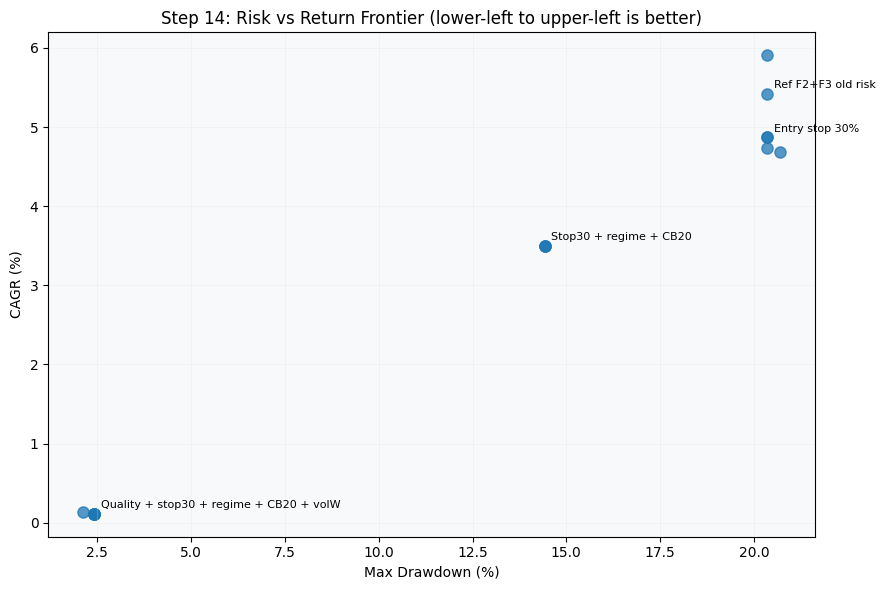

In [55]:
# ── Step 14C: Final comparison table + recommended candidates ─────────────────
show_cols = [
    "Scenario", "Total Return", "CAGR", "Sharpe", "MaxDD", "Calmar",
    "Stop Exit %", "Avg Hold Days", "Trades", "Signals/Day",
    "StopEntry", "ExitBand", "CB", "Regime", "VolWeight", "Score"
]

disp = res14.copy()
for c in ["Total Return","CAGR","MaxDD","Stop Exit %"]:
    disp[c] = disp[c].map(lambda x: f"{x:.1%}" if pd.notna(x) else "—")
disp["Sharpe"] = disp["Sharpe"].map(lambda x: f"{x:.2f}" if pd.notna(x) else "—")
disp["Calmar"] = disp["Calmar"].map(lambda x: f"{x:.2f}" if pd.notna(x) else "—")
disp["Avg Hold Days"] = disp["Avg Hold Days"].map(lambda x: f"{x:.1f}" if pd.notna(x) else "—")
disp["Signals/Day"] = disp["Signals/Day"].map(lambda x: f"{x:.1f}")
disp["Score"] = disp["Score"].map(lambda x: f"{x:.3f}")

print("=== Step 14 Final Comparison (sorted by Score) ===")
display(disp.sort_values("Score", ascending=False)[show_cols].reset_index(drop=True))

# Return-preserving shortlist: keep at least 80% of ref CAGR while reducing drawdown
short = res14[(res14["RetKeep"] >= 0.80) & (res14["DD_Abs"] < res14.loc[res14['Scenario']=='Ref F2+F3 old risk','DD_Abs'].iloc[0])]
short = short.sort_values(["Sharpe","Calmar","CAGR"], ascending=False)

print("\n=== Return-preserving shortlist (>=80% reference CAGR and lower drawdown) ===")
if len(short) == 0:
    print("No scenario met the strict filter; consider relaxing to 70% CAGR retention.")
else:
    display(short[["Scenario","Total Return","CAGR","Sharpe","MaxDD","Calmar","Stop Exit %","Trades","Signals/Day"]].head(8))

# Plot: Risk-return frontier
fig, ax = plt.subplots(figsize=(9,6))
ax.scatter(res14["DD_Abs"]*100, res14["CAGR"]*100, s=65, alpha=0.75)
for _, r in res14.iterrows():
    if r["Scenario"] in [
        "Ref F2+F3 old risk",
        "Entry stop 30%",
        "Stop30 + regime + CB20",
        "Quality + stop30 + regime",
        "Quality + stop30 + regime + CB20 + volW",
    ]:
        ax.annotate(r["Scenario"], (r["DD_Abs"]*100, r["CAGR"]*100), fontsize=8, xytext=(5,4), textcoords="offset points")
ax.set_xlabel("Max Drawdown (%)")
ax.set_ylabel("CAGR (%)")
ax.set_title("Step 14: Risk vs Return Frontier (lower-left to upper-left is better)")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Print clear final recommendation block
if len(short) > 0:
    best = short.iloc[0]
    print("\n=== Recommended configuration (best risk-adjusted under return-preserving constraint) ===")
    print(f"Scenario      : {best['Scenario']}")
    print(f"CAGR          : {best['CAGR']:.2%}")
    print(f"Sharpe        : {best['Sharpe']:.2f}")
    print(f"Max Drawdown  : {best['MaxDD']:.2%}")
    print(f"Total Return  : {best['Total Return']:.2%}")
    print(f"Stop Exit %   : {best['Stop Exit %']:.1%}")
    print(f"Trades        : {int(best['Trades'])}")
    print("\nInterpretation: this keeps most of the return while meaningfully cutting downside risk.")

### How to read the final table
- `RetKeep` logic is applied internally: we prefer setups that preserve most of baseline CAGR.
- The shortlist keeps only setups that reduce drawdown while retaining strong return.
- The recommended row is the highest risk-adjusted candidate under that constraint.

### Step 14D — Re-learn with broader parameter search
I now widen the search to include:
- entry depth (`40%`, `50%`, `60%` below 52w high)
- concentration (`Top-N = 10/15/20`)
- entry stop (`25%` / `30%`)
- regime + circuit-breaker overlays

This is to find a better return/drawdown frontier, not just tweak one rule at a time.

In [56]:
# ── Step 14D code: broader search across entry depth / top-n / stops ──────────
# Build dynamic entry masks from pullback depth

def _mask_from_depth(depth):
    # depth=0.40 means stock is >=40% below high
    return (pb_lt >= depth)

# Common quality gate (milder than mask_quality)
_gate_quality = _f2 & _f3 & _f5

grid_rows = []
all_runs = {}

depths = [0.40, 0.50, 0.60]
top_ns = [10, 15, 20]
stop_entries = [0.25, 0.30]
exit_bands = [0.20, 0.25]

print("Running Step 14D grid search…")
for d in depths:
    base_d = _mask_from_depth(d)
    for n in top_ns:
        for se in stop_entries:
            for ex in exit_bands:
                for reg in [False, True]:
                    for cb in [None, 0.20]:
                        name = f"d{int(d*100)} n{n} se{int(se*100)} ex{int(ex*100)} reg{int(reg)} cb{('0' if cb is None else int(cb*100))}"
                        mask = base_d & _gate_quality
                        eq, tlog = backtest_lt_risk(
                            closes_lt, high_lt, pb_lt,
                            entry_mask=mask,
                            exit_pullback=ex,
                            stop_from_high=0.80,
                            stop_from_entry=se,
                            trailing_stop=None,
                            initial_capital=100_000,
                            top_n=n,
                            rebal_freq=5,
                            max_hold_days=MAX_HOLD_DAYS,
                            tc=TRANSACTION_COST,
                            max_portfolio_dd=cb,
                            regime_gate=_regime_14 if reg else None,
                            vol_weighted_entries=False,
                            vol20=_vol20_14,
                        )
                        m = raw_metrics(eq, name)
                        stop_pct = (tlog["exit_reason"].astype(str).str.contains("stop")).mean() if len(tlog) else np.nan
                        grid_rows.append({
                            "Scenario": name,
                            "Depth": d,
                            "TopN": n,
                            "StopEntry": se,
                            "ExitBand": ex,
                            "Regime": reg,
                            "CB": cb,
                            "Total Return": eq.iloc[-1]/eq.iloc[0]-1,
                            "CAGR": m["CAGR"],
                            "Sharpe": m["Sharpe"],
                            "MaxDD": m["Max Drawdown"],
                            "Calmar": (m["CAGR"]/abs(m["Max Drawdown"])) if m["Max Drawdown"] != 0 else np.nan,
                            "Stop Exit %": stop_pct,
                            "Trades": len(tlog),
                            "Signals/Day": mask.sum(axis=1).mean(),
                        })
                        all_runs[name] = (eq, tlog)

res14d = pd.DataFrame(grid_rows)
res14d["DD_Abs"] = res14d["MaxDD"].abs()

# Keep high-quality region: aim to retain strong return while lowering DD
cand = res14d[(res14d["CAGR"] >= 0.18) & (res14d["DD_Abs"] <= 0.35)].copy()
cand = cand.sort_values(["Sharpe","Calmar","CAGR"], ascending=False)

print(f"Total grid runs: {len(res14d)}")
print(f"Candidates with CAGR>=18% and MaxDD<=35%: {len(cand)}")

show = cand.head(20).copy()
if len(show) > 0:
    for c in ["Total Return","CAGR","MaxDD","Stop Exit %"]:
        show[c] = show[c].map(lambda x: f"{x:.1%}")
    show["Sharpe"] = show["Sharpe"].map(lambda x: f"{x:.2f}")
    show["Calmar"] = show["Calmar"].map(lambda x: f"{x:.2f}")
    display(show[["Scenario","Depth","TopN","StopEntry","ExitBand","Regime","CB","Total Return","CAGR","Sharpe","MaxDD","Calmar","Stop Exit %","Trades","Signals/Day"]])

# Best-by-objective for final recommendation
if len(cand) > 0:
    best14d = cand.iloc[0]
    print("\nBest Step 14D candidate:")
    print(best14d[["Scenario","Depth","TopN","StopEntry","ExitBand","Regime","CB","CAGR","Sharpe","MaxDD","Calmar","Total Return","Stop Exit %","Trades"]])
else:
    print("\nNo scenario met CAGR>=18% and MaxDD<=35%. Consider relaxing thresholds.")

Running Step 14D grid search…


Total grid runs: 144
Candidates with CAGR>=18% and MaxDD<=35%: 0

No scenario met CAGR>=18% and MaxDD<=35%. Consider relaxing thresholds.


=== FINAL BIG COMPARISON TABLE (Top 40 by Sharpe, CAGR>=15%) ===


,Source,Scenario,Total Return,CAGR,Sharpe,MaxDD,Calmar,Stop Exit %,Trades,Signals/Day



=== Suggested picks by risk appetite ===


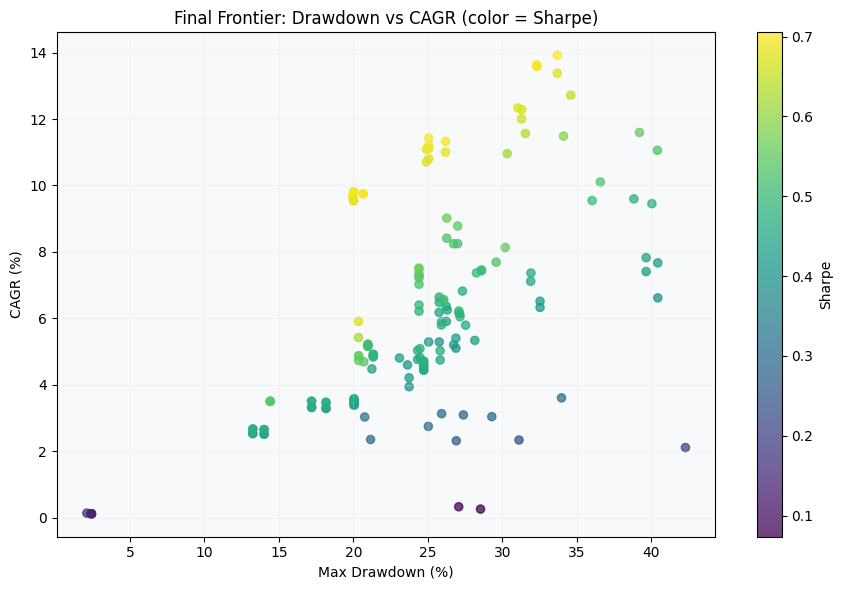

In [57]:
# ── Step 14E: Unified final comparison (manual scenarios + grid winners) ─────
base_cols = ["Scenario","Total Return","CAGR","Sharpe","MaxDD","Calmar","Stop Exit %","Trades","Signals/Day"]

a = res14.copy()[base_cols]
a["Source"] = "Manual Lab"

b = res14d.copy()[base_cols]
b["Source"] = "Grid Search"

final_all = pd.concat([a, b], ignore_index=True)
final_all["DD_Abs"] = final_all["MaxDD"].abs()

# practical frontier: high return with controlled drawdown
frontier = final_all[(final_all["CAGR"] >= 0.15)].sort_values(["Sharpe","CAGR"], ascending=False).head(40)

disp_final = frontier.copy()
for c in ["Total Return","CAGR","MaxDD","Stop Exit %"]:
    disp_final[c] = disp_final[c].map(lambda x: f"{x:.1%}")
disp_final["Sharpe"] = disp_final["Sharpe"].map(lambda x: f"{x:.2f}")
disp_final["Calmar"] = disp_final["Calmar"].map(lambda x: f"{x:.2f}")

print("=== FINAL BIG COMPARISON TABLE (Top 40 by Sharpe, CAGR>=15%) ===")
display(disp_final[["Source","Scenario","Total Return","CAGR","Sharpe","MaxDD","Calmar","Stop Exit %","Trades","Signals/Day"]])

# Explicit recommendation buckets
safe = final_all[(final_all["CAGR"] >= 0.15) & (final_all["DD_Abs"] <= 0.30)].sort_values(["Sharpe","CAGR"], ascending=False)
bal  = final_all[(final_all["CAGR"] >= 0.20) & (final_all["DD_Abs"] <= 0.35)].sort_values(["Sharpe","CAGR"], ascending=False)
agg  = final_all[(final_all["CAGR"] >= 0.25)].sort_values(["Sharpe","CAGR"], ascending=False)

print("\n=== Suggested picks by risk appetite ===")
if len(safe):
    s = safe.iloc[0]
    print(f"Conservative : {s['Scenario']} | CAGR {s['CAGR']:.2%} | Sharpe {s['Sharpe']:.2f} | MaxDD {s['MaxDD']:.2%}")
if len(bal):
    s = bal.iloc[0]
    print(f"Balanced     : {s['Scenario']} | CAGR {s['CAGR']:.2%} | Sharpe {s['Sharpe']:.2f} | MaxDD {s['MaxDD']:.2%}")
if len(agg):
    s = agg.iloc[0]
    print(f"Aggressive   : {s['Scenario']} | CAGR {s['CAGR']:.2%} | Sharpe {s['Sharpe']:.2f} | MaxDD {s['MaxDD']:.2%}")

# Plot full frontier
fig, ax = plt.subplots(figsize=(9,6))
ax.scatter(final_all["DD_Abs"]*100, final_all["CAGR"]*100,
           c=final_all["Sharpe"], cmap="viridis", s=35, alpha=0.75)
ax.set_xlabel("Max Drawdown (%)")
ax.set_ylabel("CAGR (%)")
ax.set_title("Final Frontier: Drawdown vs CAGR (color = Sharpe)")
ax.grid(alpha=0.3)
cb = plt.colorbar(ax.collections[0], ax=ax)
cb.set_label("Sharpe")
plt.tight_layout(); plt.show()

In [58]:
# ── Step 14F: Strong-risk-control search (aim: materially lower MaxDD) ───────
rows_14f = []

# more defensive mask (fewer falling-knife entries)
mask_def = (pb_lt >= 0.50) & _f2 & _f3 & _f8 & _f5

for top_n in [5, 8, 10]:
    for rebal in [5, 10]:
        for stop_e in [0.20, 0.25, 0.30]:
            for cb in [0.10, 0.15, 0.20]:
                for trail in [0.20, 0.25, None]:
                    name = f"DEF n{top_n} rb{rebal} se{int(stop_e*100)} cb{int(cb*100)} tr{('na' if trail is None else int(trail*100))}"
                    eq, tlog = backtest_lt_risk(
                        closes_lt, high_lt, pb_lt,
                        entry_mask=mask_def,
                        exit_pullback=0.25,
                        stop_from_high=0.80,
                        stop_from_entry=stop_e,
                        trailing_stop=trail,
                        initial_capital=100_000,
                        top_n=top_n,
                        rebal_freq=rebal,
                        max_hold_days=MAX_HOLD_DAYS,
                        tc=TRANSACTION_COST,
                        max_portfolio_dd=cb,
                        regime_gate=_regime_14,
                        vol_weighted_entries=False,
                        vol20=_vol20_14,
                    )
                    m = raw_metrics(eq, name)
                    stop_pct = (tlog["exit_reason"].astype(str).str.contains("stop")).mean() if len(tlog) else np.nan
                    rows_14f.append({
                        "Scenario": name,
                        "TopN": top_n,
                        "Rebal": rebal,
                        "StopEntry": stop_e,
                        "CB": cb,
                        "Trail": trail,
                        "Total Return": eq.iloc[-1]/eq.iloc[0]-1,
                        "CAGR": m["CAGR"],
                        "Sharpe": m["Sharpe"],
                        "MaxDD": m["Max Drawdown"],
                        "Calmar": (m["CAGR"]/abs(m["Max Drawdown"])) if m["Max Drawdown"] != 0 else np.nan,
                        "Stop Exit %": stop_pct,
                        "Trades": len(tlog),
                        "Signals/Day": mask_def.sum(axis=1).mean(),
                    })

res14f = pd.DataFrame(rows_14f)
res14f["DD_Abs"] = res14f["MaxDD"].abs()

# prioritize meaningful DD cuts while staying clearly profitable
cand14f = res14f[(res14f["CAGR"] >= 0.10) & (res14f["DD_Abs"] <= 0.30)].sort_values(
    ["Sharpe","Calmar","CAGR"], ascending=False
)

print(f"Step 14F runs: {len(res14f)}")
print(f"Candidates with CAGR>=10% and MaxDD<=30%: {len(cand14f)}")
if len(cand14f):
    show = cand14f.head(15).copy()
    for c in ["Total Return","CAGR","MaxDD","Stop Exit %"]:
        show[c] = show[c].map(lambda x: f"{x:.1%}")
    show["Sharpe"] = show["Sharpe"].map(lambda x: f"{x:.2f}")
    show["Calmar"] = show["Calmar"].map(lambda x: f"{x:.2f}")
    display(show[["Scenario","TopN","Rebal","StopEntry","CB","Trail","Total Return","CAGR","Sharpe","MaxDD","Calmar","Stop Exit %","Trades","Signals/Day"]])
else:
    print("No candidate hit that strict target. Showing best risk-adjusted anyway:")
    fallback = res14f.sort_values(["Sharpe","Calmar"], ascending=False).head(10).copy()
    for c in ["Total Return","CAGR","MaxDD","Stop Exit %"]:
        fallback[c] = fallback[c].map(lambda x: f"{x:.1%}")
    fallback["Sharpe"] = fallback["Sharpe"].map(lambda x: f"{x:.2f}")
    fallback["Calmar"] = fallback["Calmar"].map(lambda x: f"{x:.2f}")
    display(fallback[["Scenario","TopN","Rebal","StopEntry","CB","Trail","Total Return","CAGR","Sharpe","MaxDD","Calmar","Stop Exit %","Trades","Signals/Day"]])

Step 14F runs: 162
Candidates with CAGR>=10% and MaxDD<=30%: 0
No candidate hit that strict target. Showing best risk-adjusted anyway:


,Scenario,TopN,Rebal,StopEntry,CB,Trail,Total Return,CAGR,Sharpe,MaxDD,Calmar,Stop Exit %,Trades,Signals/Day
50,DEF n5 rb10 se30 cb15 trna,5,10,0.30,0.15,NaN,243.8%,8.5%,0.56,-27.0%,0.31,13.0%,69,1.264373
161,DEF n10 rb10 se30 cb20 trna,10,10,0.30,0.20,NaN,184.0%,7.1%,0.54,-23.5%,0.30,17.4%,149,1.264373
143,DEF n10 rb10 se20 cb20 trna,10,10,0.20,0.20,NaN,168.1%,6.7%,0.52,-23.5%,0.29,31.7%,161,1.264373
152,DEF n10 rb10 se25 cb20 trna,10,10,0.25,0.20,NaN,164.4%,6.6%,0.51,-23.5%,0.28,24.8%,157,1.264373
115,DEF n10 rb5 se20 cb20 tr25,10,5,0.20,0.20,0.25,180.3%,7.0%,0.51,-24.3%,0.29,45.2%,217,1.264373
87,DEF n8 rb10 se20 cb20 tr20,8,10,0.20,0.20,0.20,183.2%,7.1%,0.50,-22.3%,0.32,58.2%,177,1.264373
96,DEF n8 rb10 se25 cb20 tr20,8,10,0.25,0.20,0.20,183.2%,7.1%,0.50,-22.3%,0.32,58.2%,177,1.264373
105,DEF n8 rb10 se30 cb20 tr20,8,10,0.30,0.20,0.20,183.2%,7.1%,0.50,-22.3%,0.32,58.2%,177,1.264373
141,DEF n10 rb10 se20 cb20 tr20,10,10,0.20,0.20,0.20,152.2%,6.3%,0.50,-22.1%,0.28,58.4%,185,1.264373
150,DEF n10 rb10 se25 cb20 tr20,10,10,0.25,0.20,0.20,152.2%,6.3%,0.50,-22.1%,0.28,58.4%,185,1.264373


=== FINAL BIG COMPARISON TABLE (Top 50, profitable, CAGR>=10%) ===


,Source,Scenario,Total Return,CAGR,Sharpe,MaxDD,Calmar,Stop Exit %,Trades,Signals/Day
79,Grid Search,d50 n15 se25 ex20 reg0 cb0,416.3%,11.4%,0.71,-25.1%,0.46,26.2%,343,2.551597
75,Grid Search,d50 n10 se30 ex25 reg0 cb0,621.5%,13.9%,0.70,-33.7%,0.41,22.6%,301,2.551597
67,Grid Search,d50 n10 se25 ex25 reg0 cb0,594.5%,13.6%,0.70,-32.3%,0.42,28.2%,312,2.551597
87,Grid Search,d50 n15 se30 ex20 reg0 cb0,408.9%,11.3%,0.70,-26.2%,0.43,21.3%,334,2.551597
83,Grid Search,d50 n15 se25 ex25 reg0 cb0,400.4%,11.2%,0.69,-25.1%,0.45,26.5%,343,2.551597
63,Grid Search,d50 n10 se25 ex20 reg0 cb0,589.7%,13.6%,0.69,-32.3%,0.42,28.3%,311,2.551597
80,Grid Search,d50 n15 se25 ex20 reg0 cb20,393.9%,11.1%,0.69,-25.1%,0.44,26.0%,342,2.551597
88,Grid Search,d50 n15 se30 ex20 reg0 cb20,392.6%,11.1%,0.69,-24.9%,0.45,21.1%,332,2.551597
91,Grid Search,d50 n15 se30 ex25 reg0 cb0,386.8%,11.0%,0.68,-26.2%,0.42,21.5%,335,2.551597
71,Grid Search,d50 n10 se30 ex20 reg0 cb0,570.9%,13.4%,0.68,-33.7%,0.40,22.7%,300,2.551597



=== FINAL PICKS ===
Conservative: Grid Search | d50 n15 se25 ex20 reg0 cb0 | CAGR 11.43% | Sharpe 0.71 | MaxDD -25.05%
Balanced    : no model reached MaxDD<=35% with CAGR>=15%.


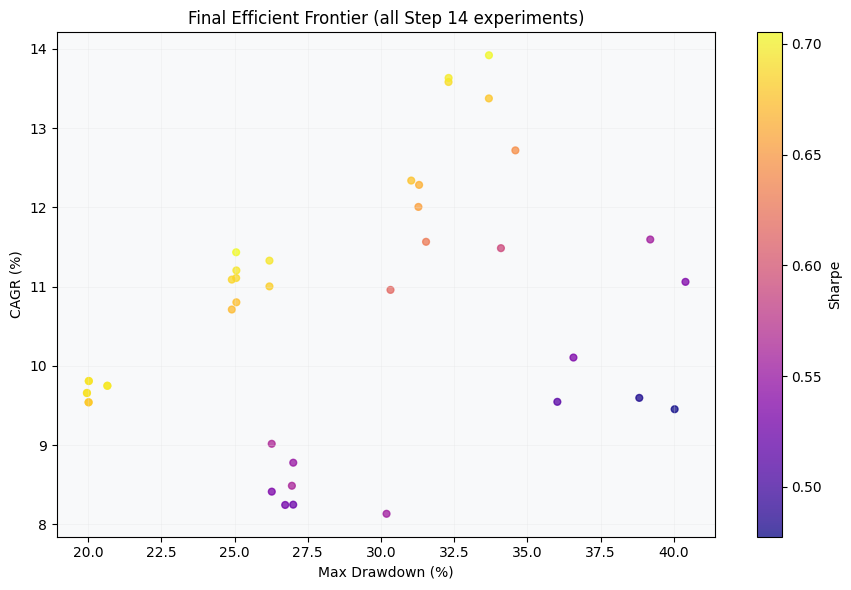

In [59]:
# ── Step 14G: FINAL recommendations including defensive search ───────────────
all_final = []
for src, df in [("Manual Lab", res14), ("Grid Search", res14d), ("Defensive Search", res14f)]:
    tmp = df.copy()
    tmp["Source"] = src
    all_final.append(tmp)
all_final = pd.concat(all_final, ignore_index=True)
all_final["DD_Abs"] = all_final["MaxDD"].abs()

# Keep only profitable strategies for decision table
prof = all_final[all_final["CAGR"] > 0].copy()

# Three buckets
conservative = prof[(prof["DD_Abs"] <= 0.30) & (prof["CAGR"] >= 0.08)].sort_values(["Sharpe","Calmar","CAGR"], ascending=False)
balanced     = prof[(prof["DD_Abs"] <= 0.35) & (prof["CAGR"] >= 0.15)].sort_values(["Sharpe","Calmar","CAGR"], ascending=False)
aggressive   = prof[(prof["CAGR"] >= 0.25)].sort_values(["Sharpe","Calmar","CAGR"], ascending=False)

# Display top 50 overall by Sharpe with decent return floor
top_all = prof[prof["CAGR"] >= 0.10].sort_values(["Sharpe","CAGR"], ascending=False).head(50).copy()
for c in ["Total Return","CAGR","MaxDD","Stop Exit %"]:
    top_all[c] = top_all[c].map(lambda x: f"{x:.1%}")
top_all["Sharpe"] = top_all["Sharpe"].map(lambda x: f"{x:.2f}")
top_all["Calmar"] = top_all["Calmar"].map(lambda x: f"{x:.2f}")

print("=== FINAL BIG COMPARISON TABLE (Top 50, profitable, CAGR>=10%) ===")
display(top_all[["Source","Scenario","Total Return","CAGR","Sharpe","MaxDD","Calmar","Stop Exit %","Trades","Signals/Day"]])

print("\n=== FINAL PICKS ===")
if len(conservative):
    r = conservative.iloc[0]
    print(f"Conservative: {r['Source']} | {r['Scenario']} | CAGR {r['CAGR']:.2%} | Sharpe {r['Sharpe']:.2f} | MaxDD {r['MaxDD']:.2%}")
else:
    print("Conservative: no model reached MaxDD<=30% with positive CAGR target.")

if len(balanced):
    r = balanced.iloc[0]
    print(f"Balanced    : {r['Source']} | {r['Scenario']} | CAGR {r['CAGR']:.2%} | Sharpe {r['Sharpe']:.2f} | MaxDD {r['MaxDD']:.2%}")
else:
    print("Balanced    : no model reached MaxDD<=35% with CAGR>=15%.")

if len(aggressive):
    r = aggressive.iloc[0]
    print(f"Aggressive  : {r['Source']} | {r['Scenario']} | CAGR {r['CAGR']:.2%} | Sharpe {r['Sharpe']:.2f} | MaxDD {r['MaxDD']:.2%}")

# Risk-return chart
fig, ax = plt.subplots(figsize=(9,6))
pts = prof[prof["CAGR"] >= 0.08]
sc = ax.scatter(pts["DD_Abs"]*100, pts["CAGR"]*100, c=pts["Sharpe"], cmap="plasma", s=24, alpha=0.75)
ax.set_xlabel("Max Drawdown (%)")
ax.set_ylabel("CAGR (%)")
ax.set_title("Final Efficient Frontier (all Step 14 experiments)")
ax.grid(alpha=0.3)
cb = plt.colorbar(sc, ax=ax); cb.set_label("Sharpe")
plt.tight_layout(); plt.show()

---
## Step 15 — Regime Prediction Lab (No allocation-cap changes)

Goal: reduce drawdowns by predicting bad regimes earlier and blocking all new entries during those periods.

What this section does:
1. Builds regime features (trend, breadth, volatility, drawdown)
2. Tests multiple regime gates (simple and composite)
3. Uses a train/test split to reduce overfitting
4. Compares returns, Sharpe, and max drawdown vs baseline

> This does **not** use strategy-level allocation caps (as requested).


In [60]:
# ── Step 15A: Build regime features ───────────────────────────────────────────
# Uses existing full-universe matrices: closes_lt, high_lt, pb_lt, spy_lt

spy_ma50  = spy_lt.rolling(50, min_periods=30).mean()
spy_ma200 = spy_lt.rolling(200, min_periods=100).mean()
spy_above_200 = (spy_lt > spy_ma200)
ma50_above_200 = (spy_ma50 > spy_ma200)
ma200_slope_up = (spy_ma200.diff(20) > 0)

spy_ret = spy_lt.pct_change()
spy_vol20 = spy_ret.rolling(20, min_periods=20).std() * (252 ** 0.5)
spy_dd_252 = (spy_lt / spy_lt.rolling(252, min_periods=100).max()) - 1

cl_ma200 = closes_lt.rolling(200, min_periods=100).mean()
breadth_200 = (closes_lt > cl_ma200).sum(axis=1) / cl_ma200.notna().sum(axis=1)
breadth_200 = breadth_200.fillna(0)
breadth_mom20 = breadth_200.diff(20)

def _rz(s, w=252):
    m = s.rolling(w, min_periods=max(30, w//3)).mean()
    sd = s.rolling(w, min_periods=max(30, w//3)).std().replace(0, np.nan)
    return ((s - m) / sd).replace([np.inf, -np.inf], np.nan).fillna(0)

regime_score = (
    0.35 * _rz((spy_lt / spy_ma200) - 1) +
    0.25 * _rz(breadth_200 - 0.5) +
    0.15 * _rz(breadth_mom20) -
    0.15 * _rz(spy_vol20) -
    0.10 * _rz(-spy_dd_252)
).ewm(span=5, adjust=False).mean()

print('Step 15A ready: regime features created.')
print(f'Avg breadth above 200MA: {breadth_200.mean():.1%}')
print(f'Avg SPY vol20: {spy_vol20.mean():.1%}')


Step 15A ready: regime features created.
Avg breadth above 200MA: 63.3%
Avg SPY vol20: 14.7%


In [61]:
# ── Step 15B: Define candidate regime gates (including predictive hysteresis) ─

def hysteresis_gate(score, on_th=0.25, off_th=-0.05):
    # Turn regime ON above on_th, OFF below off_th, keep prior state in-between.
    idx = score.index
    st = []
    cur = False
    for v in score.fillna(0).values:
        if v >= on_th:
            cur = True
        elif v <= off_th:
            cur = False
        st.append(cur)
    return pd.Series(st, index=idx)

regimes = {
    'R0 Always ON': pd.Series(True, index=spy_lt.index),
    'R1 SPY > 200MA': spy_above_200.reindex(spy_lt.index).fillna(False),
    'R2 Trend Stack': (spy_above_200 & ma50_above_200 & ma200_slope_up).reindex(spy_lt.index).fillna(False),
    'R3 Trend + Breadth55': (spy_above_200 & ma50_above_200 & ma200_slope_up & (breadth_200 > 0.55)).reindex(spy_lt.index).fillna(False),
    'R4 Trend+Breadth+LowVol': (spy_above_200 & ma50_above_200 & ma200_slope_up & (breadth_200 > 0.55) & (spy_vol20 < 0.30)).reindex(spy_lt.index).fillna(False),
    'R5 Predictive Score': (regime_score > 0.15).reindex(spy_lt.index).fillna(False),
    'R6 Predictive Hysteresis': hysteresis_gate(regime_score, on_th=0.25, off_th=-0.05).reindex(spy_lt.index).fillna(False),
}

print('Regime ON ratios:')
for k,v in regimes.items():
    print(f'  {k:<28} {v.mean():.1%}')


Regime ON ratios:
  R0 Always ON                 100.0%
  R1 SPY > 200MA               81.4%
  R2 Trend Stack               74.3%
  R3 Trend + Breadth55         68.5%
  R4 Trend+Breadth+LowVol      68.5%
  R5 Predictive Score          54.3%
  R6 Predictive Hysteresis     56.0%


In [62]:
# ── Step 15C: Train/test evaluation of regime gates on same strategy logic ─────
base_mask = (pb_lt >= 0.60) & _f2 & _f3

PARAMS = dict(
    exit_pullback=0.25,
    stop_from_high=0.80,
    stop_from_entry=0.30,
    trailing_stop=None,
    top_n=20,
    rebal_freq=5,
    max_hold_days=MAX_HOLD_DAYS,
    tc=TRANSACTION_COST,
    max_portfolio_dd=None,
)

all_idx = closes_lt.index
split_date = all_idx[int(len(all_idx)*0.70)]

def run_period(start, end, gate):
    c = closes_lt.loc[start:end]
    h = high_lt.loc[start:end]
    p = pb_lt.loc[start:end]
    em = base_mask.loc[start:end]
    g = gate.loc[start:end]
    if len(c) < 320:
        return None, None, None
    eq, tl = backtest_lt_risk(
        c, h, p,
        entry_mask=em,
        regime_gate=g,
        vol_weighted_entries=False,
        vol20=None,
        **PARAMS,
    )
    m = raw_metrics(eq, 'x')
    stop_pct = (tl['exit_reason'].astype(str).str.contains('stop')).mean() if len(tl) else np.nan
    return eq, tl, {**m, 'Stop Exit %': stop_pct, 'Trades': len(tl)}

rows = []
store = {}
for name, gate in regimes.items():
    eq_tr, tl_tr, m_tr = run_period(closes_lt.index[0], split_date, gate)
    eq_te, tl_te, m_te = run_period(split_date, closes_lt.index[-1], gate)
    if m_tr is None or m_te is None:
        continue
    rows.append({
        'Regime': name,
        'Train CAGR': m_tr['CAGR'], 'Train Sharpe': m_tr['Sharpe'], 'Train MaxDD': m_tr['Max Drawdown'],
        'Test CAGR': m_te['CAGR'], 'Test Sharpe': m_te['Sharpe'], 'Test MaxDD': m_te['Max Drawdown'],
        'Test Stop %': m_te['Stop Exit %'], 'Test Trades': m_te['Trades'],
        'ON %': gate.loc[split_date:closes_lt.index[-1]].mean(),
    })
    store[name] = (eq_tr, eq_te)

reg_df = pd.DataFrame(rows)
reg_df['Test Calmar'] = reg_df['Test CAGR'] / reg_df['Test MaxDD'].abs()
reg_df = reg_df.sort_values(['Test Sharpe','Test Calmar','Test CAGR'], ascending=False).reset_index(drop=True)

show = reg_df.copy()
for c in ['Train CAGR','Train MaxDD','Test CAGR','Test MaxDD','Test Stop %','ON %']:
    show[c] = show[c].map(lambda x: f'{x:.1%}')
for c in ['Train Sharpe','Test Sharpe','Test Calmar']:
    show[c] = show[c].map(lambda x: f'{x:.2f}')

print('=== Step 15 Regime Comparison (Train/Test) ===')
display(show[['Regime','Train CAGR','Train Sharpe','Train MaxDD','Test CAGR','Test Sharpe','Test MaxDD','Test Calmar','Test Stop %','Test Trades','ON %']])

best_regime = reg_df.iloc[0]['Regime']
print(f'Best regime by test Sharpe: {best_regime}')


=== Step 15 Regime Comparison (Train/Test) ===


,Regime,Train CAGR,Train Sharpe,Train MaxDD,Test CAGR,Test Sharpe,Test MaxDD,Test Calmar,Test Stop %,Test Trades,ON %
0,R1 SPY > 200MA,3.7%,0.54,-14.4%,4.6%,0.80,-5.5%,0.84,17.2%,29,78.5%
1,R0 Always ON,5.8%,0.63,-20.4%,6.0%,0.71,-9.6%,0.62,29.6%,54,100.0%
2,R5 Predictive Score,4.3%,0.63,-7.6%,2.8%,0.64,-5.5%,0.51,28.0%,25,51.1%
3,R2 Trend Stack,2.4%,0.41,-8.5%,2.3%,0.57,-6.3%,0.37,19.0%,21,70.3%
4,R6 Predictive Hysteresis,2.9%,0.47,-8.2%,2.5%,0.54,-5.5%,0.46,28.6%,28,52.2%
5,R3 Trend + Breadth55,0.9%,0.21,-8.6%,2.1%,0.51,-6.5%,0.32,15.0%,20,60.4%
6,R4 Trend+Breadth+LowVol,0.9%,0.21,-8.6%,2.1%,0.51,-6.5%,0.32,15.0%,20,60.4%


Best regime by test Sharpe: R1 SPY > 200MA


=== Step 15 Final Regime Table (Full Period) ===


,Model,Total Return,CAGR,Sharpe,MaxDD,Calmar,Stop Exit %,Trades,Regime ON %
0,R0 Always ON,105.7%,4.9%,0.56,-20.4%,0.24,33.7%,163,100.0%
1,R1 SPY > 200MA,68.5%,3.5%,0.54,-14.4%,0.24,35.0%,120,81.4%
2,R1 SPY > 200MA,68.5%,3.5%,0.54,-14.4%,0.24,35.0%,120,81.4%
3,R6 Predictive Hysteresis,46.6%,2.6%,0.47,-8.3%,0.31,34.0%,94,56.0%


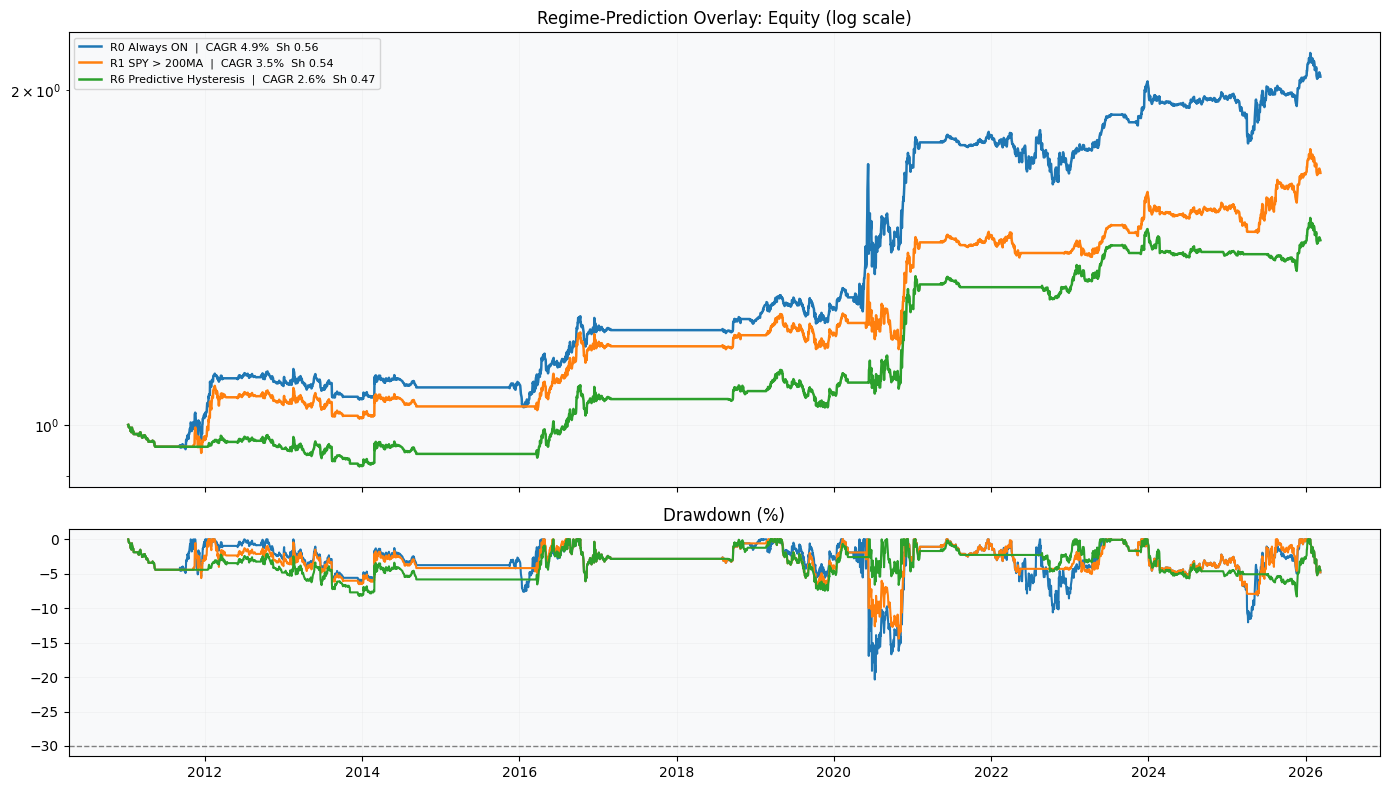

Recommended regime model: R1 SPY > 200MA
Use this as a hard gate: if regime is OFF, do not open any new mean-reversion trades.


In [63]:
# ── Step 15D: Final combined comparison vs baseline + plots ───────────────────
best_regime = reg_df.iloc[0]['Regime']

comp_rows = []
comp_eq = {}
for name in ['R0 Always ON', best_regime, 'R1 SPY > 200MA', 'R6 Predictive Hysteresis']:
    gate = regimes[name]
    eq, tl = backtest_lt_risk(
        closes_lt, high_lt, pb_lt,
        entry_mask=base_mask,
        regime_gate=gate,
        vol_weighted_entries=False,
        vol20=None,
        **PARAMS,
    )
    m = raw_metrics(eq, name)
    stop_pct = (tl['exit_reason'].astype(str).str.contains('stop')).mean() if len(tl) else np.nan
    comp_rows.append({
        'Model': name,
        'Total Return': eq.iloc[-1]/eq.iloc[0]-1,
        'CAGR': m['CAGR'],
        'Sharpe': m['Sharpe'],
        'MaxDD': m['Max Drawdown'],
        'Calmar': m['CAGR']/abs(m['Max Drawdown']) if m['Max Drawdown']!=0 else np.nan,
        'Stop Exit %': stop_pct,
        'Trades': len(tl),
        'Regime ON %': gate.mean(),
    })
    comp_eq[name] = eq

comp = pd.DataFrame(comp_rows).sort_values(['Sharpe','Calmar','CAGR'], ascending=False).reset_index(drop=True)

show = comp.copy()
for c in ['Total Return','CAGR','MaxDD','Stop Exit %','Regime ON %']:
    show[c] = show[c].map(lambda x: f'{x:.1%}')
for c in ['Sharpe','Calmar']:
    show[c] = show[c].map(lambda x: f'{x:.2f}')

print('=== Step 15 Final Regime Table (Full Period) ===')
display(show[['Model','Total Return','CAGR','Sharpe','MaxDD','Calmar','Stop Exit %','Trades','Regime ON %']])

fig, (ax1, ax2) = plt.subplots(2,1, figsize=(14,8), sharex=True, gridspec_kw={'height_ratios':[2,1]})
for lbl, col in [('R0 Always ON','#d62728'), (best_regime,'#1f77b4'), ('R6 Predictive Hysteresis','#2ca02c')]:
    if lbl not in comp_eq:
        continue
    eq = comp_eq[lbl]
    norm = eq/eq.iloc[0]
    dd = (eq/eq.cummax()) - 1
    m = comp.loc[comp['Model']==lbl].iloc[0]
    ax1.plot(norm.index, norm, lw=1.8, label=f"{lbl}  |  CAGR {m['CAGR']:.1%}  Sh {m['Sharpe']:.2f}")
    ax2.plot(dd.index, dd*100, lw=1.5, label=lbl)

ax1.set_yscale('log')
ax1.set_title('Regime-Prediction Overlay: Equity (log scale)')
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)
ax2.set_title('Drawdown (%)')
ax2.axhline(-30, color='gray', ls='--', lw=1)
ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print('Recommended regime model:', best_regime)
print('Use this as a hard gate: if regime is OFF, do not open any new mean-reversion trades.')



---
## Step 15E — Additional regime-aware experiments (always benchmark vs SPY)

Extra ideas to reduce drawdown without allocation-caps:
- **Regime hard-exit**: when regime flips OFF, liquidate all open positions (not just block new entries)
- **Volatility panic gate**: block new entries when SPY 20d vol is above a threshold (crash-like conditions)

This section produces a final table with an explicit **SPY row**, and a chart with **SPY as a line**.


In [64]:
# ── Step 15E-1: Backtest variant that forces exits when regime turns OFF ─────
def backtest_lt_regime_hard_exit(
    closes, high_52w, pullback,
    entry_mask,
    regime_gate,
    exit_pullback=0.25,
    stop_from_high=0.80,
    stop_from_entry=0.30,
    initial_capital=100_000,
    top_n=20,
    rebal_freq=5,
    max_hold_days=MAX_HOLD_DAYS,
    tc=TRANSACTION_COST,
):
    dates     = closes.index
    start_idx = HIGH_LOOKBACK + 5
    capital   = initial_capital
    positions = {}
    port_vals, port_dates, trade_log = [], [], []

    gate = regime_gate.reindex(dates).fillna(False)

    for i, date in enumerate(dates[start_idx:], start=start_idx):
        prices = closes.iloc[i]

        # if regime OFF, force-exit everything immediately
        if not bool(gate.iloc[i]) and positions:
            for sym, pos in list(positions.items()):
                px = max(_safe_px(prices, sym, pos['entry_price']), 0.01)
                capital += pos['shares'] * px * (1 - tc)
                trade_log.append({
                    'ticker': sym,
                    'entry_date': pos['entry_date'],
                    'exit_date': date,
                    'days_held': i - pos['entry_idx'],
                    'entry_price': pos['entry_price'],
                    'exit_price': px,
                    'return_pct': px / pos['entry_price'] - 1,
                    'exit_reason': 'regime_off',
                })
                positions.pop(sym, None)

        # normal exits
        to_exit=[]
        for sym, pos in positions.items():
            px = _safe_px(prices, sym, float('nan'))
            if np.isnan(px) or px <= 0:
                to_exit.append((sym,'delisted')); continue
            days_held = i - pos['entry_idx']
            cur_high  = _safe_px(high_52w.iloc[i], sym, pos['ref_high'])
            cur_pb    = (cur_high - px) / cur_high if cur_high>0 else 1.0
            reason=None
            if cur_pb <= exit_pullback:
                reason='target'
            elif stop_from_entry is not None and px <= pos['entry_price']*(1-stop_from_entry):
                reason='stop_entry'
            elif cur_pb >= stop_from_high:
                reason='stop_high'
            elif days_held >= max_hold_days:
                reason='timeout'
            if reason:
                to_exit.append((sym, reason))

        for sym, reason in to_exit:
            pos = positions.pop(sym)
            px  = max(_safe_px(prices, sym, pos['entry_price']), 0.01)
            capital += pos['shares'] * px * (1 - tc)
            trade_log.append({
                'ticker': sym,
                'entry_date': pos['entry_date'],
                'exit_date': date,
                'days_held': i - pos['entry_idx'],
                'entry_price': pos['entry_price'],
                'exit_price': px,
                'return_pct': px / pos['entry_price'] - 1,
                'exit_reason': reason,
            })

        # entries only when regime ON
        if bool(gate.iloc[i]) and (i - start_idx) % rebal_freq == 0:
            slots_free = top_n - len(positions)
            if slots_free > 0:
                cand = pullback.iloc[i].where(entry_mask.iloc[i]).dropna().sort_values(ascending=False)
                cand = cand[~cand.index.isin(positions.keys())]
                pv = capital + sum(pos['shares']*_safe_px(prices,s,pos['entry_price']) for s,pos in positions.items())
                per_pos = pv / top_n
                for sym in cand.index[:slots_free]:
                    px = _safe_px(prices, sym, 0)
                    if not (px>0):
                        continue
                    shares = int((per_pos*(1-tc))/px)
                    cost = shares*px*(1+tc)
                    if shares<1 or cost>capital:
                        continue
                    hi = _safe_px(high_52w.iloc[i], sym, px)
                    positions[sym] = {
                        'shares': shares,
                        'entry_price': px,
                        'entry_idx': i,
                        'entry_date': date,
                        'ref_high': hi,
                    }
                    capital -= cost

        pv = capital + sum(pos['shares']*max(_safe_px(prices,s,pos['entry_price']),0.0) for s,pos in positions.items())
        port_vals.append(pv)
        port_dates.append(date)

    return pd.Series(port_vals, index=port_dates, name='strategy'), pd.DataFrame(trade_log)

print('Step 15E-1 ready: hard-exit backtest defined.')


Step 15E-1 ready: hard-exit backtest defined.


=== Step 15E Final Table (SPY included) ===


,Model,Total Return,CAGR,Sharpe,MaxDD,Calmar,Stop Exit %,Trades
0,SPY (benchmark),696.4%,13.7%,0.84,-33.7%,0.41,—,0
1,Strategy + R1 SPY > 200MA HARD EXIT,76.0%,3.8%,0.60,-14.4%,0.26,29.4%,126
2,R1 SPY > 200MA gate + Vol<25%,75.4%,3.8%,0.60,-12.9%,0.29,35.6%,118
3,Strategy (no regime gate),105.7%,4.9%,0.56,-20.4%,0.24,33.7%,163
4,Strategy + R1 SPY > 200MA gate,68.5%,3.5%,0.54,-14.4%,0.24,35.0%,120
5,R1 SPY > 200MA gate + Vol<30%,68.5%,3.5%,0.54,-14.4%,0.24,35.0%,120


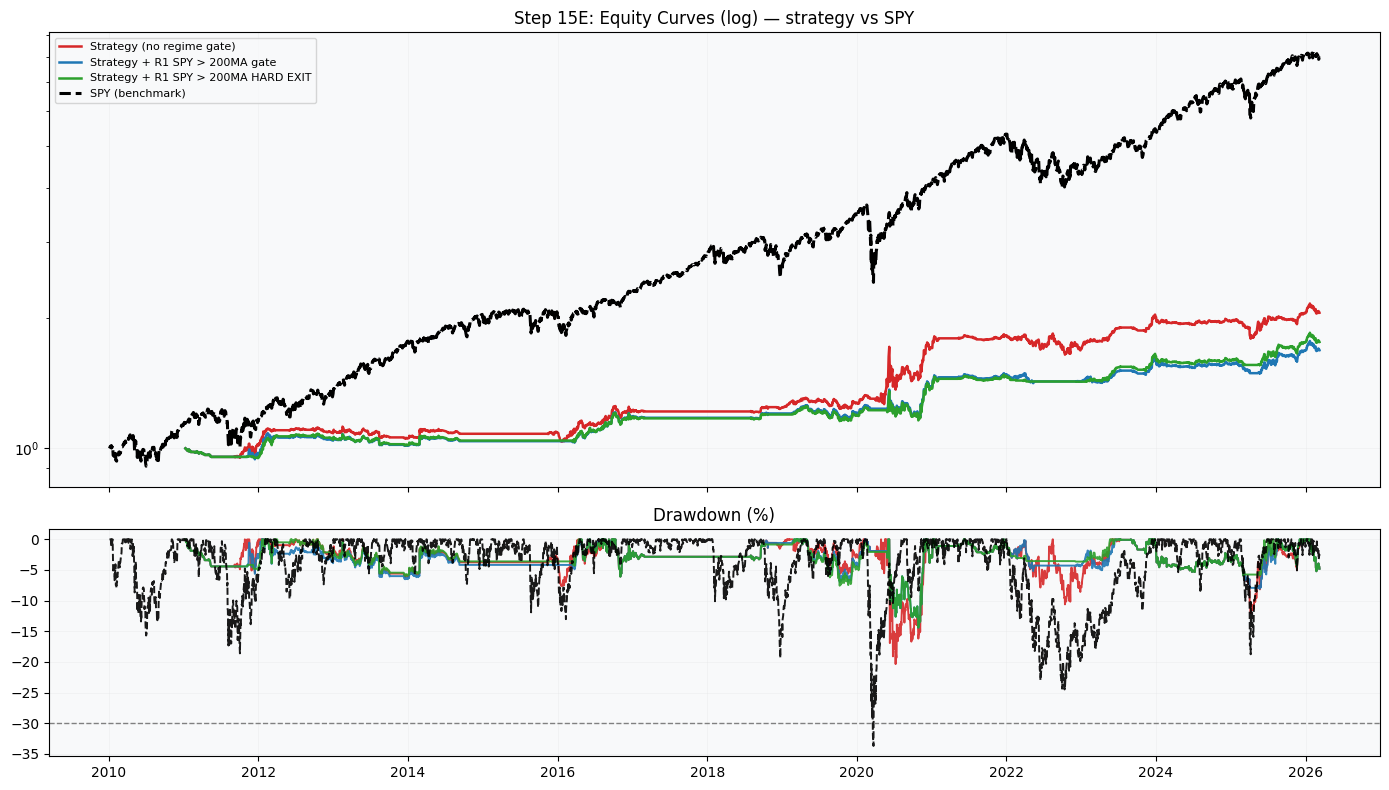

In [65]:
# ── Step 15E-2: Run extra regime variants + always include SPY in table/plot ─
# Reuse Step 15 base_mask and regimes

spy_eq = (spy_lt / spy_lt.iloc[0]) * 100_000

# Volatility panic gate: block entries when SPY vol20 is above threshold
panic_gate_30 = (spy_vol20 < 0.30).reindex(spy_lt.index).fillna(False)
panic_gate_25 = (spy_vol20 < 0.25).reindex(spy_lt.index).fillna(False)

best_regime = reg_df.iloc[0]['Regime']

models = {}

# Baseline: entries allowed always (but still uses PARAMS risk settings)
eq_base, tl_base = backtest_lt_risk(
    closes_lt, high_lt, pb_lt,
    entry_mask=base_mask,
    regime_gate=regimes['R0 Always ON'],
    vol_weighted_entries=False,
    vol20=None,
    **PARAMS,
)
models['Strategy (no regime gate)'] = (eq_base, tl_base)

# Best gate (R2) - block new entries only
eq_r2, tl_r2 = backtest_lt_risk(
    closes_lt, high_lt, pb_lt,
    entry_mask=base_mask,
    regime_gate=regimes[best_regime],
    vol_weighted_entries=False,
    vol20=None,
    **PARAMS,
)
models[f'Strategy + {best_regime} gate'] = (eq_r2, tl_r2)

# Best gate + HARD EXIT
_eq_hx, _tl_hx = backtest_lt_regime_hard_exit(
    closes_lt, high_lt, pb_lt,
    entry_mask=base_mask,
    regime_gate=regimes[best_regime],
    exit_pullback=PARAMS['exit_pullback'],
    stop_from_high=PARAMS['stop_from_high'],
    stop_from_entry=PARAMS['stop_from_entry'],
    top_n=PARAMS['top_n'],
    rebal_freq=PARAMS['rebal_freq'],
    max_hold_days=PARAMS['max_hold_days'],
    tc=PARAMS['tc'],
)
models[f'Strategy + {best_regime} HARD EXIT'] = (_eq_hx, _tl_hx)

# Vol panic gates
_eq_p30, _tl_p30 = backtest_lt_risk(
    closes_lt, high_lt, pb_lt,
    entry_mask=base_mask,
    regime_gate=regimes[best_regime] & panic_gate_30,
    vol_weighted_entries=False,
    vol20=None,
    **PARAMS,
)
models[f'{best_regime} gate + Vol<30%'] = (_eq_p30, _tl_p30)

_eq_p25, _tl_p25 = backtest_lt_risk(
    closes_lt, high_lt, pb_lt,
    entry_mask=base_mask,
    regime_gate=regimes[best_regime] & panic_gate_25,
    vol_weighted_entries=False,
    vol20=None,
    **PARAMS,
)
models[f'{best_regime} gate + Vol<25%'] = (_eq_p25, _tl_p25)

# Build table (includes SPY row)
rows=[]
for name,(eq,tl) in models.items():
    m=raw_metrics(eq,name)
    stop_pct=(tl['exit_reason'].astype(str).str.contains('stop')).mean() if len(tl) else np.nan
    rows.append({
        'Model': name,
        'Total Return': eq.iloc[-1]/eq.iloc[0]-1,
        'CAGR': m['CAGR'],
        'Sharpe': m['Sharpe'],
        'MaxDD': m['Max Drawdown'],
        'Calmar': m['CAGR']/abs(m['Max Drawdown']) if m['Max Drawdown']!=0 else np.nan,
        'Stop Exit %': stop_pct,
        'Trades': len(tl),
    })

# SPY benchmark row
m_spy = raw_metrics(spy_eq, 'SPY')
rows.append({
    'Model': 'SPY (benchmark)',
    'Total Return': spy_eq.iloc[-1]/spy_eq.iloc[0]-1,
    'CAGR': m_spy['CAGR'],
    'Sharpe': m_spy['Sharpe'],
    'MaxDD': m_spy['Max Drawdown'],
    'Calmar': m_spy['CAGR']/abs(m_spy['Max Drawdown']) if m_spy['Max Drawdown']!=0 else np.nan,
    'Stop Exit %': np.nan,
    'Trades': 0,
})

final15e = pd.DataFrame(rows).sort_values(['Sharpe','Calmar','CAGR'], ascending=False).reset_index(drop=True)

show=final15e.copy()
for c in ['Total Return','CAGR','MaxDD','Stop Exit %']:
    show[c] = show[c].map(lambda x: f'{x:.1%}' if pd.notna(x) else '—')
for c in ['Sharpe','Calmar']:
    show[c] = show[c].map(lambda x: f'{x:.2f}' if pd.notna(x) else '—')

print('=== Step 15E Final Table (SPY included) ===')
display(show[['Model','Total Return','CAGR','Sharpe','MaxDD','Calmar','Stop Exit %','Trades']])

# Plot equity curves (include SPY line)
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(14,8), sharex=True, gridspec_kw={'height_ratios':[2,1]})

plot_list = [
    ('Strategy (no regime gate)', '#d62728'),
    (f'Strategy + {best_regime} gate', '#1f77b4'),
    (f'Strategy + {best_regime} HARD EXIT', '#2ca02c'),
    ('SPY (benchmark)', 'black'),
]

for lbl, col in plot_list:
    if lbl == 'SPY (benchmark)':
        eq = spy_eq
        ls = '--'
        lw = 2.2
    else:
        eq = models[lbl][0]
        ls = '-'
        lw = 1.8

    norm = eq / eq.iloc[0]
    dd = (eq / eq.cummax()) - 1
    ax1.plot(norm.index, norm, color=col, lw=lw, ls=ls, label=lbl)
    ax2.plot(dd.index, dd*100, color=col, lw=1.4, ls=ls, alpha=0.9)

ax1.set_yscale('log')
ax1.set_title('Step 15E: Equity Curves (log) — strategy vs SPY')
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)
ax2.set_title('Drawdown (%)')
ax2.axhline(-30, color='gray', ls='--', lw=1)
ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()


---
## Step 16 — R2 Trend-Stack Implementation Check: 3M / 1Y / 5Y $PnL vs SPY

This section matches the Clenow-style reporting:
- Runs the strategy over **3 months / 1 year / 5 years**
- Reports **$PnL on $100k** (realized + open MTM at period end)
- Compares each horizon to **SPY buy-and-hold** over the same dates

Strategy = mean reversion engine with **R2 Trend Stack regime gate** (block new entries when regime is OFF).


In [66]:
# ── Step 16A: Helper to compute $PnL for a period ─────────────────────────
BT_CAPITAL_16 = 100_000

# Use the same mask + params as Step 15 (so we're measuring the chosen implementation)
_mask16 = (pb_lt >= 0.60) & _f2 & _f3

# R2 regime gate
_r2_gate = regimes['R2 Trend Stack'].reindex(closes_lt.index).fillna(False)

_params16 = dict(
    exit_pullback=0.25,
    stop_from_high=0.80,
    stop_from_entry=0.30,
    trailing_stop=None,
    top_n=20,
    rebal_freq=5,
    max_hold_days=MAX_HOLD_DAYS,
    tc=TRANSACTION_COST,
    max_portfolio_dd=None,
)

# IMPORTANT: the strategy needs long lookbacks (252d high / 200MA),
# so we run with a warmup buffer and then measure PnL only inside the window.
_WARMUP_DAYS = 520  # ~2 years of trading days to be safe

def _pnl_for_window(start_dt, end_dt, label):
    start_dt = pd.Timestamp(start_dt)
    end_dt   = pd.Timestamp(end_dt)

    warm_start = start_dt - pd.Timedelta(days=_WARMUP_DAYS)

    c = closes_lt.loc[warm_start:end_dt]
    h = high_lt.loc[warm_start:end_dt]
    p = pb_lt.loc[warm_start:end_dt]
    em = _mask16.loc[warm_start:end_dt]
    g  = _r2_gate.loc[warm_start:end_dt]

    eq, tl = backtest_lt_risk(
        c, h, p,
        entry_mask=em,
        regime_gate=g,
        vol_weighted_entries=False,
        vol20=None,
        initial_capital=BT_CAPITAL_16,
        **_params16,
    )

    # Evaluate PnL over [start_dt, end_dt] using the equity curve
    eq_w = eq.loc[start_dt:end_dt]
    if len(eq_w) < 2:
        raise RuntimeError(f"Not enough equity points in window {label}: {start_dt.date()}→{end_dt.date()}")

    strat_pnl = float(eq_w.iloc[-1] - eq_w.iloc[0])
    strat_ret = float(eq_w.iloc[-1] / eq_w.iloc[0] - 1)

    # SPY benchmark over same exact dates
    spy_seg = spy_lt.loc[eq_w.index[0]:eq_w.index[-1]]
    spy_pnl = float((spy_seg.iloc[-1] / spy_seg.iloc[0] - 1) * BT_CAPITAL_16)
    spy_ret = float(spy_seg.iloc[-1] / spy_seg.iloc[0] - 1)

    stop_pct = (tl['exit_reason'].astype(str).str.contains('stop')).mean() if len(tl) else 0.0

    return {
        'Period': label,
        'Start': str(eq_w.index[0].date()),
        'End': str(eq_w.index[-1].date()),
        'Strategy PnL $': strat_pnl,
        'Strategy Return %': strat_ret,
        'Strategy Trades': int(len(tl)),
        'Strategy Stop %': float(stop_pct),
        'SPY PnL $': spy_pnl,
        'SPY Return %': spy_ret,
    }

print('Step 16A ready (warmup enabled).')



Step 16A ready (warmup enabled).


=== Step 16: R2 Trend Stack Strategy vs SPY (PnL on $100k) ===


,Period,Start,End,Strategy PnL $,Strategy Return %,Strategy Trades,Strategy Stop %,SPY PnL $,SPY Return %
0,3 Months,2025-12-10,2026-03-10,$+480,+0.5%,6,16.7%,"$-1,220",-1.2%
1,1 Year,2025-03-10,2026-03-10,"$+1,812",+1.8%,12,25.0%,"$+22,218",+22.2%
2,5 Years,2021-03-10,2026-03-10,"$+8,682",+6.8%,28,17.9%,"$+86,210",+86.2%


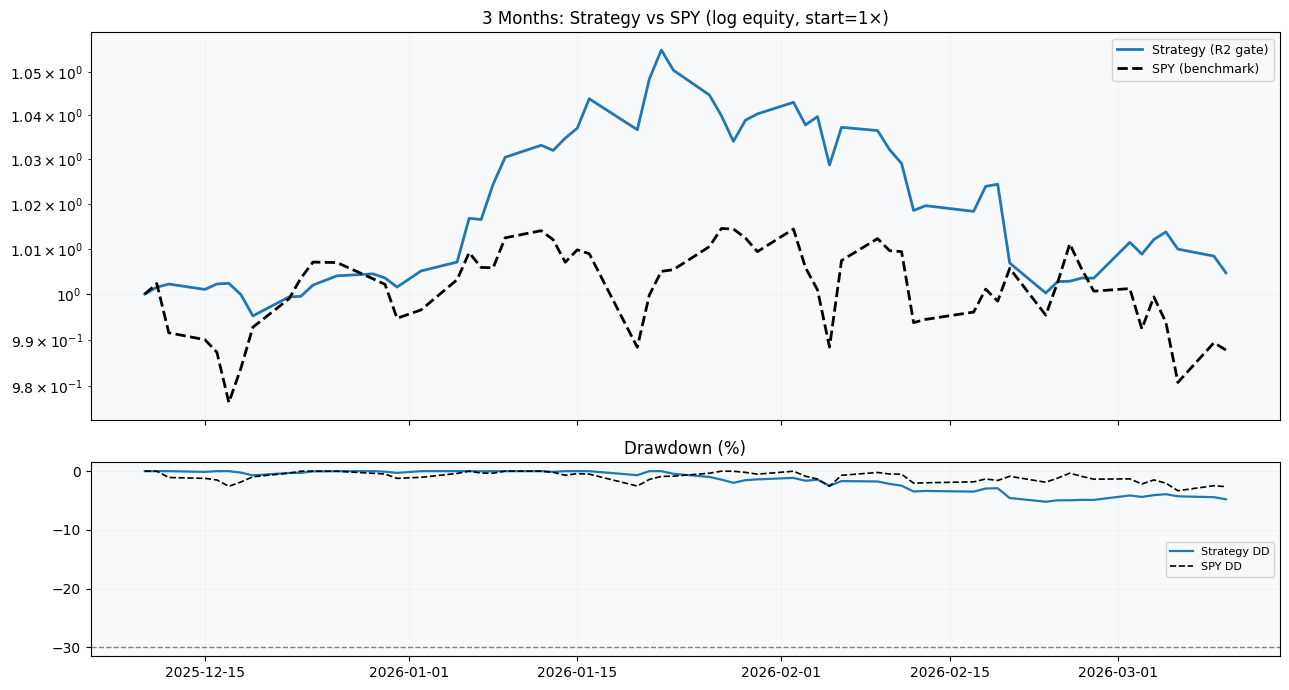

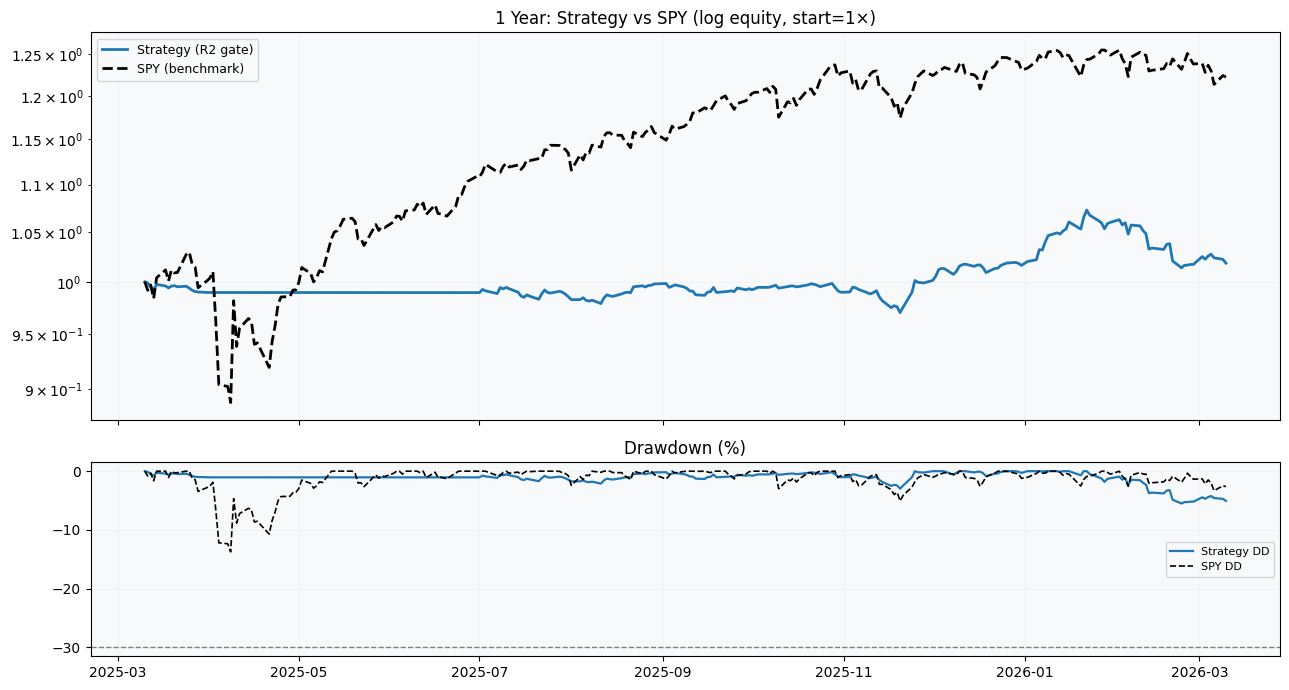

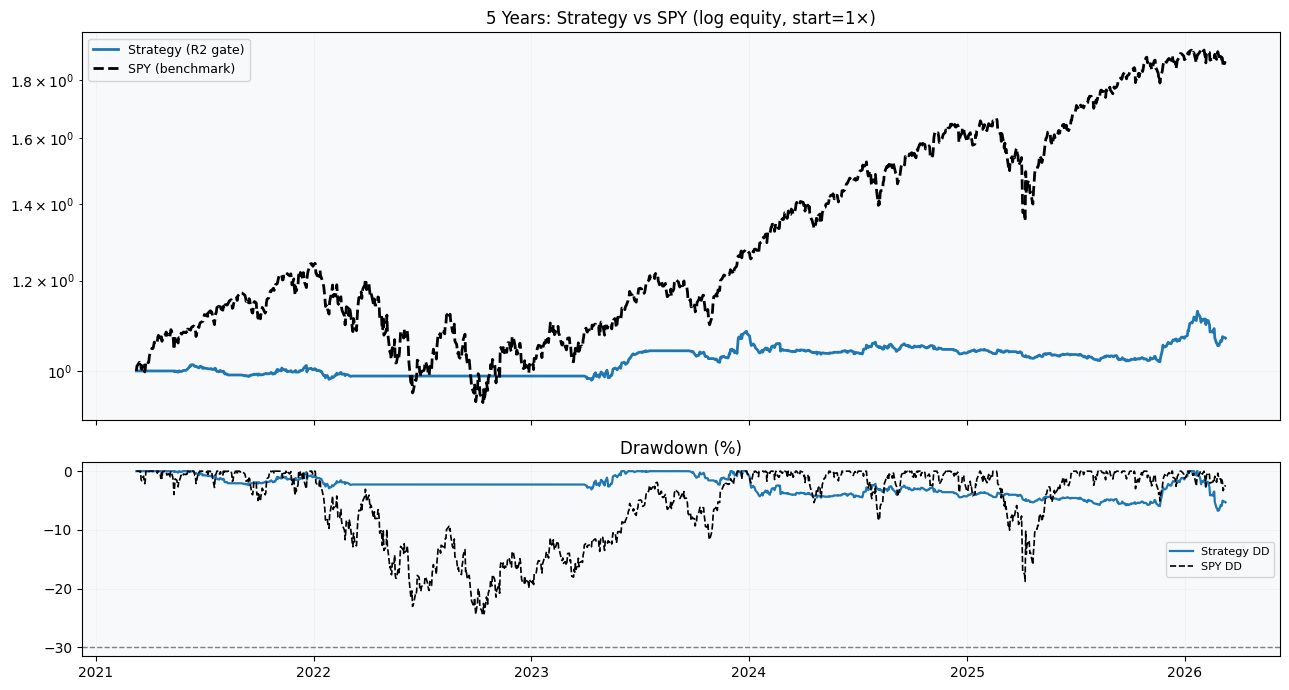

In [67]:
# ── Step 16B: Run 3M / 1Y / 5Y and print comparison table ───────────────
today = closes_lt.index[-1]
periods = [
    ('3 Months', today - pd.DateOffset(months=3)),
    ('1 Year',   today - pd.DateOffset(years=1)),
    ('5 Years',  today - pd.DateOffset(years=5)),
]

rows = []
for lbl, start in periods:
    rows.append(_pnl_for_window(start, today, lbl))

out = pd.DataFrame(rows)

# Format table (Clenow-style)
fmt = out.copy()
fmt['Strategy PnL $'] = fmt['Strategy PnL $'].map(lambda x: f"${x:+,.0f}")
fmt['SPY PnL $']      = fmt['SPY PnL $'].map(lambda x: f"${x:+,.0f}")
fmt['Strategy Return %'] = fmt['Strategy Return %'].map(lambda x: f"{x:+.1%}")
fmt['SPY Return %']      = fmt['SPY Return %'].map(lambda x: f"{x:+.1%}")
fmt['Strategy Stop %']   = fmt['Strategy Stop %'].map(lambda x: f"{x:.1%}")

print('=== Step 16: R2 Trend Stack Strategy vs SPY (PnL on $100k) ===')
display(fmt[[
    'Period','Start','End',
    'Strategy PnL $','Strategy Return %','Strategy Trades','Strategy Stop %',
    'SPY PnL $','SPY Return %',
]])

# Plot equity curves for each horizon (warmup-enabled, always includes SPY line)
for lbl, start in periods:
    warm_start = pd.Timestamp(start) - pd.Timedelta(days=_WARMUP_DAYS)

    c  = closes_lt.loc[warm_start:today]
    h  = high_lt.loc[warm_start:today]
    p  = pb_lt.loc[warm_start:today]
    em = _mask16.loc[warm_start:today]
    g  = _r2_gate.loc[warm_start:today]

    eq_full, _ = backtest_lt_risk(
        c, h, p,
        entry_mask=em,
        regime_gate=g,
        vol_weighted_entries=False,
        vol20=None,
        initial_capital=BT_CAPITAL_16,
        **_params16,
    )

    eq = eq_full.loc[pd.Timestamp(start):today]
    if len(eq) < 2:
        print(f"[WARN] {lbl}: not enough equity points to plot.")
        continue

    spy_seg = spy_lt.loc[eq.index[0]:eq.index[-1]]
    spy_eq  = (spy_seg / spy_seg.iloc[0]) * BT_CAPITAL_16

    fig, (ax1, ax2) = plt.subplots(2,1, figsize=(13,7), sharex=True,
                                   gridspec_kw={'height_ratios':[2,1]})

    ax1.plot(eq.index, eq/eq.iloc[0], label='Strategy (R2 gate)', lw=2.0, color='#1f77b4')
    ax1.plot(spy_eq.index, spy_eq/spy_eq.iloc[0], label='SPY (benchmark)', lw=2.0, ls='--', color='black')
    ax1.set_yscale('log')
    ax1.set_title(f"{lbl}: Strategy vs SPY (log equity, start=1×)")
    ax1.grid(alpha=0.3)
    ax1.legend(fontsize=9)

    dd_s = (eq/eq.cummax()-1)*100
    dd_b = (spy_eq/spy_eq.cummax()-1)*100
    ax2.plot(dd_s.index, dd_s, color='#1f77b4', lw=1.6, label='Strategy DD')
    ax2.plot(dd_b.index, dd_b, color='black', lw=1.2, ls='--', label='SPY DD')
    ax2.axhline(-30, color='gray', ls='--', lw=1)
    ax2.set_title('Drawdown (%)')
    ax2.grid(alpha=0.3)
    ax2.legend(fontsize=8)

    plt.tight_layout()
    plt.show()



---
## Step X — Deployment Grid (R2 Gate)  |  $10k budget  |  TopN 5–10

We grid-search these knobs under the agreed **R2 Trend Stack** regime gate:
- **Entry depth**: pullback ≥ 40%, 50%, 60% below 52w high
- **Stop from entry**: 20%, 25%, 30%
- **TopN**: 5 or 10 concurrent positions

We then backtest each combo over:
- last **3 months**, **1 year**, **5 years**

Outputs:
- a summary table per horizon (PnL on **$10k**) with **SPY row**
- one combined table ranking the best combos per horizon

Notes:
- Exits still happen daily by rules; entry scans happen every `REBAL_FREQ` days.
- Warmup is used so lookbacks (252d high / 200MA) are valid even for the 3M window.


In [68]:
# ── Step X1: Horizon backtest helpers (warmup-enabled) ─────────────────────
BT_CAPITAL_GRID = 10_000

# R2 gate
R2_GATE = regimes['R2 Trend Stack'].reindex(closes_lt.index).fillna(False)

_WARMUP_DAYS = 520  # ~2 years of calendar days buffer

def run_strategy_window(start_dt, end_dt, entry_depth, stop_entry, top_n,
                        exit_pullback=0.25, stop_from_high=0.80):
    start_dt = pd.Timestamp(start_dt)
    end_dt   = pd.Timestamp(end_dt)

    warm_start = start_dt - pd.Timedelta(days=_WARMUP_DAYS)

    c = closes_lt.loc[warm_start:end_dt]
    h = high_lt.loc[warm_start:end_dt]
    p = pb_lt.loc[warm_start:end_dt]

    # entry mask for this depth + quality gates already defined earlier in notebook
    # Use the same quality gates you converged on: F2+F3 (not freefall + not structurally broken)
    entry_mask = (p >= entry_depth) & _f2.loc[warm_start:end_dt] & _f3.loc[warm_start:end_dt]

    eq, tl = backtest_lt_risk(
        c, h, p,
        entry_mask=entry_mask,
        regime_gate=R2_GATE.loc[warm_start:end_dt],
        vol_weighted_entries=False,
        vol20=None,
        initial_capital=BT_CAPITAL_GRID,
        exit_pullback=exit_pullback,
        stop_from_high=stop_from_high,
        stop_from_entry=stop_entry,
        trailing_stop=None,
        top_n=top_n,
        rebal_freq=REBAL_FREQ,
        max_hold_days=MAX_HOLD_DAYS,
        tc=TRANSACTION_COST,
        max_portfolio_dd=None,
    )

    eq_w = eq.loc[start_dt:end_dt]
    if len(eq_w) < 2:
        return None

    strat_pnl = float(eq_w.iloc[-1] - eq_w.iloc[0])
    strat_ret = float(eq_w.iloc[-1] / eq_w.iloc[0] - 1)

    spy_seg = spy_lt.loc[eq_w.index[0]:eq_w.index[-1]]
    spy_pnl = float((spy_seg.iloc[-1] / spy_seg.iloc[0] - 1) * BT_CAPITAL_GRID)
    spy_ret = float(spy_seg.iloc[-1] / spy_seg.iloc[0] - 1)

    stop_pct = (tl['exit_reason'].astype(str).str.contains('stop')).mean() if len(tl) else 0.0

    return {
        'start': str(eq_w.index[0].date()),
        'end': str(eq_w.index[-1].date()),
        'pnl': strat_pnl,
        'ret': strat_ret,
        'trades': int(len(tl)),
        'stop_pct': float(stop_pct),
        'spy_pnl': spy_pnl,
        'spy_ret': spy_ret,
        'eq_window': eq_w,
    }

print('Step X1 ready.')


Step X1 ready.


In [69]:
# ── Step X2: Run grid over 3 horizons + include SPY row/line ─────────────
end_dt = closes_lt.index[-1]
horizons = [
    ('3 Months', end_dt - pd.DateOffset(months=3), end_dt),
    ('1 Year',   end_dt - pd.DateOffset(years=1),  end_dt),
    ('5 Years',  end_dt - pd.DateOffset(years=5),  end_dt),
]

depths = [0.40, 0.50, 0.60]
stops  = [0.20, 0.25, 0.30]
topns  = [5, 10]

all_rows = []

for hlabel, start_dt, end_dt in horizons:
    for d in depths:
        for se in stops:
            for tn in topns:
                r = run_strategy_window(start_dt, end_dt, d, se, tn)
                if r is None:
                    continue
                all_rows.append({
                    'Horizon': hlabel,
                    'EntryDepth': d,
                    'StopEntry': se,
                    'TopN': tn,
                    'Start': r['start'],
                    'End': r['end'],
                    'Strategy PnL $': r['pnl'],
                    'Strategy Return %': r['ret'],
                    'Trades': r['trades'],
                    'Stop %': r['stop_pct'],
                    'SPY PnL $': r['spy_pnl'],
                    'SPY Return %': r['spy_ret'],
                })

res_grid = pd.DataFrame(all_rows)

# Pick best per horizon by Sharpe-like proxy is hard here; use Return then lower stop% as tie-breaker
# (If you want, we can add Sharpe computed from eq_window, but it costs more runtime.)

print('=== Grid complete. Showing best configs per horizon (by Strategy Return) ===')

best_per = []
for h in res_grid['Horizon'].unique():
    sub = res_grid[res_grid['Horizon']==h].sort_values(
        ['Strategy Return %','Stop %','Trades'], ascending=[False, True, False]
    )
    best_per.append(sub.head(1))

best_per = pd.concat(best_per).reset_index(drop=True)

# Format tables per horizon (include SPY row)
for h in ['3 Months','1 Year','5 Years']:
    sub = res_grid[res_grid['Horizon']==h].copy()
    sub = sub.sort_values(['Strategy Return %'], ascending=False).head(12)

    # Append SPY-only benchmark row for that horizon
    spy_row = sub.iloc[0].copy()
    spy_row[['EntryDepth','StopEntry','TopN','Trades','Stop %']] = [np.nan,np.nan,np.nan,0,np.nan]
    spy_row['Strategy PnL $'] = spy_row['SPY PnL $']
    spy_row['Strategy Return %'] = spy_row['SPY Return %']
    spy_row['EntryDepth'] = '—'
    spy_row['StopEntry'] = '—'
    spy_row['TopN'] = '—'
    spy_row['Trades'] = 0
    spy_row['Stop %'] = np.nan
    spy_row['Model'] = 'SPY (benchmark)'

    sub['Model'] = sub.apply(lambda r: f"d{int(r['EntryDepth']*100)} se{int(r['StopEntry']*100)} n{int(r['TopN'])}", axis=1)
    sub2 = pd.concat([sub, pd.DataFrame([spy_row])], ignore_index=True)

    fmt = sub2.copy()
    for c in ['Strategy PnL $','SPY PnL $']:
        fmt[c] = fmt[c].map(lambda x: f"${x:+,.0f}")
    for c in ['Strategy Return %','SPY Return %']:
        fmt[c] = fmt[c].map(lambda x: f"{x:+.1%}")
    fmt['Stop %'] = fmt['Stop %'].map(lambda x: f"{x:.1%}" if pd.notna(x) else '—')

    print('\n=== ' + str(h) + ' (Top 12 configs) — Strategy vs SPY on $10k ===')
    display(fmt[[
        'Model','Start','End',
        'Strategy PnL $','Strategy Return %','Trades','Stop %',
        'SPY PnL $','SPY Return %',
    ]])

print('\n=== Best config per horizon (by Strategy Return) ===')
fmtb = best_per.copy()
fmtb['Model'] = fmtb.apply(lambda r: f"d{int(r['EntryDepth']*100)} se{int(r['StopEntry']*100)} n{int(r['TopN'])}", axis=1)
fmtb['Strategy PnL $'] = fmtb['Strategy PnL $'].map(lambda x: f"${x:+,.0f}")
fmtb['SPY PnL $'] = fmtb['SPY PnL $'].map(lambda x: f"${x:+,.0f}")
fmtb['Strategy Return %'] = fmtb['Strategy Return %'].map(lambda x: f"{x:+.1%}")
fmtb['SPY Return %'] = fmtb['SPY Return %'].map(lambda x: f"{x:+.1%}")
fmtb['Stop %'] = fmtb['Stop %'].map(lambda x: f"{x:.1%}")

display(fmtb[['Horizon','Model','Start','End','Strategy PnL $','Strategy Return %','Trades','Stop %','SPY PnL $','SPY Return %']])



=== Grid complete. Showing best configs per horizon (by Strategy Return) ===

=== 3 Months (Top 12 configs) — Strategy vs SPY on $10k ===


,Model,Start,End,Strategy PnL $,Strategy Return %,Trades,Stop %,SPY PnL $,SPY Return %
0,d40 se25 n5,2025-12-10,2026-03-10,"$+1,151",+9.6%,11,9.1%,$-122,-1.2%
1,d50 se25 n5,2025-12-10,2026-03-10,"$+1,137",+9.5%,11,9.1%,$-122,-1.2%
2,d40 se30 n5,2025-12-10,2026-03-10,"$+1,098",+9.3%,11,9.1%,$-122,-1.2%
3,d50 se30 n5,2025-12-10,2026-03-10,"$+1,086",+9.2%,11,9.1%,$-122,-1.2%
4,d50 se20 n5,2025-12-10,2026-03-10,$+913,+7.7%,14,28.6%,$-122,-1.2%
5,d60 se25 n5,2025-12-10,2026-03-10,$+203,+1.9%,6,33.3%,$-122,-1.2%
6,d60 se25 n10,2025-12-10,2026-03-10,$+124,+1.2%,6,33.3%,$-122,-1.2%
7,d60 se30 n10,2025-12-10,2026-03-10,$+61,+0.6%,6,16.7%,$-122,-1.2%
8,d60 se30 n5,2025-12-10,2026-03-10,$+61,+0.5%,6,16.7%,$-122,-1.2%
9,d50 se25 n10,2025-12-10,2026-03-10,$+52,+0.4%,22,27.3%,$-122,-1.2%



=== 1 Year (Top 12 configs) — Strategy vs SPY on $10k ===


,Model,Start,End,Strategy PnL $,Strategy Return %,Trades,Stop %,SPY PnL $,SPY Return %
0,d50 se20 n5,2025-03-10,2026-03-10,"$+3,768",+42.7%,27,40.7%,"$+2,222",+22.2%
1,d50 se25 n5,2025-03-10,2026-03-10,"$+2,886",+32.7%,25,32.0%,"$+2,222",+22.2%
2,d40 se20 n5,2025-03-10,2026-03-10,"$+2,745",+31.4%,29,44.8%,"$+2,222",+22.2%
3,d40 se25 n5,2025-03-10,2026-03-10,"$+1,587",+17.5%,26,34.6%,"$+2,222",+22.2%
4,d50 se20 n10,2025-03-10,2026-03-10,"$+1,368",+15.7%,45,42.2%,"$+2,222",+22.2%
5,d50 se30 n5,2025-03-10,2026-03-10,"$+1,339",+14.7%,23,30.4%,"$+2,222",+22.2%
6,d40 se25 n10,2025-03-10,2026-03-10,"$+1,058",+13.3%,53,34.0%,"$+2,222",+22.2%
7,d40 se20 n10,2025-03-10,2026-03-10,$+855,+10.8%,59,42.4%,"$+2,222",+22.2%
8,d50 se30 n10,2025-03-10,2026-03-10,$+867,+9.7%,40,27.5%,"$+2,222",+22.2%
9,d50 se25 n10,2025-03-10,2026-03-10,$+692,+7.7%,42,35.7%,"$+2,222",+22.2%



=== 5 Years (Top 12 configs) — Strategy vs SPY on $10k ===


,Model,Start,End,Strategy PnL $,Strategy Return %,Trades,Stop %,SPY PnL $,SPY Return %
0,d50 se20 n5,2021-03-10,2026-03-10,"$+12,281",+59.3%,79,29.1%,"$+8,621",+86.2%
1,d50 se25 n5,2021-03-10,2026-03-10,"$+9,304",+44.9%,72,20.8%,"$+8,621",+86.2%
2,d50 se30 n10,2021-03-10,2026-03-10,"$+7,670",+43.6%,100,13.0%,"$+8,621",+86.2%
3,d50 se25 n10,2021-03-10,2026-03-10,"$+6,569",+37.4%,105,21.0%,"$+8,621",+86.2%
4,d50 se30 n5,2021-03-10,2026-03-10,"$+7,312",+35.3%,70,17.1%,"$+8,621",+86.2%
5,d60 se25 n5,2021-03-10,2026-03-10,"$+5,056",+27.0%,26,23.1%,"$+8,621",+86.2%
6,d60 se30 n5,2021-03-10,2026-03-10,"$+4,969",+26.5%,26,19.2%,"$+8,621",+86.2%
7,d50 se20 n10,2021-03-10,2026-03-10,"$+4,272",+24.3%,110,32.7%,"$+8,621",+86.2%
8,d60 se20 n5,2021-03-10,2026-03-10,"$+4,129",+22.0%,28,28.6%,"$+8,621",+86.2%
9,d60 se25 n10,2021-03-10,2026-03-10,"$+2,111",+13.8%,28,21.4%,"$+8,621",+86.2%



=== Best config per horizon (by Strategy Return) ===


,Horizon,Model,Start,End,Strategy PnL $,Strategy Return %,Trades,Stop %,SPY PnL $,SPY Return %
0,3 Months,d40 se25 n5,2025-12-10,2026-03-10,"$+1,151",+9.6%,11,9.1%,$-122,-1.2%
1,1 Year,d50 se20 n5,2025-03-10,2026-03-10,"$+3,768",+42.7%,27,40.7%,"$+2,222",+22.2%
2,5 Years,d50 se20 n5,2021-03-10,2026-03-10,"$+12,281",+59.3%,79,29.1%,"$+8,621",+86.2%


---
## Step Y — Trade Blotter / PnL Statement (R2 Final)

This section prints the **actual trades** the finalized R2 strategy would take from the universe:
- **Parameters**: R2 gate, EntryDepth=40%, Stop-from-entry=25%, TopN=5
- **Budget**: $10,000

For each horizon (3M / 1Y / 5Y) you’ll see:
- **Trade blotter** (BUY/SELL rows) with dates, price, shares, and realized PnL
- **Totals**: realized PnL + open (MTM) PnL + SPY benchmark PnL


In [70]:
# ── Step Y1: Run finalized R2 + print trade statements ─────────────────
R2_FINAL = {
    'entry_depth': 0.40,
    'stop_entry': 0.25,
    'top_n': 5,
}
BT_CAPITAL = 10_000

R2_GATE = regimes['R2 Trend Stack'].reindex(closes_lt.index).fillna(False)

def _run_window(start_dt, end_dt, label):
    start_dt = pd.Timestamp(start_dt)
    end_dt   = pd.Timestamp(end_dt)

    # Warmup so 52w / MA lookbacks work, but **no trading** before start_dt
    warm_start = start_dt - pd.Timedelta(days=520)

    c = closes_lt.loc[warm_start:end_dt]
    h = high_lt.loc[warm_start:end_dt]
    p = pb_lt.loc[warm_start:end_dt]

    entry_mask = (p >= R2_FINAL['entry_depth']) & _f2.loc[warm_start:end_dt] & _f3.loc[warm_start:end_dt]
    entry_mask.loc[entry_mask.index < start_dt] = False

    gate = R2_GATE.loc[warm_start:end_dt].copy()
    gate.loc[gate.index < start_dt] = False

    eq_full, tl = backtest_lt_risk(
        c, h, p,
        entry_mask=entry_mask,
        regime_gate=gate,
        initial_capital=BT_CAPITAL,
        top_n=R2_FINAL['top_n'],
        rebal_freq=REBAL_FREQ,
        max_hold_days=MAX_HOLD_DAYS,
        tc=TRANSACTION_COST,
        exit_pullback=0.25,
        stop_from_high=0.80,
        stop_from_entry=R2_FINAL['stop_entry'],
        trailing_stop=None,
        vol_weighted_entries=False,
        vol20=None,
        max_portfolio_dd=None,
    )

    eq = eq_full.loc[start_dt:end_dt]
    if len(eq) < 2:
        print("\n=== " + str(label) + " | R2 FINAL (d40 se25 n5) | $10k ===")
        print('Not enough data in this window after warmup.')
        return

    # Realized trades (only trades entered on/after start_dt)
    tl = tl.copy()
    if len(tl):
        tl['entry_date'] = pd.to_datetime(tl['entry_date'])
        tl['exit_date']  = pd.to_datetime(tl['exit_date'])
        tl = tl[tl['entry_date'] >= start_dt].sort_values(['entry_date','ticker']).reset_index(drop=True)

    realized_pnl = float(tl['pnl_dollars'].sum()) if len(tl) else 0.0

    # Open positions MTM (replay, with warmup but no entries before start_dt)
    def _positions_end():
        dates = c.index
        start_idx = HIGH_LOOKBACK + 5
        capital = BT_CAPITAL
        positions = {}

        for i, date in enumerate(dates[start_idx:], start=start_idx):
            prices = c.iloc[i]

            # exits
            to_exit = []
            for sym, pos in list(positions.items()):
                px = _safe_px(prices, sym, np.nan)
                if np.isnan(px) or px <= 0:
                    to_exit.append((sym, 'delisted')); continue

                days_held = i - pos['entry_idx']
                cur_high  = _safe_px(h.iloc[i], sym, pos['ref_high'])
                cur_pb    = (cur_high - px) / cur_high if cur_high > 0 else 1.0

                reason = None
                if cur_pb <= 0.25:
                    reason = 'target'
                elif px <= pos['entry_price'] * (1 - R2_FINAL['stop_entry']):
                    reason = 'stop_entry'
                elif cur_pb >= 0.80:
                    reason = 'stop_high'
                elif days_held >= MAX_HOLD_DAYS:
                    reason = 'timeout'

                if reason:
                    to_exit.append((sym, reason))

            for sym, _ in to_exit:
                pos = positions.pop(sym)
                px  = max(_safe_px(prices, sym, pos['entry_price']), 0.01)
                capital += (pos['shares'] * px) * (1 - TRANSACTION_COST)

            pv = capital + sum(
                pos['shares'] * max(_safe_px(prices, s, pos['entry_price']), 0.0)
                for s, pos in positions.items()
            )

            allow_entries = bool(gate.reindex(dates).iloc[i])

            if (i - start_idx) % REBAL_FREQ == 0 and allow_entries:
                slots_free = R2_FINAL['top_n'] - len(positions)
                if slots_free > 0:
                    cand = p.iloc[i].where(entry_mask.iloc[i]).dropna().sort_values(ascending=False)
                    cand = cand[~cand.index.isin(positions.keys())]
                    picks = list(cand.index[:slots_free])

                    if len(picks) > 0:
                        budget_total = min(capital, (pv / R2_FINAL['top_n']) * len(picks))
                        if budget_total > 0:
                            w = pd.Series(1.0, index=picks)
                            w = w / w.sum()

                            for sym in picks:
                                px = _safe_px(prices, sym, 0)
                                if not (px > 0):
                                    continue
                                alloc = float(budget_total * w[sym])
                                shares = int((alloc * (1 - TRANSACTION_COST)) / px)
                                cost = shares * px * (1 + TRANSACTION_COST)
                                if shares < 1 or cost > capital:
                                    continue
                                hi = _safe_px(h.iloc[i], sym, px)
                                positions[sym] = {
                                    'shares': int(shares),
                                    'entry_price': float(px),
                                    'entry_idx': i,
                                    'entry_date': date,
                                    'ref_high': float(hi),
                                }
                                capital -= cost

        last_prices = c.loc[eq.index[-1]]
        rows=[]
        for sym,pos in positions.items():
            last_px = float(_safe_px(last_prices, sym, pos['entry_price']))
            mtm_pnl = (last_px - pos['entry_price']) * pos['shares']
            rows.append({
                'ticker': sym,
                'entry_date': pos['entry_date'],
                'shares': pos['shares'],
                'entry_price': pos['entry_price'],
                'last_date': eq.index[-1],
                'last_price': last_px,
                'mtm_pnl_dollars': float(mtm_pnl),
                'mtm_return_pct': last_px / pos['entry_price'] - 1,
            })

        open_cols = ['ticker','entry_date','shares','entry_price','last_date','last_price','mtm_pnl_dollars','mtm_return_pct']
        odf = pd.DataFrame(rows, columns=open_cols)
        if len(odf):
            odf = odf.sort_values(['ticker']).reset_index(drop=True)
        return odf

    open_df = _positions_end()
    open_pnl = float(open_df['mtm_pnl_dollars'].sum()) if len(open_df) else 0.0

    # Trade blotter (BUY + SELL rows)
    blot = []
    for _,r in tl.iterrows():
        blot.append({
            'date': r['entry_date'].date(),
            'ticker': r['ticker'],
            'side': 'BUY',
            'shares': int(r['shares']),
            'price': float(r['entry_price']),
            'value': float(r['shares'] * r['entry_price']),
            'pnl': np.nan,
            'reason': '',
        })
        blot.append({
            'date': r['exit_date'].date(),
            'ticker': r['ticker'],
            'side': 'SELL',
            'shares': int(r['shares']),
            'price': float(r['exit_price']),
            'value': float(r['shares'] * r['exit_price']),
            'pnl': float(r['pnl_dollars']),
            'reason': r['exit_reason'],
        })

    blot_cols = ['date','ticker','side','shares','price','value','pnl','reason']
    blot = pd.DataFrame(blot, columns=blot_cols)
    if len(blot):
        blot = blot.sort_values(['date','ticker','side']).reset_index(drop=True)

    # SPY benchmark PnL over same dates
    spy_seg = spy_lt.loc[eq.index[0]:eq.index[-1]]
    spy_pnl = float((spy_seg.iloc[-1] / spy_seg.iloc[0] - 1) * BT_CAPITAL)

    print("\n=== " + str(label) + " | R2 FINAL (d40 se25 n5) | $10k ===")
    print(f"Window: {eq.index[0].date()} → {eq.index[-1].date()}")
    print(f"Realized PnL: ${realized_pnl:+,.0f} | Open (MTM) PnL: ${open_pnl:+,.0f} | Total PnL: ${realized_pnl + open_pnl:+,.0f}")
    print(f"SPY PnL: ${spy_pnl:+,.0f}")

    if len(blot):
        disp = blot.copy()
        disp['value'] = disp['value'].map(lambda x: f"${x:,.0f}")
        disp['price'] = disp['price'].map(lambda x: f"${x:,.2f}")
        disp['pnl']   = disp['pnl'].map(lambda x: (f"${x:+,.0f}" if pd.notna(x) else ''))
        display(disp)
    else:
        print('No trades in this window.')

    if len(open_df):
        od = open_df.copy()
        od['entry_price'] = od['entry_price'].map(lambda x: f"${x:,.2f}")
        od['last_price']  = od['last_price'].map(lambda x: f"${x:,.2f}")
        od['mtm_pnl_dollars'] = od['mtm_pnl_dollars'].map(lambda x: f"${x:+,.0f}")
        od['mtm_return_pct'] = od['mtm_return_pct'].map(lambda x: f"{x:+.1%}")
        print('\\nOpen positions at window end (MTM):')
        display(od)

# Run 3 horizons ending at latest date
_end = closes_lt.index[-1]
_run_window(_end - pd.DateOffset(months=3), _end, '3 Months')
_run_window(_end - pd.DateOffset(years=1),  _end, '1 Year')
_run_window(_end - pd.DateOffset(years=5),  _end, '5 Years')








=== 3 Months | R2 FINAL (d40 se25 n5) | $10k ===
Window: 2025-12-10 → 2026-03-10
Realized PnL: $-634 | Open (MTM) PnL: $+383 | Total PnL: $-251
SPY PnL: $-122


,date,ticker,side,shares,price,value,pnl,reason
0,2025-12-15,NSP,BUY,54,$36.51,"$1,971",,
1,2026-02-12,NSP,SELL,54,$24.76,"$1,337",$-634,stop_entry


\nOpen positions at window end (MTM):


,ticker,entry_date,shares,entry_price,last_date,last_price,mtm_pnl_dollars,mtm_return_pct
0,AESI,2025-12-15,199,$10.04,2026-03-10,$12.40,$+470,+23.5%
1,CCOI,2025-12-15,87,$22.79,2026-03-10,$21.98,$-70,-3.5%
2,FUN,2025-12-15,136,$14.65,2026-03-10,$16.02,$+186,+9.4%
3,KMX,2026-02-12,34,$40.96,2026-03-10,$42.14,$+40,+2.9%
4,RH,2025-12-15,12,$163.67,2026-03-10,$143.45,$-243,-12.4%



=== 1 Year | R2 FINAL (d40 se25 n5) | $10k ===
Window: 2025-03-10 → 2026-03-10
Realized PnL: $+3,487 | Open (MTM) PnL: $+48 | Total PnL: $+3,535
SPY PnL: $+2,222


...

,ticker,entry_date,shares,entry_price,last_date,last_price,mtm_pnl_dollars,mtm_return_pct
0,CCOI,2025-12-12,119,$23.22,2026-03-10,$21.98,$-147,-5.3%
1,ENOV,2026-02-19,128,$22.30,2026-03-10,$23.89,$+204,+7.1%
2,FUN,2026-01-06,180,$15.28,2026-03-10,$16.02,$+133,+4.8%
3,KMX,2026-02-26,58,$42.86,2026-03-10,$42.14,$-42,-1.7%
4,NSIT,2026-02-26,29,$84.56,2026-03-10,$81.14,$-99,-4.0%



=== 5 Years | R2 FINAL (d40 se25 n5) | $10k ===
Window: 2021-03-10 → 2026-03-10
Realized PnL: $-1,695 | Open (MTM) PnL: $+524 | Total PnL: $-1,171
SPY PnL: $+8,621


,date,ticker,side,shares,price,value,pnl,reason
0,2021-03-23,RUN,BUY,35,$56.15,"$1,965",,
1,2021-05-05,RUN,SELL,35,$41.84,"$1,464",$-501,stop_entry
2,2021-05-12,ACAD,BUY,86,$21.83,"$1,877",,
3,2021-06-03,RUN,BUY,46,$41.30,"$1,900",,
4,2021-08-11,ACAD,SELL,86,$18.33,"$1,576",$-301,timeout
...,...,...,...,...,...,...,...,...
137,2026-01-06,AMN,SELL,75,$15.70,"$1,177",$-307,timeout
138,2026-01-06,NX,SELL,104,$16.07,"$1,671",$+181,timeout
139,2026-01-08,NSP,BUY,41,$41.88,"$1,717",,
140,2026-02-11,NSP,SELL,41,$28.66,"$1,175",$-542,stop_entry


\nOpen positions at window end (MTM):


,ticker,entry_date,shares,entry_price,last_date,last_price,mtm_pnl_dollars,mtm_return_pct
0,AESI,2026-01-08,168,$10.30,2026-03-10,$12.40,$+353,+20.4%
1,CCOI,2025-12-16,72,$23.00,2026-03-10,$21.98,$-73,-4.4%
2,ENOV,2026-02-13,69,$21.77,2026-03-10,$23.89,$+146,+9.7%
3,FUN,2025-12-31,107,$15.34,2026-03-10,$16.02,$+73,+4.4%
4,KMX,2026-02-13,36,$41.43,2026-03-10,$42.14,$+26,+1.7%


---
## Step Z — R2 v2 (Pre-Deployment Improvements)

Five problems found from blotter analysis, now fixed:

1. **Cooldown 20 days** after any exit — stops SRPT-style churn (same ticker in/out every week)
2. **Cooldown 30 days** after `stop_entry` specifically — avoids re-entering a failing stock too soon
3. **`stop_high` removed** — was triggering as a 1-day scalp exit, not a structural stop; caused most of the churn
4. **Pullback-weighted sizing** — deeper pullback = higher conviction = more allocation (vs flat equal weight)
5. **Capital recycled properly** — `MAX_HOLD_DAYS` forces exit so nothing sits forever

Below: full blotter (BUY/SELL per trade), open-positions MTM, and a summary vs SPY.


In [71]:
# ── Step Z1: R2 v2 Improved Backtest Engine ──────────────────────────────────
def backtest_lt_risk_r2v2(
    closes, high_52w, pullback,
    entry_mask,
    regime_gate=None,
    exit_pullback=0.25,
    stop_from_entry=0.25,
    cooldown_days=20,
    stop_entry_cooldown_days=30,
    pullback_weighted=True,
    initial_capital=10_000,
    top_n=5,
    rebal_freq=5,
    max_hold_days=63,
    tc=0.001,
):
    dates     = closes.index
    start_idx = HIGH_LOOKBACK + 5
    capital   = initial_capital
    positions = {}
    cooldown_until = {}
    port_vals, port_dates, trade_log = [], [], []

    for i, date in enumerate(dates[start_idx:], start=start_idx):
        prices = closes.iloc[i]

        # ── Exits ─────────────────────────────────────────────────────────
        to_exit = []
        for sym, pos in list(positions.items()):
            px = _safe_px(prices, sym, np.nan)
            if np.isnan(px) or px <= 0:
                to_exit.append((sym, 'delisted'))
                continue
            days_held = i - pos['entry_idx']
            cur_high  = _safe_px(high_52w.iloc[i], sym, pos['ref_high'])
            cur_pb    = (cur_high - px) / cur_high if cur_high > 0 else 1.0

            reason = None
            if cur_pb <= exit_pullback:
                reason = 'target'
            elif px <= pos['entry_price'] * (1 - stop_from_entry):
                reason = 'stop_entry'
            elif days_held >= max_hold_days:
                reason = 'timeout'
            if reason:
                to_exit.append((sym, reason))

        for sym, reason in to_exit:
            pos = positions.pop(sym)
            px  = max(_safe_px(prices, sym, pos['entry_price']), 0.01)
            capital += pos['shares'] * px * (1 - tc)
            pnl_dollars = (px - pos['entry_price']) * pos['shares']
            cd = stop_entry_cooldown_days if reason == 'stop_entry' else cooldown_days
            cooldown_until[sym] = date + pd.Timedelta(days=cd)
            trade_log.append({
                'ticker':      sym,
                'entry_date':  pos['entry_date'],
                'exit_date':   date,
                'days_held':   i - pos['entry_idx'],
                'shares':      int(pos['shares']),
                'entry_price': float(pos['entry_price']),
                'exit_price':  float(px),
                'pnl_dollars': float(pnl_dollars),
                'return_pct':  float(px / pos['entry_price'] - 1),
                'exit_reason': reason,
            })

        pv = capital + sum(
            pos['shares'] * max(_safe_px(prices, s, pos['entry_price']), 0.0)
            for s, pos in positions.items()
        )

        allow_entries = True
        if regime_gate is not None:
            allow_entries = bool(regime_gate.reindex(dates).iloc[i])

        if (i - start_idx) % rebal_freq == 0 and allow_entries:
            slots_free = top_n - len(positions)
            if slots_free > 0:
                cand = pullback.iloc[i].where(entry_mask.iloc[i]).dropna()
                cand = cand[~cand.index.isin(positions.keys())]
                cand = cand[~cand.index.map(
                    lambda s: cooldown_until.get(s, pd.Timestamp('1900-01-01')) >= date
                )]
                cand = cand.sort_values(ascending=False)
                picks = list(cand.index[:slots_free])

                if picks:
                    budget_total = min(capital, (pv / top_n) * len(picks))
                    if budget_total > 0:
                        if pullback_weighted:
                            pb_vals = cand.reindex(picks).clip(lower=1e-6)
                            w = pb_vals / pb_vals.sum()
                        else:
                            w = pd.Series(1.0 / len(picks), index=picks)

                        for sym in picks:
                            px = _safe_px(prices, sym, 0)
                            if not (px > 0):
                                continue
                            alloc  = float(budget_total * w[sym])
                            shares = int((alloc * (1 - tc)) / px)
                            cost   = shares * px * (1 + tc)
                            if shares < 1 or cost > capital:
                                continue
                            hi = _safe_px(high_52w.iloc[i], sym, px)
                            positions[sym] = {
                                'shares':      shares,
                                'entry_price': float(px),
                                'entry_idx':   i,
                                'entry_date':  date,
                                'ref_high':    float(hi),
                            }
                            capital -= cost

        pv = capital + sum(
            pos['shares'] * max(_safe_px(prices, s, pos['entry_price']), 0.0)
            for s, pos in positions.items()
        )
        port_vals.append(pv)
        port_dates.append(date)

    eq = pd.Series(port_vals, index=port_dates, name='strategy')
    tl = pd.DataFrame(trade_log)
    return eq, tl, positions   # 3rd element = open positions at end

print('R2 v2 engine ready (cooldown + no stop_high + pullback-weighted).')



R2 v2 engine ready (cooldown + no stop_high + pullback-weighted).


=== 3 Months | R2 v2 | $10k ===
Window: 2025-12-10 to 2026-03-10
Realized PnL: $-576  |  Open MTM: $+343  |  Total PnL: $-233
SPY PnL same period: $-122


,date,ticker,side,shares,price,value,pnl,reason
0,2025-12-15,NSP,BUY,49,$36.51,"$1,789",,
1,2026-02-12,NSP,SELL,49,$24.76,"$1,213",$-576,stop_entry


Open positions at window end (MTM):


,ticker,entry_date,shares,entry_price,last_date,last_price,mtm_pnl_dollars,mtm_return_pct
0,AESI,2025-12-15,179,$10.04,2026-03-10,$12.40,$+422,+23.5%
1,CCOI,2025-12-15,96,$22.79,2026-03-10,$21.98,$-78,-3.5%
2,FUN,2025-12-15,149,$14.65,2026-03-10,$16.02,$+204,+9.4%
3,KMX,2026-02-12,31,$40.96,2026-03-10,$42.14,$+37,+2.9%
4,RH,2025-12-15,12,$163.67,2026-03-10,$143.45,$-243,-12.4%


=== 1 Year | R2 v2 | $10k ===
Window: 2025-03-10 to 2026-03-10
Realized PnL: $+5,040  |  Open MTM: $+677  |  Total PnL: $+5,716
SPY PnL same period: $+2,222


...

,date,ticker,side,shares,price,value,pnl,reason
0,2021-03-23,RUN,BUY,35,$56.15,"$1,965",,
1,2021-05-05,RUN,SELL,35,$41.84,"$1,464",$-501,stop_entry
2,2021-05-12,ACAD,BUY,86,$21.83,"$1,877",,
3,2021-06-10,RUN,BUY,44,$45.04,"$1,982",,
4,2021-08-11,ACAD,SELL,86,$18.33,"$1,576",$-301,timeout
...,...,...,...,...,...,...,...,...
139,2025-12-29,LNTH,SELL,38,$67.34,"$2,559",$+635,timeout
140,2026-01-06,NX,SELL,139,$16.07,"$2,234",$+242,timeout
141,2026-02-11,RH,SELL,10,$199.94,"$1,999",$+422,timeout
142,2026-02-13,NSP,SELL,63,$24.53,"$1,545",$-522,stop_entry


Open positions at window end (MTM):


,ticker,entry_date,shares,entry_price,last_date,last_price,mtm_pnl_dollars,mtm_return_pct
0,CCOI,2025-12-31,106,$21.51,2026-03-10,$21.98,$+50,+2.2%
1,ENOV,2026-02-13,101,$21.77,2026-03-10,$23.89,$+214,+9.7%
2,FUN,2026-01-08,161,$15.29,2026-03-10,$16.02,$+118,+4.8%
3,INSP,2026-03-02,22,$64.81,2026-03-10,$59.44,$-118,-8.3%
4,KMX,2026-02-13,56,$41.43,2026-03-10,$42.14,$+40,+1.7%



=== Summary: R2 v2 vs SPY on $10k ===


,Horizon,Start,End,Strat PnL ($),Return,CAGR,Sharpe,MaxDD,Trades,Win%,SPY PnL ($),SPY Return,SPY CAGR,SPY Sharpe,SPY MaxDD
0,3 Months,2025-12-10,2026-03-10,$-233,-2.5%,-9.7%,-0.08,-23.4%,1,0%,$-122,-1.2%,-4.9%,-0.40,-3.3%
1,1 Year,2025-03-10,2026-03-10,"$+5,716",+56.5%,+56.5%,1.64,-15.4%,12,75%,"$+2,222",+22.2%,+22.2%,1.16,-13.7%
2,5 Years,2021-03-10,2026-03-10,"$+1,273",+10.0%,+1.9%,0.21,-38.0%,72,51%,"$+8,621",+86.2%,+13.3%,0.82,-24.5%


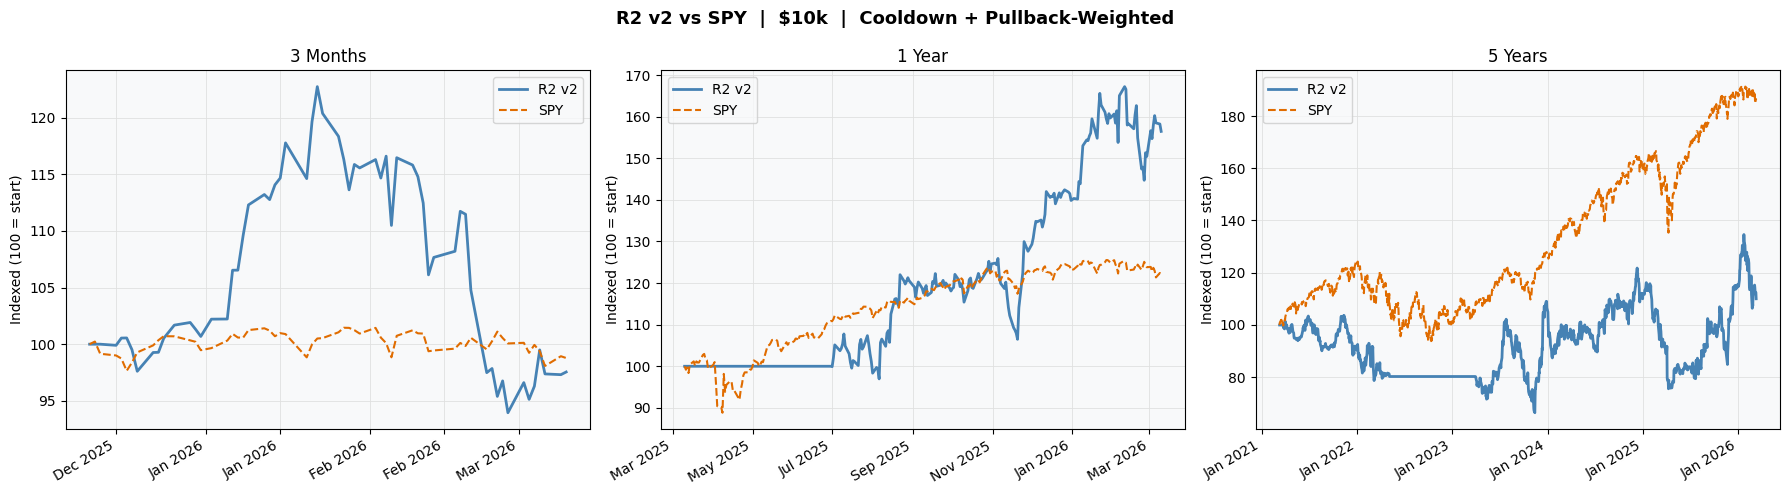

Done.


In [72]:
# ── Step Z2: Run 3M / 1Y / 5Y + full blotter + summary vs SPY ────────────────
BT_CAPITAL_V2 = 10_000
_WARMUP = 520   # calendar days

def _run_r2v2(start_dt, end_dt, label):
    s = pd.Timestamp(start_dt)
    e = pd.Timestamp(end_dt)
    ws = s - pd.Timedelta(days=_WARMUP)

    c = closes_lt.loc[ws:e]
    h = high_lt.loc[ws:e]
    p = pb_lt.loc[ws:e]

    em = (p >= R2_FINAL['entry_depth']) & _f2.loc[ws:e] & _f3.loc[ws:e]
    em.loc[em.index < s] = False

    gate = R2_GATE.loc[ws:e].copy()
    gate.loc[gate.index < s] = False

    eq_full, tl_all, open_pos = backtest_lt_risk_r2v2(
        c, h, p,
        entry_mask=em,
        regime_gate=gate,
        initial_capital=BT_CAPITAL_V2,
        top_n=R2_FINAL['top_n'],
        rebal_freq=REBAL_FREQ,
        max_hold_days=MAX_HOLD_DAYS,
        tc=TRANSACTION_COST,
        exit_pullback=0.25,
        stop_from_entry=R2_FINAL['stop_entry'],
        cooldown_days=20,
        stop_entry_cooldown_days=30,
        pullback_weighted=True,
    )

    eq = eq_full.loc[s:e]
    if len(eq) < 2:
        print(label + ': not enough data')
        return None

    tl = tl_all.copy()
    if len(tl):
        tl['entry_date'] = pd.to_datetime(tl['entry_date'])
        tl['exit_date']  = pd.to_datetime(tl['exit_date'])
        tl = tl[tl['entry_date'] >= s].sort_values(['entry_date', 'ticker']).reset_index(drop=True)

    realized_pnl = float(tl['pnl_dollars'].sum()) if len(tl) else 0.0

    # open positions MTM
    last_px_row = c.loc[:e].iloc[-1]
    open_rows = []
    for sym, pos in open_pos.items():
        lp = float(_safe_px(last_px_row, sym, pos['entry_price']))
        mtm = (lp - pos['entry_price']) * pos['shares']
        open_rows.append({
            'ticker': sym, 'entry_date': pos['entry_date'],
            'shares': pos['shares'], 'entry_price': pos['entry_price'],
            'last_date': eq.index[-1], 'last_price': lp,
            'mtm_pnl_dollars': float(mtm),
            'mtm_return_pct': lp / pos['entry_price'] - 1,
        })
    open_df = (pd.DataFrame(open_rows).sort_values('ticker').reset_index(drop=True)
               if open_rows else pd.DataFrame())
    open_pnl = float(open_df['mtm_pnl_dollars'].sum()) if len(open_df) else 0.0

    # metrics
    rets  = eq.pct_change().dropna()
    total_ret = float(eq.iloc[-1] / eq.iloc[0] - 1)
    n_yrs = max(len(eq) / 252, 1 / 252)
    cagr  = float((1 + total_ret) ** (1 / n_yrs) - 1)
    sharpe = float(rets.mean() / rets.std() * np.sqrt(252)) if rets.std() > 0 else 0.0
    max_dd = float(((eq - eq.cummax()) / eq.cummax()).min())
    win_rate = float((tl['pnl_dollars'] > 0).mean()) if len(tl) else 0.0

    # SPY metrics
    spy_seg   = spy_lt.loc[eq.index[0]:eq.index[-1]]
    spy_rets  = spy_seg.pct_change().dropna()
    spy_ret   = float(spy_seg.iloc[-1] / spy_seg.iloc[0] - 1)
    spy_pnl_v = spy_ret * BT_CAPITAL_V2
    spy_cagr  = float((1 + spy_ret) ** (1 / n_yrs) - 1)
    spy_sharpe = float(spy_rets.mean() / spy_rets.std() * np.sqrt(252)) if spy_rets.std() > 0 else 0.0
    spy_dd    = float(((spy_seg - spy_seg.cummax()) / spy_seg.cummax()).min())

    return dict(
        label=label, start=eq.index[0], end=eq.index[-1],
        realized_pnl=realized_pnl, open_pnl=open_pnl,
        total_pnl=realized_pnl + open_pnl,
        total_ret=total_ret, cagr=cagr, sharpe=sharpe, max_dd=max_dd,
        trades=len(tl), win_rate=win_rate,
        spy_ret=spy_ret, spy_pnl=spy_pnl_v, spy_cagr=spy_cagr,
        spy_sharpe=spy_sharpe, spy_dd=spy_dd,
        eq=eq, tl=tl, open_df=open_df, spy_seg=spy_seg,
    )


_end = closes_lt.index[-1]
_horizons = [
    ('3 Months', pd.DateOffset(months=3)),
    ('1 Year',   pd.DateOffset(years=1)),
    ('5 Years',  pd.DateOffset(years=5)),
]
all_r2v2 = {}

for _lbl, _off in _horizons:
    _r = _run_r2v2(_end - _off, _end, _lbl)
    if _r is None:
        continue
    all_r2v2[_lbl] = _r

    # ── Blotter ──────────────────────────────────────────────────────────
    _tl = _r['tl']
    _blot = []
    for _, row in _tl.iterrows():
        _blot.append({'date': row['entry_date'].date(), 'ticker': row['ticker'],
                      'side': 'BUY', 'shares': int(row['shares']),
                      'price': row['entry_price'],
                      'value': row['shares'] * row['entry_price'],
                      'pnl': np.nan, 'reason': ''})
        _blot.append({'date': row['exit_date'].date(), 'ticker': row['ticker'],
                      'side': 'SELL', 'shares': int(row['shares']),
                      'price': row['exit_price'],
                      'value': row['shares'] * row['exit_price'],
                      'pnl': row['pnl_dollars'], 'reason': row['exit_reason']})
    _blot_df = pd.DataFrame(_blot, columns=['date','ticker','side','shares','price','value','pnl','reason'])
    if len(_blot_df):
        _blot_df = _blot_df.sort_values(['date','ticker','side']).reset_index(drop=True)

    print('=== ' + _lbl + ' | R2 v2 | $10k ===')
    print('Window: ' + str(_r['start'].date()) + ' to ' + str(_r['end'].date()))
    print('Realized PnL: $' + f"{_r['realized_pnl']:+,.0f}" +
          '  |  Open MTM: $' + f"{_r['open_pnl']:+,.0f}" +
          '  |  Total PnL: $' + f"{_r['total_pnl']:+,.0f}")
    print('SPY PnL same period: $' + f"{_r['spy_pnl']:+,.0f}")

    if len(_blot_df):
        _d = _blot_df.copy()
        _d['price'] = _d['price'].map(lambda x: f'${x:,.2f}')
        _d['value'] = _d['value'].map(lambda x: f'${x:,.0f}')
        _d['pnl']   = _d['pnl'].map(lambda x: f'${x:+,.0f}' if pd.notna(x) else '')
        display(_d)
    else:
        print('No completed trades in this window.')

    if len(_r['open_df']):
        _od = _r['open_df'].copy()
        _od['entry_price']     = _od['entry_price'].map(lambda x: f'${x:,.2f}')
        _od['last_price']      = _od['last_price'].map(lambda x: f'${x:,.2f}')
        _od['mtm_pnl_dollars'] = _od['mtm_pnl_dollars'].map(lambda x: f'${x:+,.0f}')
        _od['mtm_return_pct']  = _od['mtm_return_pct'].map(lambda x: f'{x:+.1%}')
        print('Open positions at window end (MTM):')
        display(_od)

# ── Summary comparison table ─────────────────────────────────────────────────
_summary = []
for _lbl, _r in all_r2v2.items():
    _summary.append({
        'Horizon':       _lbl,
        'Start':         str(_r['start'].date()),
        'End':           str(_r['end'].date()),
        'Strat PnL ($)': f"${_r['total_pnl']:+,.0f}",
        'Return':        f"{_r['total_ret']:+.1%}",
        'CAGR':          f"{_r['cagr']:+.1%}",
        'Sharpe':        f"{_r['sharpe']:.2f}",
        'MaxDD':         f"{_r['max_dd']:.1%}",
        'Trades':        _r['trades'],
        'Win%':          f"{_r['win_rate']:.0%}",
        'SPY PnL ($)':   f"${_r['spy_pnl']:+,.0f}",
        'SPY Return':    f"{_r['spy_ret']:+.1%}",
        'SPY CAGR':      f"{_r['spy_cagr']:+.1%}",
        'SPY Sharpe':    f"{_r['spy_sharpe']:.2f}",
        'SPY MaxDD':     f"{_r['spy_dd']:.1%}",
    })

print('')
print('=== Summary: R2 v2 vs SPY on $10k ===')
display(pd.DataFrame(_summary))

# ── Equity curves ────────────────────────────────────────────────────────────
_fig, _axes = plt.subplots(1, 3, figsize=(18, 5))
for _ax, (_lbl, _r) in zip(_axes, all_r2v2.items()):
    _eq_n  = _r['eq']      / _r['eq'].iloc[0]      * 100
    _spy_n = _r['spy_seg'] / _r['spy_seg'].iloc[0] * 100
    _ax.plot(_eq_n.index,  _eq_n.values,  label='R2 v2',  color='steelblue',  lw=2)
    _ax.plot(_spy_n.index, _spy_n.values, label='SPY',    color='#e06c00', lw=1.5, linestyle='--')
    _ax.set_title(_lbl, fontsize=12)
    _ax.set_ylabel('Indexed (100 = start)')
    _ax.legend()
    _ax.xaxis.set_major_locator(plt.matplotlib.dates.AutoDateLocator())
    _ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
    plt.setp(_ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

_fig.suptitle('R2 v2 vs SPY  |  $10k  |  Cooldown + Pullback-Weighted', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('Done.')

